# Healthcare Challenge 2 - Baseline Submission

This notebook provides a simple baseline for **Healthcare Challenge 2: ED Cost Prediction**.

**Goal**: Predict `ed_cost_next3y_usd` for each patient
**Metric**: Mean Absolute Error (MAE) - Lower is better

## Instructions:
1. **Replace API credentials** in the first cell with your team's API key and name
2. **Run all cells** to generate and submit baseline predictions
3. **Check the output** for your submission score

This baseline uses only tabular ED cost data with a simple Random Forest regressor.


In [1]:
# 1. Initialize Client and Load Data

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from agentds import BenchmarkClient

# 🔑 REPLACE WITH YOUR CREDENTIALS
client = BenchmarkClient(
    api_key="adsb_AJp9fgtjuTRZ4Tk0mNnYDWxG_1759039055",        # Get from your team dashboard
    team_name="clai"     # Your exact team name
)

# Iteration 1
- 461.0468

## EDA

In [26]:
# Phase 1 EDA (Notebook Cell Version) — Cache-safe + Robust PDF parsing
from __future__ import annotations

from pathlib import Path
import re
import json
from datetime import datetime
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd

from joblib import dump, load
from tqdm import tqdm

import matplotlib.pyplot as plt

# -----------------------------
# PATHS (as you specified)
# -----------------------------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")
TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
TEST_CSV  = BASE_DIR / "ed_cost_test.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"
PDF_DIR = BASE_DIR / "receipts_pdf"

CACHE_DIR = BASE_DIR / "cache_iter10"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RECEIPT_CACHE = CACHE_DIR / "receipts_parsed.joblib"

EDA_OUT_DIR = CACHE_DIR / "eda_outputs"
EDA_OUT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# CONFIG
# -----------------------------
FORCE_REPARSE = False          # set True to ignore cache
LIMIT_PDFS: Optional[int] = None  # set e.g. 200 for quick smoke test
MIN_PATIENTS_WITH_CODE = 30

CACHE_SCHEMA_VERSION = "receipts_parsed_v2"

plt.rcParams["figure.dpi"] = 120


# -----------------------------
# Helpers
# -----------------------------
def standardize_zip3(z) -> Optional[str]:
    if z is None or (isinstance(z, float) and np.isnan(z)):
        return None
    s = str(z).strip()
    s = re.sub(r"\D", "", s)
    if not s:
        return None
    return s.zfill(3)

def parse_money(x: str) -> float:
    x = str(x).strip()
    x = re.sub(r"[^\d\.\-]", "", x)
    return float(x) if x else np.nan

def is_code_token(s: str) -> bool:
    s = str(s).strip().upper()
    return bool(re.match(r"^[A-Z]{0,2}\d{4,5}$", s))

_money_token_re = re.compile(r"^[\$\d,]+\.\d{2}$")

def try_parse_wide_line(line: str) -> Optional[Dict]:
    """
    Parse a 'single-line' item like:
      99283 ED visit, moderate (level 3) 1 232.38 232.38
    Returns dict or None.
    """
    toks = line.strip().split()
    if not toks:
        return None

    code = toks[0].upper()
    if not is_code_token(code):
        return None

    # Find last 2 money tokens scanning from end
    money_positions = []
    for idx in range(len(toks) - 1, 0, -1):
        if _money_token_re.match(toks[idx]):
            money_positions.append(idx)
            if len(money_positions) == 2:
                break

    if len(money_positions) < 2:
        return None

    i_line = money_positions[0]  # last money token
    i_unit = money_positions[1]  # second last money token

    # Qty is usually immediately before unit, but search backwards if needed
    qty_idx = i_unit - 1
    if qty_idx < 1:
        return None

    if not re.match(r"^\d+$", toks[qty_idx]):
        found = None
        for j in range(i_unit - 1, 0, -1):
            if re.match(r"^\d+$", toks[j]):
                found = j
                break
        if found is None:
            return None
        qty_idx = found

    desc = " ".join(toks[1:qty_idx]).strip()
    qty = int(toks[qty_idx])
    unit_price = parse_money(toks[i_unit])
    line_total = parse_money(toks[i_line])

    return {
        "code": code,
        "description": desc,
        "qty": qty,
        "unit_price": unit_price,
        "line_total": line_total,
    }

def categorize_code(code: str, desc: str = "") -> str:
    code = str(code).strip().upper()
    desc_l = str(desc or "").lower()

    if re.match(r"^9928[1-5]$", code):
        return "ED_EM"
    if code == "G0378" or "observation" in desc_l:
        return "OBS"
    if code.isdigit() and len(code) == 5 and code.startswith("7"):
        return "IMAGING"
    if code.isdigit() and len(code) == 5 and code.startswith("8"):
        return "LAB"
    return "OTHER"

def extract_text_pymupdf(pdf_path: Path) -> str:
    try:
        import fitz  # PyMuPDF
    except Exception as e:
        raise RuntimeError(
            "PyMuPDF not available. Install with:\n"
            "  pip install pymupdf\n"
            f"Import error: {e}"
        )
    doc = fitz.open(str(pdf_path))
    return "\n".join(page.get_text() for page in doc)

def parse_receipt_text(text: str) -> Tuple[Dict, List[Dict]]:
    """
    Robust parser:
    - Extract header fields (patient_id, zip3, insurance, TOTAL)
    - Extract line items either in:
        (a) stacked-column style (code on its own line, then description, qty, unit, line_total)
        (b) wide single-line style (code desc qty unit line_total)
    """
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]

    header: Dict = {}

    m = re.search(r"Patient ID:\s*(\d+)", text)
    if m:
        header["patient_id"] = int(m.group(1))

    m = re.search(r"ZIP3:\s*([0-9]{1,3})", text)
    if m:
        header["zip3_receipt_raw"] = m.group(1)

    m = re.search(r"Insurance:\s*([A-Za-z_]+)", text)
    if m:
        header["insurance_receipt"] = m.group(1).lower()

    # TOTAL
    total = np.nan
    for i, ln in enumerate(lines):
        if ln.startswith("TOTAL"):
            m = re.search(r"TOTAL\s*([\d\.,\-]+)", ln)
            if m:
                total = parse_money(m.group(1))
            else:
                if i + 1 < len(lines):
                    total = parse_money(lines[i + 1])
            break
    header["receipt_total"] = total

    # Identify table start
    start = None
    for i, ln in enumerate(lines):
        if "Line Total" in ln:
            start = i + 1
            break
    if start is None:
        # fallback: first line whose first token is a code
        for i, ln in enumerate(lines):
            first = ln.split()[0] if ln.split() else ""
            if is_code_token(first):
                start = i
                break
    if start is None:
        return header, []

    # Attempt WIDE parsing across table block first
    items: List[Dict] = []
    for i in range(start, len(lines)):
        ln = lines[i]
        if ln.startswith("TOTAL"):
            break
        parsed = try_parse_wide_line(ln)
        if parsed:
            items.append(parsed)

    if items:
        return header, items

    # Fallback: STACKED parsing (PyMuPDF commonly yields this)
    items = []
    i = start
    while i < len(lines):
        ln = lines[i]
        if ln.startswith("TOTAL"):
            break

        if not is_code_token(ln):
            i += 1
            continue

        code = ln.strip().upper()

        # description lines until qty integer
        j = i + 1
        desc_parts: List[str] = []
        while j < len(lines) and not re.match(r"^\d+$", lines[j]) and not lines[j].startswith("TOTAL"):
            desc_parts.append(lines[j])
            j += 1

        if j >= len(lines) or lines[j].startswith("TOTAL"):
            break

        desc = " ".join(desc_parts).strip()
        qty = int(lines[j])

        if j + 1 >= len(lines):
            break
        unit_price = parse_money(lines[j + 1])

        if j + 2 >= len(lines):
            break
        line_total = parse_money(lines[j + 2])

        items.append(
            {"code": code, "description": desc, "qty": qty, "unit_price": unit_price, "line_total": line_total}
        )
        i = j + 3

    return header, items

def parse_receipt_pdf(pdf_path: Path) -> Tuple[Dict, pd.DataFrame]:
    text = extract_text_pymupdf(pdf_path)
    header, items = parse_receipt_text(text)

    header["pdf_path"] = str(pdf_path)
    header["n_line_items"] = len(items)

    if items:
        li = pd.DataFrame(items)
        header["sum_line_total"] = float(np.nansum(li["line_total"].values))
        header["sum_unit_x_qty"] = float(np.nansum((li["unit_price"] * li["qty"]).values))
    else:
        li = pd.DataFrame(columns=["code", "description", "qty", "unit_price", "line_total"])
        header["sum_line_total"] = 0.0
        header["sum_unit_x_qty"] = 0.0

    return header, li

def backup_bad_cache(cache_path: Path, reason: str) -> Path:
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    new_path = cache_path.with_name(f"{cache_path.stem}.BAD_{reason}_{ts}{cache_path.suffix}")
    cache_path.rename(new_path)
    return new_path

def load_receipt_cache_safe(cache_path: Path) -> Optional[Tuple[pd.DataFrame, pd.DataFrame]]:
    if not cache_path.exists():
        return None

    try:
        obj = load(cache_path)
    except Exception as e:
        print(f"[cache] Failed to load cache ({cache_path.name}): {e}")
        bad = backup_bad_cache(cache_path, "load_error")
        print(f"[cache] Backed up bad cache to: {bad}")
        return None

    if not isinstance(obj, dict):
        print(f"[cache] Cache schema mismatch: expected dict, got {type(obj)}")
        bad = backup_bad_cache(cache_path, "not_dict")
        print(f"[cache] Backed up bad cache to: {bad}")
        return None

    if obj.get("schema_version") != CACHE_SCHEMA_VERSION:
        # allow migration attempt only if it already has required keys
        if "headers_df" in obj and "lineitems_df" in obj:
            print("[cache] Cache schema_version mismatch but required keys exist. Will use it anyway.")
        else:
            print(f"[cache] Cache schema_version mismatch or missing. Found schema_version={obj.get('schema_version')}")
            print(f"[cache] Keys in cache: {list(obj.keys())}")
            bad = backup_bad_cache(cache_path, "schema_mismatch")
            print(f"[cache] Backed up bad cache to: {bad}")
            return None

    if "headers_df" not in obj or "lineitems_df" not in obj:
        print(f"[cache] Cache missing expected keys. Keys found: {list(obj.keys())}")
        bad = backup_bad_cache(cache_path, "missing_keys")
        print(f"[cache] Backed up bad cache to: {bad}")
        return None

    headers_df = obj["headers_df"]
    lineitems_df = obj["lineitems_df"]

    # minimal validation
    if not isinstance(headers_df, pd.DataFrame) or "patient_id" not in headers_df.columns:
        print("[cache] headers_df invalid in cache")
        bad = backup_bad_cache(cache_path, "bad_headers")
        print(f"[cache] Backed up bad cache to: {bad}")
        return None

    if not isinstance(lineitems_df, pd.DataFrame) or ("patient_id" not in lineitems_df.columns or "code" not in lineitems_df.columns):
        print("[cache] lineitems_df invalid in cache")
        bad = backup_bad_cache(cache_path, "bad_lineitems")
        print(f"[cache] Backed up bad cache to: {bad}")
        return None

    return headers_df, lineitems_df

def save_receipt_cache(cache_path: Path, headers_df: pd.DataFrame, lineitems_df: pd.DataFrame) -> None:
    payload = {
        "schema_version": CACHE_SCHEMA_VERSION,
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "headers_df": headers_df,
        "lineitems_df": lineitems_df,
    }
    dump(payload, cache_path, compress=3)

def parse_receipts(patient_ids: List[int]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # Try safe load
    if not FORCE_REPARSE:
        cached = load_receipt_cache_safe(RECEIPT_CACHE)
        if cached is not None:
            headers_df, lineitems_df = cached
            cached_ids = set(headers_df["patient_id"].astype(int).tolist())
            needed = set(patient_ids)
            missing = sorted(list(needed - cached_ids))
            if not missing:
                print(f"[cache] Loaded cache OK ({RECEIPT_CACHE.name}): {len(cached_ids)} patients")
                return headers_df, lineitems_df
            print(f"[cache] Cache OK but missing {len(missing)} patients — parsing missing and updating cache")
            headers_new, items_new = _parse_receipts_no_cache(missing)
            headers_df = pd.concat([headers_df, headers_new], ignore_index=True)
            lineitems_df = pd.concat([lineitems_df, items_new], ignore_index=True)
            save_receipt_cache(RECEIPT_CACHE, headers_df, lineitems_df)
            return headers_df, lineitems_df

    # Reparse all
    headers_df, lineitems_df = _parse_receipts_no_cache(patient_ids)
    save_receipt_cache(RECEIPT_CACHE, headers_df, lineitems_df)
    print(f"[cache] Wrote cache: {RECEIPT_CACHE}")
    return headers_df, lineitems_df

def _parse_receipts_no_cache(patient_ids: List[int]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    headers: List[Dict] = []
    all_items: List[pd.DataFrame] = []

    ids = patient_ids
    if LIMIT_PDFS is not None:
        ids = ids[:LIMIT_PDFS]
        print(f"[info] LIMIT_PDFS={LIMIT_PDFS}: parsing {len(ids)} receipts (of {len(patient_ids)})")

    missing_files = 0
    for pid in tqdm(ids, desc="Parsing receipts"):
        pdf_path = PDF_DIR / f"receipt_{pid}.pdf"
        if not pdf_path.exists():
            missing_files += 1
            headers.append(
                {
                    "patient_id": pid,
                    "pdf_path": str(pdf_path),
                    "parse_ok": False,
                    "parse_error": "missing_file",
                    "n_line_items": 0,
                    "receipt_total": np.nan,
                    "sum_line_total": np.nan,
                    "sum_unit_x_qty": np.nan,
                    "zip3_receipt_raw": None,
                    "insurance_receipt": None,
                }
            )
            continue

        try:
            h, li = parse_receipt_pdf(pdf_path)
            h["parse_ok"] = True
            h["parse_error"] = None

            li = li.copy()
            li["patient_id"] = int(pid)
            all_items.append(li)

            headers.append(h)
        except Exception as e:
            headers.append(
                {
                    "patient_id": pid,
                    "pdf_path": str(pdf_path),
                    "parse_ok": False,
                    "parse_error": str(e)[:2000],
                    "n_line_items": 0,
                    "receipt_total": np.nan,
                    "sum_line_total": np.nan,
                    "sum_unit_x_qty": np.nan,
                    "zip3_receipt_raw": None,
                    "insurance_receipt": None,
                }
            )

    headers_df = pd.DataFrame(headers)
    lineitems_df = (
        pd.concat(all_items, ignore_index=True)
        if all_items
        else pd.DataFrame(columns=["patient_id", "code", "description", "qty", "unit_price", "line_total"])
    )

    if missing_files:
        print(f"[warn] Missing receipt PDFs: {missing_files}")

    # Standardize
    headers_df["patient_id"] = headers_df["patient_id"].astype(int)
    headers_df["zip3_receipt"] = headers_df.get("zip3_receipt_raw", pd.Series([None]*len(headers_df))).apply(standardize_zip3)
    headers_df["insurance_receipt"] = headers_df.get("insurance_receipt", pd.Series([None]*len(headers_df))).astype(str).str.lower().str.strip()

    if not lineitems_df.empty:
        lineitems_df["code"] = lineitems_df["code"].astype(str).str.upper().str.strip()
        lineitems_df["description"] = lineitems_df["description"].astype(str)
        lineitems_df["qty"] = pd.to_numeric(lineitems_df["qty"], errors="coerce").fillna(0).astype(int)
        lineitems_df["unit_price"] = pd.to_numeric(lineitems_df["unit_price"], errors="coerce")
        lineitems_df["line_total"] = pd.to_numeric(lineitems_df["line_total"], errors="coerce")

    return headers_df, lineitems_df

def build_receipt_features(headers_df: pd.DataFrame, lineitems_df: pd.DataFrame) -> pd.DataFrame:
    if lineitems_df.empty:
        base = pd.DataFrame({"patient_id": headers_df["patient_id"].astype(int)})
        return base.merge(headers_df[["patient_id","receipt_total","sum_line_total","sum_unit_x_qty","zip3_receipt","insurance_receipt","parse_ok"]],
                          on="patient_id", how="left")

    li = lineitems_df.copy()
    li["category"] = [categorize_code(c, d) for c, d in zip(li["code"], li["description"])]
    li["is_em"] = li["category"].eq("ED_EM")
    li["em_level"] = np.where(li["is_em"], li["code"].str[-1].astype(int), np.nan)

    g = li.groupby("patient_id", observed=True)
    feat = pd.DataFrame(index=g.size().index)

    feat["pdf_n_line_items"] = g.size()
    feat["pdf_n_unique_codes"] = g["code"].nunique()
    feat["pdf_total_qty"] = g["qty"].sum()
    feat["pdf_total_line_cost"] = g["line_total"].sum()

    for cat in ["ED_EM", "IMAGING", "LAB", "OBS", "OTHER"]:
        m = li["category"].eq(cat)
        feat[f"pdf_cost_{cat.lower()}"] = li.loc[m].groupby("patient_id")["line_total"].sum()
        feat[f"pdf_cnt_{cat.lower()}"] = li.loc[m].groupby("patient_id")["code"].size()

    feat = feat.fillna(0)

    denom = feat["pdf_total_line_cost"].replace(0, np.nan)
    for cat in ["ED_EM", "IMAGING", "LAB", "OBS", "OTHER"]:
        feat[f"pdf_share_{cat.lower()}"] = (feat[f"pdf_cost_{cat.lower()}"] / denom).fillna(0)

    em = li[li["is_em"]].copy()
    if not em.empty:
        emg = em.groupby("patient_id", observed=True)
        feat["pdf_em_visit_lines"] = emg.size()
        feat["pdf_em_level_max"] = emg["em_level"].max()
        feat["pdf_em_level_mean"] = emg["em_level"].mean()
        feat["pdf_em_high_frac"] = (em[em["em_level"] >= 4].groupby("patient_id").size() / emg.size()).fillna(0)
    else:
        feat["pdf_em_visit_lines"] = 0
        feat["pdf_em_level_max"] = 0
        feat["pdf_em_level_mean"] = 0
        feat["pdf_em_high_frac"] = 0

    cost_by_code = li.groupby(["patient_id", "code"], observed=True)["line_total"].sum()

    def entropy_cost(series: pd.Series) -> float:
        total = series.sum()
        if total <= 0:
            return 0.0
        p = series / total
        return float(-(p * np.log(p + 1e-12)).sum())

    ent = cost_by_code.groupby(level=0).apply(entropy_cost)
    feat["pdf_code_cost_entropy"] = ent
    feat["pdf_code_cost_entropy_norm"] = feat["pdf_code_cost_entropy"] / np.log(
        feat["pdf_n_unique_codes"].replace(0, np.nan)
    ).fillna(1)

    feat["pdf_nonem_per_em"] = (feat["pdf_n_line_items"] - feat["pdf_cnt_ed_em"]) / (
        feat["pdf_cnt_ed_em"].replace(0, np.nan)
    )
    feat["pdf_nonem_per_em"] = feat["pdf_nonem_per_em"].fillna(0)

    feat = feat.reset_index()

    hdr_cols = ["patient_id","receipt_total","sum_line_total","sum_unit_x_qty","zip3_receipt","insurance_receipt","parse_ok"]
    feat = feat.merge(headers_df[hdr_cols], on="patient_id", how="left")

    return feat

def plot_hist(series: pd.Series, title: str, path: Path, logx: bool = False) -> None:
    s = series.dropna().astype(float)
    if s.empty:
        return
    plt.figure(figsize=(7, 4))
    if logx:
        s = s[s > 0]
        plt.hist(np.log1p(s), bins=60)
        plt.xlabel("log1p(value)")
    else:
        plt.hist(s, bins=60)
        plt.xlabel("value")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path)
    plt.close()

def plot_scatter(x: pd.Series, y: pd.Series, title: str, path: Path, logxy: bool = False) -> None:
    df = pd.DataFrame({"x": x, "y": y}).dropna()
    if df.empty:
        return
    plt.figure(figsize=(6, 5))
    if logxy:
        df = df[(df["x"] > 0) & (df["y"] > 0)]
        plt.scatter(np.log1p(df["x"]), np.log1p(df["y"]), s=8, alpha=0.35)
        plt.xlabel("log1p(x)")
        plt.ylabel("log1p(y)")
    else:
        plt.scatter(df["x"], df["y"], s=8, alpha=0.35)
        plt.xlabel("x")
        plt.ylabel("y")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path)
    plt.close()

# -----------------------------
# RUN EDA
# -----------------------------
print(f"[paths] BASE_DIR={BASE_DIR}")
print(f"[paths] PDF_DIR={PDF_DIR}")
print(f"[paths] EDA_OUT_DIR={EDA_OUT_DIR}")
print(f"[paths] RECEIPT_CACHE={RECEIPT_CACHE}")

# Load CSVs
train = pd.read_csv(TRAIN_CSV)
test = pd.read_csv(TEST_CSV)
patients = pd.read_csv(PATIENTS_CSV) if PATIENTS_CSV.exists() else None

train["patient_id"] = train["patient_id"].astype(int)
test["patient_id"] = test["patient_id"].astype(int)

if patients is not None:
    patients["patient_id"] = patients["patient_id"].astype(int)
    if "zip3" in patients.columns:
        patients["zip3"] = patients["zip3"].apply(standardize_zip3)
    if "insurance" in patients.columns:
        patients["insurance"] = patients["insurance"].astype(str).str.lower().str.strip()

# Basic integrity report
report = {
    "n_train": int(train.shape[0]),
    "n_test": int(test.shape[0]),
    "train_dupe_patient_id": int(train["patient_id"].duplicated().sum()),
    "test_dupe_patient_id": int(test["patient_id"].duplicated().sum()),
    "train_missing_values": train.isna().sum().to_dict(),
    "test_missing_values": test.isna().sum().to_dict(),
    "patients_loaded": patients is not None,
}
if patients is not None:
    report["n_patients"] = int(patients.shape[0])
    report["patients_dupe_patient_id"] = int(patients["patient_id"].duplicated().sum())
    report["train_missing_in_patients_n"] = len(set(train["patient_id"]) - set(patients["patient_id"]))
    report["test_missing_in_patients_n"] = len(set(test["patient_id"]) - set(patients["patient_id"]))

print("\n=== BASIC INTEGRITY REPORT ===")
print(json.dumps(report, indent=2))
(EDA_OUT_DIR / "basic_integrity_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")

# Merge with patients
if patients is not None:
    train_full = train.merge(patients, on="patient_id", how="left", validate="one_to_one")
    test_full  = test.merge(patients, on="patient_id", how="left", validate="one_to_one")
else:
    train_full = train.copy()
    test_full = test.copy()

# Plots (train)
if "ed_cost_next3y_usd" in train_full.columns:
    plot_hist(train_full["ed_cost_next3y_usd"], "Target: ed_cost_next3y_usd (train)", EDA_OUT_DIR / "hist_target.png")
    plot_hist(train_full["ed_cost_next3y_usd"], "Target: ed_cost_next3y_usd (train) [log1p]", EDA_OUT_DIR / "hist_target_log.png", logx=True)

plot_hist(train_full["prior_ed_cost_5y_usd"], "Prior 5y ED cost (train)", EDA_OUT_DIR / "hist_prior_cost.png")
plot_hist(train_full["prior_ed_cost_5y_usd"], "Prior 5y ED cost (train) [log1p]", EDA_OUT_DIR / "hist_prior_cost_log.png", logx=True)
plot_hist(train_full["prior_ed_visits_5y"], "Prior 5y ED visits (train)", EDA_OUT_DIR / "hist_prior_visits.png")

if "ed_cost_next3y_usd" in train_full.columns:
    plot_scatter(train_full["prior_ed_cost_5y_usd"], train_full["ed_cost_next3y_usd"],
                 "Prior 5y cost vs Next 3y cost", EDA_OUT_DIR / "scatter_priorcost_vs_target.png", logxy=False)
    plot_scatter(train_full["prior_ed_cost_5y_usd"], train_full["ed_cost_next3y_usd"],
                 "Prior 5y cost vs Next 3y cost [log1p]", EDA_OUT_DIR / "scatter_priorcost_vs_target_log.png", logxy=True)

# Parse receipts with cache safety
all_ids = sorted(set(train_full["patient_id"].tolist()) | set(test_full["patient_id"].tolist()))
headers_df, lineitems_df = parse_receipts(all_ids)

headers_df.to_csv(EDA_OUT_DIR / "receipts_headers_parsed.csv", index=False)
lineitems_df.head(3000).to_csv(EDA_OUT_DIR / "receipts_lineitems_head3000.csv", index=False)

# Integrity checks vs CSV priors
combined = pd.concat(
    [
        train_full[["patient_id", "prior_ed_visits_5y", "prior_ed_cost_5y_usd"]].assign(split="train"),
        test_full[["patient_id", "prior_ed_visits_5y", "prior_ed_cost_5y_usd"]].assign(split="test"),
    ],
    ignore_index=True,
).merge(headers_df, on="patient_id", how="left")

combined["diff_total_vs_prior"] = combined["receipt_total"] - combined["prior_ed_cost_5y_usd"]
combined["abs_diff_total_vs_prior"] = combined["diff_total_vs_prior"].abs()

combined["diff_sumlines_vs_total"] = combined["sum_line_total"] - combined["receipt_total"]
combined["abs_diff_sumlines_vs_total"] = combined["diff_sumlines_vs_total"].abs()

# E/M lines vs prior visits
if not lineitems_df.empty:
    em_mask = lineitems_df["code"].astype(str).str.match(r"^9928[1-5]$")
    em_counts = lineitems_df.loc[em_mask].groupby("patient_id")["code"].size().rename("em_line_count")
    combined = combined.merge(em_counts, on="patient_id", how="left")
    combined["em_line_count"] = combined["em_line_count"].fillna(0).astype(int)
    combined["diff_emlines_vs_priorvisits"] = combined["em_line_count"] - combined["prior_ed_visits_5y"]

# Compare insurance/zip3 receipt vs patients
if patients is not None:
    if "insurance" in combined.columns:
        combined["insurance_match"] = (
            combined["insurance"].astype(str).str.lower().str.strip()
            == combined["insurance_receipt"].astype(str).str.lower().str.strip()
        )
    if "zip3" in combined.columns:
        combined["zip3_match"] = combined["zip3"].apply(standardize_zip3) == combined["zip3_receipt"].apply(standardize_zip3)

combined.to_csv(EDA_OUT_DIR / "receipt_integrity_joined.csv", index=False)

print("\n=== RECEIPT INTEGRITY SUMMARY ===")
ok_parse_rate = float(np.mean(combined["parse_ok"].fillna(False)))
print(f"Parse OK rate: {ok_parse_rate:.4f}")

print("\nAbs(TOTAL - prior_ed_cost_5y_usd):")
print(combined["abs_diff_total_vs_prior"].describe(percentiles=[0.5, 0.9, 0.99]).to_string())

print("\nAbs(sum(line_totals) - TOTAL):")
print(combined["abs_diff_sumlines_vs_total"].describe(percentiles=[0.5, 0.9, 0.99]).to_string())

if "diff_emlines_vs_priorvisits" in combined.columns:
    print("\nE/M line count - prior_ed_visits_5y:")
    print(combined["diff_emlines_vs_priorvisits"].describe(percentiles=[0.5, 0.9, 0.99]).to_string())

plot_hist(combined["abs_diff_total_vs_prior"], "Abs(TOTAL - prior_cost)", EDA_OUT_DIR / "hist_abs_total_minus_prior.png")
plot_hist(combined["abs_diff_total_vs_prior"], "Abs(TOTAL - prior_cost) [log1p]", EDA_OUT_DIR / "hist_abs_total_minus_prior_log.png", logx=True)

# Build receipt features and merge to train
receipt_feat = build_receipt_features(headers_df, lineitems_df)
receipt_feat.to_csv(EDA_OUT_DIR / "receipt_features_per_patient.csv", index=False)

train_aug = train_full.merge(receipt_feat, on="patient_id", how="left")
train_aug.to_csv(EDA_OUT_DIR / "train_aug_with_receipt_features.csv", index=False)

# Group summary
if "ed_cost_next3y_usd" in train_aug.columns:
    group_cols = ["primary_chronic"] + (["insurance"] if "insurance" in train_aug.columns else [])
    summary = (
        train_aug
        .groupby(group_cols, dropna=False)
        .agg(
            n=("patient_id", "size"),
            target_mean=("ed_cost_next3y_usd", "mean"),
            target_median=("ed_cost_next3y_usd", "median"),
            prior_cost_mean=("prior_ed_cost_5y_usd", "mean"),
            prior_visits_mean=("prior_ed_visits_5y", "mean"),
            em_mean=("pdf_em_level_mean", "mean"),
            imaging_share_mean=("pdf_share_imaging", "mean"),
            obs_share_mean=("pdf_share_obs", "mean"),
        )
        .reset_index()
        .sort_values("target_mean", ascending=False)
    )
    summary.to_csv(EDA_OUT_DIR / "group_summary_chronic_insurance.csv", index=False)
    print("\n=== GROUP SUMMARY (head) ===")
    print(summary.head(30).to_string(index=False))

# ZIP3 stats
if "zip3" in train_aug.columns and "ed_cost_next3y_usd" in train_aug.columns:
    zip_stats = (
        train_aug
        .groupby("zip3", dropna=False)
        .agg(
            n=("patient_id", "size"),
            target_mean=("ed_cost_next3y_usd", "mean"),
            target_median=("ed_cost_next3y_usd", "median"),
            prior_cost_mean=("prior_ed_cost_5y_usd", "mean"),
            prior_visits_mean=("prior_ed_visits_5y", "mean"),
        )
        .reset_index()
    )
    zip_stats = zip_stats[zip_stats["n"] >= 20].sort_values("target_mean", ascending=False)
    zip_stats.to_csv(EDA_OUT_DIR / "zip3_stats_nge20.csv", index=False)
    print("\n=== ZIP3 STATS (n>=20, head 15) ===")
    print(zip_stats.head(15).to_string(index=False))

# Correlation scan (Spearman)
if "ed_cost_next3y_usd" in train_aug.columns:
    candidate_cols = [c for c in train_aug.columns if c.startswith("pdf_")]
    drop_like = {"receipt_total", "sum_line_total", "sum_unit_x_qty"}
    candidate_cols = [c for c in candidate_cols if c not in drop_like]

    corr = (
        train_aug[["ed_cost_next3y_usd"] + candidate_cols]
        .corr(method="spearman")["ed_cost_next3y_usd"]
        .drop("ed_cost_next3y_usd")
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    corr.to_csv(EDA_OUT_DIR / "spearman_corr_receipt_features_vs_target.csv")
    print("\n=== TOP SPEARMAN CORRELATIONS (receipt features vs target) ===")
    print(corr.head(25).to_string())

# Code uplift (train only)
if not lineitems_df.empty and "ed_cost_next3y_usd" in train_full.columns:
    train_ids = set(train_full["patient_id"].astype(int).tolist())
    li_train = lineitems_df[lineitems_df["patient_id"].isin(train_ids)].copy()

    code_freq = (
        li_train.groupby("code", observed=True)
        .agg(
            n_lines=("code", "size"),
            n_patients=("patient_id", "nunique"),
            total_cost=("line_total", "sum"),
            mean_unit_price=("unit_price", "mean"),
        )
        .reset_index()
        .sort_values(["n_patients", "total_cost"], ascending=False)
    )
    code_freq.to_csv(EDA_OUT_DIR / "code_frequency_train.csv", index=False)

    t = train_full[["patient_id", "ed_cost_next3y_usd"]].copy()
    total_sum = float(t["ed_cost_next3y_usd"].sum())
    N = int(t.shape[0])

    presence = li_train[["patient_id", "code"]].drop_duplicates()
    merged = presence.merge(t, on="patient_id", how="left")

    mean_with = merged.groupby("code")["ed_cost_next3y_usd"].mean()
    n_with = merged.groupby("code")["patient_id"].nunique()
    sum_with = merged.groupby("code")["ed_cost_next3y_usd"].sum()

    mean_without = (total_sum - sum_with) / (N - n_with).replace(0, np.nan)

    uplift = pd.DataFrame(
        {
            "n_patients_with_code": n_with,
            "mean_target_with_code": mean_with,
            "mean_target_without_code": mean_without,
        }
    ).reset_index()
    uplift["diff_with_minus_without"] = uplift["mean_target_with_code"] - uplift["mean_target_without_code"]

    uplift = uplift[uplift["n_patients_with_code"] >= MIN_PATIENTS_WITH_CODE].sort_values(
        "diff_with_minus_without", ascending=False
    )
    uplift.to_csv(EDA_OUT_DIR / "code_uplift_train_nge_min.csv", index=False)

    print("\n=== TOP POSITIVE UPLIFT CODES (univariate; n>=threshold) ===")
    print(uplift.head(25).to_string(index=False))

    # Unit price by insurance for top codes (if insurance exists)
    if patients is not None and "insurance" in patients.columns:
        li_train2 = li_train.merge(patients[["patient_id", "insurance"]], on="patient_id", how="left")
        common_codes = code_freq.head(10)["code"].tolist()
        price_stats = (
            li_train2[li_train2["code"].isin(common_codes)]
            .groupby(["code", "insurance"], dropna=False)
            .agg(
                n_lines=("unit_price", "size"),
                unit_median=("unit_price", "median"),
                unit_mean=("unit_price", "mean"),
            )
            .reset_index()
            .sort_values(["code", "insurance"])
        )
        price_stats.to_csv(EDA_OUT_DIR / "unit_price_by_insurance_common_codes.csv", index=False)
        print("\n=== UNIT PRICE BY INSURANCE (common codes) ===")
        print(price_stats.head(60).to_string(index=False))

print("\n[DONE] Phase 1 EDA completed.")
print(f"Outputs written to: {EDA_OUT_DIR}")


[paths] BASE_DIR=D:\AgentDs\agent_ds_healthcare
[paths] PDF_DIR=D:\AgentDs\agent_ds_healthcare\receipts_pdf
[paths] EDA_OUT_DIR=D:\AgentDs\agent_ds_healthcare\cache_iter10\eda_outputs
[paths] RECEIPT_CACHE=D:\AgentDs\agent_ds_healthcare\cache_iter10\receipts_parsed.joblib

=== BASIC INTEGRITY REPORT ===
{
  "n_train": 2000,
  "n_test": 2000,
  "train_dupe_patient_id": 0,
  "test_dupe_patient_id": 0,
  "train_missing_values": {
    "patient_id": 0,
    "primary_chronic": 0,
    "prior_ed_visits_5y": 0,
    "prior_ed_cost_5y_usd": 0,
    "ed_cost_next3y_usd": 0
  },
  "test_missing_values": {
    "patient_id": 0,
    "primary_chronic": 0,
    "prior_ed_visits_5y": 0,
    "prior_ed_cost_5y_usd": 0
  },
  "patients_loaded": true,
  "n_patients": 4000,
  "patients_dupe_patient_id": 0,
  "train_missing_in_patients_n": 0,
  "test_missing_in_patients_n": 0
}
[cache] Loaded cache OK (receipts_parsed.joblib): 4000 patients

=== RECEIPT INTEGRITY SUMMARY ===
Parse OK rate: 1.0000

Abs(TOTAL - pri

## EDA 1.5

In [27]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from joblib import load
import matplotlib.pyplot as plt

# -----------------------------
# PATHS (your environment)
# -----------------------------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")
TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
TEST_CSV  = BASE_DIR / "ed_cost_test.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"
CACHE_DIR = BASE_DIR / "cache_iter10"
RECEIPT_CACHE = CACHE_DIR / "receipts_parsed.joblib"
OUT_DIR = CACHE_DIR / "eda_outputs_phase15"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120

def standardize_zip3(z):
    if z is None or (isinstance(z, float) and np.isnan(z)):
        return None
    s = re.sub(r"\D", "", str(z).strip())
    if not s:
        return None
    return s.zfill(3)

# -----------------------------
# Load tabular data
# -----------------------------
train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)
patients = pd.read_csv(PATIENTS_CSV) if PATIENTS_CSV.exists() else None

train["patient_id"] = train["patient_id"].astype(int)
test["patient_id"] = test["patient_id"].astype(int)

if patients is not None:
    patients["patient_id"] = patients["patient_id"].astype(int)
    if "zip3" in patients.columns:
        patients["zip3"] = patients["zip3"].apply(standardize_zip3)
    if "insurance" in patients.columns:
        patients["insurance"] = patients["insurance"].astype(str).str.lower().str.strip()

train_full = train.merge(patients, on="patient_id", how="left", validate="one_to_one") if patients is not None else train.copy()
test_full  = test.merge(patients, on="patient_id", how="left", validate="one_to_one") if patients is not None else test.copy()

print("[info] train_full:", train_full.shape, " test_full:", test_full.shape)

# -----------------------------
# Load cached parsed receipts
# -----------------------------
obj = load(RECEIPT_CACHE)
if isinstance(obj, dict) and "headers_df" in obj and "lineitems_df" in obj:
    headers_df = obj["headers_df"].copy()
    li = obj["lineitems_df"].copy()
else:
    raise RuntimeError(f"Unexpected cache format in {RECEIPT_CACHE}. Keys: {list(obj.keys()) if isinstance(obj, dict) else type(obj)}")

headers_df["patient_id"] = headers_df["patient_id"].astype(int)
li["patient_id"] = li["patient_id"].astype(int)
li["code"] = li["code"].astype(str).str.upper().str.strip()
li["qty"] = pd.to_numeric(li["qty"], errors="coerce").fillna(0).astype(int)
li["unit_price"] = pd.to_numeric(li["unit_price"], errors="coerce")
li["line_total"] = pd.to_numeric(li["line_total"], errors="coerce")

print("[info] Parsed lineitems rows:", li.shape[0], " unique patients:", li["patient_id"].nunique())

# -----------------------------
# Quick: qty distribution check (is qty always 1?)
# -----------------------------
qty_counts = li["qty"].value_counts(dropna=False).head(10)
qty_pct_1 = float((li["qty"] == 1).mean())
print("\n=== QTY DISTRIBUTION (top 10 values) ===")
print(qty_counts.to_string())
print(f"pct(qty==1): {qty_pct_1:.4f}")

# -----------------------------
# Extended categorization (separating 'OTHER' into critical buckets)
# -----------------------------
ED_EM = {f"9928{i}" for i in range(1,6)}              # 99281-99285
CRIT_CARE = {"99291", "99292"}                        # critical care
SEVERE_PROC = {"31500", "36556", "36620", "92950"}    # airway, central line, arterial line, CPR
OBS = {"G0378"}

def cat_ext(code: str) -> str:
    if code in ED_EM: return "ED_EM"
    if code in CRIT_CARE: return "CRIT_CARE"
    if code in SEVERE_PROC: return "SEVERE_PROC"
    if code in OBS: return "OBS"
    if code.isdigit() and len(code) == 5 and code.startswith("7"): return "IMAGING"
    if code.isdigit() and len(code) == 5 and code.startswith("8"): return "LAB"
    return "OTHER"

li["cat_ext"] = li["code"].map(cat_ext)

# -----------------------------
# Build per-patient features with extended categories
# -----------------------------
g = li.groupby("patient_id", observed=True)

feat = pd.DataFrame(index=g.size().index)
feat["li_n_lines"] = g.size()
feat["li_n_unique_codes"] = g["code"].nunique()
feat["li_total_cost"] = g["line_total"].sum()
feat["li_total_qty"] = g["qty"].sum()

for c in ["ED_EM","CRIT_CARE","SEVERE_PROC","LAB","IMAGING","OBS","OTHER"]:
    m = li["cat_ext"].eq(c)
    feat[f"cnt_{c.lower()}"] = li.loc[m].groupby("patient_id")["code"].size()
    feat[f"cost_{c.lower()}"] = li.loc[m].groupby("patient_id")["line_total"].sum()

feat = feat.fillna(0)

# cost shares
den = feat["li_total_cost"].replace(0, np.nan)
for c in ["ED_EM","CRIT_CARE","SEVERE_PROC","LAB","IMAGING","OBS","OTHER"]:
    feat[f"share_{c.lower()}"] = (feat[f"cost_{c.lower()}"] / den).fillna(0)

# Encounter proxy: ED_EM + CRIT_CARE lines (candidate "visit-like" count)
feat["encounter_proxy_lines"] = feat["cnt_ed_em"] + feat["cnt_crit_care"]

feat = feat.reset_index()

# Merge into train for analysis
train_aug = train_full.merge(feat, on="patient_id", how="left")
train_aug.to_csv(OUT_DIR / "train_aug_phase15.csv", index=False)

# -----------------------------
# Visit proxy validation
# -----------------------------
d = train_aug[["prior_ed_visits_5y","cnt_ed_em","cnt_crit_care","encounter_proxy_lines"]].copy()
d["diff_em_only"] = d["cnt_ed_em"] - d["prior_ed_visits_5y"]
d["diff_em_plus_crit"] = d["encounter_proxy_lines"] - d["prior_ed_visits_5y"]

print("\n=== VISIT PROXY VALIDATION (TRAIN) ===")
print("diff_em_only (cnt_ed_em - prior_visits):")
print(d["diff_em_only"].describe(percentiles=[0.5,0.9,0.99]).to_string())
print("\ndiff_em_plus_crit (cnt_ed_em + cnt_crit_care - prior_visits):")
print(d["diff_em_plus_crit"].describe(percentiles=[0.5,0.9,0.99]).to_string())

# Correlations with prior visits
corrs = d.corr(method="spearman")["prior_ed_visits_5y"].sort_values(ascending=False)
print("\nSpearman corr with prior_ed_visits_5y:")
print(corrs.to_string())

# -----------------------------
# Target ratio analysis
# -----------------------------
train_aug["ratio_future_to_past"] = train_aug["ed_cost_next3y_usd"] / train_aug["prior_ed_cost_5y_usd"].replace(0, np.nan)
train_aug["ratio_future_to_past"] = train_aug["ratio_future_to_past"].replace([np.inf, -np.inf], np.nan)

train_aug["critical_any"] = ((train_aug["cnt_crit_care"] > 0) | (train_aug["cnt_severe_proc"] > 0)).astype(int)
train_aug["critical_count"] = train_aug["cnt_crit_care"] + train_aug["cnt_severe_proc"]

print("\n=== FUTURE/PAST RATIO SUMMARY (TRAIN) ===")
print(train_aug["ratio_future_to_past"].describe(percentiles=[0.1,0.5,0.9,0.99]).to_string())

grp = (
    train_aug
    .groupby(["primary_chronic","insurance","critical_any"], dropna=False)
    .agg(n=("patient_id","size"),
         ratio_mean=("ratio_future_to_past","mean"),
         ratio_med=("ratio_future_to_past","median"),
         target_mean=("ed_cost_next3y_usd","mean"),
         prior_mean=("prior_ed_cost_5y_usd","mean"),
         share_severe_mean=("share_severe_proc","mean"),
         share_crit_mean=("share_crit_care","mean"))
    .reset_index()
    .sort_values(["primary_chronic","insurance","critical_any"], ascending=[True,True,False])
)
grp.to_csv(OUT_DIR / "ratio_group_summary.csv", index=False)
print("\n=== RATIO GROUP SUMMARY (head 30) ===")
print(grp.head(30).to_string(index=False))

# Simple plots
plt.figure(figsize=(7,4))
plt.hist(np.log1p(train_aug["ratio_future_to_past"].dropna()), bins=60)
plt.title("log1p(future/past ratio) distribution (train)")
plt.tight_layout()
plt.savefig(OUT_DIR / "hist_log_ratio_future_to_past.png")
plt.close()

plt.figure(figsize=(7,4))
box_df = train_aug.dropna(subset=["ratio_future_to_past"])
box_df = box_df[box_df["ratio_future_to_past"] > 0]
box_df.boxplot(column="ratio_future_to_past", by="primary_chronic")
plt.suptitle("")
plt.title("Future/Past ratio by primary_chronic (train)")
plt.ylabel("future/past ratio")
plt.tight_layout()
plt.savefig(OUT_DIR / "box_ratio_by_chronic.png")
plt.close()

# -----------------------------
# Adjusted uplift analysis (controls for confounding)
# We compute mean(target|code present) - mean(target|code absent) under:
#  - unadjusted
#  - stratified by chronic
#  - stratified by prior_cost decile
#  - stratified by chronic + cost decile
# -----------------------------
codes_to_test = [
    "36556","99292","31500","36620","99291","92950", # strong positive in your EDA
    "99281","99282","99283","99284","99285",         # ED E/M
    "85025","87070","71045","70450","74177","84484", # common labs/imaging in your EDA output
    "G0378"
]

# presence matrix (patient-level)
presence = li[li["patient_id"].isin(train_full["patient_id"])][["patient_id","code"]].drop_duplicates()
presence["present"] = 1
wide = presence.pivot_table(index="patient_id", columns="code", values="present", aggfunc="max", fill_value=0)
wide = wide.reindex(columns=sorted(set(codes_to_test)), fill_value=0).reset_index()

df = train_full.merge(wide, on="patient_id", how="left").fillna({c:0 for c in codes_to_test})
df["prior_cost_decile"] = pd.qcut(df["prior_ed_cost_5y_usd"], 10, labels=False, duplicates="drop")

def weighted_stratified_diff(df_in: pd.DataFrame, present_col: str, strata: list) -> float:
    # weighted by stratum size; skips strata where one arm missing
    diffs = []
    weights = []
    for _, g in df_in.groupby(strata, dropna=False):
        n = g.shape[0]
        if n < 10:
            continue
        g1 = g[g[present_col] == 1]
        g0 = g[g[present_col] == 0]
        if g1.empty or g0.empty:
            continue
        diffs.append(g1["ed_cost_next3y_usd"].mean() - g0["ed_cost_next3y_usd"].mean())
        weights.append(n)
    if not diffs:
        return np.nan
    return float(np.average(diffs, weights=weights))

rows = []
for code in codes_to_test:
    col = code
    n_with = int(df[col].sum())
    n_total = int(df.shape[0])

    unadj = df.loc[df[col]==1, "ed_cost_next3y_usd"].mean() - df.loc[df[col]==0, "ed_cost_next3y_usd"].mean()
    adj_chronic = weighted_stratified_diff(df, col, ["primary_chronic"])
    adj_costdec = weighted_stratified_diff(df, col, ["prior_cost_decile"])
    adj_both = weighted_stratified_diff(df, col, ["primary_chronic","prior_cost_decile"])

    rows.append({
        "code": code,
        "n_with": n_with,
        "pct_with": n_with / n_total,
        "diff_unadjusted": float(unadj),
        "diff_adj_chronic": adj_chronic,
        "diff_adj_costdecile": adj_costdec,
        "diff_adj_chronic_costdecile": adj_both
    })

uplift_adj = pd.DataFrame(rows).sort_values("diff_adj_chronic_costdecile", ascending=False)
uplift_adj.to_csv(OUT_DIR / "code_uplift_adjusted.csv", index=False)

print("\n=== ADJUSTED UPLIFT (sorted by chronic+cost-decile adjusted diff) ===")
print(uplift_adj.to_string(index=False))

# -----------------------------
# Patient-level "price index" (unit_price / code median) weighted by line_total
# -----------------------------
code_median_unit = li.groupby("code", dropna=False)["unit_price"].median()
li2 = li.copy()
li2["code_unit_median"] = li2["code"].map(code_median_unit)
li2["unit_price_ratio"] = li2["unit_price"] / li2["code_unit_median"].replace(0, np.nan)
li2["unit_price_ratio"] = li2["unit_price_ratio"].replace([np.inf, -np.inf], np.nan)

# Weighted average by line_total
w = li2["line_total"].fillna(0)
li2["w_ratio"] = li2["unit_price_ratio"] * w

price_index = (
    li2.groupby("patient_id", observed=True)
       .agg(price_index=("w_ratio","sum"), wsum=("line_total","sum"))
       .reset_index()
)
price_index["price_index"] = price_index["price_index"] / price_index["wsum"].replace(0, np.nan)
price_index = price_index[["patient_id","price_index"]]

train_pi = train_full.merge(price_index, on="patient_id", how="left")

pi_grp = None
if "insurance" in train_pi.columns:
    pi_grp = train_pi.groupby("insurance", dropna=False)["price_index"].describe().reset_index()
    pi_grp.to_csv(OUT_DIR / "price_index_by_insurance.csv", index=False)

print("\n=== PRICE INDEX CORRELATIONS (TRAIN) ===")
tmp = train_pi[["price_index","ed_cost_next3y_usd","prior_ed_cost_5y_usd"]].dropna()
if tmp.empty:
    print("No price_index values found (unexpected).")
else:
    print(tmp.corr(method="spearman").to_string())

print(f"\n[DONE] Phase 1.5 outputs written to: {OUT_DIR}")


[info] train_full: (2000, 9)  test_full: (2000, 8)
[info] Parsed lineitems rows: 27864  unique patients: 4000

=== QTY DISTRIBUTION (top 10 values) ===
qty
1    27864
pct(qty==1): 1.0000

=== VISIT PROXY VALIDATION (TRAIN) ===
diff_em_only (cnt_ed_em - prior_visits):
count    2000.000000
mean       -1.877500
std         2.729509
min       -12.000000
50%        -2.000000
90%         1.100000
99%         4.000000
max         7.000000

diff_em_plus_crit (cnt_ed_em + cnt_crit_care - prior_visits):
count    2000.000000
mean       -0.844000
std         2.500158
min       -11.000000
50%        -1.000000
90%         2.000000
99%         4.000000
max         7.000000

Spearman corr with prior_ed_visits_5y:
prior_ed_visits_5y       1.000000
cnt_crit_care            0.190017
encounter_proxy_lines    0.015620
cnt_ed_em               -0.170555
diff_em_plus_crit       -0.802713
diff_em_only            -0.828668

=== FUTURE/PAST RATIO SUMMARY (TRAIN) ===
count    2000.000000
mean        3.387535
std 

<Figure size 840x480 with 0 Axes>

## EDA 1.6

In [28]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from joblib import load
import matplotlib.pyplot as plt

# -----------------------------
# PATHS
# -----------------------------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")
TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"
CACHE_DIR = BASE_DIR / "cache_iter10"
RECEIPT_CACHE = CACHE_DIR / "receipts_parsed.joblib"
OUT_DIR = CACHE_DIR / "eda_outputs_phase16"
OUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120

def standardize_zip3(z):
    if z is None or (isinstance(z, float) and np.isnan(z)):
        return None
    s = re.sub(r"\D", "", str(z).strip())
    if not s:
        return None
    return s.zfill(3)

# -----------------------------
# Load tabular
# -----------------------------
train = pd.read_csv(TRAIN_CSV)
patients = pd.read_csv(PATIENTS_CSV) if PATIENTS_CSV.exists() else None

train["patient_id"] = train["patient_id"].astype(int)
if patients is not None:
    patients["patient_id"] = patients["patient_id"].astype(int)
    if "zip3" in patients.columns:
        patients["zip3"] = patients["zip3"].apply(standardize_zip3)
    if "insurance" in patients.columns:
        patients["insurance"] = patients["insurance"].astype(str).str.lower().str.strip()

train_full = train.merge(patients, on="patient_id", how="left", validate="one_to_one") if patients is not None else train.copy()
print("[info] train_full shape:", train_full.shape)

# -----------------------------
# Load cached receipts
# -----------------------------
obj = load(RECEIPT_CACHE)
if not (isinstance(obj, dict) and "lineitems_df" in obj):
    raise RuntimeError("Unexpected receipt cache format; expected dict with lineitems_df")

li = obj["lineitems_df"].copy()
li["patient_id"] = li["patient_id"].astype(int)
li["code"] = li["code"].astype(str).str.upper().str.strip()
li["unit_price"] = pd.to_numeric(li["unit_price"], errors="coerce")
li["line_total"] = pd.to_numeric(li["line_total"], errors="coerce")

# Keep train patients only
train_ids = set(train_full["patient_id"].tolist())
li = li[li["patient_id"].isin(train_ids)].copy()
print("[info] train lineitems rows:", li.shape[0], " unique patients:", li["patient_id"].nunique())

# -----------------------------
# Build patient-code presence matrix for ALL codes with n_patients>=MIN_N
# -----------------------------
MIN_N = 30
presence = li[["patient_id","code"]].drop_duplicates()
code_counts = presence["code"].value_counts()
codes = code_counts[code_counts >= MIN_N].index.tolist()
print("[info] #codes with n_patients>=MIN_N:", len(codes))

P = (presence[presence["code"].isin(codes)]
     .assign(val=1)
     .pivot_table(index="patient_id", columns="code", values="val", aggfunc="max", fill_value=0))

# Align with train_full patient order
P = P.reindex(train_full["patient_id"].values, fill_value=0)
y = train_full["ed_cost_next3y_usd"].astype(float).values

# -----------------------------
# Stratification variables
# -----------------------------
meta = train_full[["primary_chronic","prior_ed_cost_5y_usd","insurance","zip3"]].copy()
meta["prior_cost_decile"] = pd.qcut(meta["prior_ed_cost_5y_usd"], 10, labels=False, duplicates="drop")
meta["stratum"] = meta["primary_chronic"].astype(str) + "_D" + meta["prior_cost_decile"].astype(str)

# -----------------------------
# Vectorized adjusted uplift:
# For each stratum: diff_j = mean(y|code_j=1) - mean(y|code_j=0)
# Then weighted-average diffs across strata (weights=stratum size)
# -----------------------------
def adjusted_uplift_vectorized(P_df: pd.DataFrame, y_vec: np.ndarray, strata: pd.Series):
    X = P_df.values.astype(float)  # n x m
    m = X.shape[1]

    total_weight = np.zeros(m, dtype=float)
    total_diff = np.zeros(m, dtype=float)

    for s, idx in strata.groupby(strata).groups.items():
        idx = np.array(list(idx), dtype=int)
        if idx.size < 20:
            continue

        y_s = y_vec[idx]
        X_s = X[idx, :]

        n = idx.size
        n_with = X_s.sum(axis=0)                   # m
        sum_with = (X_s.T @ y_s)                   # m
        sum_total = y_s.sum()

        n_without = n - n_with
        valid = (n_with > 0) & (n_without > 0)

        mean_with = np.zeros(m); mean_without = np.zeros(m); diff = np.zeros(m)
        mean_with[valid] = sum_with[valid] / n_with[valid]
        mean_without[valid] = (sum_total - sum_with[valid]) / n_without[valid]
        diff[valid] = mean_with[valid] - mean_without[valid]

        # weight by stratum size
        total_diff[valid] += diff[valid] * n
        total_weight[valid] += n

    adj = np.full(m, np.nan)
    ok = total_weight > 0
    adj[ok] = total_diff[ok] / total_weight[ok]
    return adj

# Unadjusted diff (whole dataset)
X_all = P.values.astype(float)
n_all = X_all.shape[0]
n_with_all = X_all.sum(axis=0)
sum_with_all = X_all.T @ y
sum_total_all = y.sum()
n_wo_all = n_all - n_with_all
valid_all = (n_with_all > 0) & (n_wo_all > 0)
mean_with_all = np.full(X_all.shape[1], np.nan)
mean_wo_all = np.full(X_all.shape[1], np.nan)
mean_with_all[valid_all] = sum_with_all[valid_all] / n_with_all[valid_all]
mean_wo_all[valid_all] = (sum_total_all - sum_with_all[valid_all]) / n_wo_all[valid_all]
diff_unadj = mean_with_all - mean_wo_all

diff_adj = adjusted_uplift_vectorized(P, y, meta["stratum"])

uplift_all = pd.DataFrame({
    "code": P.columns,
    "n_with": n_with_all.astype(int),
    "pct_with": n_with_all / n_all,
    "diff_unadjusted": diff_unadj,
    "diff_adj_chronic_costdecile": diff_adj
}).sort_values("diff_adj_chronic_costdecile", ascending=False)

uplift_all.to_csv(OUT_DIR / "uplift_all_codes_adj.csv", index=False)

print("\n=== TOP 25 codes by ADJUSTED uplift (chronic+cost-decile controlled) ===")
print(uplift_all.head(25).to_string(index=False))

print("\n=== TOP 25 NEGATIVE codes by ADJUSTED uplift ===")
print(uplift_all.tail(25).sort_values("diff_adj_chronic_costdecile", ascending=True).head(25).to_string(index=False))

# -----------------------------
# Build clinically grounded bucket features (shares) + price index
# -----------------------------
ED_EM = {f"9928{i}" for i in range(1,6)}          # 99281-99285 (ED E/M family)
CRIT_CARE = {"99291","99292"}                    # critical care
SEVERE_PROC = {"31500","36556","36620","92950"}  # intubation, central line, arterial line, CPR
OBS = {"G0378"}

def bucket(code: str) -> str:
    if code in CRIT_CARE: return "CRIT_CARE"
    if code in SEVERE_PROC: return "SEVERE_PROC"
    if code in ED_EM: return "ED_EM"
    if code in OBS: return "OBS"
    if code.isdigit() and len(code)==5 and code.startswith("7"): return "IMAGING"
    if code.isdigit() and len(code)==5 and code.startswith("8"): return "LAB"
    return "OTHER"

li["bucket"] = li["code"].map(bucket)

# cost share by bucket per patient
pt = li.groupby(["patient_id","bucket"], observed=True)["line_total"].sum().unstack(fill_value=0)
pt["total_cost_receipt"] = pt.sum(axis=1)
for b in ["CRIT_CARE","SEVERE_PROC","ED_EM","LAB","IMAGING","OBS","OTHER"]:
    if b not in pt.columns:
        pt[b] = 0.0
    pt[f"share_{b.lower()}"] = (pt[b] / pt["total_cost_receipt"].replace(0, np.nan)).fillna(0)

# price index: weighted average(unit_price / median_unit_price(code)) weighted by line_total
code_median_unit = li.groupby("code")["unit_price"].median()
li2 = li.copy()
li2["code_median_unit"] = li2["code"].map(code_median_unit)
li2["ratio"] = li2["unit_price"] / li2["code_median_unit"].replace(0, np.nan)
li2["ratio"] = li2["ratio"].replace([np.inf, -np.inf], np.nan)
li2["w_ratio"] = li2["ratio"] * li2["line_total"].fillna(0)

pi = li2.groupby("patient_id", observed=True).agg(w_ratio=("w_ratio","sum"), wsum=("line_total","sum"))
pi["price_index"] = pi["w_ratio"] / pi["wsum"].replace(0, np.nan)
pi = pi[["price_index"]]

feat = pt[[c for c in pt.columns if c.startswith("share_")]].join(pi, how="left").reset_index()
train_feat = train_full.merge(feat, on="patient_id", how="left").fillna(0)

# -----------------------------
# Residual association: remove chronic + prior-cost decile baseline
# (pure EDA; no model training)
# -----------------------------
baseline = (train_feat
            .groupby(["primary_chronic", pd.qcut(train_feat["prior_ed_cost_5y_usd"], 10, labels=False, duplicates="drop")], dropna=False)
            ["ed_cost_next3y_usd"].mean())
tmp = train_feat.copy()
tmp["prior_cost_decile"] = pd.qcut(tmp["prior_ed_cost_5y_usd"], 10, labels=False, duplicates="drop")
tmp["baseline_mean"] = tmp.apply(lambda r: baseline.loc[(r["primary_chronic"], r["prior_cost_decile"])], axis=1)
tmp["residual"] = tmp["ed_cost_next3y_usd"] - tmp["baseline_mean"]

cols_check = ["residual","price_index","share_crit_care","share_severe_proc","share_ed_em","share_lab","share_imaging","share_other","share_obs"]
corr = tmp[cols_check].corr(method="spearman")["residual"].sort_values(key=lambda s: s.abs(), ascending=False)
print("\n=== Spearman correlation with RESIDUAL (after chronic+cost-decile baseline) ===")
print(corr.to_string())

# Correlation of residual with price_index within insurance (checks if PI adds within-payer signal)
if "insurance" in tmp.columns:
    print("\n=== Residual vs price_index Spearman by insurance ===")
    for ins, g in tmp.groupby("insurance", dropna=False):
        g2 = g[["residual","price_index"]].dropna()
        if g2.shape[0] < 50:
            continue
        rho = g2.corr(method="spearman").iloc[0,1]
        print(f"{ins:>8}: n={g2.shape[0]:4d}  spearman(residual, price_index)={rho: .3f}")

# -----------------------------
# Outlier profiling: extreme future/past ratios
# -----------------------------
tmp["ratio_future_to_past"] = tmp["ed_cost_next3y_usd"] / tmp["prior_ed_cost_5y_usd"].replace(0, np.nan)
tmp["ratio_future_to_past"] = tmp["ratio_future_to_past"].replace([np.inf, -np.inf], np.nan)

out = tmp.sort_values("ratio_future_to_past", ascending=False).head(40)
keep = ["patient_id","primary_chronic","age","sex","insurance","zip3",
        "prior_ed_cost_5y_usd","prior_ed_visits_5y","ed_cost_next3y_usd","ratio_future_to_past",
        "share_crit_care","share_severe_proc","share_ed_em","share_lab","share_imaging","share_other","price_index"]
keep = [c for c in keep if c in out.columns]
out[keep].to_csv(OUT_DIR / "top_ratio_outliers_top40.csv", index=False)

print("\n=== Top 15 future/past ratio outliers (selected columns) ===")
print(out[keep].head(15).to_string(index=False))

# quick plot
plt.figure(figsize=(7,4))
plt.hist(np.log1p(tmp["ratio_future_to_past"].dropna()), bins=60)
plt.title("log1p(future/past ratio) (train)")
plt.tight_layout()
plt.savefig(OUT_DIR / "hist_log_ratio_future_to_past.png")
plt.close()

print(f"\n[DONE] Phase 1.6 outputs written to: {OUT_DIR}")


[info] train_full shape: (2000, 9)
[info] train lineitems rows: 13991  unique patients: 2000
[info] #codes with n_patients>=MIN_N: 18

=== TOP 25 codes by ADJUSTED uplift (chronic+cost-decile controlled) ===
 code  n_with  pct_with  diff_unadjusted  diff_adj_chronic_costdecile
31500     678    0.3390      1576.745668                   260.449643
99291     684    0.3420      1494.751848                   223.611076
99292     687    0.3435      1630.810932                   219.941787
36556     682    0.3410      1656.939060                   218.842978
92950     664    0.3320      1475.284232                   218.189433
36620     682    0.3410      1557.699032                   183.981682
99285     454    0.2270      -181.430029                    28.617300
70450     420    0.2100      -171.779090                    27.378498
74177     474    0.2370       -99.265406                    25.208847
84484     448    0.2240      -216.137633                    12.147844
99284     443    0.221

## Ablation kickoff

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from joblib import load

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# -----------------------------
# PATHS
# -----------------------------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")
TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"
CACHE_DIR = BASE_DIR / "cache_iter10"
RECEIPT_CACHE = CACHE_DIR / "receipts_parsed.joblib"

RANDOM_STATE = 42
N_SPLITS = 5

def standardize_zip3(z):
    if z is None or (isinstance(z, float) and np.isnan(z)):
        return None
    s = re.sub(r"\D", "", str(z).strip())
    return s.zfill(3) if s else None

# -----------------------------
# Load tabular
# -----------------------------
train = pd.read_csv(TRAIN_CSV)
patients = pd.read_csv(PATIENTS_CSV) if PATIENTS_CSV.exists() else None

train["patient_id"] = train["patient_id"].astype(int)

if patients is not None:
    patients["patient_id"] = patients["patient_id"].astype(int)
    if "zip3" in patients.columns:
        patients["zip3"] = patients["zip3"].apply(standardize_zip3)
    if "insurance" in patients.columns:
        patients["insurance"] = patients["insurance"].astype(str).str.lower().str.strip()
    train = train.merge(patients, on="patient_id", how="left", validate="one_to_one")

# -----------------------------
# Load cached receipts
# -----------------------------
obj = load(RECEIPT_CACHE)
if not (isinstance(obj, dict) and "lineitems_df" in obj):
    raise RuntimeError(f"Unexpected cache format in {RECEIPT_CACHE}")

li = obj["lineitems_df"].copy()
li["patient_id"] = li["patient_id"].astype(int)
li["code"] = li["code"].astype(str).str.upper().str.strip()
li["unit_price"] = pd.to_numeric(li["unit_price"], errors="coerce")
li["line_total"] = pd.to_numeric(li["line_total"], errors="coerce")

# Keep train patients only for feature build (no target leakage anyway, but clean)
train_ids = set(train["patient_id"].tolist())
li = li[li["patient_id"].isin(train_ids)].copy()

# -----------------------------
# Derive the global code list (should be 18)
# -----------------------------
codes = sorted(li["code"].unique().tolist())
print(f"[info] unique codes in train receipts: {len(codes)} -> {codes}")

# -----------------------------
# Per-patient code cost + shares + presence
# -----------------------------
cost_pc = li.groupby(["patient_id","code"], observed=True)["line_total"].sum().unstack(fill_value=0.0)
cost_pc = cost_pc.reindex(columns=codes, fill_value=0.0)

total_cost = cost_pc.sum(axis=1).replace(0, np.nan)
share_pc = cost_pc.div(total_cost, axis=0).fillna(0.0)
has_pc = (cost_pc > 0).astype(int)

# rename columns
cost_pc.columns = [f"cost_{c}" for c in cost_pc.columns]
share_pc.columns = [f"share_{c}" for c in share_pc.columns]
has_pc.columns  = [f"has_{c}" for c in has_pc.columns]

receipt_feat = pd.concat([has_pc, share_pc], axis=1).reset_index()

# -----------------------------
# Clinically grounded bundles (based on your EDA)
# -----------------------------
CRIT = ["99291","99292"]
SEV_PROC = ["31500","36556","36620","92950"]
LOW_EM = ["99281","99282","99283"]
HIGH_EM = ["99284","99285"]
BASIC_WORKUP = ["85025","71045","87070","84484"]  # labs/xray/culture/troponin
CT = ["70450","74177"]
OBS = ["G0378"]

def sum_cols(prefix, code_list):
    cols = [f"{prefix}_{c}" for c in code_list if f"{prefix}_{c}" in receipt_feat.columns]
    return receipt_feat[cols].sum(axis=1) if cols else 0.0

receipt_feat["has_crit"] = (sum_cols("has", CRIT) > 0).astype(int)
receipt_feat["has_severe_proc"] = (sum_cols("has", SEV_PROC) > 0).astype(int)

receipt_feat["share_crit"] = sum_cols("share", CRIT)
receipt_feat["share_severe_proc"] = sum_cols("share", SEV_PROC)
receipt_feat["share_low_em"] = sum_cols("share", LOW_EM)
receipt_feat["share_high_em"] = sum_cols("share", HIGH_EM)
receipt_feat["share_basic_workup"] = sum_cols("share", BASIC_WORKUP)
receipt_feat["share_ct"] = sum_cols("share", CT)
receipt_feat["share_obs"] = sum_cols("share", OBS)

# -----------------------------
# Price index (weighted avg of unit_price / median_unit_price(code))
# -----------------------------
code_median_unit = li.groupby("code", observed=True)["unit_price"].median()
li2 = li.copy()
li2["code_median_unit"] = li2["code"].map(code_median_unit)
li2["unit_ratio"] = li2["unit_price"] / li2["code_median_unit"].replace(0, np.nan)
li2["unit_ratio"] = li2["unit_ratio"].replace([np.inf, -np.inf], np.nan)
li2["w_ratio"] = li2["unit_ratio"] * li2["line_total"].fillna(0.0)

pi = li2.groupby("patient_id", observed=True).agg(w_ratio=("w_ratio","sum"), wsum=("line_total","sum"))
pi["price_index"] = pi["w_ratio"] / pi["wsum"].replace(0, np.nan)
pi = pi[["price_index"]].reset_index()

receipt_feat = receipt_feat.merge(pi, on="patient_id", how="left")
receipt_feat["price_index"] = receipt_feat["price_index"].fillna(1.0)
receipt_feat["log_price_index"] = np.log(receipt_feat["price_index"].astype(float) + 1e-6)

# -----------------------------
# Merge into train
# -----------------------------
df = train.merge(receipt_feat, on="patient_id", how="left")
y = df["ed_cost_next3y_usd"].astype(float).values

# tabular derived features
df["log_prior_cost"] = np.log1p(df["prior_ed_cost_5y_usd"].astype(float))
df["log_prior_visits"] = np.log1p(df["prior_ed_visits_5y"].astype(float))
df["prior_cost_per_visit"] = df["prior_ed_cost_5y_usd"].astype(float) / (df["prior_ed_visits_5y"].astype(float) + 1.0)
df["prior_visits_zero"] = (df["prior_ed_visits_5y"] == 0).astype(int)
df["prior_cost_floor"] = (df["prior_ed_cost_5y_usd"] <= 50).astype(int)

# interactions capturing your outlier pattern
df["floor_x_crit"] = df["prior_cost_floor"] * df["has_crit"]
df["floor_x_severe"] = df["prior_cost_floor"] * df["has_severe_proc"]
df["vis0_x_crit"] = df["prior_visits_zero"] * df["has_crit"]
df["vis0_x_severe"] = df["prior_visits_zero"] * df["has_severe_proc"]

# -----------------------------
# Feature sets for ablation
# -----------------------------
base_num = ["age","prior_ed_visits_5y","prior_ed_cost_5y_usd","log_prior_cost","log_prior_visits","prior_cost_per_visit",
            "prior_visits_zero","prior_cost_floor"]
base_cat = ["primary_chronic","sex","insurance","zip3"]

# Keep only columns that exist (robustness)
base_num = [c for c in base_num if c in df.columns]
base_cat = [c for c in base_cat if c in df.columns]

# receipt presence only
receipt_presence_cols = [c for c in df.columns if c.startswith("has_") and c not in ["has_crit","has_severe_proc"]]
receipt_presence_cols += ["has_crit","has_severe_proc"]
receipt_presence_cols = [c for c in receipt_presence_cols if c in df.columns]

# full receipt features
receipt_full_cols = []
receipt_full_cols += receipt_presence_cols
receipt_full_cols += [c for c in df.columns if c.startswith("share_")]
receipt_full_cols += ["price_index","log_price_index","floor_x_crit","floor_x_severe","vis0_x_crit","vis0_x_severe"]
receipt_full_cols = [c for c in receipt_full_cols if c in df.columns]

FEATURESETS = {
    "A_tabular_only": base_num + base_cat,
    "B_tabular_plus_code_presence": base_num + base_cat + receipt_presence_cols,
    "C_tabular_plus_full_receipt": base_num + base_cat + receipt_full_cols,
}

# -----------------------------
# Model choice (LightGBM if available; else sklearn fallback)
# -----------------------------
MODEL_NAME = None
model = None

try:
    import lightgbm as lgb
    MODEL_NAME = "LightGBM (objective=regression_l1)"
    model = lgb.LGBMRegressor(
        objective="regression_l1",
        n_estimators=1200,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
except Exception:
    from sklearn.ensemble import HistGradientBoostingRegressor
    MODEL_NAME = "HistGradientBoostingRegressor (squared_error fallback if needed)"
    # Try absolute_error if supported; otherwise squared_error (still OK for ablation direction)
    try:
        model = HistGradientBoostingRegressor(
            loss="absolute_error",
            learning_rate=0.05,
            max_depth=6,
            max_iter=600,
            random_state=RANDOM_STATE
        )
        MODEL_NAME = "HistGradientBoostingRegressor (loss=absolute_error)"
    except Exception:
        model = HistGradientBoostingRegressor(
            loss="squared_error",
            learning_rate=0.05,
            max_depth=6,
            max_iter=600,
            random_state=RANDOM_STATE
        )

print(f"[info] Using model: {MODEL_NAME}")

# -----------------------------
# Preprocessor (one-hot categoricals)
# -----------------------------
numeric_features = None
categorical_features = None

# -----------------------------
# CV evaluation
# -----------------------------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
strata = df["primary_chronic"].astype(str).values

# outlier subset for diagnostics
outlier_mask = (df["prior_ed_cost_5y_usd"] <= 50) & (df["prior_ed_visits_5y"] == 0)

def run_cv(feature_cols):
    X = df[feature_cols].copy()

    num_cols = [c for c in feature_cols if c in base_num or c.startswith(("has_","share_","price_","log_","floor_","vis0_"))]
    cat_cols = [c for c in feature_cols if c in base_cat]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imp", SimpleImputer(strategy="median")),
            ]), num_cols),
            ("cat", Pipeline(steps=[
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]), cat_cols),
        ],
        remainder="drop"
    )

    pipe = Pipeline(steps=[("pre", pre), ("model", model)])

    maes = []
    maes_out = []

    for fold, (tr, va) in enumerate(skf.split(X, strata), 1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y[tr], y[va]

        pipe.fit(X_tr, y_tr)
        pred = pipe.predict(X_va)

        mae = mean_absolute_error(y_va, pred)
        maes.append(mae)

        # outlier MAE in this fold
        m_va = outlier_mask.iloc[va].values
        if m_va.sum() > 0:
            maes_out.append(mean_absolute_error(y_va[m_va], pred[m_va]))
        else:
            maes_out.append(np.nan)

        print(f"  fold {fold}: MAE={mae:,.3f} | outlier_MAE={maes_out[-1] if not np.isnan(maes_out[-1]) else np.nan:,.3f}")

    return np.mean(maes), np.std(maes), np.nanmean(maes_out), np.nanstd(maes_out)

print("\n=== CV RESULTS (MAE) ===")
for name, cols in FEATURESETS.items():
    print(f"\n[{name}] n_features(raw)={len(cols)}")
    mean_mae, std_mae, mean_out, std_out = run_cv(cols)
    print(f"=> MAE: {mean_mae:,.3f} ± {std_mae:,.3f}")
    print(f"=> Outlier MAE (prior_cost<=50 & visits==0): {mean_out:,.3f} ± {std_out:,.3f}")


[info] unique codes in train receipts: 18 -> ['31500', '36556', '36620', '70450', '71045', '74177', '84484', '85025', '87070', '92950', '99281', '99282', '99283', '99284', '99285', '99291', '99292', 'G0378']
[info] Using model: LightGBM (objective=regression_l1)

=== CV RESULTS (MAE) ===

[A_tabular_only] n_features(raw)=12
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000373 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 905
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 25
[LightGBM] [Info] Start training from score 3529.540039


c:\Users\shend\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 1: MAE=499.715 | outlier_MAE=602.568
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000315 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 903
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 25
[LightGBM] [Info] Start training from score 3570.879883


c:\Users\shend\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 2: MAE=491.167 | outlier_MAE=504.686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000327 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 905
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 25
[LightGBM] [Info] Start training from score 3558.504883


...

c:\Users\shend\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 3: MAE=481.213 | outlier_MAE=346.423
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002681 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5737
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 76
[LightGBM] [Info] Start training from score 3559.640137


c:\Users\shend\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  fold 4: MAE=451.742 | outlier_MAE=261.653
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5746
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 76
[LightGBM] [Info] Start training from score 3613.830078
  fold 5: MAE=443.042 | outlier_MAE=456.338
=> MAE: 456.190 ± 14.898
=> Outlier MAE (prior_cost<=50 & visits==0): 384.886 ± 108.343


c:\Users\shend\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## Validation

In [6]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from joblib import load
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error

import lightgbm as lgb

# -----------------------------
# PATHS
# -----------------------------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")
TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"
CACHE_DIR = BASE_DIR / "cache_iter10"
RECEIPT_CACHE = CACHE_DIR / "receipts_parsed.joblib"

RANDOM_STATE = 42
N_SPLITS = 5
EPS = 1e-6

def standardize_zip3(z):
    if z is None or (isinstance(z, float) and np.isnan(z)):
        return None
    s = re.sub(r"\D", "", str(z).strip())
    return s.zfill(3) if s else None

# -----------------------------
# Load train + patients
# -----------------------------
train = pd.read_csv(TRAIN_CSV)
patients = pd.read_csv(PATIENTS_CSV) if PATIENTS_CSV.exists() else None

train["patient_id"] = train["patient_id"].astype(int)

if patients is not None:
    patients["patient_id"] = patients["patient_id"].astype(int)
    if "zip3" in patients.columns:
        patients["zip3"] = patients["zip3"].apply(standardize_zip3)
    if "insurance" in patients.columns:
        patients["insurance"] = patients["insurance"].astype(str).str.lower().str.strip()
    if "sex" in patients.columns:
        patients["sex"] = patients["sex"].astype(str).str.strip()
    train = train.merge(patients, on="patient_id", how="left", validate="one_to_one")

# -----------------------------
# Load receipts cache
# -----------------------------
obj = load(RECEIPT_CACHE)
li = obj["lineitems_df"].copy()
li["patient_id"] = li["patient_id"].astype(int)
li["code"] = li["code"].astype(str).str.upper().str.strip()
li["unit_price"] = pd.to_numeric(li["unit_price"], errors="coerce")
li["line_total"] = pd.to_numeric(li["line_total"], errors="coerce")

# keep train patients
li = li[li["patient_id"].isin(set(train["patient_id"]))].copy()

# code universe
codes = sorted(li["code"].unique().tolist())
print(f"[info] unique receipt codes (train): {len(codes)} -> {codes}")

# -----------------------------
# Receipt features: has_*, share_*, price_index
# -----------------------------
cost_pc = li.groupby(["patient_id","code"], observed=True)["line_total"].sum().unstack(fill_value=0.0)
cost_pc = cost_pc.reindex(columns=codes, fill_value=0.0)

total_cost = cost_pc.sum(axis=1).replace(0, np.nan)
share_pc = cost_pc.div(total_cost, axis=0).fillna(0.0)
has_pc = (cost_pc > 0).astype(int)

cost_pc.columns = [f"cost_{c}" for c in cost_pc.columns]
share_pc.columns = [f"share_{c}" for c in share_pc.columns]
has_pc.columns  = [f"has_{c}" for c in has_pc.columns]

receipt_feat = pd.concat([has_pc, share_pc], axis=1).reset_index()

# bundles
ED_EM = [f"9928{i}" for i in range(1,6)]
CRIT = ["99291","99292"]
SEV_PROC = ["31500","36556","36620","92950"]

def safe_sum(prefix, clist):
    cols = [f"{prefix}_{c}" for c in clist if f"{prefix}_{c}" in receipt_feat.columns]
    if not cols:
        return 0.0
    return receipt_feat[cols].sum(axis=1)

receipt_feat["has_any_em"] = (safe_sum("has", ED_EM) > 0).astype(int)
receipt_feat["has_crit"] = (safe_sum("has", CRIT) > 0).astype(int)
receipt_feat["has_severe_proc"] = (safe_sum("has", SEV_PROC) > 0).astype(int)
receipt_feat["crit_no_em"] = ((receipt_feat["has_any_em"] == 0) & ((receipt_feat["has_crit"]==1) | (receipt_feat["has_severe_proc"]==1))).astype(int)

receipt_feat["share_crit"] = safe_sum("share", CRIT)
receipt_feat["share_severe_proc"] = safe_sum("share", SEV_PROC)

# price index: weighted avg (unit_price / median_unit_price(code)) weighted by line_total
code_median_unit = li.groupby("code", observed=True)["unit_price"].median()
li2 = li.copy()
li2["code_median_unit"] = li2["code"].map(code_median_unit)
li2["unit_ratio"] = li2["unit_price"] / li2["code_median_unit"].replace(0, np.nan)
li2["unit_ratio"] = li2["unit_ratio"].replace([np.inf, -np.inf], np.nan)
li2["w_ratio"] = li2["unit_ratio"] * li2["line_total"].fillna(0.0)

pi = li2.groupby("patient_id", observed=True).agg(w_ratio=("w_ratio","sum"), wsum=("line_total","sum"))
pi["price_index"] = pi["w_ratio"] / pi["wsum"].replace(0, np.nan)
pi = pi[["price_index"]].reset_index()

receipt_feat = receipt_feat.merge(pi, on="patient_id", how="left")
receipt_feat["price_index"] = receipt_feat["price_index"].fillna(1.0)
receipt_feat["log_price_index"] = np.log(receipt_feat["price_index"].astype(float) + EPS)

# -----------------------------
# Merge all
# -----------------------------
df = train.merge(receipt_feat, on="patient_id", how="left").fillna(0.0)

# core engineered features
df["log_prior_cost"] = np.log1p(df["prior_ed_cost_5y_usd"].astype(float))
df["log_prior_visits"] = np.log1p(df["prior_ed_visits_5y"].astype(float))
df["prior_cost_per_visit"] = df["prior_ed_cost_5y_usd"].astype(float) / (df["prior_ed_visits_5y"].astype(float) + 1.0)

df["prior_visits_zero"] = (df["prior_ed_visits_5y"] == 0).astype(int)
df["prior_cost_floor"] = (df["prior_ed_cost_5y_usd"] <= 50).astype(int)

# NEW: price-deflated prior cost (intensity proxy)
df["prior_cost_deflated"] = df["prior_ed_cost_5y_usd"].astype(float) / (df["price_index"].astype(float) + EPS)
df["log_prior_cost_deflated"] = np.log1p(df["prior_cost_deflated"])
df["deflated_cost_per_visit"] = df["prior_cost_deflated"] / (df["prior_ed_visits_5y"].astype(float) + 1.0)

# helpful interactions for the weird floor+critical phenotype
df["floor_x_crit"] = df["prior_cost_floor"] * df["has_crit"]
df["floor_x_severe"] = df["prior_cost_floor"] * df["has_severe_proc"]
df["floor_x_crit_no_em"] = df["prior_cost_floor"] * df["crit_no_em"]

# categorical cleanup
for c in ["primary_chronic","sex","insurance","zip3"]:
    if c in df.columns:
        df[c] = df[c].astype(str).replace({"nan":"missing", "None":"missing"}).fillna("missing")
        df[c] = df[c].astype("category")

# bins for baseline strata
df["prior_cost_decile"] = pd.qcut(df["prior_ed_cost_5y_usd"], 10, labels=False, duplicates="drop").astype("Int64").astype(str)
df["prior_cost_decile"] = df["prior_cost_decile"].fillna("missing").astype("category")

y = df["ed_cost_next3y_usd"].astype(float).values
strata = df["primary_chronic"].astype(str).values

outlier_mask = (df["prior_ed_cost_5y_usd"] <= 50) & (df["prior_ed_visits_5y"] == 0)

# -----------------------------
# Baseline median with backoff
# -----------------------------
def median_backoff_predict(df_tr, y_tr, df_va):
    tr = df_tr.copy()
    tr["_y"] = y_tr

    levels = [
        ["primary_chronic","insurance","zip3","prior_cost_decile"],
        ["primary_chronic","insurance","prior_cost_decile"],
        ["primary_chronic","insurance"],
        ["primary_chronic"],
    ]

    maps = []
    for cols in levels:
        cols = [c for c in cols if c in tr.columns and c in df_va.columns]
        med = tr.groupby(cols, dropna=False)["_y"].median()
        maps.append((cols, med))

    overall = float(np.median(y_tr))

    def map_level(cols, med_series, dfX):
        idx = pd.MultiIndex.from_frame(dfX[cols])
        return pd.Series(med_series.reindex(idx).to_numpy(), index=dfX.index)

    pred = pd.Series(np.nan, index=df_va.index, dtype=float)
    for cols, med in maps:
        if len(cols) == 0: 
            continue
        pred = pred.fillna(map_level(cols, med, df_va))

    pred = pred.fillna(overall)
    return pred.values

# -----------------------------
# Models
# -----------------------------
def make_lgbm():
    return lgb.LGBMRegressor(
        objective="quantile",  # median when alpha=0.5
        alpha=0.5,
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=63,
        min_data_in_leaf=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        force_col_wise=True,
        verbose=-1,
    )

# Feature sets: with vs without deflated prior cost
BASE_NUM = [
    "age","prior_ed_visits_5y","prior_ed_cost_5y_usd","log_prior_cost","log_prior_visits","prior_cost_per_visit",
    "prior_visits_zero","prior_cost_floor",
    "price_index","log_price_index","share_crit","share_severe_proc",
    "has_crit","has_severe_proc","crit_no_em",
    "floor_x_crit","floor_x_severe","floor_x_crit_no_em",
]
DEFLATED = ["prior_cost_deflated","log_prior_cost_deflated","deflated_cost_per_visit"]

# include all has_*/share_* code features (tiny universe, ok)
ALL_CODE_HAS = [c for c in df.columns if c.startswith("has_") and c not in ["has_crit","has_severe_proc","has_any_em"]]
ALL_CODE_SHARE = [c for c in df.columns if c.startswith("share_") and c not in ["share_crit","share_severe_proc"]]

CAT = [c for c in ["primary_chronic","sex","insurance","zip3","prior_cost_decile"] if c in df.columns]

FEATURES_NO_DEF = [c for c in (BASE_NUM + ALL_CODE_HAS + ALL_CODE_SHARE + CAT) if c in df.columns]
FEATURES_WITH_DEF = [c for c in (BASE_NUM + DEFLATED + ALL_CODE_HAS + ALL_CODE_SHARE + CAT) if c in df.columns]

print(f"[info] n_features(no_deflated)={len(FEATURES_NO_DEF)}  n_features(with_deflated)={len(FEATURES_WITH_DEF)}")

# -----------------------------
# CV runner
# -----------------------------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def cv_eval(feature_cols, use_residual=False):
    maes = []
    maes_out = []
    out_counts = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(df, strata), 1):
        dtr = df.iloc[tr_idx].copy()
        dva = df.iloc[va_idx].copy()
        ytr = y[tr_idx]
        yva = y[va_idx]

        # baseline medians
        base_va = median_backoff_predict(dtr, ytr, dva)
        base_tr = median_backoff_predict(dtr, ytr, dtr)  # OK for training residuals (small self-inclusion)

        if use_residual:
            target_tr = ytr - base_tr
        else:
            target_tr = ytr

        Xtr = dtr[feature_cols]
        Xva = dva[feature_cols]

        # LightGBM expects categoricals as pandas 'category'
        model = make_lgbm()
        model.fit(Xtr, target_tr)

        pred = model.predict(Xva)
        if use_residual:
            pred = pred + base_va

        mae = mean_absolute_error(yva, pred)
        maes.append(mae)

        m_out = outlier_mask.iloc[va_idx].values
        out_counts.append(int(m_out.sum()))
        if m_out.sum() > 0:
            maes_out.append(mean_absolute_error(yva[m_out], pred[m_out]))
        else:
            maes_out.append(np.nan)

        print(f"  fold {fold}: MAE={mae:,.3f} | out_n={out_counts[-1]:3d} | out_MAE={maes_out[-1] if not np.isnan(maes_out[-1]) else np.nan:,.3f}")

    return (float(np.mean(maes)), float(np.std(maes)), float(np.nanmean(maes_out)), float(np.nanstd(maes_out)), int(np.sum(out_counts)))

def baseline_only():
    maes = []
    maes_out = []
    out_counts = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(df, strata), 1):
        dtr = df.iloc[tr_idx]
        dva = df.iloc[va_idx]
        ytr = y[tr_idx]
        yva = y[va_idx]
        pred = median_backoff_predict(dtr, ytr, dva)

        mae = mean_absolute_error(yva, pred)
        maes.append(mae)

        m_out = outlier_mask.iloc[va_idx].values
        out_counts.append(int(m_out.sum()))
        if m_out.sum() > 0:
            maes_out.append(mean_absolute_error(yva[m_out], pred[m_out]))
        else:
            maes_out.append(np.nan)

        print(f"  fold {fold}: BASELINE_MAE={mae:,.3f} | out_n={out_counts[-1]:3d} | out_MAE={maes_out[-1] if not np.isnan(maes_out[-1]) else np.nan:,.3f}")

    return (float(np.mean(maes)), float(np.std(maes)), float(np.nanmean(maes_out)), float(np.nanstd(maes_out)), int(np.sum(out_counts)))

print("\n=== 1) Baseline median backoff only ===")
b = baseline_only()

print("\n=== 2) Direct LGBM (NO deflated prior cost) ===")
d1 = cv_eval(FEATURES_NO_DEF, use_residual=False)

print("\n=== 3) Direct LGBM (WITH deflated prior cost) ===")
d2 = cv_eval(FEATURES_WITH_DEF, use_residual=False)

print("\n=== 4) Baseline + Residual LGBM (NO deflated) ===")
r1 = cv_eval(FEATURES_NO_DEF, use_residual=True)

print("\n=== 5) Baseline + Residual LGBM (WITH deflated) ===")
r2 = cv_eval(FEATURES_WITH_DEF, use_residual=True)

summary = pd.DataFrame([
    ["baseline_only", *b],
    ["direct_no_deflated", *d1],
    ["direct_with_deflated", *d2],
    ["residual_no_deflated", *r1],
    ["residual_with_deflated", *r2],
], columns=["model","mae_mean","mae_std","out_mae_mean","out_mae_std","out_total_count"])

print("\n=== SUMMARY ===")
print(summary.to_string(index=False))


[info] unique receipt codes (train): 18 -> ['31500', '36556', '36620', '70450', '71045', '74177', '84484', '85025', '87070', '92950', '99281', '99282', '99283', '99284', '99285', '99291', '99292', 'G0378']
[info] n_features(no_deflated)=59  n_features(with_deflated)=62

=== 1) Baseline median backoff only ===
  fold 1: BASELINE_MAE=604.998 | out_n= 16 | out_MAE=580.785
  fold 2: BASELINE_MAE=599.314 | out_n= 19 | out_MAE=673.402
  fold 3: BASELINE_MAE=595.893 | out_n= 18 | out_MAE=393.775
  fold 4: BASELINE_MAE=590.845 | out_n= 11 | out_MAE=359.455
  fold 5: BASELINE_MAE=626.955 | out_n= 21 | out_MAE=510.264

=== 2) Direct LGBM (NO deflated prior cost) ===


C:\Users\shend\AppData\Local\Temp\ipykernel_43424\2617966629.py:171: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = tr.groupby(cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\2617966629.py:171: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = tr.groupby(cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\2617966629.py:171: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

  fold 1: MAE=458.510 | out_n= 16 | out_MAE=557.254


C:\Users\shend\AppData\Local\Temp\ipykernel_43424\2617966629.py:171: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = tr.groupby(cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\2617966629.py:171: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = tr.groupby(cols, dropna=False)["_y"].median()


  fold 2: MAE=437.267 | out_n= 19 | out_MAE=324.704


...

  fold 3: MAE=579.843 | out_n= 18 | out_MAE=403.170


C:\Users\shend\AppData\Local\Temp\ipykernel_43424\2617966629.py:171: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = tr.groupby(cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\2617966629.py:171: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = tr.groupby(cols, dropna=False)["_y"].median()


  fold 4: MAE=568.440 | out_n= 11 | out_MAE=330.242


C:\Users\shend\AppData\Local\Temp\ipykernel_43424\2617966629.py:171: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = tr.groupby(cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\2617966629.py:171: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = tr.groupby(cols, dropna=False)["_y"].median()


  fold 5: MAE=605.015 | out_n= 21 | out_MAE=514.845

=== SUMMARY ===
                 model   mae_mean   mae_std  out_mae_mean  out_mae_std  out_total_count
         baseline_only 603.600950 12.552601    503.536274   116.339027               85
    direct_no_deflated 454.914290 14.222822    401.575895    98.835940               85
  direct_with_deflated 451.479992 12.499042    370.777170    84.784948               85
  residual_no_deflated 581.340728 12.575392    490.427963   112.172535               85
residual_with_deflated 580.631914 13.213439    485.059624   105.056543               85


## Baseline

In [7]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from joblib import load
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb

# -----------------------------
# PATHS
# -----------------------------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")
TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"
CACHE_DIR = BASE_DIR / "cache_iter10"
RECEIPT_CACHE = CACHE_DIR / "receipts_parsed.joblib"

RANDOM_STATE = 42
N_SPLITS = 5
EPS = 1e-6

def standardize_zip3(z):
    if z is None or (isinstance(z, float) and np.isnan(z)):
        return None
    s = re.sub(r"\D", "", str(z).strip())
    return s.zfill(3) if s else None

# -----------------------------
# Load train + patients
# -----------------------------
train = pd.read_csv(TRAIN_CSV)
patients = pd.read_csv(PATIENTS_CSV) if PATIENTS_CSV.exists() else None
train["patient_id"] = train["patient_id"].astype(int)

if patients is not None:
    patients["patient_id"] = patients["patient_id"].astype(int)
    if "zip3" in patients.columns:
        patients["zip3"] = patients["zip3"].apply(standardize_zip3)
    if "insurance" in patients.columns:
        patients["insurance"] = patients["insurance"].astype(str).str.lower().str.strip()
    if "sex" in patients.columns:
        patients["sex"] = patients["sex"].astype(str).str.strip()
    train = train.merge(patients, on="patient_id", how="left", validate="one_to_one")

# -----------------------------
# Load receipts cache (train only)
# -----------------------------
obj = load(RECEIPT_CACHE)
li = obj["lineitems_df"].copy()
li["patient_id"] = li["patient_id"].astype(int)
li["code"] = li["code"].astype(str).str.upper().str.strip()
li["unit_price"] = pd.to_numeric(li["unit_price"], errors="coerce")
li["line_total"] = pd.to_numeric(li["line_total"], errors="coerce")
li = li[li["patient_id"].isin(set(train["patient_id"]))].copy()

codes = sorted(li["code"].unique().tolist())
print(f"[info] unique receipt codes (train): {len(codes)} -> {codes}")

# -----------------------------
# Build per-patient: cost, share, has, cnt
# -----------------------------
cost_pc = li.groupby(["patient_id","code"], observed=True)["line_total"].sum().unstack(fill_value=0.0)
cnt_pc  = li.groupby(["patient_id","code"], observed=True).size().unstack(fill_value=0).astype(float)

cost_pc = cost_pc.reindex(columns=codes, fill_value=0.0)
cnt_pc  = cnt_pc.reindex(columns=codes, fill_value=0.0)

total_cost = cost_pc.sum(axis=1).replace(0, np.nan)
share_pc = cost_pc.div(total_cost, axis=0).fillna(0.0)
has_pc = (cnt_pc > 0).astype(float)

cost_pc.columns  = [f"cost_{c}" for c in cost_pc.columns]
share_pc.columns = [f"share_{c}" for c in share_pc.columns]
has_pc.columns   = [f"has_{c}" for c in has_pc.columns]
cnt_pc.columns   = [f"cnt_{c}" for c in cnt_pc.columns]

feat = pd.concat([cost_pc, share_pc, has_pc, cnt_pc], axis=1).reset_index()

# -----------------------------
# Price index (weighted avg of unit_price / median_unit_price(code))
# -----------------------------
code_median_unit = li.groupby("code", observed=True)["unit_price"].median()
li2 = li.copy()
li2["code_median_unit"] = li2["code"].map(code_median_unit)
li2["unit_ratio"] = li2["unit_price"] / li2["code_median_unit"].replace(0, np.nan)
li2["unit_ratio"] = li2["unit_ratio"].replace([np.inf, -np.inf], np.nan)
li2["w_ratio"] = li2["unit_ratio"] * li2["line_total"].fillna(0.0)

pi = li2.groupby("patient_id", observed=True).agg(w_ratio=("w_ratio","sum"), wsum=("line_total","sum"))
pi["price_index"] = pi["w_ratio"] / pi["wsum"].replace(0, np.nan)
pi = pi[["price_index"]].reset_index()
feat = feat.merge(pi, on="patient_id", how="left")
feat["price_index"] = feat["price_index"].fillna(1.0)
feat["log_price_index"] = np.log(feat["price_index"].astype(float) + EPS)

# -----------------------------
# Global receipt summary features
# -----------------------------
# counts
feat["n_line_items"] = cnt_pc.sum(axis=1).values
feat["n_unique_codes"] = (cnt_pc > 0).sum(axis=1).values
feat["total_receipt_cost_check"] = cost_pc.sum(axis=1).fillna(0.0).values

# ED E/M severity summaries
EM = ["99281","99282","99283","99284","99285"]
EM_LEVEL = {"99281":1, "99282":2, "99283":3, "99284":4, "99285":5}
em_cnt_cols = [f"cnt_{c}" for c in EM if f"cnt_{c}" in feat.columns]
feat["cnt_em_total"] = feat[em_cnt_cols].sum(axis=1) if em_cnt_cols else 0.0
# mean level (count-weighted)
num = 0.0
den = feat["cnt_em_total"].replace(0, np.nan)
for c, lvl in EM_LEVEL.items():
    col = f"cnt_{c}"
    if col in feat.columns:
        num = num + feat[col] * lvl
feat["em_level_mean"] = (num / den).fillna(0.0)
# max level
maxlvl = np.zeros(len(feat))
for c, lvl in EM_LEVEL.items():
    col = f"cnt_{c}"
    if col in feat.columns:
        maxlvl = np.maximum(maxlvl, (feat[col] > 0).astype(float) * lvl)
feat["em_level_max"] = maxlvl

# critical/severe bundles (counts + shares)
CRIT = ["99291","99292"]
SEV_PROC = ["31500","36556","36620","92950"]
crit_cnt_cols = [f"cnt_{c}" for c in CRIT if f"cnt_{c}" in feat.columns]
sev_cnt_cols  = [f"cnt_{c}" for c in SEV_PROC if f"cnt_{c}" in feat.columns]
crit_share_cols = [f"share_{c}" for c in CRIT if f"share_{c}" in feat.columns]
sev_share_cols  = [f"share_{c}" for c in SEV_PROC if f"share_{c}" in feat.columns]
feat["cnt_crit_total"] = feat[crit_cnt_cols].sum(axis=1) if crit_cnt_cols else 0.0
feat["cnt_severe_proc_total"] = feat[sev_cnt_cols].sum(axis=1) if sev_cnt_cols else 0.0
feat["share_crit"] = feat[crit_share_cols].sum(axis=1) if crit_share_cols else 0.0
feat["share_severe_proc"] = feat[sev_share_cols].sum(axis=1) if sev_share_cols else 0.0
feat["has_crit"] = (feat["cnt_crit_total"] > 0).astype(float)
feat["has_severe_proc"] = (feat["cnt_severe_proc_total"] > 0).astype(float)

# -----------------------------
# Merge features into training frame
# -----------------------------
df = train.merge(feat, on="patient_id", how="left")

# Fill numeric receipt features
receipt_num_cols = [c for c in df.columns if c.startswith(("cost_","share_","has_","cnt_","price_index","log_price_index","n_line_items","n_unique_codes","em_level_","cnt_em_total","share_crit","share_severe_proc","has_crit","has_severe_proc","total_receipt_cost_check"))]
df[receipt_num_cols] = df[receipt_num_cols].fillna(0.0)

# Tabular derived features
df["log_prior_cost"] = np.log1p(df["prior_ed_cost_5y_usd"].astype(float))
df["log_prior_visits"] = np.log1p(df["prior_ed_visits_5y"].astype(float))
df["prior_cost_per_visit"] = df["prior_ed_cost_5y_usd"].astype(float) / (df["prior_ed_visits_5y"].astype(float) + 1.0)
df["prior_visits_zero"] = (df["prior_ed_visits_5y"] == 0).astype(int)
df["prior_cost_floor"] = (df["prior_ed_cost_5y_usd"] <= 50).astype(int)

# Price-deflated prior cost
df["prior_cost_deflated"] = df["prior_ed_cost_5y_usd"].astype(float) / (df["price_index"].astype(float) + EPS)
df["log_prior_cost_deflated"] = np.log1p(df["prior_cost_deflated"])
df["deflated_cost_per_visit"] = df["prior_cost_deflated"] / (df["prior_ed_visits_5y"].astype(float) + 1.0)

# interactions (your outlier pattern)
df["floor_x_crit"] = df["prior_cost_floor"] * df["has_crit"]
df["floor_x_severe"] = df["prior_cost_floor"] * df["has_severe_proc"]

# categorical cleanup
for c in ["primary_chronic","sex","insurance","zip3"]:
    if c in df.columns:
        df[c] = df[c].astype(str).replace({"nan":"missing","None":"missing"}).fillna("missing").astype("category")

# decile (for baseline feature)
df["prior_cost_decile"] = pd.qcut(df["prior_ed_cost_5y_usd"], 10, labels=False, duplicates="drop").astype("Int64").astype(str)
df["prior_cost_decile"] = df["prior_cost_decile"].fillna("missing").astype("category")

y = df["ed_cost_next3y_usd"].astype(float).values
strata = df["primary_chronic"].astype(str).values

outlier_mask = (df["prior_ed_cost_5y_usd"] <= 50) & (df["prior_ed_visits_5y"] == 0)

# -----------------------------
# Baseline median feature (computed per fold)
# -----------------------------
BASE_GROUP = ["primary_chronic","insurance","prior_cost_decile"]

def add_baseline_feature(dtr, ytr, dva):
    tr = dtr.copy()
    tr["_y"] = ytr
    med = tr.groupby(BASE_GROUP, dropna=False)["_y"].median()
    overall = float(np.median(ytr))

    def map_med(dX):
        idx = pd.MultiIndex.from_frame(dX[BASE_GROUP])
        out = med.reindex(idx).to_numpy()
        out = np.where(np.isnan(out), overall, out)
        return out

    dtr = dtr.copy()
    dva = dva.copy()
    dtr["baseline_med"] = map_med(dtr)
    dva["baseline_med"] = map_med(dva)
    return dtr, dva

# -----------------------------
# LightGBM
# -----------------------------
def make_model(seed):
    return lgb.LGBMRegressor(
        objective="quantile",
        alpha=0.5,
        n_estimators=2200,
        learning_rate=0.03,
        num_leaves=63,
        min_data_in_leaf=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
        force_col_wise=True,
        verbose=-1,
    )

# -----------------------------
# Feature sets
# -----------------------------
tab_num = ["age","prior_ed_visits_5y","prior_ed_cost_5y_usd","log_prior_cost","log_prior_visits","prior_cost_per_visit",
           "prior_visits_zero","prior_cost_floor",
           "price_index","log_price_index",
           "prior_cost_deflated","log_prior_cost_deflated","deflated_cost_per_visit",
           "share_crit","share_severe_proc","has_crit","has_severe_proc",
           "floor_x_crit","floor_x_severe"]

tab_cat = [c for c in ["primary_chronic","sex","insurance","zip3","prior_cost_decile"] if c in df.columns]

# V1: shares + has only (plus deflated + tabular)
v1 = tab_num + tab_cat + [c for c in df.columns if c.startswith("share_")] + [c for c in df.columns if c.startswith("has_")]

# V2: V1 + counts + EM summaries
v2 = v1 + [c for c in df.columns if c.startswith("cnt_")] + ["n_line_items","n_unique_codes","cnt_em_total","em_level_mean","em_level_max"]

# V3: V2 + per-code costs
v3 = v2 + [c for c in df.columns if c.startswith("cost_")]

# V4: V3 + baseline median feature
v4 = v3 + ["baseline_med"]

# de-dupe and keep only existing columns
def clean(cols):
    cols2 = []
    seen = set()
    for c in cols:
        if c in df.columns and c not in seen:
            cols2.append(c); seen.add(c)
    return cols2

V = {
    "V1_current_style": clean(v1),
    "V2_plus_counts": clean(v2),
    "V3_plus_counts_costs": clean(v3),
    "V4_plus_counts_costs_baseline": clean(v4),
}

print({k: len(v) for k,v in V.items()})

# -----------------------------
# CV evaluation
# -----------------------------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def cv_run(name, feat_cols, seeds=(42,), use_baseline_feat=False):
    maes = []
    out_maes = []
    out_counts = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(df, strata), 1):
        dtr = df.iloc[tr_idx].copy()
        dva = df.iloc[va_idx].copy()
        ytr = y[tr_idx]
        yva = y[va_idx]

        if use_baseline_feat:
            dtr, dva = add_baseline_feature(dtr, ytr, dva)

        Xtr = dtr[feat_cols]
        Xva = dva[feat_cols]

        # ensemble over seeds
        preds = np.zeros(len(dva), dtype=float)
        for sd in seeds:
            m = make_model(sd)
            m.fit(Xtr, ytr)
            preds += m.predict(Xva)
        preds /= float(len(seeds))

        mae = mean_absolute_error(yva, preds)
        maes.append(mae)

        m_out = outlier_mask.iloc[va_idx].values
        out_counts.append(int(m_out.sum()))
        if m_out.sum() > 0:
            out_maes.append(mean_absolute_error(yva[m_out], preds[m_out]))
        else:
            out_maes.append(np.nan)

        print(f"  [{name}] fold {fold}: MAE={mae:,.3f} | out_n={out_counts[-1]:3d} | out_MAE={out_maes[-1] if not np.isnan(out_maes[-1]) else np.nan:,.3f}")

    return {
        "model": name,
        "mae_mean": float(np.mean(maes)),
        "mae_std": float(np.std(maes)),
        "out_mae_mean": float(np.nanmean(out_maes)),
        "out_mae_std": float(np.nanstd(out_maes)),
        "out_total_count": int(np.sum(out_counts)),
        "n_features": int(len(feat_cols)),
        "seeds": str(list(seeds)),
    }

results = []
results.append(cv_run("V1_current_style", V["V1_current_style"], seeds=(42,), use_baseline_feat=False))
results.append(cv_run("V2_plus_counts", V["V2_plus_counts"], seeds=(42,), use_baseline_feat=False))
results.append(cv_run("V3_plus_counts_costs", V["V3_plus_counts_costs"], seeds=(42,), use_baseline_feat=False))
results.append(cv_run("V4_plus_counts_costs_baseline", V["V4_plus_counts_costs_baseline"], seeds=(42,), use_baseline_feat=True))

# 3-seed ensemble on best-looking (baseline feature version)
results.append(cv_run("V4_ensemble3", V["V4_plus_counts_costs_baseline"], seeds=(13,42,2024), use_baseline_feat=True))

summary = pd.DataFrame(results).sort_values("mae_mean")
print("\n=== SUMMARY (sorted by MAE) ===")
print(summary.to_string(index=False))


[info] unique receipt codes (train): 18 -> ['31500', '36556', '36620', '70450', '71045', '74177', '84484', '85025', '87070', '92950', '99281', '99282', '99283', '99284', '99285', '99291', '99292', 'G0378']
{'V1_current_style': 60, 'V2_plus_counts': 85, 'V3_plus_counts_costs': 103, 'V4_plus_counts_costs_baseline': 103}
  [V1_current_style] fold 1: MAE=451.592 | out_n= 16 | out_MAE=524.512
  [V1_current_style] fold 2: MAE=435.925 | out_n= 19 | out_MAE=319.347
  [V1_current_style] fold 3: MAE=480.955 | out_n= 18 | out_MAE=310.927
  [V1_current_style] fold 4: MAE=456.537 | out_n= 11 | out_MAE=339.750
  [V1_current_style] fold 5: MAE=440.178 | out_n= 21 | out_MAE=403.837
  [V2_plus_counts] fold 1: MAE=451.681 | out_n= 16 | out_MAE=541.268
  [V2_plus_counts] fold 2: MAE=432.975 | out_n= 19 | out_MAE=303.381
  [V2_plus_counts] fold 3: MAE=477.454 | out_n= 18 | out_MAE=308.481
  [V2_plus_counts] fold 4: MAE=453.700 | out_n= 11 | out_MAE=347.578
  [V2_plus_counts] fold 5: MAE=435.428 | out_n= 2

C:\Users\shend\AppData\Local\Temp\ipykernel_43424\1545033322.py:187: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = tr.groupby(BASE_GROUP, dropna=False)["_y"].median()


  [V4_plus_counts_costs_baseline] fold 1: MAE=453.942 | out_n= 16 | out_MAE=529.459


C:\Users\shend\AppData\Local\Temp\ipykernel_43424\1545033322.py:187: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = tr.groupby(BASE_GROUP, dropna=False)["_y"].median()


  [V4_plus_counts_costs_baseline] fold 2: MAE=434.359 | out_n= 19 | out_MAE=331.014


...

  [V4_ensemble3] fold 3: MAE=478.204 | out_n= 18 | out_MAE=297.389


C:\Users\shend\AppData\Local\Temp\ipykernel_43424\1545033322.py:187: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = tr.groupby(BASE_GROUP, dropna=False)["_y"].median()


  [V4_ensemble3] fold 4: MAE=453.839 | out_n= 11 | out_MAE=323.393


C:\Users\shend\AppData\Local\Temp\ipykernel_43424\1545033322.py:187: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med = tr.groupby(BASE_GROUP, dropna=False)["_y"].median()


  [V4_ensemble3] fold 5: MAE=439.052 | out_n= 21 | out_MAE=426.882

=== SUMMARY (sorted by MAE) ===
                        model   mae_mean   mae_std  out_mae_mean  out_mae_std  out_total_count  n_features          seeds
               V2_plus_counts 450.247473 15.950577    382.453915    88.328886               85          85           [42]
                 V4_ensemble3 451.159720 15.893643    379.218618    84.623015               85         103 [13, 42, 2024]
             V1_current_style 453.037454 15.823550    379.674486    79.399642               85          60           [42]
         V3_plus_counts_costs 453.214228 15.490476    379.746980    87.737142               85         103           [42]
V4_plus_counts_costs_baseline 453.214228 15.490476    379.746980    87.737142               85         103           [42]


## Early model

In [8]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from joblib import load

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error

import lightgbm as lgb

# -----------------------------
# PATHS / SETTINGS
# -----------------------------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")
TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"
CACHE_DIR = BASE_DIR / "cache_iter10"
RECEIPT_CACHE = CACHE_DIR / "receipts_parsed.joblib"

RANDOM_STATE = 42
N_SPLITS = 5
INNER_SPLITS = 5
EPS = 1e-6

def standardize_zip3(z):
    if z is None or (isinstance(z, float) and np.isnan(z)):
        return None
    s = re.sub(r"\D", "", str(z).strip())
    return s.zfill(3) if s else None

# -----------------------------
# Load train + patients
# -----------------------------
train = pd.read_csv(TRAIN_CSV)
patients = pd.read_csv(PATIENTS_CSV) if PATIENTS_CSV.exists() else None
train["patient_id"] = train["patient_id"].astype(int)

if patients is not None:
    patients["patient_id"] = patients["patient_id"].astype(int)
    if "zip3" in patients.columns:
        patients["zip3"] = patients["zip3"].apply(standardize_zip3)
    if "insurance" in patients.columns:
        patients["insurance"] = patients["insurance"].astype(str).str.lower().str.strip()
    if "sex" in patients.columns:
        patients["sex"] = patients["sex"].astype(str).str.strip()
    train = train.merge(patients, on="patient_id", how="left", validate="one_to_one")

# -----------------------------
# Load receipts cache (train only)
# -----------------------------
obj = load(RECEIPT_CACHE)
li = obj["lineitems_df"].copy()
li["patient_id"] = li["patient_id"].astype(int)
li["code"] = li["code"].astype(str).str.upper().str.strip()
li["unit_price"] = pd.to_numeric(li["unit_price"], errors="coerce")
li["line_total"] = pd.to_numeric(li["line_total"], errors="coerce")
li = li[li["patient_id"].isin(set(train["patient_id"]))].copy()

codes = sorted(li["code"].unique().tolist())
print(f"[info] unique receipt codes (train): {len(codes)} -> {codes}")

# -----------------------------
# Build per-patient: share_*, has_*, cnt_* + summaries + price_index
# -----------------------------
cost_pc = li.groupby(["patient_id","code"], observed=True)["line_total"].sum().unstack(fill_value=0.0)
cnt_pc  = li.groupby(["patient_id","code"], observed=True).size().unstack(fill_value=0).astype(float)

cost_pc = cost_pc.reindex(columns=codes, fill_value=0.0)
cnt_pc  = cnt_pc.reindex(columns=codes, fill_value=0.0)

total_cost = cost_pc.sum(axis=1).replace(0, np.nan)
share_pc = cost_pc.div(total_cost, axis=0).fillna(0.0)
has_pc = (cnt_pc > 0).astype(float)

share_pc.columns = [f"share_{c}" for c in share_pc.columns]
has_pc.columns   = [f"has_{c}" for c in has_pc.columns]
cnt_pc.columns   = [f"cnt_{c}" for c in cnt_pc.columns]

feat = pd.concat([share_pc, has_pc, cnt_pc], axis=1).reset_index()

# receipt counts summaries
feat["n_line_items"] = cnt_pc.sum(axis=1).values
feat["n_unique_codes"] = (cnt_pc > 0).sum(axis=1).values

# EM summaries
EM_LEVEL = {"99281":1, "99282":2, "99283":3, "99284":4, "99285":5}
em_cnt_cols = [f"cnt_{c}" for c in EM_LEVEL if f"cnt_{c}" in feat.columns]
feat["cnt_em_total"] = feat[em_cnt_cols].sum(axis=1) if em_cnt_cols else 0.0

den = feat["cnt_em_total"].replace(0, np.nan)
num = 0.0
maxlvl = np.zeros(len(feat))
for c, lvl in EM_LEVEL.items():
    col = f"cnt_{c}"
    if col in feat.columns:
        num = num + feat[col] * lvl
        maxlvl = np.maximum(maxlvl, (feat[col] > 0).astype(float) * lvl)
feat["em_level_mean"] = (num / den).fillna(0.0)
feat["em_level_max"] = maxlvl

# price index: weighted avg(unit_price / median_unit_price(code)) weighted by line_total
code_median_unit = li.groupby("code", observed=True)["unit_price"].median()
li2 = li.copy()
li2["code_median_unit"] = li2["code"].map(code_median_unit)
li2["unit_ratio"] = li2["unit_price"] / li2["code_median_unit"].replace(0, np.nan)
li2["unit_ratio"] = li2["unit_ratio"].replace([np.inf, -np.inf], np.nan)
li2["w_ratio"] = li2["unit_ratio"] * li2["line_total"].fillna(0.0)

pi = li2.groupby("patient_id", observed=True).agg(w_ratio=("w_ratio","sum"), wsum=("line_total","sum"))
pi["price_index"] = pi["w_ratio"] / pi["wsum"].replace(0, np.nan)
pi = pi[["price_index"]].reset_index()

feat = feat.merge(pi, on="patient_id", how="left")
feat["price_index"] = feat["price_index"].fillna(1.0)
feat["log_price_index"] = np.log(feat["price_index"].astype(float) + EPS)

# -----------------------------
# Merge into df
# -----------------------------
df = train.merge(feat, on="patient_id", how="left")
df = df.fillna(0.0)

# tabular derived
df["log_prior_cost"] = np.log1p(df["prior_ed_cost_5y_usd"].astype(float))
df["log_prior_visits"] = np.log1p(df["prior_ed_visits_5y"].astype(float))
df["prior_cost_per_visit"] = df["prior_ed_cost_5y_usd"].astype(float) / (df["prior_ed_visits_5y"].astype(float) + 1.0)
df["prior_visits_zero"] = (df["prior_ed_visits_5y"] == 0).astype(int)
df["prior_cost_floor"] = (df["prior_ed_cost_5y_usd"] <= 50).astype(int)

# price-deflated prior cost
df["prior_cost_deflated"] = df["prior_ed_cost_5y_usd"].astype(float) / (df["price_index"].astype(float) + EPS)
df["log_prior_cost_deflated"] = np.log1p(df["prior_cost_deflated"])
df["deflated_cost_per_visit"] = df["prior_cost_deflated"] / (df["prior_ed_visits_5y"].astype(float) + 1.0)

# interactions for the "floor weirdos"
df["floor_x_lowprice"] = df["prior_cost_floor"] * (df["price_index"] < df["price_index"].quantile(0.05)).astype(int)

# categoricals
for c in ["primary_chronic","sex","insurance","zip3"]:
    if c in df.columns:
        df[c] = df[c].astype(str).replace({"nan":"missing","None":"missing"}).fillna("missing").astype("category")

df["prior_cost_decile"] = pd.qcut(df["prior_ed_cost_5y_usd"], 10, labels=False, duplicates="drop").astype("Int64").astype(str)
df["prior_cost_decile"] = df["prior_cost_decile"].fillna("missing").astype("category")

# lock category levels globally (avoid fold mismatch)
for c in ["primary_chronic","sex","insurance","zip3","prior_cost_decile"]:
    if c in df.columns and str(df[c].dtype) == "category":
        df[c] = df[c].cat.set_categories(df[c].cat.categories)

y = df["ed_cost_next3y_usd"].astype(float).values
strata = df["primary_chronic"].astype(str).values
outlier_mask = (df["prior_ed_cost_5y_usd"] <= 50) & (df["prior_ed_visits_5y"] == 0)

# -----------------------------
# OOF Median Target Encoding (leakage-safe)
# -----------------------------
def te_median_oof(dtr, ytr, dva, group_cols, inner_splits=5):
    # validation encoding: group median in full training fold
    tr_tmp = dtr[group_cols].copy()
    tr_tmp["_y"] = ytr
    med_map = tr_tmp.groupby(group_cols, dropna=False)["_y"].median()
    global_med = float(np.median(ytr))

    idx_va = pd.MultiIndex.from_frame(dva[group_cols])
    te_va = med_map.reindex(idx_va).to_numpy()
    te_va = np.where(np.isnan(te_va), global_med, te_va)

    # training encoding: OOF inside the training fold
    te_tr = np.full(len(dtr), np.nan, dtype=float)
    inner = StratifiedKFold(n_splits=inner_splits, shuffle=True, random_state=RANDOM_STATE)

    for itrn, ival in inner.split(dtr, dtr["primary_chronic"].astype(str).values):
        sub = dtr.iloc[itrn][group_cols].copy()
        sub["_y"] = ytr[itrn]
        med_sub = sub.groupby(group_cols, dropna=False)["_y"].median()
        idx_iv = pd.MultiIndex.from_frame(dtr.iloc[ival][group_cols])
        vals = med_sub.reindex(idx_iv).to_numpy()
        vals = np.where(np.isnan(vals), global_med, vals)
        te_tr[ival] = vals

    te_tr = np.where(np.isnan(te_tr), global_med, te_tr)
    return te_tr, te_va

# -----------------------------
# Model factory (early stopping)
# -----------------------------
def make_model(objective, seed):
    params = dict(
        objective=objective,
        n_estimators=20000,
        learning_rate=0.02,
        num_leaves=63,
        min_data_in_leaf=20,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
        force_col_wise=True,
        verbose=-1,
    )
    if objective == "quantile":
        params["alpha"] = 0.5
    return lgb.LGBMRegressor(**params)

def fit_predict_earlystop(model, Xtr, ytr, Xva, yva, metric):
    model.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        eval_metric=metric,
        callbacks=[lgb.early_stopping(stopping_rounds=250, verbose=False)]
    )
    return model.predict(Xva), getattr(model, "n_estimators_", None)

# -----------------------------
# Feature sets (V2-style) +/- TE
# -----------------------------
num_cols = [
    "age","prior_ed_visits_5y","prior_ed_cost_5y_usd",
    "log_prior_cost","log_prior_visits","prior_cost_per_visit",
    "prior_visits_zero","prior_cost_floor",
    "price_index","log_price_index",
    "prior_cost_deflated","log_prior_cost_deflated","deflated_cost_per_visit",
    "floor_x_lowprice",
    "n_line_items","n_unique_codes","cnt_em_total","em_level_mean","em_level_max",
]
num_cols += [c for c in df.columns if c.startswith("share_")]
num_cols += [c for c in df.columns if c.startswith("has_")]
num_cols += [c for c in df.columns if c.startswith("cnt_")]

cat_cols = [c for c in ["primary_chronic","sex","insurance","zip3","prior_cost_decile"] if c in df.columns]

# Deduplicate and ensure existence
def uniq_exist(cols):
    out, seen = [], set()
    for c in cols:
        if c in df.columns and c not in seen:
            out.append(c); seen.add(c)
    return out

BASE_FEATURES = uniq_exist(num_cols + cat_cols)

# TE definitions
TE_SPECS = {
    "te_zip3": ["zip3"],
    "te_zip3_ins": ["zip3","insurance"],
    "te_chronic_ins_dec": ["primary_chronic","insurance","prior_cost_decile"],
}

# -----------------------------
# CV evaluation
# -----------------------------
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def cv_run(name, objective, use_te):
    maes, out_maes = [], []
    iters = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(df, strata), 1):
        dtr = df.iloc[tr_idx].copy()
        dva = df.iloc[va_idx].copy()
        ytr = y[tr_idx]
        yva = y[va_idx]

        # add TE features (OOF for training fold, mapped for validation)
        te_cols = []
        if use_te:
            for te_name, gcols in TE_SPECS.items():
                if all(gc in dtr.columns for gc in gcols):
                    te_tr, te_va = te_median_oof(dtr, ytr, dva, gcols, inner_splits=INNER_SPLITS)
                    dtr[te_name] = te_tr
                    dva[te_name] = te_va
                    te_cols.append(te_name)

        feat_cols = BASE_FEATURES + te_cols

        Xtr = dtr[feat_cols]
        Xva = dva[feat_cols]

        model = make_model(objective, seed=RANDOM_STATE + fold)

        # metric for early stopping
        metric = "l1" if objective == "regression_l1" else "quantile"

        pred, n_it = fit_predict_earlystop(model, Xtr, ytr, Xva, yva, metric=metric)
        iters.append(n_it if n_it is not None else np.nan)

        mae = mean_absolute_error(yva, pred)
        maes.append(mae)

        m_out = outlier_mask.iloc[va_idx].values
        if m_out.sum() > 0:
            out_maes.append(mean_absolute_error(yva[m_out], pred[m_out]))
        else:
            out_maes.append(np.nan)

        print(f"  [{name}] fold {fold}: MAE={mae:,.3f} | out_n={int(m_out.sum()):3d} | out_MAE={out_maes[-1] if not np.isnan(out_maes[-1]) else np.nan:,.3f} | best_iter={n_it}")

    return {
        "model": name,
        "objective": objective,
        "use_te": use_te,
        "mae_mean": float(np.mean(maes)),
        "mae_std": float(np.std(maes)),
        "out_mae_mean": float(np.nanmean(out_maes)),
        "out_mae_std": float(np.nanstd(out_maes)),
        "avg_best_iter": float(np.nanmean(iters)),
        "n_features_base": int(len(BASE_FEATURES)),
        "n_features_total": int(len(BASE_FEATURES) + (len(TE_SPECS) if use_te else 0)),
    }

runs = []
runs.append(cv_run("V2_base_quantile_ES", objective="quantile", use_te=False))
runs.append(cv_run("V2_TE_quantile_ES", objective="quantile", use_te=True))
runs.append(cv_run("V2_base_l1_ES", objective="regression_l1", use_te=False))
runs.append(cv_run("V2_TE_l1_ES", objective="regression_l1", use_te=True))

summary = pd.DataFrame(runs).sort_values("mae_mean")
print("\n=== SUMMARY (sorted by MAE) ===")
print(summary.to_string(index=False))


[info] unique receipt codes (train): 18 -> ['31500', '36556', '36620', '70450', '71045', '74177', '84484', '85025', '87070', '92950', '99281', '99282', '99283', '99284', '99285', '99291', '99292', 'G0378']
  [V2_base_quantile_ES] fold 1: MAE=451.170 | out_n= 16 | out_MAE=526.135 | best_iter=3968
  [V2_base_quantile_ES] fold 2: MAE=436.316 | out_n= 19 | out_MAE=316.654 | best_iter=726
  [V2_base_quantile_ES] fold 3: MAE=484.490 | out_n= 18 | out_MAE=331.863 | best_iter=260
  [V2_base_quantile_ES] fold 4: MAE=451.998 | out_n= 11 | out_MAE=338.121 | best_iter=935
  [V2_base_quantile_ES] fold 5: MAE=440.803 | out_n= 21 | out_MAE=408.673 | best_iter=699


C:\Users\shend\AppData\Local\Temp\ipykernel_43424\132196618.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_map = tr_tmp.groupby(group_cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\132196618.py:177: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_sub = sub.groupby(group_cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\132196618.py:177: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt 

  [V2_TE_quantile_ES] fold 1: MAE=449.359 | out_n= 16 | out_MAE=535.721 | best_iter=1208


C:\Users\shend\AppData\Local\Temp\ipykernel_43424\132196618.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_map = tr_tmp.groupby(group_cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\132196618.py:177: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_sub = sub.groupby(group_cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\132196618.py:177: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt 

  [V2_TE_quantile_ES] fold 2: MAE=439.188 | out_n= 19 | out_MAE=327.043 | best_iter=685


...

  [V2_TE_l1_ES] fold 3: MAE=487.206 | out_n= 18 | out_MAE=340.831 | best_iter=264


C:\Users\shend\AppData\Local\Temp\ipykernel_43424\132196618.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_map = tr_tmp.groupby(group_cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\132196618.py:177: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_sub = sub.groupby(group_cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\132196618.py:177: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt 

  [V2_TE_l1_ES] fold 4: MAE=470.855 | out_n= 11 | out_MAE=350.126 | best_iter=461


C:\Users\shend\AppData\Local\Temp\ipykernel_43424\132196618.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_map = tr_tmp.groupby(group_cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\132196618.py:177: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_sub = sub.groupby(group_cols, dropna=False)["_y"].median()
C:\Users\shend\AppData\Local\Temp\ipykernel_43424\132196618.py:177: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt 

  [V2_TE_l1_ES] fold 5: MAE=442.901 | out_n= 21 | out_MAE=395.858 | best_iter=861

=== SUMMARY (sorted by MAE) ===
              model     objective  use_te   mae_mean   mae_std  out_mae_mean  out_mae_std  avg_best_iter  n_features_base  n_features_total
V2_base_quantile_ES      quantile   False 452.955572 16.870699    384.289108    77.677775         1317.6               78                78
      V2_base_l1_ES regression_l1   False 452.955572 16.870699    384.289108    77.677775         1317.6               78                78
  V2_TE_quantile_ES      quantile    True 457.901519 18.301663    389.915875    76.472322          695.8               78                81
        V2_TE_l1_ES regression_l1    True 457.901519 18.301663    389.915875    76.472322          695.8               78                81


## Training

In [10]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
from joblib import load
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error

# =========================
# PATHS (your structure)
# =========================
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")
TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
TEST_CSV  = BASE_DIR / "ed_cost_test.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"
CACHE_DIR = BASE_DIR / "cache_iter10"
RECEIPT_CACHE = CACHE_DIR / "receipts_parsed.joblib"
SUBMISSION_PATH = BASE_DIR / "submission_ICHI_V5.csv"

# =========================
# CONFIG
# =========================
RANDOM_STATE = 42
N_SPLITS = 5
EPS = 1e-6

# Try calibration (very cheap). We'll only apply it to test if it improves OOF MAE.
USE_GROUP_CALIBRATION = True
CAL_GROUP_COLS = ["primary_chronic", "insurance"]  # coarse + stable

# LightGBM params: close to your best V2_plus_counts-style settings
LGB_PARAMS = dict(
    objective="regression_l1",      # MAE-aligned; quantile(alpha=0.5) is effectively equivalent
    n_estimators=2200,
    learning_rate=0.03,
    num_leaves=63,
    min_data_in_leaf=20,
    subsample=0.90,
    subsample_freq=1,
    colsample_bytree=0.90,
    reg_lambda=1.0,
    n_jobs=-1,
    force_col_wise=True,
    verbose=-1,
)

def standardize_zip3(z):
    if z is None or (isinstance(z, float) and np.isnan(z)):
        return "missing"
    s = re.sub(r"\D", "", str(z).strip())
    return s.zfill(3) if s else "missing"

# =========================
# LOAD DATA
# =========================
train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)
patients = pd.read_csv(PATIENTS_CSV)

for d in (train, test, patients):
    d["patient_id"] = d["patient_id"].astype(int)

patients["zip3"] = patients["zip3"].apply(standardize_zip3)
patients["insurance"] = patients["insurance"].astype(str).str.lower().str.strip().replace({"nan":"missing"})
patients["sex"] = patients["sex"].astype(str).str.strip().replace({"nan":"missing"})

train = train.merge(patients, on="patient_id", how="left", validate="one_to_one")
test  = test.merge(patients, on="patient_id", how="left", validate="one_to_one")

train["__is_train__"] = 1
test["__is_train__"] = 0
test["ed_cost_next3y_usd"] = np.nan  # placeholder
df_all = pd.concat([train, test], axis=0, ignore_index=True)

# =========================
# LOAD RECEIPTS (cache)
# =========================
cache = load(RECEIPT_CACHE)
if "lineitems_df" not in cache:
    raise KeyError(f"RECEIPT_CACHE missing 'lineitems_df'. Keys: {list(cache.keys())}")

li = cache["lineitems_df"].copy()
li["patient_id"] = li["patient_id"].astype(int)
li["code"] = li["code"].astype(str).str.upper().str.strip()
li["unit_price"] = pd.to_numeric(li["unit_price"], errors="coerce")
li["line_total"] = pd.to_numeric(li["line_total"], errors="coerce")
li = li[li["patient_id"].isin(set(df_all["patient_id"]))].copy()

CODES = sorted(li["code"].unique().tolist())
print(f"[info] receipt codes: {len(CODES)} -> {CODES}")

# =========================
# BUILD RECEIPT FEATURES
# =========================
all_ids = df_all["patient_id"].astype(int).tolist()

# per-patient per-code cost and count
cost_pc = li.groupby(["patient_id","code"], observed=True)["line_total"].sum().unstack(fill_value=0.0)
cnt_pc  = li.groupby(["patient_id","code"], observed=True).size().unstack(fill_value=0).astype(float)

# ensure all patients exist
cost_pc = cost_pc.reindex(index=all_ids, fill_value=0.0).reindex(columns=CODES, fill_value=0.0)
cnt_pc  = cnt_pc.reindex(index=all_ids, fill_value=0.0).reindex(columns=CODES, fill_value=0.0)

total_cost = cost_pc.sum(axis=1).replace(0, np.nan)
share_pc = cost_pc.div(total_cost, axis=0).fillna(0.0)
has_pc   = (cnt_pc > 0).astype(float)

share_pc.columns = [f"share_{c}" for c in share_pc.columns]
has_pc.columns   = [f"has_{c}" for c in has_pc.columns]
cnt_pc.columns   = [f"cnt_{c}" for c in cnt_pc.columns]

feat = pd.concat([share_pc, has_pc, cnt_pc], axis=1)
feat["n_line_items"] = cnt_pc.sum(axis=1).values
feat["n_unique_codes"] = (cnt_pc > 0).sum(axis=1).values

# EM summaries
EM_LEVEL = {"99281":1, "99282":2, "99283":3, "99284":4, "99285":5}
em_cnt_cols = [f"cnt_{c}" for c in EM_LEVEL if f"cnt_{c}" in feat.columns]
feat["cnt_em_total"] = feat[em_cnt_cols].sum(axis=1) if em_cnt_cols else 0.0

den = feat["cnt_em_total"].replace(0, np.nan)
num = 0.0
maxlvl = np.zeros(len(feat))
for c, lvl in EM_LEVEL.items():
    col = f"cnt_{c}"
    if col in feat.columns:
        num = num + feat[col] * lvl
        maxlvl = np.maximum(maxlvl, (feat[col] > 0).astype(float) * lvl)
feat["em_level_mean"] = (num / den).fillna(0.0)
feat["em_level_max"] = maxlvl

# critical + severe bundles
CRIT = ["99291","99292"]
SEV_PROC = ["31500","36556","36620","92950"]

crit_cnt_cols = [f"cnt_{c}" for c in CRIT if f"cnt_{c}" in feat.columns]
sev_cnt_cols  = [f"cnt_{c}" for c in SEV_PROC if f"cnt_{c}" in feat.columns]
crit_share_cols = [f"share_{c}" for c in CRIT if f"share_{c}" in feat.columns]
sev_share_cols  = [f"share_{c}" for c in SEV_PROC if f"share_{c}" in feat.columns]

feat["cnt_crit_total"] = feat[crit_cnt_cols].sum(axis=1) if crit_cnt_cols else 0.0
feat["cnt_severe_proc_total"] = feat[sev_cnt_cols].sum(axis=1) if sev_cnt_cols else 0.0
feat["share_crit"] = feat[crit_share_cols].sum(axis=1) if crit_share_cols else 0.0
feat["share_severe_proc"] = feat[sev_share_cols].sum(axis=1) if sev_share_cols else 0.0
feat["has_crit"] = (feat["cnt_crit_total"] > 0).astype(int)
feat["has_severe_proc"] = (feat["cnt_severe_proc_total"] > 0).astype(int)

# price_index (weighted average of unit_price / median_unit_price(code))
code_median_unit = li.groupby("code", observed=True)["unit_price"].median()
li2 = li.copy()
li2["code_median_unit"] = li2["code"].map(code_median_unit)
li2["unit_ratio"] = li2["unit_price"] / li2["code_median_unit"].replace(0, np.nan)
li2["unit_ratio"] = li2["unit_ratio"].replace([np.inf, -np.inf], np.nan)
li2["w_ratio"] = li2["unit_ratio"] * li2["line_total"].fillna(0.0)

pi = li2.groupby("patient_id", observed=True).agg(w_ratio=("w_ratio","sum"), wsum=("line_total","sum"))
pi["price_index"] = pi["w_ratio"] / pi["wsum"].replace(0, np.nan)
pi = pi[["price_index"]].reindex(all_ids).fillna(1.0)

feat["price_index"] = pi["price_index"].values
feat["log_price_index"] = np.log(feat["price_index"].astype(float) + EPS)

feat = feat.reset_index().rename(columns={"index":"patient_id"})
feat["patient_id"] = feat["patient_id"].astype(int)

df_all = df_all.merge(feat, on="patient_id", how="left")
df_all = df_all.fillna(0.0)

# =========================
# TABULAR DERIVED FEATURES
# =========================
df_all["log_prior_cost"] = np.log1p(df_all["prior_ed_cost_5y_usd"].astype(float))
df_all["log_prior_visits"] = np.log1p(df_all["prior_ed_visits_5y"].astype(float))
df_all["prior_cost_per_visit"] = df_all["prior_ed_cost_5y_usd"].astype(float) / (df_all["prior_ed_visits_5y"].astype(float) + 1.0)

df_all["prior_visits_zero"] = (df_all["prior_ed_visits_5y"] == 0).astype(int)
df_all["prior_cost_floor"] = (df_all["prior_ed_cost_5y_usd"] <= 50).astype(int)

df_all["prior_cost_deflated"] = df_all["prior_ed_cost_5y_usd"].astype(float) / (df_all["price_index"].astype(float) + EPS)
df_all["log_prior_cost_deflated"] = np.log1p(df_all["prior_cost_deflated"])
df_all["deflated_cost_per_visit"] = df_all["prior_cost_deflated"] / (df_all["prior_ed_visits_5y"].astype(float) + 1.0)

# low price threshold based on TRAIN only
p05 = np.quantile(df_all.loc[df_all["__is_train__"]==1, "price_index"].astype(float).values, 0.05)
df_all["low_price_flag"] = (df_all["price_index"].astype(float) < p05).astype(int)
df_all["floor_x_lowprice"] = df_all["prior_cost_floor"] * df_all["low_price_flag"]

# prior_cost_decile from TRAIN bins, applied to both
train_cost = df_all.loc[df_all["__is_train__"]==1, "prior_ed_cost_5y_usd"].astype(float).values
edges = np.quantile(train_cost, np.linspace(0, 1, 11))
edges = np.unique(edges)
if len(edges) < 3:
    edges = np.array([train_cost.min() - 1e-9, train_cost.max() + 1e-9])
labels = list(range(len(edges) - 1))
df_all["prior_cost_decile"] = pd.cut(df_all["prior_ed_cost_5y_usd"].astype(float), bins=edges, labels=labels, include_lowest=True)
df_all["prior_cost_decile"] = df_all["prior_cost_decile"].astype("category")

# =========================
# CATEGORICALS
# =========================
CAT_COLS = [c for c in ["primary_chronic","sex","insurance","zip3","prior_cost_decile"] if c in df_all.columns]
for c in CAT_COLS:
    df_all[c] = df_all[c].astype(str).replace({"nan":"missing","None":"missing"}).fillna("missing").astype("category")

# =========================
# SPLIT BACK
# =========================
train_df = df_all[df_all["__is_train__"]==1].reset_index(drop=True)
test_df  = df_all[df_all["__is_train__"]==0].reset_index(drop=True)

y = train_df["ed_cost_next3y_usd"].astype(float).values
strata = train_df["primary_chronic"].astype(str).values

# Outlier definition you used
outlier_mask = (train_df["prior_ed_cost_5y_usd"] <= 50) & (train_df["prior_ed_visits_5y"] == 0)

# =========================
# FEATURE LIST (V2-style + counts)
# =========================
share_cols = [f"share_{c}" for c in CODES if f"share_{c}" in train_df.columns]
has_cols   = [f"has_{c}"   for c in CODES if f"has_{c}"   in train_df.columns]
cnt_cols   = [f"cnt_{c}"   for c in CODES if f"cnt_{c}"   in train_df.columns]

base_num = [
    "age","prior_ed_visits_5y","prior_ed_cost_5y_usd",
    "log_prior_cost","log_prior_visits","prior_cost_per_visit",
    "prior_visits_zero","prior_cost_floor",
    "price_index","log_price_index",
    "prior_cost_deflated","log_prior_cost_deflated","deflated_cost_per_visit",
    "low_price_flag","floor_x_lowprice",
    "n_line_items","n_unique_codes",
    "cnt_em_total","em_level_mean","em_level_max",
    "cnt_crit_total","cnt_severe_proc_total","share_crit","share_severe_proc","has_crit","has_severe_proc"
]

# keep only existing
base_num = [c for c in base_num if c in train_df.columns]

FEATURES = []
seen = set()
for c in base_num + share_cols + has_cols + cnt_cols + CAT_COLS:
    if c in train_df.columns and c not in seen:
        FEATURES.append(c); seen.add(c)

print(f"[info] n_features={len(FEATURES)} | n_cat={len(CAT_COLS)}")

X_train = train_df[FEATURES]
X_test  = test_df[FEATURES]

# =========================
# CV BAGGING (OOF + test preds)
# =========================
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

oof = np.zeros(len(train_df), dtype=float)
test_pred = np.zeros(len(test_df), dtype=float)
fold_id = np.zeros(len(train_df), dtype=int)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, strata), 1):
    Xtr, Xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    ytr, yva = y[tr_idx], y[va_idx]

    model = lgb.LGBMRegressor(**LGB_PARAMS, random_state=RANDOM_STATE + fold)
    model.fit(Xtr, ytr, categorical_feature=CAT_COLS)

    p_va = model.predict(Xva)
    oof[va_idx] = p_va
    fold_id[va_idx] = fold

    test_pred += model.predict(X_test) / N_SPLITS

    mae = mean_absolute_error(yva, p_va)
    out_mask = outlier_mask.iloc[va_idx].values
    out_mae = mean_absolute_error(yva[out_mask], p_va[out_mask]) if out_mask.sum() > 0 else np.nan
    print(f"fold {fold}: MAE={mae:,.3f} | out_n={int(out_mask.sum()):3d} | out_MAE={out_mae:,.3f}")

raw_mae = mean_absolute_error(y, oof)
raw_out_mae = mean_absolute_error(y[outlier_mask.values], oof[outlier_mask.values]) if outlier_mask.sum() > 0 else np.nan
print("\n=== OOF SUMMARY (raw) ===")
print(f"OOF MAE={raw_mae:,.3f} | Outlier OOF MAE={raw_out_mae:,.3f} | out_n={int(outlier_mask.sum())}")

# =========================
# OPTIONAL: GROUP MEDIAN RESIDUAL CALIBRATION (fold-safe)
# =========================
final_test_pred = test_pred.copy()
if USE_GROUP_CALIBRATION:
    # fold-safe calibration on OOF
    resid = y - oof
    oof_cal = oof.copy()

    gdf = train_df[CAL_GROUP_COLS].copy()
    gdf["fold"] = fold_id
    gdf["resid"] = resid

    for fold in range(1, N_SPLITS+1):
        va_mask = (gdf["fold"].values == fold)
        tr_mask = ~va_mask

        tmp = gdf.loc[tr_mask, CAL_GROUP_COLS + ["resid"]].copy()
        med = tmp.groupby(CAL_GROUP_COLS, observed=True)["resid"].median()
        global_med = float(np.median(tmp["resid"].values))

        idx = pd.MultiIndex.from_frame(gdf.loc[va_mask, CAL_GROUP_COLS])
        corr = med.reindex(idx).to_numpy()
        corr = np.where(pd.isna(corr), global_med, corr)
        oof_cal[va_mask] = oof_cal[va_mask] + corr

    cal_mae = mean_absolute_error(y, oof_cal)
    cal_out_mae = mean_absolute_error(y[outlier_mask.values], oof_cal[outlier_mask.values]) if outlier_mask.sum() > 0 else np.nan
    print("\n=== OOF SUMMARY (calibrated) ===")
    print(f"OOF MAE={cal_mae:,.3f} | Outlier OOF MAE={cal_out_mae:,.3f}")

    if cal_mae < raw_mae:
        # Apply calibration to test using all out-of-sample residuals
        tmp_all = gdf[CAL_GROUP_COLS + ["resid"]].copy()
        med_all = tmp_all.groupby(CAL_GROUP_COLS, observed=True)["resid"].median()
        global_all = float(np.median(tmp_all["resid"].values))

        idx_t = pd.MultiIndex.from_frame(test_df[CAL_GROUP_COLS])
        corr_t = med_all.reindex(idx_t).to_numpy()
        corr_t = np.where(pd.isna(corr_t), global_all, corr_t)

        final_test_pred = final_test_pred + corr_t
        print("[calibration] applied to test predictions (improved OOF MAE).")
    else:
        print("[calibration] NOT applied (did not improve OOF MAE).")

# clip to >= 0
final_test_pred = np.clip(final_test_pred, 0.0, None)

# =========================
# WRITE SUBMISSION
# =========================
sub = pd.DataFrame({
    "patient_id": test_df["patient_id"].astype(int).values,
    "ed_cost_next3y_usd": final_test_pred.astype(float),
})
sub.to_csv(SUBMISSION_PATH, index=False)

print(f"\n[DONE] Wrote submission: {SUBMISSION_PATH}")
print(sub.head(10).to_string(index=False))


[info] receipt codes: 18 -> ['31500', '36556', '36620', '70450', '71045', '74177', '84484', '85025', '87070', '92950', '99281', '99282', '99283', '99284', '99285', '99291', '99292', 'G0378']
[info] n_features=85 | n_cat=5
fold 1: MAE=448.159 | out_n= 16 | out_MAE=509.772
fold 2: MAE=429.263 | out_n= 19 | out_MAE=322.445
fold 3: MAE=478.537 | out_n= 18 | out_MAE=306.441
fold 4: MAE=453.732 | out_n= 11 | out_MAE=301.995
fold 5: MAE=443.378 | out_n= 21 | out_MAE=400.582

=== OOF SUMMARY (raw) ===
OOF MAE=450.614 | Outlier OOF MAE=370.975 | out_n=85

=== OOF SUMMARY (calibrated) ===
OOF MAE=450.979 | Outlier OOF MAE=374.186
[calibration] NOT applied (did not improve OOF MAE).

[DONE] Wrote submission: D:\AgentDs\agent_ds_healthcare\submission_ICHI_V5.csv
 patient_id  ed_cost_next3y_usd
       3870         2469.876603
       3622         4402.300415
       1967         2001.719638
       1479         4987.029736
        362         2636.227230
       2578         4472.732691
       2451    

# Iteration 2
- 

## Cross-check

In [15]:
from pathlib import Path
import re, json, math, warnings
import numpy as np
import pandas as pd
from joblib import load, dump

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

import lightgbm as lgb

warnings.filterwarnings("ignore")

# =========================
# PATHS
# =========================
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")
TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
TEST_CSV  = BASE_DIR / "ed_cost_test.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"
PDF_CACHE = BASE_DIR / "cache_iter10" / "receipts_parsed.joblib"

ADMISSIONS_TRAIN = BASE_DIR / "admissions_train.csv"
ADMISSIONS_TEST  = BASE_DIR / "admissions_test.csv"
DISCHARGE_NOTES  = BASE_DIR / "discharge_notes.json"

STAYS_TRAIN = BASE_DIR / "stays_train.csv"
STAYS_TEST  = BASE_DIR / "stays_test.csv"
VITALS_JSON = BASE_DIR / "vitals_timeseries.json"

OUT_SUB = BASE_DIR / "submission_EDCost_V6pp.csv"
FEATURE_CACHE = BASE_DIR / "cache_iter10" / "features_v6pp.joblib"

# =========================
# CONFIG
# =========================
EPS = 1e-6
N_SPLITS = 5
REPEAT_SEEDS = [42, 2024, 999]   # reduces variance vs single CV
EARLY_STOP = 300

USE_TEXT_FEATURES = True         # discharge notes + vitals notes (if available)
TEXT_MAX_FEATURES = 3000
TEXT_SVD_DIM = 50
VITALS_NOTE_SVD_DIM = 30

TRY_CATBOOST = True              # if installed, will train + blend

# LightGBM: slightly more regularized than your earlier runs (often helps LB generalization)
LGB_PARAMS = dict(
    objective="regression_l1",
    n_estimators=20000,
    learning_rate=0.03,
    num_leaves=63,
    min_data_in_leaf=30,
    subsample=0.85,
    subsample_freq=1,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    n_jobs=-1,
    force_col_wise=True,
    verbose=-1,
)

def standardize_zip3(z):
    if z is None or (isinstance(z, float) and np.isnan(z)):
        return "missing"
    s = re.sub(r"\D", "", str(z).strip())
    return s.zfill(3) if s else "missing"

def safe_read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def add_tfidf_svd(text_series, prefix, max_features=3000, svd_dim=50):
    """Fit TFIDF+SVD on the provided series; return DataFrame of components."""
    text_series = text_series.fillna("").astype(str)
    tfidf = TfidfVectorizer(max_features=max_features, ngram_range=(1,2), min_df=2)
    X = tfidf.fit_transform(text_series.values)
    if svd_dim >= X.shape[1]:
        svd_dim = max(2, min(50, X.shape[1]-1))
    svd = TruncatedSVD(n_components=svd_dim, random_state=42)
    Z = svd.fit_transform(X)
    cols = [f"{prefix}_svd_{i}" for i in range(Z.shape[1])]
    return pd.DataFrame(Z, columns=cols, index=text_series.index)

# =========================
# LOAD TABULAR
# =========================
train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)
patients = pd.read_csv(PATIENTS_CSV)

for d in (train, test, patients):
    d["patient_id"] = d["patient_id"].astype(int)

patients["zip3"] = patients["zip3"].apply(standardize_zip3)
patients["insurance"] = patients["insurance"].astype(str).str.lower().str.strip().replace({"nan":"missing"}).fillna("missing")
patients["sex"] = patients["sex"].astype(str).str.strip().replace({"nan":"missing"}).fillna("missing")

train = train.merge(patients, on="patient_id", how="left", validate="one_to_one")
test  = test.merge(patients, on="patient_id", how="left", validate="one_to_one")

# =========================
# FEATURE BUILD (cached)
# =========================
if FEATURE_CACHE.exists():
    obj = load(FEATURE_CACHE)
    train_feat = obj["train_feat"]
    test_feat = obj["test_feat"]
    FEATURES = obj["FEATURES"]
    CAT_COLS = obj["CAT_COLS"]
    print(f"[cache] Loaded features from {FEATURE_CACHE}")
else:
    # ---------- Receipts ----------
    cache_obj = load(PDF_CACHE)
    li = cache_obj["lineitems_df"].copy() if isinstance(cache_obj, dict) else cache_obj.copy()

    li["patient_id"] = li["patient_id"].astype(int)
    li["code"] = li["code"].astype(str).str.upper().str.strip()
    li["unit_price"] = pd.to_numeric(li.get("unit_price", np.nan), errors="coerce")
    li["line_total"] = pd.to_numeric(li.get("line_total", np.nan), errors="coerce")

    all_ids = sorted(set(train["patient_id"]).union(set(test["patient_id"])))
    li = li[li["patient_id"].isin(all_ids)].copy()

    codes = sorted(li["code"].unique().tolist())
    print(f"[info] receipt codes: {len(codes)} -> {codes}")

    # join insurance/zip3 so we can compute payer-adjusted price index
    pid_info = pd.concat([train[["patient_id","insurance","zip3"]], test[["patient_id","insurance","zip3"]]], axis=0).drop_duplicates("patient_id")
    li = li.merge(pid_info, on="patient_id", how="left")
    li["insurance"] = li["insurance"].fillna("missing").astype(str).str.lower().str.strip()
    li["zip3"] = li["zip3"].apply(standardize_zip3)

    # patient-code cost & counts
    cost_pc = li.groupby(["patient_id","code"], observed=True)["line_total"].sum().unstack(fill_value=0.0).reindex(columns=codes, fill_value=0.0)
    cnt_pc  = li.groupby(["patient_id","code"], observed=True).size().unstack(fill_value=0).astype(float).reindex(columns=codes, fill_value=0.0)

    # ensure all patients exist
    cost_pc = cost_pc.reindex(index=all_ids, fill_value=0.0)
    cnt_pc  = cnt_pc.reindex(index=all_ids, fill_value=0.0)

    total_cost = cost_pc.sum(axis=1).replace(0, np.nan)
    share_pc = cost_pc.div(total_cost, axis=0).fillna(0.0)
    has_pc = (cnt_pc > 0).astype(float)

    share_pc.columns = [f"share_{c}" for c in share_pc.columns]
    has_pc.columns   = [f"has_{c}" for c in has_pc.columns]
    cnt_pc.columns   = [f"cnt_{c}" for c in cnt_pc.columns]

    receipt_feat = pd.concat([share_pc, has_pc, cnt_pc], axis=1)
    receipt_feat.index.name = "patient_id"
    receipt_feat = receipt_feat.reset_index()

    # summaries
    receipt_feat["n_line_items"] = cnt_pc.sum(axis=1).values
    receipt_feat["n_unique_codes"] = (cnt_pc > 0).sum(axis=1).values

    # EM summaries
    EM_LEVEL = {"99281":1, "99282":2, "99283":3, "99284":4, "99285":5}
    em_cols = [f"cnt_{c}" for c in EM_LEVEL if f"cnt_{c}" in receipt_feat.columns]
    receipt_feat["cnt_em_total"] = receipt_feat[em_cols].sum(axis=1) if em_cols else 0.0
    den = receipt_feat["cnt_em_total"].replace(0, np.nan)
    num = 0.0
    maxlvl = np.zeros(len(receipt_feat))
    for c, lvl in EM_LEVEL.items():
        col = f"cnt_{c}"
        if col in receipt_feat.columns:
            num = num + receipt_feat[col] * lvl
            maxlvl = np.maximum(maxlvl, (receipt_feat[col] > 0).astype(float) * lvl)
    receipt_feat["em_level_mean"] = (num / den).fillna(0.0)
    receipt_feat["em_level_max"] = maxlvl

    # critical/severe bundles
    CRIT = ["99291","99292"]
    SEV_PROC = ["31500","36556","36620","92950"]

    crit_cnt_cols = [f"cnt_{c}" for c in CRIT if f"cnt_{c}" in receipt_feat.columns]
    sev_cnt_cols  = [f"cnt_{c}" for c in SEV_PROC if f"cnt_{c}" in receipt_feat.columns]
    crit_share_cols = [f"share_{c}" for c in CRIT if f"share_{c}" in receipt_feat.columns]
    sev_share_cols  = [f"share_{c}" for c in SEV_PROC if f"share_{c}" in receipt_feat.columns]

    receipt_feat["cnt_crit_total"] = receipt_feat[crit_cnt_cols].sum(axis=1) if crit_cnt_cols else 0.0
    receipt_feat["cnt_severe_proc_total"] = receipt_feat[sev_cnt_cols].sum(axis=1) if sev_cnt_cols else 0.0
    receipt_feat["share_crit"] = receipt_feat[crit_share_cols].sum(axis=1) if crit_share_cols else 0.0
    receipt_feat["share_severe_proc"] = receipt_feat[sev_share_cols].sum(axis=1) if sev_share_cols else 0.0
    receipt_feat["has_crit"] = (receipt_feat["cnt_crit_total"] > 0).astype(int)
    receipt_feat["has_severe_proc"] = (receipt_feat["cnt_severe_proc_total"] > 0).astype(int)

    # price indices
    code_med_global = li.groupby("code", observed=True)["unit_price"].median()
    code_med_ins = li.groupby(["code","insurance"], observed=True)["unit_price"].median()

    li2 = li.copy()
    li2["code_med_global"] = li2["code"].map(code_med_global)
    li2["code_med_ins"] = li2.set_index(["code","insurance"]).index.map(code_med_ins)

    li2["unit_ratio_global"] = li2["unit_price"] / li2["code_med_global"].replace(0, np.nan)
    li2["unit_ratio_ins"] = li2["unit_price"] / li2["code_med_ins"].replace(0, np.nan)

    for col in ["unit_ratio_global","unit_ratio_ins"]:
        li2[col] = li2[col].replace([np.inf, -np.inf], np.nan)

    # weighted averages + distribution stats
    def agg_ratio(df, col):
        w = df["line_total"].fillna(0.0).values
        x = df[col].fillna(np.nan).values
        good = np.isfinite(x) & np.isfinite(w) & (w > 0)
        if good.sum() == 0:
            return pd.Series({"wmean":1.0, "mean":1.0, "std":0.0, "min":1.0, "max":1.0, "n":0})
        ww = w[good]; xx = x[good]
        wmean = float(np.sum(ww*xx) / (np.sum(ww)+EPS))
        return pd.Series({
            "wmean": wmean,
            "mean": float(np.mean(xx)),
            "std": float(np.std(xx)),
            "min": float(np.min(xx)),
            "max": float(np.max(xx)),
            "n": int(len(xx)),
        })

    g1 = li2.groupby("patient_id", observed=True).apply(lambda d: agg_ratio(d, "unit_ratio_global"))
    g1.columns = [f"pi_global_{c}" for c in g1.columns]
    g2 = li2.groupby("patient_id", observed=True).apply(lambda d: agg_ratio(d, "unit_ratio_ins"))
    g2.columns = [f"pi_ins_{c}" for c in g2.columns]

    pi_feat = pd.concat([g1, g2], axis=1).reset_index().rename(columns={"patient_id":"patient_id"})
    receipt_feat = receipt_feat.merge(pi_feat, on="patient_id", how="left")

    for c in ["pi_global_wmean","pi_ins_wmean","pi_global_mean","pi_ins_mean","pi_global_std","pi_ins_std","pi_global_min","pi_ins_min","pi_global_max","pi_ins_max","pi_global_n","pi_ins_n"]:
        if c in receipt_feat.columns:
            receipt_feat[c] = receipt_feat[c].fillna(1.0 if "wmean" in c or "mean" in c or "min" in c or "max" in c else 0.0)

    receipt_feat["log_pi_global_wmean"] = np.log(receipt_feat["pi_global_wmean"].astype(float) + EPS)
    receipt_feat["log_pi_ins_wmean"] = np.log(receipt_feat["pi_ins_wmean"].astype(float) + EPS)

    # ---------- Start assembling all features ----------
    all_df = pd.concat([
        train.assign(__is_train__=1),
        test.assign(__is_train__=0, ed_cost_next3y_usd=np.nan)
    ], axis=0, ignore_index=True)

    all_df = all_df.merge(receipt_feat, on="patient_id", how="left")

    # fill missing numeric receipts
    for c in all_df.columns:
        if c.startswith(("share_","has_","cnt_","pi_","log_pi_")) or c in ["n_line_items","n_unique_codes","cnt_em_total","em_level_mean","em_level_max","cnt_crit_total","cnt_severe_proc_total","share_crit","share_severe_proc","has_crit","has_severe_proc"]:
            all_df[c] = pd.to_numeric(all_df[c], errors="coerce").fillna(0.0)

    # derived tabular
    all_df["log_prior_cost"] = np.log1p(all_df["prior_ed_cost_5y_usd"].astype(float))
    all_df["log_prior_visits"] = np.log1p(all_df["prior_ed_visits_5y"].astype(float))
    all_df["prior_cost_per_visit"] = all_df["prior_ed_cost_5y_usd"].astype(float) / (all_df["prior_ed_visits_5y"].astype(float) + 1.0)
    all_df["prior_visits_zero"] = (all_df["prior_ed_visits_5y"] == 0).astype(int)
    all_df["prior_cost_floor"] = (all_df["prior_ed_cost_5y_usd"] <= 50).astype(int)

    # deflated prior costs (global + insurance-adjusted)
    all_df["prior_cost_deflated_global"] = all_df["prior_ed_cost_5y_usd"].astype(float) / (all_df["pi_global_wmean"].astype(float) + EPS)
    all_df["prior_cost_deflated_ins"] = all_df["prior_ed_cost_5y_usd"].astype(float) / (all_df["pi_ins_wmean"].astype(float) + EPS)
    all_df["log_prior_cost_deflated_global"] = np.log1p(all_df["prior_cost_deflated_global"])
    all_df["log_prior_cost_deflated_ins"] = np.log1p(all_df["prior_cost_deflated_ins"])

    # low price flags learned on TRAIN distribution
    p05_ins = np.quantile(all_df.loc[all_df["__is_train__"]==1, "pi_ins_wmean"].astype(float).values, 0.05)
    p05_glb = np.quantile(all_df.loc[all_df["__is_train__"]==1, "pi_global_wmean"].astype(float).values, 0.05)
    all_df["low_price_ins"] = (all_df["pi_ins_wmean"].astype(float) < p05_ins).astype(int)
    all_df["low_price_global"] = (all_df["pi_global_wmean"].astype(float) < p05_glb).astype(int)

    # interactions capturing the "cheap past but severe receipt" phenotype
    all_df["floor_x_lowprice_ins"] = all_df["prior_cost_floor"] * all_df["low_price_ins"]
    all_df["floor_x_crit"] = all_df["prior_cost_floor"] * all_df["has_crit"]
    all_df["floor_x_severe"] = all_df["prior_cost_floor"] * all_df["has_severe_proc"]

    # ---------- Admissions features ----------
    if ADMISSIONS_TRAIN.exists() and ADMISSIONS_TEST.exists():
        adm_tr = pd.read_csv(ADMISSIONS_TRAIN)
        adm_te = pd.read_csv(ADMISSIONS_TEST)
        adm = pd.concat([adm_tr, adm_te], axis=0, ignore_index=True)
        adm["patient_id"] = adm["patient_id"].astype(int)

        # drop labels if present
        for col in ["readmit_30d"]:
            if col in adm.columns:
                adm = adm.drop(columns=[col])

        # numeric coercions
        for col in ["los_days","acuity_emergent","charlson_band","ed_visits_6m","discharge_weekday"]:
            if col in adm.columns:
                adm[col] = pd.to_numeric(adm[col], errors="coerce")

        agg = {
            "admission_id": "count",
            "los_days": ["mean","max","std"],
            "acuity_emergent": ["mean"],
            "charlson_band": ["mean","max"],
            "ed_visits_6m": ["mean","max"],
        }
        adm_agg = adm.groupby("patient_id").agg(agg)
        adm_agg.columns = ["adm_" + "_".join([a for a in col if a]) for col in adm_agg.columns]
        adm_agg = adm_agg.reset_index()

        # dx counts
        if "primary_dx" in adm.columns:
            dx_ct = pd.crosstab(adm["patient_id"], adm["primary_dx"])
            dx_ct.columns = [f"adm_dx_{c}" for c in dx_ct.columns.astype(str)]
            dx_ct = dx_ct.reset_index()
            adm_agg = adm_agg.merge(dx_ct, on="patient_id", how="left")

        all_df = all_df.merge(adm_agg, on="patient_id", how="left")
        print("[info] added admissions aggregates")
    else:
        print("[warn] admissions files not found; skipping admissions features")

    # ---------- Discharge note text ----------
    if USE_TEXT_FEATURES and DISCHARGE_NOTES.exists() and ADMISSIONS_TRAIN.exists():
        # need admissions to map admission_id -> patient_id
        adm_tr = pd.read_csv(ADMISSIONS_TRAIN)
        adm_te = pd.read_csv(ADMISSIONS_TEST) if ADMISSIONS_TEST.exists() else pd.DataFrame(columns=adm_tr.columns)
        adm_map = pd.concat([adm_tr[["admission_id","patient_id"]], adm_te[["admission_id","patient_id"]]], axis=0).drop_duplicates("admission_id")
        adm_map["patient_id"] = adm_map["patient_id"].astype(int)

        notes = safe_read_json(DISCHARGE_NOTES)
        notes_df = pd.DataFrame(notes)
        if not notes_df.empty and "admission_id" in notes_df.columns:
            notes_df["admission_id"] = notes_df["admission_id"].astype(int)
            notes_df = notes_df.merge(adm_map, on="admission_id", how="left")
            notes_df["note"] = notes_df["note"].fillna("").astype(str)

            # patient-level concatenation
            pat_note = notes_df.groupby("patient_id")["note"].apply(lambda x: " ".join(x.tolist())).reset_index()
            pat_note["note_len"] = pat_note["note"].str.len()

            # align to all_df patients
            pat_note = all_df[["patient_id"]].merge(pat_note, on="patient_id", how="left")
            pat_note["note"] = pat_note["note"].fillna("")
            pat_note["note_len"] = pat_note["note_len"].fillna(0.0)

            # TFIDF+SVD
            svd_df = add_tfidf_svd(pat_note["note"], prefix="disch", max_features=TEXT_MAX_FEATURES, svd_dim=TEXT_SVD_DIM)
            svd_df["patient_id"] = pat_note["patient_id"].values
            svd_df["disch_note_len"] = pat_note["note_len"].values

            all_df = all_df.merge(svd_df, on="patient_id", how="left")
            print("[info] added discharge note TFIDF-SVD features")
        else:
            print("[warn] discharge_notes.json empty or unexpected format; skipping")
    else:
        print("[warn] discharge notes not used (missing file or USE_TEXT_FEATURES=False)")

    # ---------- Stays aggregates ----------
    if STAYS_TRAIN.exists() and STAYS_TEST.exists():
        st_tr = pd.read_csv(STAYS_TRAIN)
        st_te = pd.read_csv(STAYS_TEST)
        st = pd.concat([st_tr, st_te], axis=0, ignore_index=True)
        st["patient_id"] = st["patient_id"].astype(int)

        for col in ["discharge_ready_day11"]:
            if col in st.columns:
                st = st.drop(columns=[col])

        st_agg = st.groupby("patient_id").size().rename("stays_n").reset_index()
        all_df = all_df.merge(st_agg, on="patient_id", how="left")

        if "unit_type" in st.columns:
            u = pd.crosstab(st["patient_id"], st["unit_type"])
            u.columns = [f"stays_unit_{c}" for c in u.columns.astype(str)]
            all_df = all_df.merge(u.reset_index(), on="patient_id", how="left")

        if "admission_reason" in st.columns:
            r = pd.crosstab(st["patient_id"], st["admission_reason"])
            r.columns = [f"stays_reason_{c}" for c in r.columns.astype(str)]
            all_df = all_df.merge(r.reset_index(), on="patient_id", how="left")

        print("[info] added stays aggregates")
    else:
        print("[warn] stays files not found; skipping stays features")

    # ---------- Vitals timeseries aggregates ----------
    if VITALS_JSON.exists() and STAYS_TRAIN.exists():
        vit = safe_read_json(VITALS_JSON)
        # Build stay-level stats
        rows = []
        for obj in vit:
            sid = obj.get("stay_id", None)
            days = obj.get("days", [])
            if sid is None or not isinstance(days, list) or len(days)==0:
                continue
            # extract arrays
            def arr(k):
                vals = [d.get(k, np.nan) for d in days]
                return np.array(pd.to_numeric(pd.Series(vals), errors="coerce").fillna(np.nan).values, dtype=float)

            hr = arr("hr"); sbp = arr("sbp"); dbp = arr("dbp"); temp = arr("temp_c"); rr = arr("rr")
            note = " ".join([str(d.get("note","")) for d in days if d.get("note") is not None])

            def stats(x):
                x = x[np.isfinite(x)]
                if len(x)==0:
                    return (np.nan,np.nan,np.nan,np.nan)
                return (float(np.mean(x)), float(np.std(x)), float(np.min(x)), float(np.max(x)))

            hr_m, hr_s, hr_min, hr_max = stats(hr)
            sbp_m, sbp_s, sbp_min, sbp_max = stats(sbp)
            dbp_m, dbp_s, dbp_min, dbp_max = stats(dbp)
            t_m, t_s, t_min, t_max = stats(temp)
            rr_m, rr_s, rr_min, rr_max = stats(rr)

            # abnormal day counts (simple clinically meaningful thresholds)
            fever = int(np.sum(np.isfinite(temp) & (temp >= 38.0)))
            hypot = int(np.sum(np.isfinite(sbp) & (sbp < 90.0)))
            tachy = int(np.sum(np.isfinite(hr) & (hr > 100.0)))
            tachyp = int(np.sum(np.isfinite(rr) & (rr > 20.0)))

            rows.append({
                "stay_id": int(sid),
                "hr_mean": hr_m, "hr_std": hr_s, "hr_min": hr_min, "hr_max": hr_max,
                "sbp_mean": sbp_m, "sbp_std": sbp_s, "sbp_min": sbp_min, "sbp_max": sbp_max,
                "dbp_mean": dbp_m, "dbp_std": dbp_s, "dbp_min": dbp_min, "dbp_max": dbp_max,
                "temp_mean": t_m, "temp_std": t_s, "temp_min": t_min, "temp_max": t_max,
                "rr_mean": rr_m, "rr_std": rr_s, "rr_min": rr_min, "rr_max": rr_max,
                "days_fever": fever, "days_hypotension": hypot, "days_tachy": tachy, "days_tachypnea": tachyp,
                "vitals_note": note,
                "vitals_note_len": len(note)
            })

        vit_df = pd.DataFrame(rows)
        # map stay_id -> patient_id
        st_tr = pd.read_csv(STAYS_TRAIN)[["stay_id","patient_id"]]
        st_te = pd.read_csv(STAYS_TEST)[["stay_id","patient_id"]] if STAYS_TEST.exists() else pd.DataFrame(columns=["stay_id","patient_id"])
        st_map = pd.concat([st_tr, st_te], axis=0).drop_duplicates("stay_id")
        st_map["stay_id"] = st_map["stay_id"].astype(int)
        st_map["patient_id"] = st_map["patient_id"].astype(int)

        vit_df = vit_df.merge(st_map, on="stay_id", how="left")
        vit_df = vit_df.dropna(subset=["patient_id"])
        vit_df["patient_id"] = vit_df["patient_id"].astype(int)

        # aggregate to patient
        num_cols = [c for c in vit_df.columns if c not in ["stay_id","patient_id","vitals_note"]]
        agg = {}
        for c in num_cols:
            if c.startswith("days_"):
                agg[c] = "sum"
            else:
                agg[c] = "mean"
        vit_agg = vit_df.groupby("patient_id").agg(agg).reset_index()
        vit_agg.columns = ["patient_id"] + [f"v_{c}" for c in vit_agg.columns[1:]]

        all_df = all_df.merge(vit_agg, on="patient_id", how="left")
        print("[info] added vitals numeric aggregates")

        # vitals note text
        if USE_TEXT_FEATURES:
            pat_vnote = vit_df.groupby("patient_id")["vitals_note"].apply(lambda x: " ".join(x.tolist())).reset_index()
            pat_vnote = all_df[["patient_id"]].merge(pat_vnote, on="patient_id", how="left")
            pat_vnote["vitals_note"] = pat_vnote["vitals_note"].fillna("")
            svd_v = add_tfidf_svd(pat_vnote["vitals_note"], prefix="vnote", max_features=2000, svd_dim=VITALS_NOTE_SVD_DIM)
            svd_v["patient_id"] = pat_vnote["patient_id"].values
            all_df = all_df.merge(svd_v, on="patient_id", how="left")
            print("[info] added vitals note TFIDF-SVD features")
    else:
        print("[warn] vitals_timeseries.json or stays mapping not found; skipping vitals features")

    # fill remaining NaNs numeric with 0
    for c in all_df.columns:
        if c not in ["primary_chronic","sex","insurance","zip3","prior_cost_decile"] and c != "ed_cost_next3y_usd":
            if all_df[c].dtype.kind in "biufc":
                all_df[c] = all_df[c].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # handle rare zip3 (reduce overfit)
    zip_counts = all_df.loc[all_df["__is_train__"]==1, "zip3"].value_counts()
    rare = set(zip_counts[zip_counts < 10].index.tolist())
    all_df["zip3"] = all_df["zip3"].apply(lambda z: "RARE" if z in rare else z)

    # decile based on train only
    tr_cost = all_df.loc[all_df["__is_train__"]==1, "prior_ed_cost_5y_usd"].astype(float).values
    qs = np.quantile(tr_cost, np.linspace(0,1,11))
    bins = np.unique(qs)
    if len(bins) < 3:
        bins = np.array([tr_cost.min()-1e-9, tr_cost.max()+1e-9])
    all_df["prior_cost_decile"] = pd.cut(all_df["prior_ed_cost_5y_usd"].astype(float), bins=bins, include_lowest=True, labels=False)
    all_df["prior_cost_decile"] = all_df["prior_cost_decile"].fillna(-1).astype(int).astype(str)

    # categoricals
    CAT_COLS = ["primary_chronic","sex","insurance","zip3","prior_cost_decile"]
    for c in CAT_COLS:
        all_df[c] = all_df[c].astype(str).replace({"nan":"missing","None":"missing"}).fillna("missing")
        cats = sorted(all_df[c].unique().tolist())
        all_df[c] = pd.Categorical(all_df[c], categories=cats)

    # split back
    train_feat = all_df[all_df["__is_train__"]==1].reset_index(drop=True)
    test_feat  = all_df[all_df["__is_train__"]==0].reset_index(drop=True)

    # feature list
    drop_cols = {"ed_cost_next3y_usd","__is_train__"}
    FEATURES = [c for c in train_feat.columns if c not in drop_cols and c != "patient_id"]

    dump({"train_feat": train_feat, "test_feat": test_feat, "FEATURES": FEATURES, "CAT_COLS": CAT_COLS}, FEATURE_CACHE)
    print(f"[cache] wrote features to {FEATURE_CACHE}")

# =========================
# MODELING HELPERS
# =========================
y = train_feat["ed_cost_next3y_usd"].astype(float).values
X = train_feat[FEATURES]
X_test = test_feat[FEATURES]
strata = train_feat["primary_chronic"].astype(str).values

outlier_mask = (train_feat["prior_ed_cost_5y_usd"] <= 50) & (train_feat["prior_ed_visits_5y"] == 0)

def fit_lgb_repeated():
    oof_list = []
    test_list = []
    maes = []
    out_maes = []

    for seed in REPEAT_SEEDS:
        kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
        oof = np.zeros(len(X), dtype=float)
        test_pred_folds = []

        for fold, (tr, va) in enumerate(kf.split(X, strata), 1):
            model = lgb.LGBMRegressor(**LGB_PARAMS, random_state=seed + fold)

            model.fit(
                X.iloc[tr], y[tr],
                eval_set=[(X.iloc[va], y[va])],
                eval_metric="l1",
                categorical_feature=CAT_COLS,
                callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)]
            )

            p_va = model.predict(X.iloc[va])
            oof[va] = p_va
            test_pred_folds.append(model.predict(X_test))

        test_pred = np.mean(np.vstack(test_pred_folds), axis=0)

        mae = mean_absolute_error(y, oof)
        out_mae = mean_absolute_error(y[outlier_mask.values], oof[outlier_mask.values]) if outlier_mask.sum() > 0 else np.nan

        print(f"[LGB seed={seed}] OOF MAE={mae:,.3f} | out_MAE={out_mae:,.3f}")
        oof_list.append(oof)
        test_list.append(test_pred)
        maes.append(mae)
        out_maes.append(out_mae)

    oof_arr = np.vstack(oof_list)
    test_arr = np.vstack(test_list)

    # choose mean vs median aggregator by OOF
    oof_mean = oof_arr.mean(axis=0); oof_med = np.median(oof_arr, axis=0)
    mae_mean = mean_absolute_error(y, oof_mean); mae_med = mean_absolute_error(y, oof_med)
    choose_med = mae_med < mae_mean

    test_pred = np.median(test_arr, axis=0) if choose_med else test_arr.mean(axis=0)
    oof_pred  = oof_med if choose_med else oof_mean

    print(f"[LGB] repeats MAE list: {np.round(maes,3).tolist()}")
    print(f"[LGB] ensemble={'MEDIAN' if choose_med else 'MEAN'} | OOF MAE={min(mae_mean, mae_med):,.3f}")
    return oof_pred, test_pred

def try_fit_catboost_repeated():
    if not TRY_CATBOOST:
        return None, None, False
    try:
        from catboost import CatBoostRegressor, Pool
    except Exception as e:
        print("[catboost] not installed; skipping. (pip install catboost)")
        return None, None, False

    # CatBoost wants raw strings for categoricals
    X_cb = X.copy()
    Xte_cb = X_test.copy()
    for c in CAT_COLS:
        X_cb[c] = X_cb[c].astype(str)
        Xte_cb[c] = Xte_cb[c].astype(str)

    cat_idx = [X_cb.columns.get_loc(c) for c in CAT_COLS]

    oof_list = []
    test_list = []
    maes = []

    for seed in REPEAT_SEEDS:
        kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
        oof = np.zeros(len(X_cb), dtype=float)
        test_pred_folds = []

        for fold, (tr, va) in enumerate(kf.split(X_cb, strata), 1):
            train_pool = Pool(X_cb.iloc[tr], y[tr], cat_features=cat_idx)
            val_pool   = Pool(X_cb.iloc[va], y[va], cat_features=cat_idx)

            model = CatBoostRegressor(
                loss_function="MAE",
                eval_metric="MAE",
                depth=8,
                learning_rate=0.05,
                iterations=20000,
                random_seed=seed + fold,
                l2_leaf_reg=6.0,
                subsample=0.85,
                rsm=0.85,
                verbose=False,
            )

            model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=EARLY_STOP)

            p_va = model.predict(X_cb.iloc[va])
            oof[va] = p_va
            test_pred_folds.append(model.predict(Xte_cb))

        test_pred = np.mean(np.vstack(test_pred_folds), axis=0)

        mae = mean_absolute_error(y, oof)
        print(f"[CB seed={seed}] OOF MAE={mae:,.3f}")
        oof_list.append(oof)
        test_list.append(test_pred)
        maes.append(mae)

    oof_arr = np.vstack(oof_list)
    test_arr = np.vstack(test_list)

    oof_mean = oof_arr.mean(axis=0); oof_med = np.median(oof_arr, axis=0)
    mae_mean = mean_absolute_error(y, oof_mean); mae_med = mean_absolute_error(y, oof_med)
    choose_med = mae_med < mae_mean

    test_pred = np.median(test_arr, axis=0) if choose_med else test_arr.mean(axis=0)
    oof_pred  = oof_med if choose_med else oof_mean

    print(f"[CB] repeats MAE list: {np.round(maes,3).tolist()}")
    print(f"[CB] ensemble={'MEDIAN' if choose_med else 'MEAN'} | OOF MAE={min(mae_mean, mae_med):,.3f}")
    return oof_pred, test_pred, True

# =========================
# TRAIN + ENSEMBLE
# =========================
lgb_oof, lgb_test = fit_lgb_repeated()

cb_oof, cb_test, cb_ok = try_fit_catboost_repeated()

best_pred_test = lgb_test.copy()
best_name = "LGB_only"
best_oof = lgb_oof.copy()
best_mae = mean_absolute_error(y, best_oof)

if cb_ok:
    # weight search on OOF MAE
    best_w = None
    best_m = 1e18
    for w in np.linspace(0, 1, 51):  # step 0.02
        mix = w*lgb_oof + (1-w)*cb_oof
        m = mean_absolute_error(y, mix)
        if m < best_m:
            best_m = m
            best_w = w
    mix_test = best_w*lgb_test + (1-best_w)*cb_test
    print(f"[ensemble] best weight w(LGB)={best_w:.2f} -> OOF MAE={best_m:,.3f}")

    if best_m < best_mae:
        best_mae = best_m
        best_name = f"Ensemble_LGB_CB_w{best_w:.2f}"
        best_pred_test = mix_test
        best_oof = best_w*lgb_oof + (1-best_w)*cb_oof

# clip non-negative
best_pred_test = np.clip(best_pred_test, 0.0, None)

# report outlier MAE on OOF (sanity)
out_mae = mean_absolute_error(y[outlier_mask.values], best_oof[outlier_mask.values]) if outlier_mask.sum() > 0 else np.nan
print(f"\n[FINAL] {best_name} | OOF MAE={best_mae:,.3f} | OOF outlier MAE={out_mae:,.3f}")

# =========================
# WRITE SUBMISSION
# =========================
sub = pd.DataFrame({
    "patient_id": test_feat["patient_id"].astype(int).values,
    "ed_cost_next3y_usd": best_pred_test.astype(float),
})
sub.to_csv(OUT_SUB, index=False)
print(f"[DONE] wrote submission: {OUT_SUB}")
print(sub.head(10).to_string(index=False))


[info] receipt codes: 18 -> ['31500', '36556', '36620', '70450', '71045', '74177', '84484', '85025', '87070', '92950', '99281', '99282', '99283', '99284', '99285', '99291', '99292', 'G0378']
[info] added admissions aggregates
[info] added discharge note TFIDF-SVD features
[info] added stays aggregates
[info] added vitals numeric aggregates
[info] added vitals note TFIDF-SVD features
[cache] wrote features to D:\AgentDs\agent_ds_healthcare\cache_iter10\features_v6pp.joblib
[LGB seed=42] OOF MAE=458.376 | out_MAE=401.902
[LGB seed=2024] OOF MAE=461.986 | out_MAE=415.901
[LGB seed=999] OOF MAE=461.626 | out_MAE=402.229
[LGB] repeats MAE list: [458.376, 461.986, 461.626]
[LGB] ensemble=MEAN | OOF MAE=456.050
[CB seed=42] OOF MAE=471.006
[CB seed=2024] OOF MAE=466.402
[CB seed=999] OOF MAE=462.270
[CB] repeats MAE list: [471.006, 466.402, 462.27]
[CB] ensemble=MEDIAN | OOF MAE=457.920
[ensemble] best weight w(LGB)=0.56 -> OOF MAE=452.589

[FINAL] Ensemble_LGB_CB_w0.56 | OOF MAE=452.589 | OO

## New EDA

In [18]:
# ============================================================
# Phase 3.4: Cross-task feature mining + CV + submission writer
# ============================================================
from __future__ import annotations

import os, re, json, math, warnings
from pathlib import Path
from typing import Dict, Tuple, List, Optional

import numpy as np
import pandas as pd
from joblib import dump, load

warnings.filterwarnings("ignore")

# ---------- CONFIG ----------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")

TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
TEST_CSV  = BASE_DIR / "ed_cost_test.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"
PDF_DIR = BASE_DIR / "receipts_pdf"

ADM_TRAIN_CSV = BASE_DIR / "admissions_train.csv"
ADM_TEST_CSV  = BASE_DIR / "admissions_test.csv"
DISCHARGE_NOTES_JSON = BASE_DIR / "discharge_notes.json"

STAYS_TRAIN_CSV = BASE_DIR / "stays_train.csv"
STAYS_TEST_CSV  = BASE_DIR / "stays_test.csv"
VITALS_JSON = BASE_DIR / "vitals_timeseries.json"

SUBMISSION_PATH = BASE_DIR / "submission_EDCost_crossV1.csv"

CACHE_DIR = BASE_DIR / "cache_cross_v1"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

RECEIPT_CACHE = CACHE_DIR / "receipts_parsed.joblib"
RECEIPT_FEAT_CACHE = CACHE_DIR / "receipt_features.joblib"
ADMISSIONS_FEAT_CACHE = CACHE_DIR / "admissions_patient_features.joblib"
STAYS_FEAT_CACHE = CACHE_DIR / "stays_patient_features.joblib"

FORCE_REPARSE_PDFS = False
FORCE_REBUILD_RECEIPT_FEATS = False
FORCE_REBUILD_ADMISSIONS_FEATS = False
FORCE_REBUILD_STAYS_FEATS = False

RANDOM_SEED = 42
N_FOLDS_ED = 5
N_FOLDS_ADM = 5
N_FOLDS_STAY = 5

# ---------- UTILS ----------
def norm_zip3(z) -> str:
    if pd.isna(z):
        return "UNK"
    z = str(z).strip()
    if z.isdigit():
        return z.zfill(3)
    return z

def safe_read_csv(path: Path, **kwargs) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path, **kwargs)

def mae(y_true, y_pred) -> float:
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

# ---------- 1) LOAD BASE TABLES ----------
patients = safe_read_csv(PATIENTS_CSV, dtype={"zip3": str})
patients["zip3"] = patients["zip3"].apply(norm_zip3)
for c in ["sex", "insurance", "zip3"]:
    patients[c] = patients[c].astype("category")

train = safe_read_csv(TRAIN_CSV)
test  = safe_read_csv(TEST_CSV)

train_full = train.merge(patients, on="patient_id", how="left")
test_full  = test.merge(patients, on="patient_id", how="left")

print(f"[info] train_full shape: {train_full.shape}  test_full shape: {test_full.shape}")

all_patient_ids = sorted(set(train_full["patient_id"].astype(int)) | set(test_full["patient_id"].astype(int)))

# ---------- 2) PARSE RECEIPTS ----------
def parse_receipt_text(text: str) -> Tuple[Dict, pd.DataFrame]:
    pid_re = re.compile(r"Patient ID:\s*(\d+)")
    zip_ins_re = re.compile(r"ZIP3:\s*([0-9A-Za-z]+)\s+Insurance:\s*([A-Za-z_]+)")
    line_re = re.compile(
        r"^(?P<code>\S+)\s+(?P<desc>.*?)\s+(?P<qty>\d+)\s+(?P<unit>[\d,]+\.\d{2})\s+(?P<line_total>[\d,]+\.\d{2})$"
    )
    total_re = re.compile(r"^TOTAL\s+(?P<total>[\d,]+\.\d{2})$")

    pid = None
    zip3 = None
    insurance = None
    total = None

    m = pid_re.search(text)
    if m:
        pid = int(m.group(1))
    m = zip_ins_re.search(text)
    if m:
        zip3 = norm_zip3(m.group(1))
        insurance = m.group(2)

    rows = []
    for raw in text.splitlines():
        raw = raw.strip()
        if not raw:
            continue
        mt = total_re.match(raw)
        if mt:
            total = float(mt.group("total").replace(",", ""))
            continue
        ml = line_re.match(raw)
        if ml:
            d = ml.groupdict()
            rows.append({
                "patient_id": pid,
                "code": d["code"],
                "desc": d["desc"],
                "qty": int(d["qty"]),
                "unit": float(d["unit"].replace(",", "")),
                "line_total": float(d["line_total"].replace(",", "")),
            })
    header = {"patient_id": pid, "zip3_pdf": zip3, "insurance_pdf": insurance, "pdf_total": total}
    return header, pd.DataFrame(rows)

def parse_all_receipts(patient_ids: List[int]) -> Tuple[pd.DataFrame, pd.DataFrame]:
    # Robust cache load (fixes old KeyError issue)
    if RECEIPT_CACHE.exists() and (not FORCE_REPARSE_PDFS):
        try:
            cached = load(RECEIPT_CACHE)
            if isinstance(cached, dict) and ("headers_df" in cached) and ("lineitems_df" in cached):
                headers_df = cached["headers_df"]
                lineitems_df = cached["lineitems_df"]
                # quick sanity
                if {"patient_id"}.issubset(headers_df.columns) and {"patient_id","code","line_total"}.issubset(lineitems_df.columns):
                    return headers_df, lineitems_df
            print("[cache] Receipt cache found but schema mismatch; reparsing.")
        except Exception as e:
            print(f"[cache] Failed to load receipt cache; reparsing. err={e}")

    import pdfplumber

    headers = []
    items = []
    missing = 0

    for pid in patient_ids:
        pdf_path = PDF_DIR / f"receipt_{pid}.pdf"
        if not pdf_path.exists():
            missing += 1
            continue
        try:
            with pdfplumber.open(pdf_path) as pdf:
                text = "\n".join((p.extract_text() or "") for p in pdf.pages)
            h, df = parse_receipt_text(text)
            headers.append(h)
            if df is not None and len(df):
                items.append(df)
        except Exception as e:
            headers.append({"patient_id": pid, "zip3_pdf": None, "insurance_pdf": None, "pdf_total": np.nan})
            continue

    headers_df = pd.DataFrame(headers)
    lineitems_df = pd.concat(items, ignore_index=True) if len(items) else pd.DataFrame(columns=["patient_id","code","desc","qty","unit","line_total"])

    dump({"headers_df": headers_df, "lineitems_df": lineitems_df}, RECEIPT_CACHE)
    print(f"[cache] Wrote receipt cache: {RECEIPT_CACHE} | missing_pdfs={missing}")
    return headers_df, lineitems_df

headers_df, lineitems_df = parse_all_receipts(all_patient_ids)
print(f"[info] Parsed lineitems rows: {len(lineitems_df)}  unique patients: {lineitems_df['patient_id'].nunique()}")

# ---------- 3) RECEIPT FEATURES ----------
def build_receipt_features(headers_df: pd.DataFrame, lineitems_df: pd.DataFrame) -> pd.DataFrame:
    # Cache
    if RECEIPT_FEAT_CACHE.exists() and (not FORCE_REBUILD_RECEIPT_FEATS):
        try:
            df = load(RECEIPT_FEAT_CACHE)
            if isinstance(df, pd.DataFrame) and "patient_id" in df.columns:
                return df
        except Exception:
            pass

    li = lineitems_df.copy()
    li["code"] = li["code"].astype(str)

    # Identify code universe (use all codes observed)
    codes = sorted(li["code"].unique().tolist())
    print(f"[info] receipt codes: {len(codes)} -> {codes}")

    # Per-code medians for deflation (to separate volume from price)
    med_unit_by_code = li.groupby("code")["unit"].median().to_dict()
    li["unit_med_code"] = li["code"].map(med_unit_by_code).astype(float)
    li["deflated_line_total"] = li["qty"].astype(float) * li["unit_med_code"]

    # Patient aggregates
    agg = li.groupby("patient_id").agg(
        pdf_total_line_cost=("line_total","sum"),
        pdf_deflated_total=("deflated_line_total","sum"),
        pdf_n_line_items=("code","size"),
        pdf_total_qty=("qty","sum"),
        pdf_n_unique_codes=("code","nunique"),
        pdf_unit_mean=("unit","mean"),
        pdf_unit_median=("unit","median"),
        pdf_line_max=("line_total","max"),
    ).reset_index()

    agg["pdf_price_index"] = agg["pdf_total_line_cost"] / (agg["pdf_deflated_total"].replace(0, np.nan))
    agg["pdf_price_index"] = agg["pdf_price_index"].fillna(1.0)

    # Code-level wide features (counts/cost/shares)
    piv_cnt = li.pivot_table(index="patient_id", columns="code", values="line_total", aggfunc="size", fill_value=0)
    piv_cost = li.pivot_table(index="patient_id", columns="code", values="line_total", aggfunc="sum", fill_value=0.0)

    piv_cnt.columns = [f"pdf_cnt_{c}" for c in piv_cnt.columns]
    piv_cost.columns = [f"pdf_cost_{c}" for c in piv_cost.columns]

    wide = piv_cnt.join(piv_cost, how="outer").reset_index()

    out = agg.merge(wide, on="patient_id", how="left").fillna(0)

    # Shares per code
    for c in codes:
        out[f"pdf_share_{c}"] = out.get(f"pdf_cost_{c}", 0.0) / out["pdf_total_line_cost"].replace(0, np.nan)
        out[f"pdf_share_{c}"] = out[f"pdf_share_{c}"].fillna(0.0)

    # Clinical-ish category groupings for these synthetic CPTs
    ED_EM = {"99281","99282","99283","99284","99285"}
    CRIT = {"99291","99292"}
    LAB = {"85025","87070","84484"}
    IMG = {"71045","70450","74177"}
    OBS = {"G0378"}
    SEVERE = {"31500","36556","36620","92950"}  # intubation/lines/CPR

    def sum_cols(prefix: str, code_set: set) -> pd.Series:
        cols = [f"{prefix}_{c}" for c in code_set if f"{prefix}_{c}" in out.columns]
        if not cols:
            return pd.Series(np.zeros(len(out)), index=out.index)
        return out[cols].sum(axis=1)

    # Counts
    out["pdf_cnt_ed_em"] = sum_cols("pdf_cnt", ED_EM)
    out["pdf_cnt_crit_care"] = sum_cols("pdf_cnt", CRIT)
    out["pdf_cnt_lab"] = sum_cols("pdf_cnt", LAB)
    out["pdf_cnt_imaging"] = sum_cols("pdf_cnt", IMG)
    out["pdf_cnt_obs"] = sum_cols("pdf_cnt", OBS)
    out["pdf_cnt_severe_proc"] = sum_cols("pdf_cnt", SEVERE)

    # Costs
    out["pdf_cost_ed_em"] = sum_cols("pdf_cost", ED_EM)
    out["pdf_cost_crit_care"] = sum_cols("pdf_cost", CRIT)
    out["pdf_cost_lab"] = sum_cols("pdf_cost", LAB)
    out["pdf_cost_imaging"] = sum_cols("pdf_cost", IMG)
    out["pdf_cost_obs"] = sum_cols("pdf_cost", OBS)
    out["pdf_cost_severe_proc"] = sum_cols("pdf_cost", SEVERE)

    # Shares
    for k in ["ed_em","crit_care","lab","imaging","obs","severe_proc"]:
        out[f"pdf_share_{k}"] = out[f"pdf_cost_{k}"] / out["pdf_total_line_cost"].replace(0, np.nan)
        out[f"pdf_share_{k}"] = out[f"pdf_share_{k}"].fillna(0.0)

    # E/M severity stats
    em_level_map = {"99281":1, "99282":2, "99283":3, "99284":4, "99285":5}
    em = li[li["code"].isin(ED_EM)].copy()
    if len(em):
        em["em_level"] = em["code"].map(em_level_map).astype(float)
        em_agg = em.groupby("patient_id").agg(
            pdf_em_level_mean=("em_level","mean"),
            pdf_em_level_max=("em_level","max"),
            pdf_em_lines=("em_level","size"),
            pdf_em_high_frac=("em_level", lambda x: float(np.mean(np.asarray(x) >= 4))),
        ).reset_index()
        out = out.merge(em_agg, on="patient_id", how="left")
    else:
        out["pdf_em_level_mean"] = 0.0
        out["pdf_em_level_max"] = 0.0
        out["pdf_em_lines"] = 0.0
        out["pdf_em_high_frac"] = 0.0

    out[["pdf_em_level_mean","pdf_em_level_max","pdf_em_lines","pdf_em_high_frac"]] = out[["pdf_em_level_mean","pdf_em_level_max","pdf_em_lines","pdf_em_high_frac"]].fillna(0.0)

    # Cost entropy over codes (diversity)
    cost_cols = [c for c in out.columns if c.startswith("pdf_cost_") and (c not in ["pdf_cost_ed_em","pdf_cost_crit_care","pdf_cost_lab","pdf_cost_imaging","pdf_cost_obs","pdf_cost_severe_proc"])]
    if cost_cols:
        cost_mat = out[cost_cols].to_numpy(dtype=float)
        row_sum = cost_mat.sum(axis=1, keepdims=True)
        p = np.divide(cost_mat, row_sum, out=np.zeros_like(cost_mat), where=row_sum>0)
        ent = -(p * np.log(np.clip(p, 1e-12, 1.0))).sum(axis=1)
        ent_norm = ent / np.log(max(2, cost_mat.shape[1]))
        out["pdf_code_cost_entropy"] = ent
        out["pdf_code_cost_entropy_norm"] = ent_norm
    else:
        out["pdf_code_cost_entropy"] = 0.0
        out["pdf_code_cost_entropy_norm"] = 0.0

    dump(out, RECEIPT_FEAT_CACHE)
    print(f"[cache] Wrote receipt features: {RECEIPT_FEAT_CACHE}")
    return out

receipt_feat = build_receipt_features(headers_df, lineitems_df)

# ---------- 4) ADMISSIONS FEATURES + AUX READMISSION MODEL ----------
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import lightgbm as lgb

def build_admissions_patient_features(patients_df: pd.DataFrame) -> pd.DataFrame:
    if ADMISSIONS_FEAT_CACHE.exists() and (not FORCE_REBUILD_ADMISSIONS_FEATS):
        try:
            df = load(ADMISSIONS_FEAT_CACHE)
            if isinstance(df, pd.DataFrame) and "patient_id" in df.columns:
                return df
        except Exception:
            pass

    if not (ADM_TRAIN_CSV.exists() and ADM_TEST_CSV.exists() and DISCHARGE_NOTES_JSON.exists()):
        print("[warn] Admissions files not found; skipping admissions features.")
        return patients_df[["patient_id"]].copy()

    adm_tr = safe_read_csv(ADM_TRAIN_CSV)
    adm_te = safe_read_csv(ADM_TEST_CSV)

    with open(DISCHARGE_NOTES_JSON, "r") as f:
        notes = json.load(f)
    notes_df = pd.DataFrame(notes)

    adm_tr = adm_tr.merge(notes_df, on="admission_id", how="left")
    adm_te = adm_te.merge(notes_df, on="admission_id", how="left")

    # Add patient demographics
    adm_tr = adm_tr.merge(patients_df, on="patient_id", how="left")
    adm_te = adm_te.merge(patients_df, on="patient_id", how="left")

    adm_tr["note"] = adm_tr["note"].fillna("")
    adm_te["note"] = adm_te["note"].fillna("")
    adm_tr["note_len"] = adm_tr["note"].astype(str).str.len()
    adm_te["note_len"] = adm_te["note"].astype(str).str.len()

    # TF-IDF + SVD on discharge notes (compact dense features)
    all_notes = pd.concat([adm_tr[["note"]], adm_te[["note"]]], ignore_index=True)
    tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1,2), min_df=2)
    X_tfidf = tfidf.fit_transform(all_notes["note"].astype(str).values)
    svd = TruncatedSVD(n_components=48, random_state=RANDOM_SEED)
    X_svd = svd.fit_transform(X_tfidf)

    svd_cols = [f"adm_note_svd_{i:02d}" for i in range(X_svd.shape[1])]
    X_svd_df = pd.DataFrame(X_svd, columns=svd_cols)
    adm_all = pd.concat([adm_tr.reset_index(drop=True), adm_te.reset_index(drop=True)], ignore_index=True)
    adm_all = pd.concat([adm_all.reset_index(drop=True), X_svd_df.reset_index(drop=True)], axis=1)

    # Aux readmission model (OOF for train admissions, averaged preds for test admissions)
    y = adm_all.loc[:len(adm_tr)-1, "readmit_30d"].astype(int).values
    feat_num = ["los_days","acuity_emergent","charlson_band","ed_visits_6m","discharge_weekday","note_len"] + svd_cols
    feat_cat = ["primary_dx","sex","insurance","zip3"]
    for c in feat_cat:
        adm_all[c] = adm_all[c].astype("category")

    # Fill numeric
    for c in feat_num:
        adm_all[c] = adm_all[c].astype(float)
        adm_all[c] = adm_all[c].fillna(adm_all[c].median())

    X_train = adm_all.loc[:len(adm_tr)-1, feat_num + feat_cat]
    X_test  = adm_all.loc[len(adm_tr):, feat_num + feat_cat]

    skf = StratifiedKFold(n_splits=N_FOLDS_ADM, shuffle=True, random_state=RANDOM_SEED)
    oof = np.zeros(len(X_train), dtype=float)
    test_pred = np.zeros(len(X_test), dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y), 1):
        Xtr, Xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        ytr, yva = y[tr_idx], y[va_idx]
        clf = lgb.LGBMClassifier(
            n_estimators=5000,
            learning_rate=0.03,
            num_leaves=63,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=0.0,
            objective="binary",
            random_state=RANDOM_SEED + fold,
            n_jobs=-1,
        )
        clf.fit(
            Xtr, ytr,
            eval_set=[(Xva, yva)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(200, verbose=False)]
        )
        oof[va_idx] = clf.predict_proba(Xva, num_iteration=clf.best_iteration_)[:, 1]
        test_pred += clf.predict_proba(X_test, num_iteration=clf.best_iteration_)[:, 1] / N_FOLDS_ADM

    # Attach predictions
    adm_all["adm_readmit_pred"] = np.nan
    adm_all.loc[:len(adm_tr)-1, "adm_readmit_pred"] = oof
    adm_all.loc[len(adm_tr):, "adm_readmit_pred"] = test_pred

    try:
        from sklearn.metrics import roc_auc_score
        auc = roc_auc_score(y, oof)
        print(f"[aux-readmit] OOF AUC={auc:.4f}")
    except Exception:
        pass

    # Patient-level aggregates
    base_agg = adm_all.groupby("patient_id").agg(
        adm_n=("admission_id","size"),
        adm_los_mean=("los_days","mean"),
        adm_los_max=("los_days","max"),
        adm_charlson_mean=("charlson_band","mean"),
        adm_charlson_max=("charlson_band","max"),
        adm_acuity_rate=("acuity_emergent","mean"),
        adm_edvis6m_mean=("ed_visits_6m","mean"),
        adm_edvis6m_max=("ed_visits_6m","max"),
        adm_readmit_pred_mean=("adm_readmit_pred","mean"),
        adm_readmit_pred_max=("adm_readmit_pred","max"),
        adm_readmit_pred_sum=("adm_readmit_pred","sum"),
        adm_note_len_mean=("note_len","mean"),
        adm_note_len_max=("note_len","max"),
    ).reset_index()

    # Dx mix counts
    dx_counts = pd.crosstab(adm_all["patient_id"], adm_all["primary_dx"])
    dx_counts.columns = [f"adm_dx_cnt_{c}" for c in dx_counts.columns.astype(str)]
    dx_counts = dx_counts.reset_index()

    # Readmit label aggregates using admissions_train only (optional, but available at inference too)
    tr_only = adm_all.loc[:len(adm_tr)-1].copy()
    lbl_agg = tr_only.groupby("patient_id").agg(
        adm_train_n=("admission_id","size"),
        adm_readmit_rate=("readmit_30d","mean"),
        adm_readmit_n=("readmit_30d","sum"),
    ).reset_index()

    out = base_agg.merge(dx_counts, on="patient_id", how="left").merge(lbl_agg, on="patient_id", how="left")
    out = out.fillna(0)

    dump(out, ADMISSIONS_FEAT_CACHE)
    print(f"[cache] Wrote admissions patient features: {ADMISSIONS_FEAT_CACHE}")
    return out

adm_feat = build_admissions_patient_features(patients)

# ---------- 5) STAYS/VITALS FEATURES (optional) ----------
def build_stays_patient_features(patients_df: pd.DataFrame) -> pd.DataFrame:
    if STAYS_FEAT_CACHE.exists() and (not FORCE_REBUILD_STAYS_FEATS):
        try:
            df = load(STAYS_FEAT_CACHE)
            if isinstance(df, pd.DataFrame) and "patient_id" in df.columns:
                return df
        except Exception:
            pass

    if not (STAYS_TRAIN_CSV.exists() and STAYS_TEST_CSV.exists() and VITALS_JSON.exists()):
        print("[warn] stays_train/test or vitals json not found; skipping stays/vitals features.")
        return patients_df[["patient_id"]].copy()

    stays_tr = safe_read_csv(STAYS_TRAIN_CSV)
    stays_te = safe_read_csv(STAYS_TEST_CSV)
    stays_all = pd.concat([stays_tr, stays_te], ignore_index=True)

    with open(VITALS_JSON, "r") as f:
        vitals = json.load(f)

    # Per-stay vitals summary
    rows = []
    notes_concat = []
    for obj in vitals:
        sid = obj.get("stay_id")
        days = obj.get("days", [])
        if not days:
            continue
        ddf = pd.DataFrame(days)
        ddf = ddf.sort_values("day")
        # slope helper
        def slope(x: np.ndarray) -> float:
            t = np.arange(1, len(x)+1, dtype=float)
            x = x.astype(float)
            vt = np.var(t)
            if vt == 0:
                return 0.0
            return float(np.cov(t, x, bias=True)[0,1] / vt)

        feat = {
            "stay_id": sid,
            "hr_mean": float(ddf["hr"].mean()),
            "hr_std": float(ddf["hr"].std(ddof=0)),
            "hr_slope": slope(ddf["hr"].to_numpy()),
            "sbp_mean": float(ddf["sbp"].mean()),
            "sbp_std": float(ddf["sbp"].std(ddof=0)),
            "sbp_slope": slope(ddf["sbp"].to_numpy()),
            "dbp_mean": float(ddf["dbp"].mean()),
            "dbp_std": float(ddf["dbp"].std(ddof=0)),
            "temp_mean": float(ddf["temp_c"].mean()),
            "temp_max": float(ddf["temp_c"].max()),
            "rr_mean": float(ddf["rr"].mean()),
            "rr_std": float(ddf["rr"].std(ddof=0)),
            "fever_days": float(np.sum(ddf["temp_c"].to_numpy(dtype=float) >= 37.8)),
        }
        rows.append(feat)
        note_text = " ".join([str(x) for x in ddf.get("note", "").fillna("").tolist()])
        notes_concat.append(note_text)

    vit_df = pd.DataFrame(rows)
    vit_df["stay_note"] = notes_concat[:len(vit_df)]
    vit_df["stay_note_len"] = vit_df["stay_note"].astype(str).str.len()

    # TF-IDF+SVD on stay notes (compact)
    tfidf = TfidfVectorizer(max_features=6000, ngram_range=(1,2), min_df=2)
    X_tfidf = tfidf.fit_transform(vit_df["stay_note"].astype(str).values)
    svd = TruncatedSVD(n_components=32, random_state=RANDOM_SEED)
    X_svd = svd.fit_transform(X_tfidf)
    svd_cols = [f"stay_note_svd_{i:02d}" for i in range(X_svd.shape[1])]
    vit_df = pd.concat([vit_df.reset_index(drop=True), pd.DataFrame(X_svd, columns=svd_cols)], axis=1)

    # Merge into stays
    stays_all = stays_all.merge(vit_df.drop(columns=["stay_note"]), on="stay_id", how="left")
    stays_all = stays_all.merge(patients_df, on="patient_id", how="left")

    # Fill missing vitals (for stays without vitals rows)
    num_cols = [c for c in stays_all.columns if c.endswith(("_mean","_std","_slope","_max","_days","_len")) or c.startswith("stay_note_svd_")]
    for c in num_cols:
        stays_all[c] = stays_all[c].astype(float)
        stays_all[c] = stays_all[c].fillna(stays_all[c].median())

    # Aux discharge-ready model (OOF preds for train stays, avg preds for test stays)
    if "discharge_ready_day11" in stays_tr.columns:
        y = stays_tr["discharge_ready_day11"].astype(int).values
        feat_num = ["hr_mean","hr_std","hr_slope","sbp_mean","sbp_std","sbp_slope","dbp_mean","dbp_std","temp_mean","temp_max","rr_mean","rr_std","fever_days","stay_note_len"] + svd_cols
        feat_cat = ["unit_type","admission_reason","sex","insurance","zip3"]
        for c in feat_cat:
            stays_all[c] = stays_all[c].astype("category")

        X_train = stays_all.loc[:len(stays_tr)-1, feat_num + feat_cat]
        X_test  = stays_all.loc[len(stays_tr):, feat_num + feat_cat]

        skf = StratifiedKFold(n_splits=N_FOLDS_STAY, shuffle=True, random_state=RANDOM_SEED)
        oof = np.zeros(len(X_train))
        test_pred = np.zeros(len(X_test))

        for fold, (tr_idx, va_idx) in enumerate(skf.split(X_train, y), 1):
            Xtr, Xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
            ytr, yva = y[tr_idx], y[va_idx]
            clf = lgb.LGBMClassifier(
                n_estimators=5000,
                learning_rate=0.03,
                num_leaves=63,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="binary",
                random_state=RANDOM_SEED + 100 + fold,
                n_jobs=-1,
            )
            clf.fit(
                Xtr, ytr,
                eval_set=[(Xva, yva)],
                eval_metric="auc",
                callbacks=[lgb.early_stopping(200, verbose=False)]
            )
            oof[va_idx] = clf.predict_proba(Xva, num_iteration=clf.best_iteration_)[:, 1]
            test_pred += clf.predict_proba(X_test, num_iteration=clf.best_iteration_)[:, 1] / N_FOLDS_STAY

        stays_all["stay_discharge_ready_pred"] = np.nan
        stays_all.loc[:len(stays_tr)-1, "stay_discharge_ready_pred"] = oof
        stays_all.loc[len(stays_tr):, "stay_discharge_ready_pred"] = test_pred

    # Patient-level aggregates
    agg_cols = {
        "stay_n": ("stay_id","size"),
        "stay_hr_mean_mean": ("hr_mean","mean"),
        "stay_sbp_mean_mean": ("sbp_mean","mean"),
        "stay_temp_max_max": ("temp_max","max"),
        "stay_fever_days_mean": ("fever_days","mean"),
        "stay_note_len_mean": ("stay_note_len","mean"),
    }
    if "stay_discharge_ready_pred" in stays_all.columns:
        agg_cols.update({
            "stay_ready_pred_mean": ("stay_discharge_ready_pred","mean"),
            "stay_ready_pred_max": ("stay_discharge_ready_pred","max"),
            "stay_ready_pred_sum": ("stay_discharge_ready_pred","sum"),
        })

    base_agg = stays_all.groupby("patient_id").agg(**{k:v for k,v in agg_cols.items()}).reset_index()

    # unit_type / admission_reason counts
    unit_ct = pd.crosstab(stays_all["patient_id"], stays_all["unit_type"])
    unit_ct.columns = [f"stay_unit_cnt_{c}" for c in unit_ct.columns.astype(str)]
    unit_ct = unit_ct.reset_index()

    rsn_ct = pd.crosstab(stays_all["patient_id"], stays_all["admission_reason"])
    rsn_ct.columns = [f"stay_reason_cnt_{c}" for c in rsn_ct.columns.astype(str)]
    rsn_ct = rsn_ct.reset_index()

    out = base_agg.merge(unit_ct, on="patient_id", how="left").merge(rsn_ct, on="patient_id", how="left").fillna(0)

    dump(out, STAYS_FEAT_CACHE)
    print(f"[cache] Wrote stays patient features: {STAYS_FEAT_CACHE}")
    return out

stays_feat = build_stays_patient_features(patients)

# ---------- 6) MERGE ALL FEATURES INTO ED COST TABLE ----------
def merge_features(ed_df: pd.DataFrame) -> pd.DataFrame:
    df = ed_df.copy()
    df = df.merge(receipt_feat, on="patient_id", how="left")
    df = df.merge(adm_feat, on="patient_id", how="left")
    df = df.merge(stays_feat, on="patient_id", how="left")
    return df

train_feat = merge_features(train_full)
test_feat  = merge_features(test_full)

# Basic engineered tabular features
for df in [train_feat, test_feat]:
    df["prior_cost_log1p"] = np.log1p(df["prior_ed_cost_5y_usd"])
    df["prior_visits_log1p"] = np.log1p(df["prior_ed_visits_5y"])
    df["prior_cost_per_visit"] = df["prior_ed_cost_5y_usd"] / (df["prior_ed_visits_5y"].astype(float) + 1.0)

# ---------- 7) TRAIN ED COST MODEL (CV + TEST PRED) ----------
from sklearn.model_selection import StratifiedKFold

target = train_feat["ed_cost_next3y_usd"].astype(float).values

# Define stratification key: chronic + cost decile
cost_dec = pd.qcut(train_feat["prior_ed_cost_5y_usd"], q=10, duplicates="drop")
strat_key = (train_feat["primary_chronic"].astype(str) + "_" + cost_dec.astype(str)).values

cat_cols = ["primary_chronic","sex","insurance","zip3"]
for c in cat_cols:
    train_feat[c] = train_feat[c].astype("category")
    test_feat[c] = test_feat[c].astype("category")

drop_cols = {"ed_cost_next3y_usd"}
feature_cols = [c for c in train_feat.columns if c not in drop_cols]

X = train_feat[feature_cols].copy()
X_test = test_feat[feature_cols].copy()

# Fill numeric NaNs
for c in feature_cols:
    if c in cat_cols:
        continue
    X[c] = pd.to_numeric(X[c], errors="coerce")
    X_test[c] = pd.to_numeric(X_test[c], errors="coerce")
    med = X[c].median()
    X[c] = X[c].fillna(med)
    X_test[c] = X_test[c].fillna(med)

skf = StratifiedKFold(n_splits=N_FOLDS_ED, shuffle=True, random_state=RANDOM_SEED)
oof = np.zeros(len(X), dtype=float)
test_pred = np.zeros(len(X_test), dtype=float)

# outlier regime you already care about
outlier_mask = (train_feat["prior_ed_cost_5y_usd"] <= 50.0) & (train_feat["prior_ed_visits_5y"] == 0)
outlier_idx = np.where(outlier_mask.values)[0]

print(f"[info] n_features={len(feature_cols)} | n_cat={len(cat_cols)} | outlier_n={outlier_mask.sum()}")

best_iters = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, strat_key), 1):
    Xtr, Xva = X.iloc[tr_idx], X.iloc[va_idx]
    ytr, yva = target[tr_idx], target[va_idx]

    reg = lgb.LGBMRegressor(
        n_estimators=20000,
        learning_rate=0.01,
        num_leaves=127,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        objective="regression_l1",
        random_state=RANDOM_SEED + fold,
        n_jobs=-1,
    )
    reg.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(500, verbose=False)]
    )

    best_iters.append(int(reg.best_iteration_ or 0))
    pred_va = reg.predict(Xva, num_iteration=reg.best_iteration_)
    oof[va_idx] = pred_va

    fold_mae = mae(yva, pred_va)

    # Outlier MAE within this fold
    fold_out = np.intersect1d(va_idx, outlier_idx)
    if len(fold_out) > 0:
        fold_out_mae = mae(target[fold_out], oof[fold_out])
    else:
        fold_out_mae = np.nan

    print(f"fold {fold}: MAE={fold_mae:.3f} | out_n={len(fold_out):3d} | out_MAE={fold_out_mae if not np.isnan(fold_out_mae) else float('nan'):.3f} | best_iter={reg.best_iteration_}")

    # test preds
    test_pred += reg.predict(X_test, num_iteration=reg.best_iteration_) / N_FOLDS_ED

oof_mae = mae(target, oof)
out_mae = mae(target[outlier_idx], oof[outlier_idx]) if len(outlier_idx) else np.nan
print("\n=== OOF SUMMARY ===")
print(f"OOF MAE={oof_mae:.3f} | Outlier OOF MAE={out_mae:.3f} | out_n={len(outlier_idx)}")
print(f"avg_best_iter={np.mean(best_iters):.1f}")

# ---------- 8) WRITE SUBMISSION ----------
sub = pd.DataFrame({"patient_id": test_feat["patient_id"].astype(int), "ed_cost_next3y_usd": test_pred.astype(float)})
sub.to_csv(SUBMISSION_PATH, index=False)
print(f"\n[DONE] Wrote submission: {SUBMISSION_PATH}")
display(sub.head(10))


[info] train_full shape: (2000, 9)  test_full shape: (2000, 8)
[cache] Wrote receipt cache: D:\AgentDs\agent_ds_healthcare\cache_cross_v1\receipts_parsed.joblib | missing_pdfs=0
[info] Parsed lineitems rows: 27182  unique patients: 3900
[info] receipt codes: 18 -> ['31500', '36556', '36620', '70450', '71045', '74177', '84484', '85025', '87070', '92950', '99281', '99282', '99283', '99284', '99285', '99291', '99292', 'G0378']
[cache] Wrote receipt features: D:\AgentDs\agent_ds_healthcare\cache_cross_v1\receipt_features.joblib
[aux-readmit] OOF AUC=0.8795
[cache] Wrote admissions patient features: D:\AgentDs\agent_ds_healthcare\cache_cross_v1\admissions_patient_features.joblib
[cache] Wrote stays patient features: D:\AgentDs\agent_ds_healthcare\cache_cross_v1\stays_patient_features.joblib
[info] n_features=133 | n_cat=4 | outlier_n=85
fold 1: MAE=455.560 | out_n= 21 | out_MAE=401.515 | best_iter=2181
fold 2: MAE=448.357 | out_n= 15 | out_MAE=583.819 | best_iter=1081
fold 3: MAE=465.416 | 

,patient_id,ed_cost_next3y_usd
0,3870,2539.642517
1,3622,4339.263020
2,1967,2012.765132
3,1479,4855.450655
4,362,2677.491881
5,2578,4472.090938
6,2451,2521.228401
7,2358,1839.484213
8,3555,3128.267928
9,1581,3149.077782


## EDA 2.0

In [21]:
# =========================
# EDA 2.0 — Cross-task alignment & incremental signal for ED Cost forecasting
# Single-cell, copy-paste runnable
# =========================

from pathlib import Path
import json
import re
import warnings
from collections import Counter

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# -------------------------
# PATHS (edit BASE_DIR if needed)
# -------------------------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")

TRAIN_ED = BASE_DIR / "ed_cost_train.csv"
TEST_ED  = BASE_DIR / "ed_cost_test.csv"
PATIENTS = BASE_DIR / "patients.csv"

ADM_TRAIN = BASE_DIR / "admissions_train.csv"
ADM_TEST  = BASE_DIR / "admissions_test.csv"
DISCH_NOTES = BASE_DIR / "discharge_notes.json"

STAYS_TRAIN = BASE_DIR / "stays_train.csv"
STAYS_TEST  = BASE_DIR / "stays_test.csv"
VITALS_JSON = BASE_DIR / "vitals_timeseries.json"

CACHE_DIR = BASE_DIR / "cache_iter20_eda_cross"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = CACHE_DIR / "eda_outputs_cross2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_CROSS_PATIENT = CACHE_DIR / "cross_patient_features.joblib"
CACHE_VITALS_STAY   = CACHE_DIR / "vitals_stay_features.joblib"

print(f"[paths] BASE_DIR={BASE_DIR}")
print(f"[paths] OUT_DIR={OUT_DIR}")

# -------------------------
# Helpers
# -------------------------
def read_csv_safe(path: Path, **kwargs) -> pd.DataFrame:
    if not path.exists():
        print(f"[WARN] Missing file: {path}")
        return pd.DataFrame()
    return pd.read_csv(path, **kwargs)

def load_json_list(path: Path):
    if not path.exists():
        print(f"[WARN] Missing file: {path}")
        return []
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def mode_or_nan(s: pd.Series):
    s = s.dropna()
    if s.empty:
        return np.nan
    # if string-like, keep as string
    vc = s.astype(str).value_counts()
    return vc.index[0] if len(vc) else np.nan

def ks_statistic(x: np.ndarray, y: np.ndarray):
    # Train/test shift signal; uses scipy if available
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) < 20 or len(y) < 20:
        return np.nan
    try:
        from scipy.stats import ks_2samp
        return float(ks_2samp(x, y).statistic)
    except Exception:
        # fallback: max absolute quantile gap on coarse grid
        qs = np.linspace(0.05, 0.95, 19)
        qx = np.quantile(x, qs)
        qy = np.quantile(y, qs)
        denom = np.nanstd(np.concatenate([x, y])) + 1e-9
        return float(np.nanmax(np.abs(qx - qy)) / denom)

def spearman_corr(a: pd.Series, b: pd.Series):
    return float(a.corr(b, method="spearman"))

# -------------------------
# Load ED cost + patients
# -------------------------
patients = read_csv_safe(PATIENTS, dtype={"zip3": "string"})
ed_tr = read_csv_safe(TRAIN_ED)
ed_te = read_csv_safe(TEST_ED)

assert not ed_tr.empty and not ed_te.empty and not patients.empty, "Missing core ED cost files or patients.csv"

# Ensure types
patients["patient_id"] = patients["patient_id"].astype(int)
ed_tr["patient_id"] = ed_tr["patient_id"].astype(int)
ed_te["patient_id"] = ed_te["patient_id"].astype(int)

# Join
train_full = ed_tr.merge(patients, on="patient_id", how="left")
test_full  = ed_te.merge(patients, on="patient_id", how="left")

print(f"[info] train_full shape: {train_full.shape}  test_full shape: {test_full.shape}")
assert train_full["age"].isna().sum() == 0, "Some train patients missing from patients.csv join"
assert test_full["age"].isna().sum() == 0, "Some test patients missing from patients.csv join"

all_patient_ids = set(pd.concat([train_full["patient_id"], test_full["patient_id"]]).astype(int).tolist())

# -------------------------
# Admissions patient-level features + diagnosis alignment
# -------------------------
adm_tr = read_csv_safe(ADM_TRAIN)
adm_te = read_csv_safe(ADM_TEST)

if not adm_tr.empty or not adm_te.empty:
    # Harmonize
    if not adm_tr.empty:
        adm_tr["split"] = "train"
    if not adm_te.empty:
        adm_te["split"] = "test"
    adm = pd.concat([adm_tr, adm_te], ignore_index=True)
    adm["patient_id"] = adm["patient_id"].astype(int)

    # Restrict to ED-cost patients for EDA (important: avoid mixing with extra patients)
    adm = adm[adm["patient_id"].isin(all_patient_ids)].copy()

    # Basic patient aggregates
    g = adm.groupby("patient_id", dropna=False)

    adm_feat = pd.DataFrame({
        "patient_id": g.size().index.astype(int),
        "adm_n": g.size().values.astype(int),
        "adm_emergent_n": g["acuity_emergent"].sum().values if "acuity_emergent" in adm.columns else 0,
        "adm_emergent_rate": g["acuity_emergent"].mean().values if "acuity_emergent" in adm.columns else np.nan,
        "adm_los_mean": g["los_days"].mean().values if "los_days" in adm.columns else np.nan,
        "adm_los_max": g["los_days"].max().values if "los_days" in adm.columns else np.nan,
        "adm_los_sum": g["los_days"].sum().values if "los_days" in adm.columns else np.nan,
        "adm_charlson_mean": g["charlson_band"].mean().values if "charlson_band" in adm.columns else np.nan,
        "adm_charlson_max": g["charlson_band"].max().values if "charlson_band" in adm.columns else np.nan,
        "adm_edvis6m_mean": g["ed_visits_6m"].mean().values if "ed_visits_6m" in adm.columns else np.nan,
        "adm_edvis6m_max": g["ed_visits_6m"].max().values if "ed_visits_6m" in adm.columns else np.nan,
        "adm_discharge_weekday_mode": g["discharge_weekday"].apply(mode_or_nan).values if "discharge_weekday" in adm.columns else np.nan,
        "adm_primary_dx_mode": g["primary_dx"].apply(mode_or_nan).values if "primary_dx" in adm.columns else np.nan,
        "adm_primary_dx_nunique": g["primary_dx"].nunique().values if "primary_dx" in adm.columns else np.nan,
    })

    # dx mix counts (HF/Pneumonia/DiabetesComp)
    if "primary_dx" in adm.columns:
        dx_counts = pd.crosstab(adm["patient_id"], adm["primary_dx"])
        dx_counts.columns = [f"adm_dx_cnt_{c}" for c in dx_counts.columns]
        dx_counts = dx_counts.reset_index().rename(columns={"patient_id": "patient_id"})
        dx_counts["patient_id"] = dx_counts["patient_id"].astype(int)
        adm_feat = adm_feat.merge(dx_counts, on="patient_id", how="left")
else:
    adm_feat = pd.DataFrame({"patient_id": list(all_patient_ids)})
    print("[WARN] admissions_train/test not found or empty; skipping admissions features.")

# -------------------------
# Discharge note patient-level features (via admission_id)
# -------------------------
notes_list = load_json_list(DISCH_NOTES)
if notes_list and (not adm_tr.empty or not adm_te.empty):
    notes_df = pd.DataFrame(notes_list)
    # expected keys: admission_id, note
    if "admission_id" in notes_df.columns and "note" in notes_df.columns:
        notes_df["admission_id"] = notes_df["admission_id"].astype(int)
        # link to patient via admissions table (use full admissions table, then filter to ED-cost patients)
        adm_link = pd.concat([adm_tr, adm_te], ignore_index=True)
        adm_link["admission_id"] = adm_link["admission_id"].astype(int)
        adm_link["patient_id"] = adm_link["patient_id"].astype(int)
        adm_link = adm_link[adm_link["patient_id"].isin(all_patient_ids)][["admission_id", "patient_id", "primary_dx"]].drop_duplicates()

        notes_join = notes_df.merge(adm_link, on="admission_id", how="inner")
        # Simple text features
        txt = notes_join["note"].fillna("").astype(str)
        notes_join["note_len_chars"] = txt.str.len()
        notes_join["note_len_words"] = txt.str.split().str.len()

        # Domain-ish keywords (lightweight)
        KEYWORDS = {
            "kw_followup": r"\bfollow[- ]?up\b|\bf/u\b",
            "kw_home": r"\bhome\b|\bdischarge home\b",
            "kw_snf_rehab": r"\bsnf\b|\bskilled nursing\b|\brehab\b",
            "kw_oxygen": r"\boxy(gen)?\b|\bO2\b",
            "kw_insulin": r"\binsulin\b",
            "kw_dialysis": r"\bdialysis\b|\bhd\b|\bhemodialysis\b",
            "kw_wound": r"\bwound\b|\bulcer\b",
            "kw_sob": r"\bshortness of breath\b|\bsob\b|\bdyspnea\b",
            "kw_chest_pain": r"\bchest pain\b",
            "kw_sepsis": r"\bsepsis\b|\bseptic\b",
            "kw_pneumonia": r"\bpneumonia\b",
            "kw_heart_failure": r"\bheart failure\b|\bCHF\b",
            "kw_diabetes": r"\bdiabetes\b|\bDKA\b|\bhypogly\b",
        }
        for col, pat in KEYWORDS.items():
            notes_join[col] = txt.str.contains(pat, flags=re.IGNORECASE, regex=True).astype(int)

        ng = notes_join.groupby("patient_id", dropna=False)
        note_feat = pd.DataFrame({
            "patient_id": ng.size().index.astype(int),
            "note_n": ng.size().values.astype(int),
            "note_len_chars_mean": ng["note_len_chars"].mean().values,
            "note_len_chars_max": ng["note_len_chars"].max().values,
            "note_len_words_mean": ng["note_len_words"].mean().values,
            "note_len_words_max": ng["note_len_words"].max().values,
        })
        for col in KEYWORDS.keys():
            note_feat[f"{col}_sum"] = ng[col].sum().values
            note_feat[f"{col}_rate"] = ng[col].mean().values
    else:
        note_feat = pd.DataFrame({"patient_id": list(all_patient_ids)})
        print("[WARN] discharge_notes.json missing expected keys; skipping.")
else:
    note_feat = pd.DataFrame({"patient_id": list(all_patient_ids)})
    if not notes_list:
        print("[WARN] discharge_notes.json missing/empty; skipping notes features.")
    else:
        print("[WARN] admissions not available, cannot link notes by admission_id; skipping notes features.")

# -------------------------
# Stays + vitals patient-level features
# -------------------------
st_tr = read_csv_safe(STAYS_TRAIN)
st_te = read_csv_safe(STAYS_TEST)
if not st_tr.empty or not st_te.empty:
    if not st_tr.empty:
        st_tr["split"] = "train"
    if not st_te.empty:
        st_te["split"] = "test"
    stays = pd.concat([st_tr, st_te], ignore_index=True)
    stays["patient_id"] = stays["patient_id"].astype(int)
    stays["stay_id"] = stays["stay_id"].astype(int)
    stays = stays[stays["patient_id"].isin(all_patient_ids)].copy()

    sg = stays.groupby("patient_id", dropna=False)
    stays_feat = pd.DataFrame({
        "patient_id": sg.size().index.astype(int),
        "stay_n": sg.size().values.astype(int),
        "stay_unit_mode": sg["unit_type"].apply(mode_or_nan).values if "unit_type" in stays.columns else np.nan,
        "stay_reason_mode": sg["admission_reason"].apply(mode_or_nan).values if "admission_reason" in stays.columns else np.nan,
        "stay_reason_nunique": sg["admission_reason"].nunique().values if "admission_reason" in stays.columns else np.nan,
    })
    # reason mix
    if "admission_reason" in stays.columns:
        reason_counts = pd.crosstab(stays["patient_id"], stays["admission_reason"])
        reason_counts.columns = [f"stay_reason_cnt_{c}" for c in reason_counts.columns]
        reason_counts = reason_counts.reset_index().rename(columns={"patient_id": "patient_id"})
        reason_counts["patient_id"] = reason_counts["patient_id"].astype(int)
        stays_feat = stays_feat.merge(reason_counts, on="patient_id", how="left")
else:
    stays = pd.DataFrame()
    stays_feat = pd.DataFrame({"patient_id": list(all_patient_ids)})
    print("[WARN] stays_train/test not found or empty; skipping stays/vitals features.")

# Compute vitals stay-level features then aggregate to patient
if not stays.empty and VITALS_JSON.exists():
    try:
        from joblib import dump, load
        if CACHE_VITALS_STAY.exists():
            vitals_stay = load(CACHE_VITALS_STAY)
            print(f"[cache] Loaded vitals stay features: {CACHE_VITALS_STAY}")
        else:
            needed_stay_ids = set(stays["stay_id"].astype(int).tolist())
            vitals_list = load_json_list(VITALS_JSON)

            rows = []
            for rec in vitals_list:
                sid = int(rec.get("stay_id", -1))
                if sid not in needed_stay_ids:
                    continue
                days = rec.get("days", []) or []
                if not days:
                    continue

                def arr(key):
                    return np.array([d.get(key, np.nan) for d in days], dtype=float)

                hr = arr("hr"); sbp = arr("sbp"); dbp = arr("dbp"); temp = arr("temp_c"); rr = arr("rr")
                note_lens = np.array([len(str(d.get("note",""))) for d in days], dtype=float)

                def nanmean(x): return float(np.nanmean(x)) if np.isfinite(np.nanmean(x)) else np.nan
                def nanstd(x):  return float(np.nanstd(x)) if np.isfinite(np.nanstd(x)) else np.nan
                def nanmin(x):  return float(np.nanmin(x)) if np.isfinite(np.nanmin(x)) else np.nan
                def nanmax(x):  return float(np.nanmax(x)) if np.isfinite(np.nanmax(x)) else np.nan

                def slope(x):
                    # (day10 - day1) / (n-1)
                    x = x.copy()
                    if len(x) < 2 or np.isnan(x[0]) or np.isnan(x[-1]):
                        return np.nan
                    return float((x[-1] - x[0]) / max(1, (len(x) - 1)))

                row = {
                    "stay_id": sid,
                    "v_days": len(days),

                    "v_hr_mean": nanmean(hr), "v_hr_std": nanstd(hr), "v_hr_min": nanmin(hr), "v_hr_max": nanmax(hr), "v_hr_slope": slope(hr),
                    "v_sbp_mean": nanmean(sbp), "v_sbp_std": nanstd(sbp), "v_sbp_min": nanmin(sbp), "v_sbp_max": nanmax(sbp), "v_sbp_slope": slope(sbp),
                    "v_dbp_mean": nanmean(dbp), "v_dbp_std": nanstd(dbp), "v_dbp_min": nanmin(dbp), "v_dbp_max": nanmax(dbp), "v_dbp_slope": slope(dbp),
                    "v_temp_mean": nanmean(temp), "v_temp_std": nanstd(temp), "v_temp_min": nanmin(temp), "v_temp_max": nanmax(temp), "v_temp_slope": slope(temp),
                    "v_rr_mean": nanmean(rr), "v_rr_std": nanstd(rr), "v_rr_min": nanmin(rr), "v_rr_max": nanmax(rr), "v_rr_slope": slope(rr),

                    "v_note_len_mean": nanmean(note_lens),
                    "v_note_len_max": nanmax(note_lens),

                    # instability flags (counts)
                    "v_fever_days": int(np.nansum(temp >= 38.0)),
                    "v_hypotension_days": int(np.nansum(sbp < 90.0)),
                    "v_tachy_days": int(np.nansum(hr > 100.0)),
                    "v_tachypnea_days": int(np.nansum(rr > 20.0)),
                }
                rows.append(row)

            vitals_stay = pd.DataFrame(rows)
            dump(vitals_stay, CACHE_VITALS_STAY)
            print(f"[cache] Wrote vitals stay features: {CACHE_VITALS_STAY} | n_stays={len(vitals_stay)}")

        # Link stay->patient and aggregate to patient
        vitals_join = vitals_stay.merge(stays[["stay_id", "patient_id"]].drop_duplicates(), on="stay_id", how="left")
        vg = vitals_join.groupby("patient_id", dropna=False)

        agg_cols_mean = [c for c in vitals_join.columns if c.startswith("v_") and c not in ["v_days"]]
        vitals_patient = pd.DataFrame({"patient_id": vg.size().index.astype(int)})
        vitals_patient["vitals_stay_n"] = vg.size().values.astype(int)

        # Aggregate: mean of means, max of maxima, etc (simple, robust)
        for c in agg_cols_mean:
            vitals_patient[f"{c}_mean_over_stays"] = vg[c].mean().values
            vitals_patient[f"{c}_max_over_stays"] = vg[c].max().values

    except Exception as e:
        print(f"[WARN] vitals feature extraction failed: {e}")
        vitals_patient = pd.DataFrame({"patient_id": list(all_patient_ids)})
else:
    vitals_patient = pd.DataFrame({"patient_id": list(all_patient_ids)})
    if not VITALS_JSON.exists():
        print("[WARN] vitals_timeseries.json not found; skipping vitals.")
    elif stays.empty:
        print("[WARN] stays not available; skipping vitals.")

# -------------------------
# Combine cross features (patient-level)
# -------------------------
# Ensure every patient_id exists at least once
base_pid = pd.DataFrame({"patient_id": sorted(list(all_patient_ids))})

cross = base_pid.merge(adm_feat, on="patient_id", how="left") \
                .merge(note_feat, on="patient_id", how="left") \
                .merge(stays_feat, on="patient_id", how="left") \
                .merge(vitals_patient, on="patient_id", how="left")

# Coverage flags
cross["has_adm"] = (cross.get("adm_n", 0).fillna(0) > 0).astype(int)
cross["has_note"] = (cross.get("note_n", 0).fillna(0) > 0).astype(int)
cross["has_stay"] = (cross.get("stay_n", 0).fillna(0) > 0).astype(int)
cross["has_vitals"] = (cross.get("vitals_stay_n", 0).fillna(0) > 0).astype(int)

# Cache it
try:
    from joblib import dump
    dump(cross, CACHE_CROSS_PATIENT)
    print(f"[cache] Wrote cross patient features: {CACHE_CROSS_PATIENT}")
except Exception as e:
    print(f"[WARN] Could not cache cross patient features: {e}")

print(f"[info] cross features shape: {cross.shape}")
print("[info] Coverage among ED-cost patients (all):")
print(cross[["has_adm","has_note","has_stay","has_vitals"]].mean().to_frame("rate").T)

# -------------------------
# Merge into ED-cost train/test
# -------------------------
trX = train_full.merge(cross, on="patient_id", how="left")
teX = test_full.merge(cross, on="patient_id", how="left")

# -------------------------
# Diagnosis alignment checks
# -------------------------
def norm_dx(x):
    if pd.isna(x): return np.nan
    x = str(x)
    # normalize HF label differences if any
    if x.lower() in ["hf", "heart failure", "chf"]:
        return "HF"
    return x

trX["primary_chronic_norm"] = trX["primary_chronic"].map(norm_dx)
trX["adm_dx_mode_norm"] = trX.get("adm_primary_dx_mode", np.nan).map(norm_dx)
trX["stay_reason_mode_norm"] = trX.get("stay_reason_mode", np.nan).map(norm_dx)

adm_match_rate = np.nan
stay_match_rate = np.nan
if "adm_primary_dx_mode" in trX.columns:
    adm_match_rate = float((trX["adm_dx_mode_norm"] == trX["primary_chronic_norm"]).mean())
if "stay_reason_mode" in trX.columns:
    stay_match_rate = float((trX["stay_reason_mode_norm"] == trX["primary_chronic_norm"]).mean())

print("\n=== DX ALIGNMENT (TRAIN) ===")
print(f"Admissions dx_mode matches ED primary_chronic: {adm_match_rate:.3f} (NaNs count as mismatch)")
print(f"Stays reason_mode matches ED primary_chronic: {stay_match_rate:.3f} (NaNs count as mismatch)")

# -------------------------
# Baseline residual for incremental-signal analysis
# Use deflated prior cost to stabilize extreme ratios
# -------------------------
y = trX["ed_cost_next3y_usd"].astype(float)
prior = trX["prior_ed_cost_5y_usd"].astype(float)
prior_def = prior.clip(lower=50.0)

# Create deciles on train prior_def (save bins, apply to test if needed)
dec, bins = pd.qcut(prior_def, 10, labels=False, retbins=True, duplicates="drop")
trX["cost_decile_def"] = dec.astype(int)
# Deflated ratio
trX["ratio_def"] = y / prior_def

med1 = trX.groupby(["primary_chronic","insurance","cost_decile_def"], dropna=False)["ratio_def"].median().rename("med_ratio_1").reset_index()
med2 = trX.groupby(["primary_chronic","insurance"], dropna=False)["ratio_def"].median().rename("med_ratio_2").reset_index()
med3 = trX.groupby(["primary_chronic"], dropna=False)["ratio_def"].median().rename("med_ratio_3").reset_index()
overall_med = float(trX["ratio_def"].median())

tmp = trX.merge(med1, on=["primary_chronic","insurance","cost_decile_def"], how="left") \
         .merge(med2, on=["primary_chronic","insurance"], how="left") \
         .merge(med3, on=["primary_chronic"], how="left")
tmp["med_ratio"] = tmp["med_ratio_1"].fillna(tmp["med_ratio_2"]).fillna(tmp["med_ratio_3"]).fillna(overall_med)

tmp["baseline_pred_def"] = prior_def * tmp["med_ratio"]
tmp["baseline_resid"] = y - tmp["baseline_pred_def"]

trX["baseline_pred_def"] = tmp["baseline_pred_def"].values
trX["baseline_resid"] = tmp["baseline_resid"].values

print("\n=== BASELINE (deflated-ratio) CHECK ===")
mae_base = float(np.mean(np.abs(trX["baseline_resid"])))
print(f"Baseline MAE (train, in-sample): {mae_base:.3f}  (note: in-sample baseline; used only for residual analysis)")

# Outlier definition (your earlier one)
trX["is_outlier"] = ((trX["prior_ed_cost_5y_usd"] <= 50.0) & (trX["prior_ed_visits_5y"] == 0)).astype(int)
out_n = int(trX["is_outlier"].sum())
print(f"Outlier count (train): {out_n}")

# -------------------------
# Incremental signal: Spearman corr with baseline_resid
# -------------------------
# Consider only numeric cross features
exclude_cols = set([
    "patient_id",
    "ed_cost_next3y_usd",
    "primary_chronic","primary_chronic_norm","adm_dx_mode_norm","stay_reason_mode_norm",
    "sex","insurance","zip3",
    "adm_primary_dx_mode","stay_unit_mode","stay_reason_mode",
    "baseline_pred_def","baseline_resid","ratio_def",
])
num_cols = [c for c in trX.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(trX[c])]

corr_rows = []
for c in num_cols:
    s = trX[c]
    if s.isna().mean() > 0.95:
        continue
    corr_t = spearman_corr(s, trX["ed_cost_next3y_usd"])
    corr_r = spearman_corr(s, trX["baseline_resid"])
    corr_p = spearman_corr(s, trX["prior_ed_cost_5y_usd"])
    corr_rows.append((c, corr_t, corr_r, corr_p, float(s.isna().mean()), float(s.mean()), float(s.std(ddof=0))))

corr_df = pd.DataFrame(corr_rows, columns=[
    "feature", "spearman_with_target", "spearman_with_baseline_resid", "spearman_with_prior_cost",
    "missing_rate", "mean", "std"
]).sort_values("spearman_with_baseline_resid", ascending=False)

print("\n=== TOP 25 Cross/aux numeric features by Spearman(residual) ===")
print(corr_df.head(25).to_string(index=False))

print("\n=== BOTTOM 25 Cross/aux numeric features by Spearman(residual) ===")
print(corr_df.tail(25).to_string(index=False))

corr_path = OUT_DIR / "cross_feature_correlations.csv"
corr_df.to_csv(corr_path, index=False)
print(f"[write] {corr_path}")

# -------------------------
# Train/test shift for cross features (KS)
# -------------------------
shift_rows = []
# numeric shift
for c in [c for c in cross.columns if pd.api.types.is_numeric_dtype(cross[c]) and c != "patient_id"]:
    trv = trX[c].astype(float).values
    tev = teX[c].astype(float).values
    ks = ks_statistic(trv, tev)
    shift_rows.append((c,
                       float(np.mean(np.isnan(trv))), float(np.mean(np.isnan(tev))),
                       float(np.nanmean(trv)), float(np.nanmean(tev)),
                       float(np.nanstd(trv)), float(np.nanstd(tev)),
                       ks))
shift_df = pd.DataFrame(shift_rows, columns=[
    "feature",
    "missing_rate_train","missing_rate_test",
    "mean_train","mean_test",
    "std_train","std_test",
    "ks_stat"
]).sort_values("ks_stat", ascending=False)

print("\n=== TOP 25 numeric cross features by train/test shift (KS) ===")
print(shift_df.head(25).to_string(index=False))

shift_path = OUT_DIR / "cross_feature_shift_ks.csv"
shift_df.to_csv(shift_path, index=False)
print(f"[write] {shift_path}")

# -------------------------
# Coverage effect on target/residual
# -------------------------
def summarize_by_flag(flag_col: str):
    if flag_col not in trX.columns:
        return None
    gb = trX.groupby(flag_col, dropna=False)
    out = gb.agg(
        n=("patient_id","count"),
        target_mean=("ed_cost_next3y_usd","mean"),
        target_median=("ed_cost_next3y_usd","median"),
        resid_mean=("baseline_resid","mean"),
        resid_median=("baseline_resid","median"),
        prior_mean=("prior_ed_cost_5y_usd","mean"),
    ).reset_index()
    return out

print("\n=== COVERAGE EFFECT (TRAIN) ===")
for flag in ["has_adm","has_note","has_stay","has_vitals"]:
    tab = summarize_by_flag(flag)
    if tab is not None:
        print(f"\n[{flag}]")
        print(tab.to_string(index=False))

# -------------------------
# Outlier-focused: do cross features correlate with residual inside outliers?
# -------------------------
if out_n > 0:
    out_df = trX[trX["is_outlier"] == 1].copy()
    non_df = trX[trX["is_outlier"] == 0].copy()

    # pick top 15 residual-correlated features from full data, then compute within-outliers corr
    top_feats = corr_df.head(15)["feature"].tolist()
    rows = []
    for c in top_feats:
        if c in out_df.columns and pd.api.types.is_numeric_dtype(out_df[c]):
            cr_out = spearman_corr(out_df[c], out_df["baseline_resid"])
            cr_non = spearman_corr(non_df[c], non_df["baseline_resid"])
            rows.append((c, cr_out, cr_non, float(out_df[c].isna().mean()), float(non_df[c].isna().mean())))
    outcorr = pd.DataFrame(rows, columns=["feature","spearman_resid_outliers","spearman_resid_nonoutliers","miss_out","miss_non"]).sort_values("spearman_resid_outliers", ascending=False)

    print("\n=== OUTLIER vs NON-OUTLIER residual correlation (top residual-correlated features) ===")
    print(outcorr.to_string(index=False))

    outcorr_path = OUT_DIR / "cross_feature_outlier_vs_nonoutlier_corr.csv"
    outcorr.to_csv(outcorr_path, index=False)
    print(f"[write] {outcorr_path}")

# -------------------------
# Save merged train/test with cross features (optional, for inspection)
# -------------------------
base_small_cols = ["patient_id","primary_chronic","age","sex","insurance","zip3",
                   "prior_ed_visits_5y","prior_ed_cost_5y_usd","ed_cost_next3y_usd",
                   "has_adm","adm_n","adm_charlson_max","adm_los_mean",
                   "has_stay","stay_n","has_vitals","vitals_stay_n",
                   "has_note","note_n","baseline_pred_def","baseline_resid","is_outlier"]

# 1. Select for TRAIN
tr_final_cols = [c for c in base_small_cols if c in trX.columns]
tr_small = trX[tr_final_cols].copy()

# 2. Select for TEST (intersect with teX.columns to avoid KeyError)
te_final_cols = [c for c in base_small_cols if c in teX.columns]
te_small = teX[te_final_cols].copy()

tr_small_path = OUT_DIR / "train_cross_small_view.csv"
te_small_path = OUT_DIR / "test_cross_small_view.csv"
tr_small.to_csv(tr_small_path, index=False)
te_small.to_csv(te_small_path, index=False)

print(f"\n[write] {tr_small_path}")
print(f"[write] {te_small_path}")


[paths] BASE_DIR=D:\AgentDs\agent_ds_healthcare
[paths] OUT_DIR=D:\AgentDs\agent_ds_healthcare\cache_iter20_eda_cross\eda_outputs_cross2
[info] train_full shape: (2000, 9)  test_full shape: (2000, 8)
[cache] Loaded vitals stay features: D:\AgentDs\agent_ds_healthcare\cache_iter20_eda_cross\vitals_stay_features.joblib
[cache] Wrote cross patient features: D:\AgentDs\agent_ds_healthcare\cache_iter20_eda_cross\cross_patient_features.joblib
[info] cross features shape: (4000, 124)
[info] Coverage among ED-cost patients (all):
      has_adm  has_note  has_stay  has_vitals
rate      1.0       1.0       0.5         0.5

=== DX ALIGNMENT (TRAIN) ===
Admissions dx_mode matches ED primary_chronic: 0.867 (NaNs count as mismatch)
Stays reason_mode matches ED primary_chronic: 0.288 (NaNs count as mismatch)

=== BASELINE (deflated-ratio) CHECK ===
Baseline MAE (train, in-sample): 730.980  (note: in-sample baseline; used only for residual analysis)
Outlier count (train): 85

=== TOP 25 Cross/aux nume

## EDA 2.1

In [22]:
# Iteration 21 (EDA) — Deflation reconstruction from receipts + Discharge-note text embeddings + CV ablations
# Copy/paste into ONE Jupyter cell.

from __future__ import annotations
import json, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------- deps ----------
import joblib
import pdfplumber
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

# ---------- paths ----------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")
TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
TEST_CSV  = BASE_DIR / "ed_cost_test.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"
PDF_DIR = BASE_DIR / "receipts_pdf"
ADMISSIONS_TRAIN = BASE_DIR / "admissions_train.csv"
ADMISSIONS_TEST  = BASE_DIR / "admissions_test.csv"
DISCHARGE_NOTES_JSON = BASE_DIR / "discharge_notes.json"

CACHE_DIR = BASE_DIR / "cache_iter21_eda_deflation_text"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = CACHE_DIR / "eda_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RECEIPT_CACHE = CACHE_DIR / "receipts_parsed.joblib"
RECEIPT_FEATS_CACHE = CACHE_DIR / "receipt_features.joblib"
NOTE_FEATS_CACHE = CACHE_DIR / "note_patient_svd.joblib"

FORCE_REPARSE = False
FORCE_REBUILD_RECEIPT_FEATS = False
FORCE_REBUILD_NOTE_FEATS = False

# ---------- constants ----------
TARGET = "ed_cost_next3y_usd"
CAT_COLS = ["primary_chronic","sex","insurance","zip3"]
DEFLATED_PRIOR_COST_FLOOR = 50
UNIT_REF_TOP_Q = 0.70
DEFLATION_THRESH = 0.35

# code categories
ED_EM = {"99281","99282","99283","99284","99285"}
CRIT = {"99291","99292"}
LAB  = {"85025","87070","84484"}
IMAGING = {"71045","70450","74177"}
OBS = {"G0378"}
SEVERE_PROC = {"31500","36556","36620","92950"}

def code_category(code: str) -> str:
    if code in ED_EM: return "ed_em"
    if code in CRIT: return "crit_care"
    if code in LAB: return "lab"
    if code in IMAGING: return "imaging"
    if code in OBS: return "obs"
    if code in SEVERE_PROC: return "severe_proc"
    return "other"

# ---------- load tabular ----------
train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)
patients = pd.read_csv(PATIENTS_CSV)

patients["patient_id"] = patients["patient_id"].astype(int)
train["patient_id"] = train["patient_id"].astype(int)
test["patient_id"]  = test["patient_id"].astype(int)

patients["zip3"] = patients["zip3"].astype(str).str.replace(r"\.0$","",regex=True).str.zfill(3)

train_full = train.merge(patients, on="patient_id", how="left")
test_full  = test.merge(patients, on="patient_id", how="left")
print(f"[info] train_full: {train_full.shape}  test_full: {test_full.shape}")

ALL_PIDS = sorted(set(train_full.patient_id) | set(test_full.patient_id))

# ---------- parse receipts (cached) ----------
CODE_LINE_RE = re.compile(r"^([A-Z0-9]+)\s+(.*?)\s+(\d+)\s+([\d,]+\.\d{2})\s+([\d,]+\.\d{2})\s*$")
TOTAL_RE = re.compile(r"^TOTAL\s+([\d,]+\.\d{2})\s*$")
PID_RE = re.compile(r"Patient ID:\s*(\d+)")
ZIP_INS_RE = re.compile(r"ZIP3:\s*([0-9]{1,3})\s+Insurance:\s*([A-Za-z_]+)")

def parse_receipt_pdf(pdf_path: Path):
    with pdfplumber.open(str(pdf_path)) as pdf:
        text = "\n".join((p.extract_text() or "") for p in pdf.pages)
    pid = zip3 = ins = None
    total = None
    items = []
    for raw in text.splitlines():
        line = raw.strip()
        if not line:
            continue
        if pid is None:
            m = PID_RE.search(line)
            if m:
                pid = int(m.group(1))
                continue
        if zip3 is None or ins is None:
            m = ZIP_INS_RE.search(line)
            if m:
                zip3 = str(m.group(1)).zfill(3)
                ins = m.group(2).lower()
                continue
        m = TOTAL_RE.match(line)
        if m:
            total = float(m.group(1).replace(",",""))
            continue
        m = CODE_LINE_RE.match(line)
        if m:
            code, desc, qty, unit, tot = (
                m.group(1),
                m.group(2).strip(),
                int(m.group(3)),
                float(m.group(4).replace(",","")),
                float(m.group(5).replace(",","")),
            )
            items.append(dict(patient_id=pid, code=code, qty=qty, unit_price=unit, line_total=tot))
    return dict(patient_id=pid, zip3_pdf=zip3, insurance_pdf=ins, total_pdf=total, n_lines=len(items)), items

def load_or_parse_receipts():
    if RECEIPT_CACHE.exists() and not FORCE_REPARSE:
        d = joblib.load(RECEIPT_CACHE)
        if isinstance(d, dict) and "headers_df" in d and "lineitems_df" in d:
            return d["headers_df"], d["lineitems_df"]
    headers, items = [], []
    bad = 0
    for pid in ALL_PIDS:
        p = PDF_DIR / f"receipt_{pid}.pdf"
        try:
            hdr, its = parse_receipt_pdf(p)
            if hdr["patient_id"] is None or hdr["total_pdf"] is None or len(its)==0:
                bad += 1
                continue
            headers.append(hdr)
            items.extend(its)
        except Exception:
            bad += 1
    headers_df = pd.DataFrame(headers)
    lineitems_df = pd.DataFrame(items)
    joblib.dump({"headers_df": headers_df, "lineitems_df": lineitems_df}, RECEIPT_CACHE)
    print(f"[cache] wrote {RECEIPT_CACHE} | bad={bad}")
    return headers_df, lineitems_df

headers_df, lineitems_df = load_or_parse_receipts()
lineitems_df["code"] = lineitems_df["code"].astype(str)
print(f"[info] parsed lineitems: {len(lineitems_df)} rows | patients w/ lines: {lineitems_df.patient_id.nunique()}")

# ---------- receipt features (cached) ----------
def build_receipt_features(lineitems_df: pd.DataFrame, patients_df: pd.DataFrame) -> pd.DataFrame:
    li = lineitems_df.merge(patients_df[["patient_id","insurance"]], on="patient_id", how="left")
    li["insurance"] = li["insurance"].astype(str).str.lower()
    li["category"] = li["code"].map(code_category)

    base = li.groupby("patient_id", as_index=False).agg(
        pdf_n_line_items=("code","size"),
        pdf_n_unique_codes=("code","nunique"),
        pdf_total_line_cost=("line_total","sum"),
        pdf_unit_median=("unit_price","median"),
    )

    cat_cost = li.pivot_table(index="patient_id", columns="category", values="line_total", aggfunc="sum", fill_value=0.0)
    cat_share = cat_cost.div(cat_cost.sum(axis=1).replace(0,np.nan), axis=0).fillna(0.0)
    cat_share.columns = [f"pdf_share_{c}" for c in cat_share.columns]
    cat_share = cat_share.reset_index()

    code_cnt = li.pivot_table(index="patient_id", columns="code", values="qty", aggfunc="sum", fill_value=0.0)
    code_cnt.columns = [f"pdf_cnt_{c}" for c in code_cnt.columns]
    code_cnt = code_cnt.reset_index()

    feats = base.merge(cat_share, on="patient_id", how="left").merge(code_cnt, on="patient_id", how="left").fillna(0.0)

    # ---- expected cost reconstruction (deflation) ----
    grp = li.groupby(["code","insurance"])["unit_price"]
    q = grp.quantile(UNIT_REF_TOP_Q).rename("q").reset_index()
    hi = li.merge(q, on=["code","insurance"], how="left")
    hi = hi[hi["unit_price"] >= hi["q"]]
    unit_ref = hi.groupby(["code","insurance"])["unit_price"].median().rename("unit_ref").reset_index()

    code_med = li.groupby("code")["unit_price"].median().rename("code_med").reset_index()
    unit_ref = unit_ref.merge(code_med, on="code", how="left")
    unit_ref["unit_ref"] = unit_ref["unit_ref"].fillna(unit_ref["code_med"])
    unit_ref = unit_ref.drop(columns=["code_med"])

    li2 = li.merge(unit_ref, on=["code","insurance"], how="left")
    li2["expected_line_total"] = li2["qty"] * li2["unit_ref"]

    exp = li2.groupby("patient_id", as_index=False)["expected_line_total"].sum().rename(columns={"expected_line_total":"pdf_expected_total"})
    feats = feats.merge(exp, on="patient_id", how="left")

    feats["pdf_deflation_factor"] = feats["pdf_total_line_cost"] / feats["pdf_expected_total"].replace(0,np.nan)
    feats["pdf_deflation_factor"] = feats["pdf_deflation_factor"].replace([np.inf,-np.inf], np.nan).fillna(0.0)
    feats["pdf_log_deflation_factor"] = np.log(feats["pdf_deflation_factor"].clip(lower=1e-6))

    li2["is_deflated_line"] = (li2["unit_price"] < 0.5*li2["unit_ref"]).astype(int)
    defl = li2.groupby("patient_id", as_index=False)["is_deflated_line"].mean().rename(columns={"is_deflated_line":"pdf_deflated_line_frac"})
    feats = feats.merge(defl, on="patient_id", how="left").fillna(0.0)

    feats["pdf_is_deflated"] = ((feats["pdf_deflation_factor"] > 0) & (feats["pdf_deflation_factor"] < DEFLATION_THRESH)).astype(int)
    return feats.fillna(0.0)

if RECEIPT_FEATS_CACHE.exists() and not FORCE_REBUILD_RECEIPT_FEATS:
    receipt_feats = joblib.load(RECEIPT_FEATS_CACHE)
    print(f"[cache] loaded {RECEIPT_FEATS_CACHE} | shape={receipt_feats.shape}")
else:
    receipt_feats = build_receipt_features(lineitems_df, patients)
    joblib.dump(receipt_feats, RECEIPT_FEATS_CACHE)
    print(f"[cache] wrote {RECEIPT_FEATS_CACHE} | shape={receipt_feats.shape}")

train_full = train_full.merge(receipt_feats, on="patient_id", how="left").fillna(0.0)
test_full  = test_full.merge(receipt_feats, on="patient_id", how="left").fillna(0.0)

print("\n[check] |pdf_total_line_cost - prior_ed_cost_5y_usd| (train)")
print((train_full["pdf_total_line_cost"] - train_full["prior_ed_cost_5y_usd"]).abs().describe())

# ---------- discharge notes -> patient SVD features (cached) ----------
def build_note_patient_features() -> pd.DataFrame:
    adm_tr = pd.read_csv(ADMISSIONS_TRAIN)
    adm_te = pd.read_csv(ADMISSIONS_TEST)
    adm = pd.concat([adm_tr, adm_te], ignore_index=True)
    adm["patient_id"] = adm["patient_id"].astype(int)

    notes = pd.DataFrame(json.loads(DISCHARGE_NOTES_JSON.read_text()))
    notes["admission_id"] = notes["admission_id"].astype(int)
    adm = adm.merge(notes, on="admission_id", how="left")
    adm["note"] = adm["note"].fillna("").astype(str)

    pt = adm.groupby("patient_id", as_index=False).agg(
        note_text=("note", lambda s: " ".join(s.tolist())),
        note_n=("note","size"),
        note_len_mean=("note", lambda s: float(np.mean([len(x) for x in s.tolist()])) if len(s) else 0.0),
        note_len_max=("note", lambda s: float(np.max([len(x) for x in s.tolist()])) if len(s) else 0.0),
        adm_n=("admission_id","size"),
        adm_los_sum=("los_days","sum"),
        adm_charlson_max=("charlson_band","max"),
        adm_emergent_rate=("acuity_emergent","mean"),
        adm_edvis6m_mean=("ed_visits_6m","mean"),
    ).fillna(0.0)

    corpus = pt["note_text"].tolist()
    vec = TfidfVectorizer(lowercase=True, stop_words="english", ngram_range=(1,2), min_df=3, max_features=8000)
    X = vec.fit_transform(corpus)

    n_comp = min(32, max(2, X.shape[1]-1))
    svd = TruncatedSVD(n_components=n_comp, random_state=42)
    Xs = svd.fit_transform(X)
    Xs = StandardScaler().fit_transform(Xs)

    svd_cols = [f"note_svd_{i:02d}" for i in range(Xs.shape[1])]
    svd_df = pd.DataFrame(Xs, columns=svd_cols)
    out = pd.concat([pt.drop(columns=["note_text"]).reset_index(drop=True), svd_df], axis=1)
    return out

if NOTE_FEATS_CACHE.exists() and not FORCE_REBUILD_NOTE_FEATS:
    note_feats = joblib.load(NOTE_FEATS_CACHE)
    print(f"[cache] loaded {NOTE_FEATS_CACHE} | shape={note_feats.shape}")
else:
    note_feats = build_note_patient_features()
    joblib.dump(note_feats, NOTE_FEATS_CACHE)
    print(f"[cache] wrote {NOTE_FEATS_CACHE} | shape={note_feats.shape}")

train_full = train_full.merge(note_feats, on="patient_id", how="left").fillna(0.0)
test_full  = test_full.merge(note_feats, on="patient_id", how="left").fillna(0.0)

# ---------- engineered baselines ----------
for df in (train_full, test_full):
    df["is_outlier"] = ((df["prior_ed_cost_5y_usd"] <= DEFLATED_PRIOR_COST_FLOOR) & (df["prior_ed_visits_5y"]==0)).astype(int)
    df["log_prior_cost"] = np.log1p(df["prior_ed_cost_5y_usd"])
    df["log_prior_visits"] = np.log1p(df["prior_ed_visits_5y"])
    df["prior_cost_per_visit"] = df["prior_ed_cost_5y_usd"] / (df["prior_ed_visits_5y"] + 1.0)
    df["log_prior_cost_per_visit"] = np.log1p(df["prior_cost_per_visit"])
    df["log_pdf_expected_total"] = np.log1p(df["pdf_expected_total"])
    for c in CAT_COLS:
        df[c] = df[c].astype("category")

# ---------- feature sets ----------
core_cols = ["prior_ed_cost_5y_usd","prior_ed_visits_5y","log_prior_cost","log_prior_visits","prior_cost_per_visit","log_prior_cost_per_visit","age"]
receipt_cols_basic = [c for c in train_full.columns if c.startswith("pdf_") and c not in ["pdf_expected_total","pdf_deflation_factor","pdf_log_deflation_factor","pdf_deflated_line_frac","pdf_is_deflated","log_pdf_expected_total"]]
defl_cols = ["pdf_expected_total","log_pdf_expected_total","pdf_deflation_factor","pdf_log_deflation_factor","pdf_deflated_line_frac","pdf_is_deflated"]
note_cols = [c for c in train_full.columns if c.startswith("note_")] + [c for c in train_full.columns if c.startswith("adm_")]

def make_X(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    use = [c for c in cols if c in df.columns]
    return df[use + CAT_COLS + ["is_outlier"]].copy()

# ---------- quick CV ----------
LGB_PARAMS = dict(
    n_estimators=20000,
    learning_rate=0.02,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=25,
    objective="regression_l1",
    random_state=42,
    n_jobs=-1,
)

def cv_run(tag: str, cols: list[str]) -> dict:
    X = make_X(train_full, cols)
    y = train_full[TARGET].values
    strat = (train_full["primary_chronic"].astype(str)+"_"+train_full["insurance"].astype(str)+"_"+train_full["is_outlier"].astype(str))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    oof = np.zeros(len(train_full))
    fold_mae = []
    for k,(tr,va) in enumerate(skf.split(X, strat), 1):
        m = LGBMRegressor(**LGB_PARAMS)
        m.fit(
            X.iloc[tr], y[tr],
            eval_set=[(X.iloc[va], y[va])],
            eval_metric="mae",
            callbacks=[lgb.early_stopping(300, verbose=False)],
            categorical_feature=CAT_COLS + ["is_outlier"],
        )
        p = m.predict(X.iloc[va], num_iteration=m.best_iteration_)
        oof[va] = p
        mae = mean_absolute_error(y[va], p)
        fold_mae.append(mae)
        out_mask = ((train_full.iloc[va]["prior_ed_cost_5y_usd"] <= DEFLATED_PRIOR_COST_FLOOR) & (train_full.iloc[va]["prior_ed_visits_5y"]==0)).values
        out_mae = mean_absolute_error(y[va][out_mask], p[out_mask]) if out_mask.sum() else np.nan
        print(f"  [{tag}] fold{k}: MAE={mae:.3f} | out_n={int(out_mask.sum()):3d} | out_MAE={out_mae:.3f} | best_iter={m.best_iteration_}")
    overall = mean_absolute_error(y, oof)
    out_all = ((train_full["prior_ed_cost_5y_usd"] <= DEFLATED_PRIOR_COST_FLOOR) & (train_full["prior_ed_visits_5y"]==0)).values
    out_overall = mean_absolute_error(y[out_all], oof[out_all])
    return dict(model=tag, oof_mae=overall, mae_mean=float(np.mean(fold_mae)), mae_std=float(np.std(fold_mae)), out_oof_mae=out_overall, n_features=X.shape[1])

print("\n=== CV ABLATIONS (EDA) ===")
rows = []
rows.append(cv_run("A_core+receipt_basic", core_cols + receipt_cols_basic))
rows.append(cv_run("B_add_deflation", core_cols + receipt_cols_basic + defl_cols))
rows.append(cv_run("C_add_notes", core_cols + receipt_cols_basic + note_cols))
rows.append(cv_run("D_full", core_cols + receipt_cols_basic + defl_cols + note_cols))

res = pd.DataFrame(rows).sort_values("oof_mae")
print("\n=== SUMMARY (sorted by OOF MAE) ===")
print(res.to_string(index=False))
res.to_csv(OUT_DIR / "iter21_ablation_summary.csv", index=False)

print(f"\n[DONE] Outputs: {OUT_DIR}")


[info] train_full: (2000, 9)  test_full: (2000, 8)
[cache] wrote D:\AgentDs\agent_ds_healthcare\cache_iter21_eda_deflation_text\receipts_parsed.joblib | bad=519
[info] parsed lineitems: 23693 rows | patients w/ lines: 3481
[cache] wrote D:\AgentDs\agent_ds_healthcare\cache_iter21_eda_deflation_text\receipt_features.joblib | shape=(3481, 34)

[check] |pdf_total_line_cost - prior_ed_cost_5y_usd| (train)
count    2.000000e+03
mean     1.690508e+03
std      5.060056e+03
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.842171e-14
max      3.974679e+04
dtype: float64
[cache] wrote D:\AgentDs\agent_ds_healthcare\cache_iter21_eda_deflation_text\note_patient_svd.joblib | shape=(4000, 41)

=== CV ABLATIONS (EDA) ===
  [A_core+receipt_basic] fold1: MAE=457.566 | out_n= 17 | out_MAE=509.403 | best_iter=2753
  [A_core+receipt_basic] fold2: MAE=462.266 | out_n= 17 | out_MAE=355.572 | best_iter=360
  [A_core+receipt_basic] fold3: MAE=441.411 | out_n= 17 | out_MAE=334.634 |

## EDA 2.2

In [23]:
from pathlib import Path
import re
import json
import math
import numpy as np
import pandas as pd
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

from scipy.stats import spearmanr, ks_2samp

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge

import joblib

# =========================
# 0) Paths (EDIT if needed)
# =========================
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")

TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
TEST_CSV  = BASE_DIR / "ed_cost_test.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"

ADMISSIONS_TRAIN = BASE_DIR / "admissions_train.csv"
ADMISSIONS_TEST  = BASE_DIR / "admissions_test.csv"

PDF_DIR = BASE_DIR / "receipts_pdf"

CACHE_DIR = BASE_DIR / "cache_iter22_eda_adm"
OUT_DIR = CACHE_DIR / "eda_outputs_iter22"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

RECEIPT_TOTAL_CACHE = CACHE_DIR / "receipt_totals_only.joblib"   # cache totals parsing
CHECK_ALL_PDFS = True   # set False to only sample
PDF_SAMPLE_N = None     # e.g., 500 (None -> all)
PDF_THREADS = 8         # threads for PDF total parsing

print(f"[paths] BASE_DIR={BASE_DIR}")
print(f"[paths] OUT_DIR={OUT_DIR}")
print(f"[paths] PDF_DIR={PDF_DIR}")

# =========================
# 1) Load core tables
# =========================
train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)
patients = pd.read_csv(PATIENTS_CSV)

train_full = train.merge(patients, on="patient_id", how="left")
test_full  = test.merge(patients, on="patient_id", how="left")

print(f"[info] train_full shape: {train_full.shape} | test_full shape: {test_full.shape}")

# Outlier flag (same definition you used)
train_full["is_outlier"] = ((train_full["prior_ed_cost_5y_usd"] <= 50) & (train_full["prior_ed_visits_5y"] == 0)).astype(int)
out_n = int(train_full["is_outlier"].sum())
print(f"[info] outlier_n (prior_cost<=50 & visits==0): {out_n}")

# =========================
# 2) Admissions -> patient-level features
# =========================
adm_tr = pd.read_csv(ADMISSIONS_TRAIN)
adm_te = pd.read_csv(ADMISSIONS_TEST)

adm_tr["_split"] = "train"
adm_te["_split"] = "test"
adm_all = pd.concat([adm_tr, adm_te], ignore_index=True)

# Basic aggregates
adm_agg = adm_all.groupby("patient_id").agg(
    adm_n=("admission_id", "count"),
    adm_los_sum=("los_days", "sum"),
    adm_los_mean=("los_days", "mean"),
    adm_los_max=("los_days", "max"),
    adm_emergent_n=("acuity_emergent", "sum"),
    adm_emergent_rate=("acuity_emergent", "mean"),
    adm_charlson_mean=("charlson_band", "mean"),
    adm_charlson_max=("charlson_band", "max"),
    adm_edvis6m_sum=("ed_visits_6m", "sum"),
    adm_edvis6m_mean=("ed_visits_6m", "mean"),
    adm_edvis6m_max=("ed_visits_6m", "max"),
    adm_discharge_wd_mode=("discharge_weekday", lambda x: x.mode().iloc[0] if len(x.mode()) else np.nan),
).reset_index()

# dx counts (HF / Pneumonia / DiabetesComp)
dx_ct = pd.crosstab(adm_all["patient_id"], adm_all["primary_dx"]).reset_index()
dx_ct = dx_ct.rename(columns={c: f"adm_dx_cnt_{c}" for c in dx_ct.columns if c != "patient_id"})
adm_agg = adm_agg.merge(dx_ct, on="patient_id", how="left")

# Join onto ED cost tables
train_full = train_full.merge(adm_agg, on="patient_id", how="left")
test_full  = test_full.merge(adm_agg, on="patient_id", how="left")

print(f"[info] after admissions merge: train_full={train_full.shape} | test_full={test_full.shape}")
assert train_full["adm_n"].isna().mean() == 0.0, "Unexpected missing admissions features in train."
assert test_full["adm_n"].isna().mean() == 0.0, "Unexpected missing admissions features in test."

# =========================
# 3) Build a simple baseline ratio (for residual analysis)
#    baseline_ratio = median(target/prior_cost) by (primary_chronic, insurance)
# =========================
train_full["_ratio"] = train_full["ed_cost_next3y_usd"] / train_full["prior_ed_cost_5y_usd"]
global_med_ratio = float(train_full["_ratio"].median())

grp_cols = ["primary_chronic", "insurance"]
med_ratio_map = train_full.groupby(grp_cols)["_ratio"].median().to_dict()

keys = list(zip(train_full["primary_chronic"], train_full["insurance"]))
train_full["baseline_ratio"] = [med_ratio_map.get(k, global_med_ratio) for k in keys]
train_full["baseline_pred"] = train_full["baseline_ratio"] * train_full["prior_ed_cost_5y_usd"]
train_full["baseline_resid"] = train_full["ed_cost_next3y_usd"] - train_full["baseline_pred"]

print("\n=== BASELINE (group-median ratio) CHECK ===")
print("Baseline MAE (in-sample, for residual analysis only):",
      mean_absolute_error(train_full["ed_cost_next3y_usd"], train_full["baseline_pred"]))

# =========================
# 4) Receipt TOTAL integrity check (fast totals-only parsing)
# =========================
TOTAL_RE = re.compile(r"TOTAL\s+([\d,]+\.\d{2})", re.IGNORECASE)

def _extract_text_any_backend(pdf_path: Path) -> str:
    # Try pypdf first
    try:
        from pypdf import PdfReader
        reader = PdfReader(str(pdf_path))
        parts = []
        for p in reader.pages:
            t = p.extract_text() or ""
            parts.append(t)
        return "\n".join(parts)
    except Exception:
        pass

    # Try PyPDF2
    try:
        import PyPDF2
        with open(pdf_path, "rb") as f:
            reader = PyPDF2.PdfReader(f)
            parts = []
            for p in reader.pages:
                t = p.extract_text() or ""
                parts.append(t)
            return "\n".join(parts)
    except Exception:
        pass

    # Try PyMuPDF
    try:
        import fitz  # PyMuPDF
        doc = fitz.open(str(pdf_path))
        return "\n".join([page.get_text("text") for page in doc])
    except Exception:
        pass

    # Try pdfplumber
    try:
        import pdfplumber
        with pdfplumber.open(str(pdf_path)) as pdf:
            return "\n".join([(page.extract_text() or "") for page in pdf.pages])
    except Exception:
        pass

    return ""

def parse_total_from_pdf(pdf_path: Path) -> float:
    txt = _extract_text_any_backend(pdf_path)
    if not txt:
        return np.nan
    m = TOTAL_RE.search(txt)
    if not m:
        return np.nan
    return float(m.group(1).replace(",", ""))

def check_receipt_totals(ed_train_df: pd.DataFrame, ed_test_df: pd.DataFrame):
    df_all = pd.concat([
        ed_train_df[["patient_id", "prior_ed_cost_5y_usd"]].assign(_split="train"),
        ed_test_df[["patient_id", "prior_ed_cost_5y_usd"]].assign(_split="test"),
    ], ignore_index=True)

    ids = df_all["patient_id"].astype(int).tolist()
    if (PDF_SAMPLE_N is not None) and (PDF_SAMPLE_N < len(ids)):
        rng = np.random.default_rng(42)
        ids = rng.choice(ids, size=PDF_SAMPLE_N, replace=False).tolist()
        df_all = df_all[df_all["patient_id"].isin(ids)].copy()

    # load cache
    cache = {}
    if RECEIPT_TOTAL_CACHE.exists():
        try:
            cache = joblib.load(RECEIPT_TOTAL_CACHE)
            if not isinstance(cache, dict):
                cache = {}
        except Exception:
            cache = {}

    to_parse = [pid for pid in ids if pid not in cache]
    print(f"\n[receipt-check] patients to check: {len(ids)} | new parse: {len(to_parse)} | cache={RECEIPT_TOTAL_CACHE}")

    # threaded parse (safe in Jupyter on Windows)
    if len(to_parse) > 0:
        from concurrent.futures import ThreadPoolExecutor, as_completed

        def _worker(pid: int):
            pdf_path = PDF_DIR / f"receipt_{pid}.pdf"
            if not pdf_path.exists():
                return pid, np.nan
            return pid, parse_total_from_pdf(pdf_path)

        with ThreadPoolExecutor(max_workers=PDF_THREADS) as ex:
            futures = [ex.submit(_worker, pid) for pid in to_parse]
            for fut in as_completed(futures):
                pid, tot = fut.result()
                cache[pid] = tot

        joblib.dump(cache, RECEIPT_TOTAL_CACHE)
        print(f"[receipt-check] wrote cache: {RECEIPT_TOTAL_CACHE}")

    df_all["pdf_total"] = df_all["patient_id"].astype(int).map(cache)
    df_all["abs_diff"] = (df_all["pdf_total"] - df_all["prior_ed_cost_5y_usd"]).abs()

    # summarize
    ok_mask = df_all["abs_diff"].fillna(1e18) < 1e-6
    miss_mask = df_all["pdf_total"].isna()
    bad_mask = (~ok_mask) & (~miss_mask)

    print("\n=== RECEIPT TOTAL INTEGRITY (totals-only) ===")
    print(f"missing_total_rate: {miss_mask.mean():.4f}")
    print(f"bad_total_rate:     {bad_mask.mean():.4f}")
    print("\nabs_diff summary:")
    print(df_all["abs_diff"].describe())

    # write bad list
    bad_df = df_all.loc[bad_mask | miss_mask, ["patient_id", "_split", "prior_ed_cost_5y_usd", "pdf_total", "abs_diff"]].copy()
    bad_out = OUT_DIR / "receipt_total_mismatches.csv"
    bad_df.to_csv(bad_out, index=False)
    print(f"[write] {bad_out}  (n_bad_or_missing={len(bad_df)})")

    return df_all

# Run totals check
receipt_check_df = check_receipt_totals(train_full, test_full)

# =========================
# 5) Feature signal checks: admissions features vs target / residual
# =========================
def _safe_spearman(x, y):
    x = pd.to_numeric(x, errors="coerce")
    y = pd.to_numeric(y, errors="coerce")
    m = x.notna() & y.notna()
    if m.sum() < 10:
        return np.nan
    return float(spearmanr(x[m], y[m]).correlation)

adm_num_cols = [
    c for c in train_full.columns
    if c.startswith("adm_") and c not in ["adm_discharge_wd_mode"]  # numeric only
]
# include dx count cols too
adm_num_cols += [c for c in train_full.columns if c.startswith("adm_dx_cnt_")]

adm_num_cols = sorted(list(dict.fromkeys(adm_num_cols)))

rows = []
for c in adm_num_cols:
    rows.append({
        "feature": c,
        "missing_rate": float(train_full[c].isna().mean()),
        "spearman_target": _safe_spearman(train_full[c], train_full["ed_cost_next3y_usd"]),
        "spearman_resid": _safe_spearman(train_full[c], train_full["baseline_resid"]),
        "spearman_prior_cost": _safe_spearman(train_full[c], train_full["prior_ed_cost_5y_usd"]),
        "spearman_prior_visits": _safe_spearman(train_full[c], train_full["prior_ed_visits_5y"]),
        "mean": float(pd.to_numeric(train_full[c], errors="coerce").mean()),
        "std": float(pd.to_numeric(train_full[c], errors="coerce").std()),
    })

corr_df = pd.DataFrame(rows).sort_values("spearman_resid", ascending=False)
corr_out = OUT_DIR / "admissions_feature_correlations.csv"
corr_df.to_csv(corr_out, index=False)
print(f"\n[write] {corr_out}")
print("\n=== TOP 20 admissions features by Spearman(residual) ===")
print(corr_df.head(20).to_string(index=False))

# =========================
# 6) Outlier vs non-outlier: does admissions explain variation inside outliers?
# =========================
out = train_full[train_full["is_outlier"] == 1].copy()
non = train_full[train_full["is_outlier"] == 0].copy()

rows = []
for c in adm_num_cols:
    rows.append({
        "feature": c,
        "spearman_target_outliers": _safe_spearman(out[c], out["ed_cost_next3y_usd"]),
        "spearman_target_nonoutliers": _safe_spearman(non[c], non["ed_cost_next3y_usd"]),
        "miss_out": float(out[c].isna().mean()),
        "miss_non": float(non[c].isna().mean()),
        "mean_out": float(pd.to_numeric(out[c], errors="coerce").mean()),
        "mean_non": float(pd.to_numeric(non[c], errors="coerce").mean()),
    })

outcorr_df = pd.DataFrame(rows).sort_values("spearman_target_outliers", ascending=False)
outcorr_out = OUT_DIR / "admissions_outlier_vs_nonoutlier_corr.csv"
outcorr_df.to_csv(outcorr_out, index=False)
print(f"\n[write] {outcorr_out}")
print("\n=== TOP 15 admissions features by Spearman(target) WITHIN outliers ===")
print(outcorr_df.head(15).to_string(index=False))

# =========================
# 7) Train/Test shift (KS) for admissions numeric features
# =========================
rows = []
for c in adm_num_cols:
    tr = pd.to_numeric(train_full[c], errors="coerce").dropna()
    te = pd.to_numeric(test_full[c], errors="coerce").dropna()
    if len(tr) < 50 or len(te) < 50:
        ks = np.nan
    else:
        ks = float(ks_2samp(tr, te).statistic)
    rows.append({
        "feature": c,
        "missing_rate_train": float(train_full[c].isna().mean()),
        "missing_rate_test": float(test_full[c].isna().mean()),
        "mean_train": float(tr.mean()) if len(tr) else np.nan,
        "mean_test": float(te.mean()) if len(te) else np.nan,
        "std_train": float(tr.std()) if len(tr) else np.nan,
        "std_test": float(te.std()) if len(te) else np.nan,
        "ks_stat": ks
    })

ks_df = pd.DataFrame(rows).sort_values("ks_stat", ascending=False)
ks_out = OUT_DIR / "admissions_feature_shift_ks.csv"
ks_df.to_csv(ks_out, index=False)
print(f"\n[write] {ks_out}")
print("\n=== TOP 15 admissions features by train/test shift (KS) ===")
print(ks_df.head(15).to_string(index=False))

# =========================
# 8) Quick micro-validation: can admissions help outlier MAE at all?
#    (Ridge is just a sanity check; not a final model.)
# =========================
def ridge_cv_mae(df, feat_cols, y_col, n_splits=5, seed=42):
    X = df[feat_cols].copy()
    y = df[y_col].copy()

    cat_cols = [c for c in feat_cols if X[c].dtype == "object"]
    num_cols = [c for c in feat_cols if c not in cat_cols]

    pre = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imp", SimpleImputer(strategy="median")),
                ("sc", StandardScaler()),
            ]), num_cols),
            ("cat", Pipeline([
                ("imp", SimpleImputer(strategy="most_frequent")),
                ("oh", OneHotEncoder(handle_unknown="ignore")),
            ]), cat_cols),
        ],
        remainder="drop"
    )
    model = Ridge(alpha=5.0)
    pipe = Pipeline([("pre", pre), ("model", model)])

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    maes = []
    for tr_idx, va_idx in kf.split(X):
        pipe.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        pred = pipe.predict(X.iloc[va_idx])
        maes.append(mean_absolute_error(y.iloc[va_idx], pred))
    return float(np.mean(maes)), float(np.std(maes))

# Features for this sanity test (keep it small + meaningful)
sanity_feats = [
    "primary_chronic", "insurance", "age", "sex", "zip3",
    "adm_n", "adm_los_sum", "adm_los_mean", "adm_emergent_rate",
    "adm_charlson_max", "adm_edvis6m_sum", "adm_edvis6m_max"
]
sanity_feats = [c for c in sanity_feats if c in train_full.columns]

print("\n=== SANITY: OUTLIER SUBMODEL POTENTIAL (Ridge CV, admissions+demo only) ===")
if len(out) >= 30:
    # baseline: outlier median by chronic+insurance
    out["_key"] = list(zip(out["primary_chronic"], out["insurance"]))
    med_map = out.groupby("_key")["ed_cost_next3y_usd"].median().to_dict()
    baseline = out["_key"].map(med_map).values
    base_mae = mean_absolute_error(out["ed_cost_next3y_usd"].values, baseline)
    print(f"Outlier baseline (median by chronic+insurance) MAE (in-sample): {base_mae:.3f}")

    cv_mae, cv_std = ridge_cv_mae(out, sanity_feats, "ed_cost_next3y_usd", n_splits=5, seed=42)
    print(f"Outlier Ridge CV MAE: {cv_mae:.3f} ± {cv_std:.3f}")
else:
    print("Not enough outlier rows for CV sanity test.")

print("\n[DONE] Iter22 EDA outputs written to:", OUT_DIR)


[paths] BASE_DIR=D:\AgentDs\agent_ds_healthcare
[paths] OUT_DIR=D:\AgentDs\agent_ds_healthcare\cache_iter22_eda_adm\eda_outputs_iter22
[paths] PDF_DIR=D:\AgentDs\agent_ds_healthcare\receipts_pdf
[info] train_full shape: (2000, 9) | test_full shape: (2000, 8)
[info] outlier_n (prior_cost<=50 & visits==0): 85
[info] after admissions merge: train_full=(2000, 25) | test_full=(2000, 23)

=== BASELINE (group-median ratio) CHECK ===
Baseline MAE (in-sample, for residual analysis only): 3548.9263322717575

[receipt-check] patients to check: 4000 | new parse: 4000 | cache=D:\AgentDs\agent_ds_healthcare\cache_iter22_eda_adm\receipt_totals_only.joblib
MuPDF error: syntax error: expected object number

[receipt-check] wrote cache: D:\AgentDs\agent_ds_healthcare\cache_iter22_eda_adm\receipt_totals_only.joblib

=== RECEIPT TOTAL INTEGRITY (totals-only) ===
missing_total_rate: 0.1075
bad_total_rate:     0.0000

abs_diff summary:
count    3570.0
mean        0.0
std         0.0
min         0.0
25%     

## EDA 2.3

In [24]:
# =========================
# Iter23 EDA (single cell)
# Price Standardization + Admissions Incremental Value
# =========================
from pathlib import Path
import re, os, gc, warnings, json
import numpy as np
import pandas as pd

from joblib import dump, load

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ---------- PATHS ----------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")
TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
TEST_CSV  = BASE_DIR / "ed_cost_test.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"

ADMISSIONS_TRAIN = BASE_DIR / "admissions_train.csv"
ADMISSIONS_TEST  = BASE_DIR / "admissions_test.csv"

PDF_DIR = BASE_DIR / "receipts_pdf"

CACHE_DIR = BASE_DIR / "cache_iter23_price_std_eda"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = CACHE_DIR / "eda_outputs_iter23"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RECEIPT_PARSE_CACHE = CACHE_DIR / "receipt_lineitems_parsed.joblib"
RECEIPT_FEATS_CACHE = CACHE_DIR / "receipt_features_price_std.joblib"
ADMISSIONS_FEATS_CACHE = CACHE_DIR / "admissions_patient_agg.joblib"

RANDOM_STATE = 42
N_SPLITS = 5

# ---------- HELPERS ----------
def _safe_float(x: str) -> float:
    return float(str(x).replace(",", "").strip())

def _safe_int(x: str) -> int:
    return int(str(x).strip())

LINE_RE  = re.compile(r'^(\S+)\s+(.+?)\s+(\d+)\s+([\d,]+\.\d{2})\s+([\d,]+\.\d{2})$')
TOTAL_RE = re.compile(r'^TOTAL\s+([\d,]+\.\d{2})$')

def extract_text_pdf(pdf_path: Path) -> str | None:
    # pdfplumber first (often most robust for text PDFs)
    try:
        import pdfplumber
        with pdfplumber.open(str(pdf_path)) as pdf:
            txt = "\n".join((pg.extract_text() or "") for pg in pdf.pages)
        if txt and txt.strip():
            return txt
    except Exception:
        pass

    # fallback: pypdf
    try:
        from pypdf import PdfReader
        reader = PdfReader(str(pdf_path))
        txt = "\n".join((pg.extract_text() or "") for pg in reader.pages)
        if txt and txt.strip():
            return txt
    except Exception:
        pass

    return None

def parse_receipt_text(text: str):
    lines = [ln.strip() for ln in text.splitlines() if ln and ln.strip()]
    items = []
    total = None

    for ln in lines:
        tm = TOTAL_RE.match(ln)
        if tm:
            total = _safe_float(tm.group(1))
            continue

        m = LINE_RE.match(ln)
        if m:
            code, desc, qty, unit, lt = m.groups()
            items.append({
                "code": code.strip(),
                "desc": desc.strip(),
                "qty": _safe_int(qty),
                "unit": _safe_float(unit),
                "line_total": _safe_float(lt),
            })

    return items, total

def load_core_tables():
    train = pd.read_csv(TRAIN_CSV)
    test  = pd.read_csv(TEST_CSV)
    patients = pd.read_csv(PATIENTS_CSV)

    # normalize ids
    for df in (train, test, patients):
        df["patient_id"] = df["patient_id"].astype(int)

    # normalize zip3 as string with leading zeros
    if "zip3" in patients.columns:
        patients["zip3"] = patients["zip3"].astype(str).str.zfill(3)

    train = train.merge(patients, on="patient_id", how="left")
    test  = test.merge(patients, on="patient_id", how="left")
    return train, test, patients

def build_admissions_patient_agg() -> pd.DataFrame:
    if ADMISSIONS_FEATS_CACHE.exists():
        return load(ADMISSIONS_FEATS_CACHE)

    adm_tr = pd.read_csv(ADMISSIONS_TRAIN)
    adm_te = pd.read_csv(ADMISSIONS_TEST)

    # patient_id
    for df in (adm_tr, adm_te):
        df["patient_id"] = df["patient_id"].astype(int)

    # concat (drop label if exists)
    adm_all = pd.concat([adm_tr.drop(columns=["readmit_30d"], errors="ignore"), adm_te], ignore_index=True)

    # expected columns (from description / your EDA logs)
    # primary_dx, acuity_emergent, charlson_band, ed_visits_6m, length_of_stay_days
    # make sure numeric
    for c in ["acuity_emergent", "charlson_band", "ed_visits_6m", "length_of_stay_days"]:
        if c in adm_all.columns:
            adm_all[c] = pd.to_numeric(adm_all[c], errors="coerce")

    # dx counts
    if "primary_dx" in adm_all.columns:
        dx_cnt = (adm_all
                  .assign(_n=1)
                  .pivot_table(index="patient_id", columns="primary_dx", values="_n", aggfunc="sum", fill_value=0))
        dx_cnt.columns = [f"adm_dx_cnt_{c}" for c in dx_cnt.columns]
    else:
        dx_cnt = pd.DataFrame(index=adm_all["patient_id"].unique())

    # core aggregates
    grp = adm_all.groupby("patient_id", observed=False)
    agg = pd.DataFrame({
        "adm_n": grp.size(),
    })

    if "acuity_emergent" in adm_all.columns:
        agg["adm_emergent_n"] = grp["acuity_emergent"].sum(min_count=1).fillna(0)
        agg["adm_emergent_rate"] = grp["acuity_emergent"].mean()

    if "ed_visits_6m" in adm_all.columns:
        agg["adm_edvis6m_sum"]  = grp["ed_visits_6m"].sum(min_count=1).fillna(0)
        agg["adm_edvis6m_mean"] = grp["ed_visits_6m"].mean()
        agg["adm_edvis6m_max"]  = grp["ed_visits_6m"].max()

    if "charlson_band" in adm_all.columns:
        agg["adm_charlson_mean"] = grp["charlson_band"].mean()
        agg["adm_charlson_max"]  = grp["charlson_band"].max()

    if "length_of_stay_days" in adm_all.columns:
        agg["adm_los_sum"]  = grp["length_of_stay_days"].sum(min_count=1).fillna(0)
        agg["adm_los_mean"] = grp["length_of_stay_days"].mean()
        agg["adm_los_max"]  = grp["length_of_stay_days"].max()

    out = agg.join(dx_cnt, how="left").fillna(0).reset_index()

    dump(out, ADMISSIONS_FEATS_CACHE)
    return out

def parse_all_receipts(patient_ids, force=False):
    # robust cache loader
    if RECEIPT_PARSE_CACHE.exists() and not force:
        obj = load(RECEIPT_PARSE_CACHE)
        if isinstance(obj, dict) and ("lineitems_df" in obj) and ("headers_df" in obj):
            return obj["headers_df"], obj["lineitems_df"]

    headers = []
    rows = []
    bad = []
    missing_pdf = []

    n = len(patient_ids)
    for i, pid in enumerate(patient_ids, 1):
        pdf_path = PDF_DIR / f"receipt_{pid}.pdf"
        if not pdf_path.exists():
            missing_pdf.append(pid)
            continue

        txt = extract_text_pdf(pdf_path)
        if not txt:
            bad.append(pid)
            headers.append({"patient_id": pid, "parse_ok": 0, "n_lines": 0, "pdf_total": np.nan})
            continue

        items, total = parse_receipt_text(txt)
        parse_ok = int((total is not None) and (len(items) > 0))
        headers.append({"patient_id": pid, "parse_ok": parse_ok, "n_lines": len(items), "pdf_total": total if total is not None else np.nan})

        if not parse_ok:
            bad.append(pid)

        for it in items:
            rows.append({
                "patient_id": pid,
                "code": it["code"],
                "qty": it["qty"],
                "unit": it["unit"],
                "line_total": it["line_total"],
            })

        if (i % 250) == 0 or i == n:
            print(f"[receipt-parse] {i}/{n} done | bad={len(bad)} missing_pdf={len(missing_pdf)}")

    headers_df = pd.DataFrame(headers)
    lineitems_df = pd.DataFrame(rows)

    dump({"headers_df": headers_df, "lineitems_df": lineitems_df, "bad_ids": bad, "missing_pdf": missing_pdf}, RECEIPT_PARSE_CACHE)
    print(f"[cache] wrote {RECEIPT_PARSE_CACHE} | bad={len(bad)} missing_pdf={len(missing_pdf)}")
    return headers_df, lineitems_df

def build_receipt_features_price_std(lineitems_df: pd.DataFrame, patients_df: pd.DataFrame) -> pd.DataFrame:
    if RECEIPT_FEATS_CACHE.exists():
        return load(RECEIPT_FEATS_CACHE)

    li = lineitems_df.copy()
    li["patient_id"] = li["patient_id"].astype(int)

    # merge insurance (used for standard price)
    use_cols = ["patient_id"]
    if "insurance" in patients_df.columns:
        use_cols.append("insurance")
    pat_ins = patients_df[use_cols].copy()
    li = li.merge(pat_ins, on="patient_id", how="left")

    # medians by (code, insurance) + global fallback
    med_ci = (li.groupby(["code", "insurance"], observed=False)["unit"]
                .median()
                .rename("unit_med_ci")
                .reset_index())
    med_c = (li.groupby("code", observed=False)["unit"]
               .median()
               .rename("unit_med_global")
               .reset_index())

    li = li.merge(med_ci, on=["code","insurance"], how="left")
    li = li.merge(med_c, on=["code"], how="left")
    li["unit_med"] = li["unit_med_ci"].fillna(li["unit_med_global"])
    li["std_line_total"] = li["qty"] * li["unit_med"]

    # totals
    tot = li.groupby("patient_id", observed=False).agg(
        pdf_total_line_cost=("line_total","sum"),
        std_total=("std_line_total","sum"),
        n_line_items=("code","size"),
        n_unique_codes=("code","nunique"),
        total_qty=("qty","sum"),
    )
    tot["price_factor"] = tot["pdf_total_line_cost"] / tot["std_total"].replace(0, np.nan)
    tot["price_factor"] = tot["price_factor"].replace([np.inf, -np.inf], np.nan).fillna(1.0)

    # per-code features (counts + cost + std_cost)
    all_codes = sorted(li["code"].unique().tolist())
    cnt = li.pivot_table(index="patient_id", columns="code", values="qty", aggfunc="sum", fill_value=0)
    cnt.columns = [f"cnt_{c}" for c in cnt.columns]

    cost = li.pivot_table(index="patient_id", columns="code", values="line_total", aggfunc="sum", fill_value=0)
    cost.columns = [f"cost_{c}" for c in cost.columns]

    std_cost = li.pivot_table(index="patient_id", columns="code", values="std_line_total", aggfunc="sum", fill_value=0)
    std_cost.columns = [f"std_cost_{c}" for c in std_cost.columns]

    # cost shares (actual)
    cost_sum = cost.sum(axis=1).replace(0, np.nan)
    share = cost.div(cost_sum, axis=0).fillna(0)
    share.columns = [c.replace("cost_", "share_") for c in share.columns]

    # categories (based on your known 18 codes)
    ED_EM = {"99281","99282","99283","99284","99285"}
    CRIT  = {"99291","99292"}
    IMAG  = {"70450","74177","71045"}
    LAB   = {"85025","87070","84484"}
    OBS   = {"G0378"}
    SEVERE= {"31500","36556","36620","92950"}

    def _cat(code):
        if code in ED_EM: return "ed_em"
        if code in CRIT:  return "crit"
        if code in IMAG:  return "imaging"
        if code in LAB:   return "lab"
        if code in OBS:   return "obs"
        if code in SEVERE:return "severe_proc"
        return "other"

    li["cat"] = li["code"].map(_cat)

    cat_cost = li.pivot_table(index="patient_id", columns="cat", values="line_total", aggfunc="sum", fill_value=0)
    cat_cost.columns = [f"cat_cost_{c}" for c in cat_cost.columns]
    cat_share = cat_cost.div(cat_cost.sum(axis=1).replace(0,np.nan), axis=0).fillna(0)
    cat_share.columns = [c.replace("cat_cost_", "cat_share_") for c in cat_cost.columns]

    # EM level stats
    em_level_map = {"99281":1, "99282":2, "99283":3, "99284":4, "99285":5}
    em_df = li[li["code"].isin(em_level_map)].copy()
    if len(em_df) > 0:
        em_df["em_level"] = em_df["code"].map(em_level_map).astype(float)
        em_stats = em_df.groupby("patient_id", observed=False).agg(
            em_level_mean=("em_level","mean"),
            em_level_max=("em_level","max"),
            em_high_frac=("em_level", lambda s: float(np.mean(np.array(s) >= 4.0))),
            em_n=("em_level","size"),
        )
    else:
        em_stats = pd.DataFrame(index=tot.index, columns=["em_level_mean","em_level_max","em_high_frac","em_n"]).fillna(0)

    feats = (tot
             .join(cnt, how="left")
             .join(cost, how="left")
             .join(std_cost, how="left")
             .join(share, how="left")
             .join(cat_cost, how="left")
             .join(cat_share, how="left")
             .join(em_stats, how="left")
             .fillna(0)
             .reset_index())

    dump(feats, RECEIPT_FEATS_CACHE)
    print(f"[cache] wrote {RECEIPT_FEATS_CACHE} | shape={feats.shape} | codes={len(all_codes)}")
    return feats

def prepare_design_matrix(train_full: pd.DataFrame, feature_cols, cat_cols):
    X = train_full[feature_cols].copy()
    for c in cat_cols:
        if c in X.columns:
            X[c] = X[c].astype(str).fillna("UNK").astype("category")
    return X

def run_cv_lgbm(train_full: pd.DataFrame, feature_cols, cat_cols, model_name: str):
    import lightgbm as lgb

    y = train_full["ed_cost_next3y_usd"].values
    outlier_mask = ((train_full["prior_ed_cost_5y_usd"] <= 50) & (train_full["prior_ed_visits_5y"] == 0)).values

    # stratify by chronic + target decile to stabilize folds
    dec = pd.qcut(train_full["ed_cost_next3y_usd"], q=10, duplicates="drop")
    strat = (train_full["primary_chronic"].astype(str) + "_" + dec.astype(str)).values
    strat = pd.factorize(strat)[0]

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    oof = np.zeros(len(train_full), dtype=float)
    fold_mae = []
    fold_out_mae = []
    best_iters = []

    params = dict(
        objective="regression_l1",
        n_estimators=20000,
        learning_rate=0.01,
        num_leaves=64,
        min_data_in_leaf=30,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    for fold, (tr_idx, va_idx) in enumerate(skf.split(train_full, strat), 1):
        X_tr = prepare_design_matrix(train_full.iloc[tr_idx], feature_cols, cat_cols)
        y_tr = y[tr_idx]
        X_va = prepare_design_matrix(train_full.iloc[va_idx], feature_cols, cat_cols)
        y_va = y[va_idx]

        m = lgb.LGBMRegressor(**params)

        m.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="mae",
            categorical_feature=[c for c in cat_cols if c in X_tr.columns],
            callbacks=[lgb.early_stopping(400, verbose=False)]
        )

        pred = m.predict(X_va, num_iteration=m.best_iteration_)
        oof[va_idx] = pred

        mae = mean_absolute_error(y_va, pred)
        fold_mae.append(mae)

        # outlier mae in fold
        va_out = outlier_mask[va_idx]
        out_mae = mean_absolute_error(y_va[va_out], pred[va_out]) if va_out.sum() > 0 else np.nan
        fold_out_mae.append(out_mae)
        best_iters.append(getattr(m, "best_iteration_", np.nan))

        print(f"  [{model_name}] fold {fold}: MAE={mae:.3f} | out_n={int(va_out.sum()):3d} | out_MAE={out_mae:.3f} | best_iter={best_iters[-1]}")

    oof_mae = mean_absolute_error(y, oof)
    oof_out_mae = mean_absolute_error(y[outlier_mask], oof[outlier_mask]) if outlier_mask.sum() > 0 else np.nan
    return {
        "model": model_name,
        "oof_mae": oof_mae,
        "mae_mean": float(np.mean(fold_mae)),
        "mae_std": float(np.std(fold_mae)),
        "out_oof_mae": float(oof_out_mae),
        "out_mae_mean": float(np.nanmean(fold_out_mae)),
        "out_mae_std": float(np.nanstd(fold_out_mae)),
        "avg_best_iter": float(np.nanmean(best_iters)),
        "n_features": len(feature_cols),
    }

# ---------- MAIN ----------
print(f"[paths] BASE_DIR={BASE_DIR}")
print(f"[paths] OUT_DIR={OUT_DIR}")
print(f"[info] PDF_DIR exists={PDF_DIR.exists()}")

train_full, test_full, patients = load_core_tables()
print(f"[info] train_full: {train_full.shape}  test_full: {test_full.shape}")

# admissions agg
adm_feat = build_admissions_patient_agg()
train_full = train_full.merge(adm_feat, on="patient_id", how="left")
test_full  = test_full.merge(adm_feat, on="patient_id", how="left")
for c in adm_feat.columns:
    if c != "patient_id":
        train_full[c] = train_full[c].fillna(0)
        test_full[c] = test_full[c].fillna(0)

# receipt parse + features
all_ids = sorted(set(train_full["patient_id"].astype(int)) | set(test_full["patient_id"].astype(int)))
headers_df, lineitems_df = parse_all_receipts(all_ids, force=False)
print(f"[info] parsed lineitems rows: {len(lineitems_df)} | patients_w_lines: {lineitems_df['patient_id'].nunique()}")

receipt_feats = build_receipt_features_price_std(lineitems_df, patients)
train_full = train_full.merge(receipt_feats, on="patient_id", how="left")
test_full  = test_full.merge(receipt_feats, on="patient_id", how="left")

# fill NA receipts (should be rare; if many, parsing is broken)
receipt_cols = [c for c in receipt_feats.columns if c != "patient_id"]
train_full[receipt_cols] = train_full[receipt_cols].fillna(0)
test_full[receipt_cols] = test_full[receipt_cols].fillna(0)

# integrity check: total vs prior_cost
abs_diff = (train_full["pdf_total_line_cost"] - train_full["prior_ed_cost_5y_usd"]).abs()
print("\n[check] |pdf_total_line_cost - prior_ed_cost_5y_usd| (train)")
print(abs_diff.describe())
bad_mismatch = train_full.loc[abs_diff > 1e-6, ["patient_id","prior_ed_cost_5y_usd","pdf_total_line_cost"]].copy()
bad_mismatch.to_csv(OUT_DIR / "receipt_total_mismatches_iter23.csv", index=False)
print(f"[write] receipt_total_mismatches_iter23.csv | n_bad={len(bad_mismatch)}")

# core engineered features
train_full["log_prior_cost"] = np.log1p(train_full["prior_ed_cost_5y_usd"])
test_full["log_prior_cost"]  = np.log1p(test_full["prior_ed_cost_5y_usd"])

train_full["log_std_total"] = np.log1p(train_full["std_total"])
test_full["log_std_total"]  = np.log1p(test_full["std_total"])

train_full["avg_cost_per_visit"] = train_full["prior_ed_cost_5y_usd"] / (train_full["prior_ed_visits_5y"] + 1.0)
test_full["avg_cost_per_visit"]  = test_full["prior_ed_cost_5y_usd"] / (test_full["prior_ed_visits_5y"] + 1.0)

train_full["std_total_per_visit"] = train_full["std_total"] / (train_full["prior_ed_visits_5y"] + 1.0)
test_full["std_total_per_visit"]  = test_full["std_total"] / (test_full["prior_ed_visits_5y"] + 1.0)

# feature sets
cat_cols = ["primary_chronic", "sex", "insurance", "zip3"]

core_cols = [
    "age", "prior_ed_visits_5y", "prior_ed_cost_5y_usd", "log_prior_cost", "avg_cost_per_visit",
] + cat_cols

# light receipt summary features + per-category shares + em stats + per-code shares (not all costs to keep it lighter)
receipt_keep = [
    "n_line_items","n_unique_codes","price_factor","std_total","log_std_total","std_total_per_visit",
    "em_level_mean","em_level_max","em_high_frac","em_n",
]
receipt_keep += [c for c in train_full.columns if c.startswith("cat_share_")]
receipt_keep += [c for c in train_full.columns if c.startswith("share_")]  # per-code cost shares
receipt_keep = [c for c in receipt_keep if c in train_full.columns]

adm_keep = [
    "adm_n","adm_emergent_rate","adm_charlson_mean","adm_charlson_max",
    "adm_edvis6m_mean","adm_edvis6m_max","adm_edvis6m_sum",
    "adm_los_mean","adm_los_max","adm_los_sum",
]
adm_keep += [c for c in train_full.columns if c.startswith("adm_dx_cnt_")]
adm_keep = [c for c in adm_keep if c in train_full.columns]

# Ablations
FEATS_A = core_cols + receipt_keep
FEATS_B = core_cols + receipt_keep + ["std_total","price_factor","std_total_per_visit","log_std_total"]  # price std emphasis (may already included)
FEATS_C = core_cols + receipt_keep + adm_keep
FEATS_D = core_cols + receipt_keep + ["std_total","price_factor","std_total_per_visit","log_std_total"] + adm_keep

# de-dup while preserving order
def dedup(seq):
    seen=set()
    out=[]
    for x in seq:
        if x not in seen:
            out.append(x); seen.add(x)
    return out

FEATS_A = dedup(FEATS_A)
FEATS_B = dedup(FEATS_B)
FEATS_C = dedup(FEATS_C)
FEATS_D = dedup(FEATS_D)

print("\n[info] Feature counts:")
print("  A(core+receipt):", len(FEATS_A))
print("  B(+price_std):  ", len(FEATS_B))
print("  C(+admissions): ", len(FEATS_C))
print("  D(full):        ", len(FEATS_D))

# CV
results = []
print("\n=== CV ABLATIONS (Iter23) ===")
results.append(run_cv_lgbm(train_full, FEATS_A, cat_cols, "A_core+receipt"))
results.append(run_cv_lgbm(train_full, FEATS_B, cat_cols, "B_add_price_std"))
results.append(run_cv_lgbm(train_full, FEATS_C, cat_cols, "C_add_admissions"))
results.append(run_cv_lgbm(train_full, FEATS_D, cat_cols, "D_full"))

res_df = pd.DataFrame(results).sort_values("oof_mae")
print("\n=== SUMMARY (sorted by OOF MAE) ===")
display(res_df)

res_df.to_csv(OUT_DIR / "ablation_results_iter23.csv", index=False)
print(f"[write] {OUT_DIR / 'ablation_results_iter23.csv'}")

print("\n[DONE] Iter23 EDA finished.")
print(f"Outputs: {OUT_DIR}")


[paths] BASE_DIR=D:\AgentDs\agent_ds_healthcare
[paths] OUT_DIR=D:\AgentDs\agent_ds_healthcare\cache_iter23_price_std_eda\eda_outputs_iter23
[info] PDF_DIR exists=True
[info] train_full: (2000, 9)  test_full: (2000, 8)
[receipt-parse] 250/4000 done | bad=30 missing_pdf=0
[receipt-parse] 500/4000 done | bad=68 missing_pdf=0
[receipt-parse] 750/4000 done | bad=94 missing_pdf=0
[receipt-parse] 1000/4000 done | bad=120 missing_pdf=0
[receipt-parse] 1250/4000 done | bad=148 missing_pdf=0
[receipt-parse] 1500/4000 done | bad=183 missing_pdf=0
[receipt-parse] 2000/4000 done | bad=243 missing_pdf=0
[receipt-parse] 2250/4000 done | bad=271 missing_pdf=0
[receipt-parse] 2500/4000 done | bad=314 missing_pdf=0
[receipt-parse] 2750/4000 done | bad=344 missing_pdf=0
[receipt-parse] 3000/4000 done | bad=375 missing_pdf=0
[receipt-parse] 3250/4000 done | bad=408 missing_pdf=0
[receipt-parse] 3500/4000 done | bad=447 missing_pdf=0
[receipt-parse] 3750/4000 done | bad=481 missing_pdf=0
[receipt-parse] 4

,model,oof_mae,mae_mean,mae_std,out_oof_mae,out_mae_mean,out_mae_std,avg_best_iter,n_features
0,A_core+receipt,451.720822,451.720822,17.877479,411.553675,413.738443,28.931185,1345.2,43
1,B_add_price_std,451.720822,451.720822,17.877479,411.553675,413.738443,28.931185,1345.2,43
2,C_add_admissions,453.890215,453.890215,18.394243,399.297186,402.257214,34.712811,1128.0,53
3,D_full,453.890215,453.890215,18.394243,399.297186,402.257214,34.712811,1128.0,53


[write] D:\AgentDs\agent_ds_healthcare\cache_iter23_price_std_eda\eda_outputs_iter23\ablation_results_iter23.csv

[DONE] Iter23 EDA finished.
Outputs: D:\AgentDs\agent_ds_healthcare\cache_iter23_price_std_eda\eda_outputs_iter23


## EDA 2.4

[paths] BASE_DIR=D:\AgentDs\agent_ds_healthcare
[paths] OUT_DIR=D:\AgentDs\agent_ds_healthcare\cache_iter24_eda_adm_receipt_v2\eda_outputs_iter24
[paths] PDF_DIR exists=True
[info] train_full: (2000, 9)  test_full: (2000, 8)
[info] outlier_n (train) = 85 / 2000
[cache] Loaded receipt parse cache: D:\AgentDs\agent_ds_healthcare\cache_iter24_eda_adm_receipt_v2\receipt_lineitems_v2.joblib
[info] parsed lineitems rows: 23693 | patients_w_lines: 3481
[info] receipt parse OK rate: 0.8702

=== RECEIPT TOTAL INTEGRITY ===
missing_total_rate: 0.1298  (missing n=519)
abs_diff (overall) summary:
count    3481.0
mean        0.0
std         0.0
min         0.0
50%         0.0
90%         0.0
99%         0.0
max         0.0
Name: abs_diff, dtype: float64
[write] D:\AgentDs\agent_ds_healthcare\cache_iter24_eda_adm_receipt_v2\eda_outputs_iter24\receipt_total_mismatches_iter24.csv  mismatches=0  missing_totals=519
[cache] Loaded receipt features: D:\AgentDs\agent_ds_healthcare\cache_iter24_eda_adm_rece

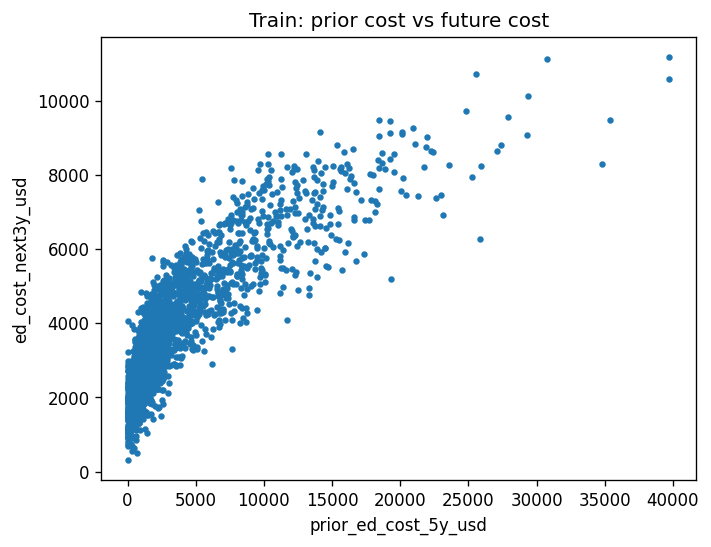


[DONE] Iter24 EDA + ablations complete.
Outputs written to: D:\AgentDs\agent_ds_healthcare\cache_iter24_eda_adm_receipt_v2\eda_outputs_iter24


In [29]:
# =========================
# Iter24 EDA + Ablation (one-cell)
# Focus: receipt parse integrity + feature injection audit + admissions (ed_visits_6m / emergent) signal
# =========================

from pathlib import Path
import re
import math
import numpy as np
import pandas as pd
from joblib import dump, load
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import matplotlib.pyplot as plt

# -------------------------
# 0) Paths / switches
# -------------------------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")

TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
TEST_CSV  = BASE_DIR / "ed_cost_test.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"
PDF_DIR = BASE_DIR / "receipts_pdf"

ADM_TRAIN = BASE_DIR / "admissions_train.csv"
ADM_TEST  = BASE_DIR / "admissions_test.csv"

CACHE_DIR = BASE_DIR / "cache_iter24_eda_adm_receipt_v2"
OUT_DIR   = CACHE_DIR / "eda_outputs_iter24"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

RECEIPT_LINEITEMS_CACHE = CACHE_DIR / "receipt_lineitems_v2.joblib"
RECEIPT_FEATURES_CACHE  = CACHE_DIR / "receipt_features_v2.joblib"
ADMISSIONS_FEATURES_CACHE = CACHE_DIR / "admissions_patient_features_v2.joblib"

FORCE_REPARSE_RECEIPTS = False
RUN_CATBOOST = True   # will auto-skip if catboost not installed
N_SPLITS = 5
SEED = 42

print(f"[paths] BASE_DIR={BASE_DIR}")
print(f"[paths] OUT_DIR={OUT_DIR}")
print(f"[paths] PDF_DIR exists={PDF_DIR.exists()}")

# -------------------------
# 1) Load core tables
# -------------------------
train = pd.read_csv(TRAIN_CSV)
test  = pd.read_csv(TEST_CSV)
patients = pd.read_csv(PATIENTS_CSV, dtype={"zip3": "string"})

train_full = train.merge(patients, on="patient_id", how="left")
test_full  = test.merge(patients, on="patient_id", how="left")

print(f"[info] train_full: {train_full.shape}  test_full: {test_full.shape}")

# Standardize dtypes for categoricals
for df in (train_full, test_full):
    for c in ["primary_chronic", "sex", "insurance", "zip3"]:
        if c in df.columns:
            df[c] = df[c].astype("string")

# Outlier definition you used
def is_outlier(df: pd.DataFrame) -> pd.Series:
    return (df["prior_ed_cost_5y_usd"] <= 50) & (df["prior_ed_visits_5y"] == 0)

train_full["is_outlier"] = is_outlier(train_full).astype(int)
test_full["is_outlier"]  = is_outlier(test_full).astype(int)

print(f"[info] outlier_n (train) = {train_full['is_outlier'].sum()} / {len(train_full)}")

# -------------------------
# 2) Robust receipt parsing (pdfplumber -> pypdf -> fitz)
# -------------------------
money_token_re = re.compile(r"^\$?[\d,]+\.\d{2}$")
code_re = re.compile(r"^[A-Z]?\d{4,5}$")   # 'G0378' or '99283' or '31500'

def safe_money(x):
    if x is None:
        return None
    s = str(x).strip().replace("$", "").replace(",", "")
    try:
        return float(s)
    except Exception:
        return None

def extract_text_pdf(path: Path):
    # Return (text, backend, err)
    # 1) pdfplumber
    try:
        import pdfplumber
        with pdfplumber.open(path) as pdf:
            text = "\n".join([(p.extract_text() or "") for p in pdf.pages])
        if text and text.strip():
            return text, "pdfplumber", None
    except Exception as e:
        err1 = repr(e)

    # 2) pypdf
    try:
        from pypdf import PdfReader
        reader = PdfReader(str(path))
        text = "\n".join([(p.extract_text() or "") for p in reader.pages])
        if text and text.strip():
            return text, "pypdf", None
    except Exception as e:
        err2 = repr(e)

    # 3) fitz (PyMuPDF)
    try:
        import fitz
        doc = fitz.open(str(path))
        text = "\n".join([p.get_text() for p in doc])
        doc.close()
        if text and text.strip():
            return text, "fitz", None
    except Exception as e:
        err3 = repr(e)

    return "", "fail", {"pdfplumber": err1 if "err1" in locals() else None,
                        "pypdf": err2 if "err2" in locals() else None,
                        "fitz": err3 if "err3" in locals() else None}

def parse_receipt_text(text: str):
    """
    Parse:
      - TOTAL (float)
      - line items: code, qty, unit, line_total
    """
    total = None
    items = []

    for ln in text.splitlines():
        ln = (ln or "").strip()
        if not ln:
            continue

        # TOTAL
        if ln.upper().startswith("TOTAL"):
            toks = ln.split()
            m = None
            if len(toks) >= 2:
                if money_token_re.match(toks[-1]):
                    total = safe_money(toks[-1])
                    continue
            m = re.search(r"TOTAL\s+([\d,]+\.\d{2})", ln, flags=re.I)
            if m:
                total = safe_money(m.group(1))
            continue

        toks = ln.split()
        if len(toks) < 5:
            continue

        code = toks[0]
        if not code_re.match(code):
            continue

        qty = toks[-3]
        unit = toks[-2]
        line_total = toks[-1]

        if not qty.isdigit():
            continue
        if not money_token_re.match(unit) or not money_token_re.match(line_total):
            continue

        unit_f = safe_money(unit)
        lt_f = safe_money(line_total)
        if unit_f is None or lt_f is None:
            continue

        items.append({
            "code": code,
            "qty": int(qty),
            "unit": unit_f,
            "line_total": lt_f,
        })

    return total, items

def load_or_parse_receipts(all_patient_ids, pdf_dir: Path, cache_path: Path, force=False):
    if cache_path.exists() and not force:
        obj = load(cache_path)
        if isinstance(obj, dict) and obj.get("version") == "v2" and "lineitems" in obj and "totals" in obj:
            print(f"[cache] Loaded receipt parse cache: {cache_path}")
            return obj["lineitems"], obj["totals"], obj["status"]
        else:
            print(f"[cache] Cache format mismatch -> reparsing: {cache_path}")

    rows = []
    totals_rows = []
    status_rows = []
    bad = 0

    all_patient_ids = list(map(int, all_patient_ids))
    n = len(all_patient_ids)

    for i, pid in enumerate(all_patient_ids, 1):
        pdf_path = pdf_dir / f"receipt_{pid}.pdf"
        if not pdf_path.exists():
            status_rows.append({"patient_id": pid, "parse_ok": 0, "backend": "missing", "error": "missing_pdf"})
            bad += 1
            continue

        text, backend, err = extract_text_pdf(pdf_path)
        if not text.strip():
            status_rows.append({"patient_id": pid, "parse_ok": 0, "backend": backend, "error": str(err)[:500]})
            bad += 1
            continue

        total, items = parse_receipt_text(text)
        if total is None or len(items) == 0:
            status_rows.append({"patient_id": pid, "parse_ok": 0, "backend": backend, "error": f"total={total}, n_items={len(items)}"})
            bad += 1
            continue

        totals_rows.append({"patient_id": pid, "pdf_total": total, "backend": backend})

        for it in items:
            rows.append({"patient_id": pid, **it})

        status_rows.append({"patient_id": pid, "parse_ok": 1, "backend": backend, "error": ""})

        if i % 250 == 0 or i == n:
            print(f"[receipt-parse] {i}/{n} done | bad={bad}")

    lineitems = pd.DataFrame(rows)
    totals = pd.DataFrame(totals_rows)
    status = pd.DataFrame(status_rows)

    dump({"version": "v2", "lineitems": lineitems, "totals": totals, "status": status}, cache_path)
    print(f"[cache] Wrote receipt parse cache: {cache_path} | bad={bad} | rows={len(lineitems)} | totals={len(totals)}")

    return lineitems, totals, status

# Parse all receipts for union(train,test)
all_ids = sorted(set(train_full["patient_id"].astype(int)) | set(test_full["patient_id"].astype(int)))
lineitems_df, totals_df, receipt_status_df = load_or_parse_receipts(all_ids, PDF_DIR, RECEIPT_LINEITEMS_CACHE, force=FORCE_REPARSE_RECEIPTS)

print(f"[info] parsed lineitems rows: {len(lineitems_df)} | patients_w_lines: {lineitems_df['patient_id'].nunique() if len(lineitems_df) else 0}")
print(f"[info] receipt parse OK rate: {receipt_status_df['parse_ok'].mean():.4f}")

# Receipt integrity vs prior cost
prior_cost_map = pd.concat([
    train_full[["patient_id", "prior_ed_cost_5y_usd"]],
    test_full[["patient_id", "prior_ed_cost_5y_usd"]],
], axis=0).drop_duplicates("patient_id").set_index("patient_id")["prior_ed_cost_5y_usd"]

totals_df = totals_df.copy()
totals_df["prior_cost"] = totals_df["patient_id"].map(prior_cost_map)
totals_df["abs_diff"] = (totals_df["pdf_total"] - totals_df["prior_cost"]).abs()

missing_total_ids = set(all_ids) - set(totals_df["patient_id"].astype(int).tolist())
print("\n=== RECEIPT TOTAL INTEGRITY ===")
print(f"missing_total_rate: {len(missing_total_ids) / len(all_ids):.4f}  (missing n={len(missing_total_ids)})")
print("abs_diff (overall) summary:")
print(totals_df["abs_diff"].describe(percentiles=[0.5,0.9,0.99]))

mismatch = totals_df[(totals_df["abs_diff"] > 1e-6) | totals_df["prior_cost"].isna()].copy()
mismatch.to_csv(OUT_DIR / "receipt_total_mismatches_iter24.csv", index=False)
if len(mismatch) or len(missing_total_ids):
    print(f"[write] {OUT_DIR/'receipt_total_mismatches_iter24.csv'}  mismatches={len(mismatch)}  missing_totals={len(missing_total_ids)}")

# -------------------------
# 3) Build receipt features (per code + category + price deflation/dispersion)
# -------------------------
def build_receipt_features(lineitems: pd.DataFrame, patients_df: pd.DataFrame):
    if lineitems is None or len(lineitems) == 0:
        return pd.DataFrame({"patient_id": patients_df["patient_id"].unique(), "pdf_parse_ok": 0})

    li = lineitems.copy()
    li["patient_id"] = li["patient_id"].astype(int)
    li["code"] = li["code"].astype("string")
    li["qty"] = li["qty"].astype(int)
    li["unit"] = li["unit"].astype(float)
    li["line_total"] = li["line_total"].astype(float)

    # attach insurance for deflation
    pat = patients_df[["patient_id", "insurance"]].copy()
    pat["patient_id"] = pat["patient_id"].astype(int)
    pat["insurance"] = pat["insurance"].astype("string")
    li = li.merge(pat, on="patient_id", how="left")

    # insurance+code median unit price
    med_unit = li.groupby(["insurance", "code"], dropna=False)["unit"].median()
    key = pd.MultiIndex.from_frame(li[["insurance", "code"]])
    li["unit_med_ins_code"] = med_unit.reindex(key).to_numpy()
    # fallback: overall code median
    med_code = li.groupby(["code"], dropna=False)["unit"].median()
    li.loc[li["unit_med_ins_code"].isna(), "unit_med_ins_code"] = li.loc[li["unit_med_ins_code"].isna(), "code"].map(med_code)

    li["expected_line_cost"] = li["unit_med_ins_code"] * li["qty"]
    li["unit_ratio"] = li["unit"] / (li["unit_med_ins_code"] + 1e-9)

    # Category map (tailored to your 18 codes)
    def code_to_cat(code: str) -> str:
        if code in {"99281","99282","99283","99284","99285"}:
            return "ed_em"
        if code in {"99291","99292"}:
            return "crit_care"
        if code in {"85025","87070","84484"}:
            return "lab"
        if code in {"71045","70450","74177"}:
            return "imaging"
        if code in {"G0378"}:
            return "obs"
        if code in {"31500","36556","36620","92950"}:
            return "severe_proc"
        return "other"

    li["cat"] = li["code"].astype(str).map(code_to_cat).astype("string")

    # patient-level base
    g = li.groupby("patient_id", dropna=False)
    base = pd.DataFrame({
        "patient_id": g.size().index,
        "pdf_n_line_items": g.size().values,
        "pdf_total_qty": g["qty"].sum().values,
        "pdf_total_line_cost": g["line_total"].sum().values,
        "pdf_n_unique_codes": g["code"].nunique().values,
        "pdf_unit_mean": g["unit"].mean().values,
        "pdf_unit_std": g["unit"].std(ddof=0).fillna(0).values,
        "pdf_expected_total": g["expected_line_cost"].sum().values,
        "pdf_price_index_ins_code": (g["line_total"].sum() / (g["expected_line_cost"].sum() + 1e-9)).values,
        "pdf_unit_ratio_std": g["unit_ratio"].std(ddof=0).fillna(0).values,
    })

    # per-code counts/costs/shares
    cnt = li.pivot_table(index="patient_id", columns="code", values="qty", aggfunc="sum", fill_value=0)
    cnt.columns = [f"pdf_cnt_code_{c}" for c in cnt.columns.astype(str)]
    cost = li.pivot_table(index="patient_id", columns="code", values="line_total", aggfunc="sum", fill_value=0.0)
    cost.columns = [f"pdf_cost_code_{c}" for c in cost.columns.astype(str)]
    share = cost.div(cost.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    share.columns = [c.replace("pdf_cost_code_", "pdf_share_code_") for c in cost.columns]

    # per-code unit stats
    unit_mean = li.pivot_table(index="patient_id", columns="code", values="unit", aggfunc="mean")
    unit_mean.columns = [f"pdf_unit_mean_{c}" for c in unit_mean.columns.astype(str)]
    unit_std = li.pivot_table(index="patient_id", columns="code", values="unit", aggfunc=lambda x: float(np.std(x, ddof=0)) if len(x) else 0.0)
    unit_std.columns = [f"pdf_unit_std_{c}" for c in unit_std.columns.astype(str)]
    unit_std = unit_std.fillna(0.0)

    # per-category costs/shares
    cat_cost = li.pivot_table(index="patient_id", columns="cat", values="line_total", aggfunc="sum", fill_value=0.0)
    cat_cost.columns = [f"pdf_cost_cat_{c}" for c in cat_cost.columns.astype(str)]
    cat_share = cat_cost.div(cat_cost.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    cat_share.columns = [c.replace("pdf_cost_cat_", "pdf_share_cat_") for c in cat_cost.columns]

    # additional severity flags
    severe_codes = {"31500","36556","36620","92950"}
    crit_codes = {"99291","99292"}
    li["is_severe"] = li["code"].astype(str).isin(severe_codes).astype(int)
    li["is_crit"] = li["code"].astype(str).isin(crit_codes).astype(int)
    sev = li.groupby("patient_id")[["is_severe","is_crit"]].max().rename(columns={"is_severe":"pdf_severe_any","is_crit":"pdf_crit_any"})

    # ED E/M level features (99281-99285)
    em_level_map = {"99281":1,"99282":2,"99283":3,"99284":4,"99285":5}
    li["em_level"] = li["code"].astype(str).map(em_level_map)
    em_g = li.dropna(subset=["em_level"]).groupby("patient_id")["em_level"]
    em_feat = pd.DataFrame({
        "pdf_em_level_mean": em_g.mean(),
        "pdf_em_level_max": em_g.max(),
        "pdf_em_level_min": em_g.min(),
        "pdf_em_lines": em_g.size(),
    }).fillna(0.0)

    feat = (base
            .set_index("patient_id")
            .join([cnt, cost, share, unit_mean, unit_std, cat_cost, cat_share, sev, em_feat], how="left")
            .fillna(0.0)
            .reset_index())

    feat["pdf_parse_ok"] = 1
    return feat

if RECEIPT_FEATURES_CACHE.exists() and not FORCE_REPARSE_RECEIPTS:
    rf = load(RECEIPT_FEATURES_CACHE)
    if isinstance(rf, dict) and rf.get("version") == "v2" and "receipt_features" in rf:
        receipt_feat = rf["receipt_features"]
        print(f"[cache] Loaded receipt features: {RECEIPT_FEATURES_CACHE} | shape={receipt_feat.shape}")
    else:
        receipt_feat = build_receipt_features(lineitems_df, pd.concat([train_full[["patient_id","insurance"]], test_full[["patient_id","insurance"]]]))
        dump({"version":"v2","receipt_features": receipt_feat}, RECEIPT_FEATURES_CACHE)
        print(f"[cache] Wrote receipt features: {RECEIPT_FEATURES_CACHE} | shape={receipt_feat.shape}")
else:
    receipt_feat = build_receipt_features(lineitems_df, pd.concat([train_full[["patient_id","insurance"]], test_full[["patient_id","insurance"]]]))
    dump({"version":"v2","receipt_features": receipt_feat}, RECEIPT_FEATURES_CACHE)
    print(f"[cache] Wrote receipt features: {RECEIPT_FEATURES_CACHE} | shape={receipt_feat.shape}")

# Merge receipt features (outer to keep all)
train_full = train_full.merge(receipt_feat, on="patient_id", how="left")
test_full  = test_full.merge(receipt_feat, on="patient_id", how="left")

# For truly missing receipts (parse fail), fill parse_ok=0 and numeric=0
for df in (train_full, test_full):
    if "pdf_parse_ok" not in df.columns:
        df["pdf_parse_ok"] = 0
    df["pdf_parse_ok"] = df["pdf_parse_ok"].fillna(0).astype(int)

# -------------------------
# 4) Admissions patient-level features (with "trend" features)
# -------------------------
def build_admissions_patient_features(adm_train_path: Path, adm_test_path: Path):
    adm_tr = pd.read_csv(adm_train_path)
    adm_te = pd.read_csv(adm_test_path)

    # remove target leak from train side for feature building (readmit_30d not used here)
    if "readmit_30d" in adm_tr.columns:
        adm_tr_feat = adm_tr.drop(columns=["readmit_30d"])
    else:
        adm_tr_feat = adm_tr

    adm = pd.concat([adm_tr_feat, adm_te], axis=0, ignore_index=True)
    adm["patient_id"] = adm["patient_id"].astype(int)
    adm["primary_dx"] = adm["primary_dx"].astype("string")

    # basic aggregations
    g = adm.groupby("patient_id", dropna=False)
    feat = pd.DataFrame({
        "patient_id": g.size().index,
        "adm_n": g.size().values,
        "adm_los_sum": g["los_days"].sum().values,
        "adm_los_mean": g["los_days"].mean().values,
        "adm_los_max": g["los_days"].max().values,
        "adm_charlson_mean": g["charlson_band"].mean().values,
        "adm_charlson_max": g["charlson_band"].max().values,
        "adm_edvis6m_sum": g["ed_visits_6m"].sum().values,
        "adm_edvis6m_mean": g["ed_visits_6m"].mean().values,
        "adm_edvis6m_max": g["ed_visits_6m"].max().values,
        "adm_emergent_n": g["acuity_emergent"].sum().values,
        "adm_emergent_rate": g["acuity_emergent"].mean().values,
        "adm_discharge_wd_mean": g["discharge_weekday"].mean().values,
    })

    # dx counts
    dx_cnt = adm.pivot_table(index="patient_id", columns="primary_dx", values="admission_id", aggfunc="count", fill_value=0)
    dx_cnt.columns = [f"adm_dx_cnt_{c}" for c in dx_cnt.columns.astype(str)]

    # "last admission" features by admission_id (proxy of recency)
    last = adm.sort_values("admission_id").groupby("patient_id").tail(1).set_index("patient_id")
    last_feat = last[["los_days","acuity_emergent","charlson_band","ed_visits_6m","discharge_weekday","primary_dx"]].copy()
    last_feat.rename(columns={
        "los_days":"adm_last_los",
        "acuity_emergent":"adm_last_emergent",
        "charlson_band":"adm_last_charlson",
        "ed_visits_6m":"adm_last_edvis6m",
        "discharge_weekday":"adm_last_discharge_wd",
        "primary_dx":"adm_last_dx",
    }, inplace=True)
    last_feat["adm_last_dx"] = last_feat["adm_last_dx"].astype("string")

    # combine
    feat = feat.set_index("patient_id").join(dx_cnt, how="left").join(last_feat, how="left").fillna(0).reset_index()

    return feat

if ADMISSIONS_FEATURES_CACHE.exists():
    obj = load(ADMISSIONS_FEATURES_CACHE)
    if isinstance(obj, dict) and obj.get("version") == "v2" and "adm_feat" in obj:
        adm_feat = obj["adm_feat"]
        print(f"[cache] Loaded admissions patient features: {ADMISSIONS_FEATURES_CACHE} | shape={adm_feat.shape}")
    else:
        adm_feat = build_admissions_patient_features(ADM_TRAIN, ADM_TEST)
        dump({"version":"v2","adm_feat": adm_feat}, ADMISSIONS_FEATURES_CACHE)
        print(f"[cache] Wrote admissions patient features: {ADMISSIONS_FEATURES_CACHE} | shape={adm_feat.shape}")
else:
    adm_feat = build_admissions_patient_features(ADM_TRAIN, ADM_TEST)
    dump({"version":"v2","adm_feat": adm_feat}, ADMISSIONS_FEATURES_CACHE)
    print(f"[cache] Wrote admissions patient features: {ADMISSIONS_FEATURES_CACHE} | shape={adm_feat.shape}")

# merge
train_full = train_full.merge(adm_feat, on="patient_id", how="left")
test_full  = test_full.merge(adm_feat, on="patient_id", how="left")

# Trend feature: recent 6m ED visits vs 5y average (expected 6m = prior_visits_5y/10)
for df in (train_full, test_full):
    df["adm_edvis6m_rise"] = df.get("adm_edvis6m_max", 0) - (df["prior_ed_visits_5y"] / 10.0)
    df["adm_edvis6m_ratio"] = (df.get("adm_edvis6m_max", 0) + 1e-3) / ((df["prior_ed_visits_5y"] / 10.0) + 1e-3)

# -------------------------
# 5) Quick EDA: residual correlation for admissions features
# -------------------------
y = train_full["ed_cost_next3y_usd"].astype(float).values
# baseline: group median by (primary_chronic, insurance, prior_cost decile)
tmp = train_full.copy()
tmp["cost_decile"] = pd.qcut(tmp["prior_ed_cost_5y_usd"].rank(method="first"), 10, labels=False)
grp = ["primary_chronic", "insurance", "cost_decile"]
med_map = tmp.groupby(grp, dropna=False)["ed_cost_next3y_usd"].median()
tmp["_baseline"] = pd.MultiIndex.from_frame(tmp[grp]).map(med_map).astype(float)
tmp["_resid"] = tmp["ed_cost_next3y_usd"] - tmp["_baseline"]

adm_cols = [c for c in train_full.columns if c.startswith("adm_") and c not in ["adm_last_dx"]]
corr_rows = []
for c in adm_cols:
    s = train_full[c]
    if s.isna().all():
        continue
    # Spearman via rank-corr
    x = s.fillna(s.median()).astype(float)
    rho_t = pd.Series(x).corr(pd.Series(y), method="spearman")
    rho_r = pd.Series(x).corr(tmp["_resid"], method="spearman")
    corr_rows.append([c, rho_t, rho_r, float(s.isna().mean()), float(s.mean()), float(s.std(ddof=0))])

corr_df = pd.DataFrame(corr_rows, columns=["feature","spearman_target","spearman_resid","missing_rate","mean","std"])
corr_df.sort_values("spearman_resid", ascending=False).head(25).to_csv(OUT_DIR / "adm_feature_correlations_iter24.csv", index=False)
print("\n=== TOP 10 admissions features by Spearman(residual) ===")
print(corr_df.sort_values("spearman_resid", ascending=False).head(10).to_string(index=False))

# -------------------------
# 6) Feature Injection Audit utilities
# -------------------------
CAT_COLS_CORE = ["primary_chronic","sex","insurance","zip3"]
NUM_COLS_CORE = ["age","prior_ed_visits_5y","prior_ed_cost_5y_usd","is_outlier"]

def prep_X(df: pd.DataFrame, use_cols, cat_cols):
    X = df[use_cols].copy()
    for c in cat_cols:
        if c in X.columns:
            X[c] = X[c].astype("string").fillna("UNK").astype("category")
    return X

def feature_audit(name, cols, df_train):
    cols = list(cols)
    nunique = df_train[cols].nunique(dropna=False)
    const_cols = nunique[nunique <= 1].index.tolist()
    miss_rate = df_train[cols].isna().mean().sort_values(ascending=False)
    print(f"\n[feature-audit] {name}: n_cols={len(cols)} | const_cols={len(const_cols)} | top_missing:")
    print(miss_rate.head(8).to_string())
    if const_cols:
        print("  const cols (first 15):", const_cols[:15])
    return const_cols

# Receipt columns bucket
receipt_cols = [c for c in train_full.columns if c.startswith("pdf_")]
# Admissions columns bucket (excluding categorical adm_last_dx handled separately)
adm_num_cols = [c for c in train_full.columns if c.startswith("adm_") and c not in ["adm_last_dx"]]
adm_cat_cols = ["adm_last_dx"] if "adm_last_dx" in train_full.columns else []

# -------------------------
# 7) CV Ablations (LightGBM + optional CatBoost)
# -------------------------
def make_strata(df: pd.DataFrame):
    # keep it simple but stable: chronic + insurance + outlier + prior_cost decile
    x = df.copy()
    x["cost_dec"] = pd.qcut(x["prior_ed_cost_5y_usd"].rank(method="first"), 10, labels=False)
    return (x["primary_chronic"].astype(str) + "_" +
            x["insurance"].astype(str) + "_" +
            x["is_outlier"].astype(str) + "_" +
            x["cost_dec"].astype(str))

def cv_lgb(name, cols, cat_cols):
    X = prep_X(train_full, cols, cat_cols)
    y = train_full["ed_cost_next3y_usd"].astype(float).values
    out_mask = train_full["is_outlier"].values.astype(bool)

    strata = make_strata(train_full)
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    oof = np.zeros(len(train_full), dtype=float)

    fold_mae = []
    fold_out_mae = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, strata), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        model = lgb.LGBMRegressor(
            n_estimators=12000,
            learning_rate=0.02,
            num_leaves=64,
            min_data_in_leaf=30,
            subsample=0.8,
            subsample_freq=1,
            colsample_bytree=0.8,
            reg_lambda=2.0,
            random_state=SEED + fold,
            objective="regression_l1",
            n_jobs=-1,
        )

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="mae",
            callbacks=[lgb.early_stopping(stopping_rounds=300, verbose=False)]
        )

        pred = model.predict(X_va, num_iteration=model.best_iteration_)
        oof[va_idx] = pred

        mae = mean_absolute_error(y_va, pred)
        fold_mae.append(mae)

        out_idx = va_idx[out_mask[va_idx]]
        out_mae = mean_absolute_error(y[out_idx], oof[out_idx]) if len(out_idx) else np.nan
        fold_out_mae.append(out_mae)

        print(f"  [{name}] fold {fold}: MAE={mae:.3f} | out_n={len(out_idx):3d} | out_MAE={out_mae:.3f} | best_iter={model.best_iteration_}")

    oof_mae = mean_absolute_error(y, oof)
    out_oof_mae = mean_absolute_error(y[out_mask], oof[out_mask]) if out_mask.any() else np.nan
    return {
        "model": name,
        "oof_mae": oof_mae,
        "mae_mean": float(np.mean(fold_mae)),
        "mae_std": float(np.std(fold_mae)),
        "out_oof_mae": out_oof_mae,
        "n_features": len(cols),
        "n_cat": len(cat_cols),
    }

def cv_catboost(name, cols, cat_cols):
    try:
        from catboost import CatBoostRegressor
    except Exception as e:
        print(f"[catboost] not available -> skip ({e})")
        return None

    X = train_full[cols].copy()
    y = train_full["ed_cost_next3y_usd"].astype(float).values
    out_mask = train_full["is_outlier"].values.astype(bool)

    # CatBoost wants string/object for categorical
    cat_idx = []
    for c in cat_cols:
        if c in X.columns:
            X[c] = X[c].astype("string").fillna("UNK")
            cat_idx.append(X.columns.get_loc(c))

    strata = make_strata(train_full)
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    oof = np.zeros(len(train_full), dtype=float)
    fold_mae, fold_out_mae = [], []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, strata), 1):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y[tr_idx], y[va_idx]

        model = CatBoostRegressor(
            loss_function="MAE",
            eval_metric="MAE",
            iterations=20000,
            learning_rate=0.03,
            depth=8,
            l2_leaf_reg=6.0,
            random_seed=SEED + fold,
            od_type="Iter",
            od_wait=300,
            verbose=False,
        )

        model.fit(X_tr, y_tr, cat_features=cat_idx, eval_set=(X_va, y_va), use_best_model=True)

        pred = model.predict(X_va)
        oof[va_idx] = pred

        mae = mean_absolute_error(y_va, pred)
        fold_mae.append(mae)

        out_idx = va_idx[out_mask[va_idx]]
        out_mae = mean_absolute_error(y[out_idx], oof[out_idx]) if len(out_idx) else np.nan
        fold_out_mae.append(out_mae)

        print(f"  [{name}] fold {fold}: MAE={mae:.3f} | out_n={len(out_idx):3d} | out_MAE={out_mae:.3f}")

    oof_mae = mean_absolute_error(y, oof)
    out_oof_mae = mean_absolute_error(y[out_mask], oof[out_mask]) if out_mask.any() else np.nan
    return {
        "model": name,
        "oof_mae": oof_mae,
        "mae_mean": float(np.mean(fold_mae)),
        "mae_std": float(np.std(fold_mae)),
        "out_oof_mae": out_oof_mae,
        "n_features": len(cols),
        "n_cat": len(cat_cols),
    }

# Define ablation feature sets
core_cols = CAT_COLS_CORE + NUM_COLS_CORE

# FIX: Remove ["pdf_parse_ok"] because it is already inside receipt_cols (which captures all "pdf_*")
A_cols = core_cols + [c for c in receipt_cols if c in train_full.columns]

# FIX: Same here
B_cols = core_cols + [c for c in receipt_cols if c in train_full.columns] + adm_num_cols + adm_cat_cols

# "C" = B plus admissions trend features already in adm_num_cols
C_cols = B_cols

# Feature audit (to catch iter23-like "identical features" bugs)
const_A = feature_audit("A(core+receipt)", A_cols, train_full)
const_B = feature_audit("B(+admissions)", B_cols, train_full)
print("\n[feature-diff] B \\ A (first 30):", sorted(set(B_cols) - set(A_cols))[:30])
print("[feature-diff] A \\ B (first 10):", sorted(set(A_cols) - set(B_cols))[:10])

# Run LightGBM CV
print("\n=== CV ABLATIONS (Iter24, LightGBM L1) ===")
res = []
res.append(cv_lgb("A_core+receipt_LGB", A_cols, CAT_COLS_CORE))
res.append(cv_lgb("B_add_admissions_LGB", B_cols, CAT_COLS_CORE + adm_cat_cols))

# Optional CatBoost
if RUN_CATBOOST:
    print("\n=== CV ABLATIONS (Iter24, CatBoost MAE) ===")
    cbA = cv_catboost("A_core+receipt_Cat", A_cols, CAT_COLS_CORE)
    if cbA: res.append(cbA)
    cbB = cv_catboost("B_add_admissions_Cat", B_cols, CAT_COLS_CORE + adm_cat_cols)
    if cbB: res.append(cbB)

res_df = pd.DataFrame(res).sort_values("oof_mae")
res_df.to_csv(OUT_DIR / "ablation_results_iter24.csv", index=False)

print("\n=== SUMMARY (sorted by OOF MAE) ===")
print(res_df.to_string(index=False))
print(f"\n[write] {OUT_DIR/'ablation_results_iter24.csv'}")

# -------------------------
# 8) Minimal plots (optional)
# -------------------------
# Scatter prior vs target for sanity
plt.figure()
plt.scatter(train_full["prior_ed_cost_5y_usd"], train_full["ed_cost_next3y_usd"], s=8)
plt.xlabel("prior_ed_cost_5y_usd")
plt.ylabel("ed_cost_next3y_usd")
plt.title("Train: prior cost vs future cost")
plt.show()

print("\n[DONE] Iter24 EDA + ablations complete.")
print(f"Outputs written to: {OUT_DIR}")


## EDA 2.5

[paths] BASE_DIR=D:\AgentDs\agent_ds_healthcare
[paths] OUT_DIR=D:\AgentDs\agent_ds_healthcare\cache_iter25_sublinear_baseline_eda
[paths] RECEIPT_CACHE=D:\AgentDs\agent_ds_healthcare\cache_iter10\receipts_parsed.joblib
[info] expected receipt code universe=18 -> ['31500', '36556', '36620', '70450', '71045', '74177', '84484', '85025', '87070', '92950', '99281', '99282', '99283', '99284', '99285', '99291', '99292', 'G0378']
[info] train_full=(2000, 9)  test_full=(2000, 8)
[info] outlier_n=85 / 2000
[debug] receipt cache type=<class 'dict'>
[debug] receipt cache dict keys sample=[144, 89, 112, 132, 82]
[receipt-cache] treating as patient_dict (int_like=1.00)
[info] receipt_feat shape=(4000, 61) | receipt_lines shape=(27864, 3)
[receipt-check] missing_rate(sum_items_total)=0.0000
[receipt-check] match_rate(valid only)=1.0000 | match_rate(all)=1.0000 (tol=0.01)
[receipt-check] absdiff (valid only) summary:
count    2.000000e+03
mean     2.150884e-13
std      5.212289e-13
min      0.000000e

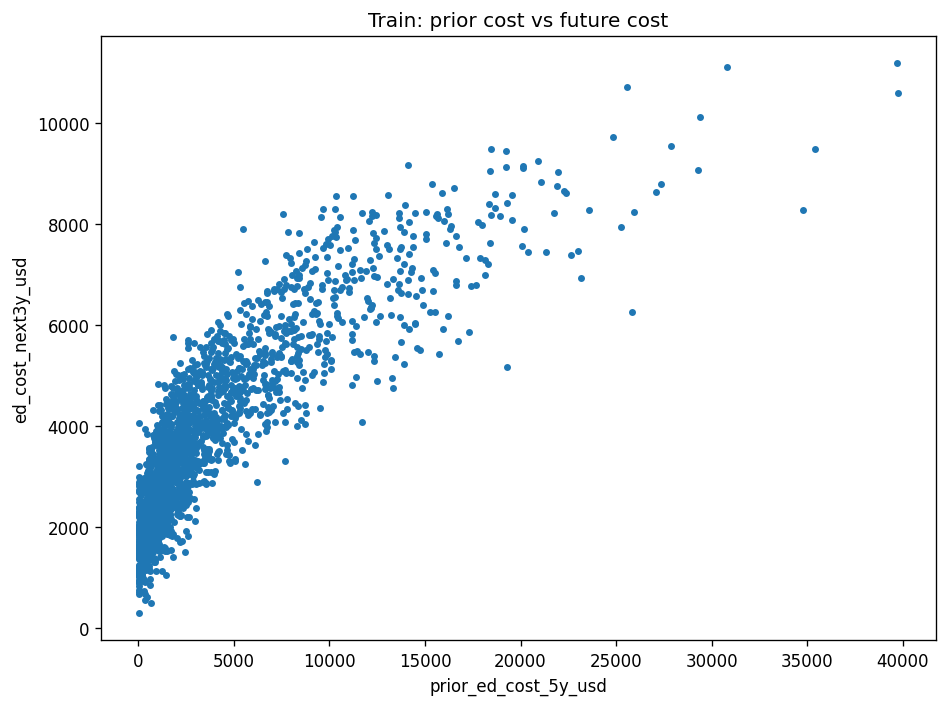

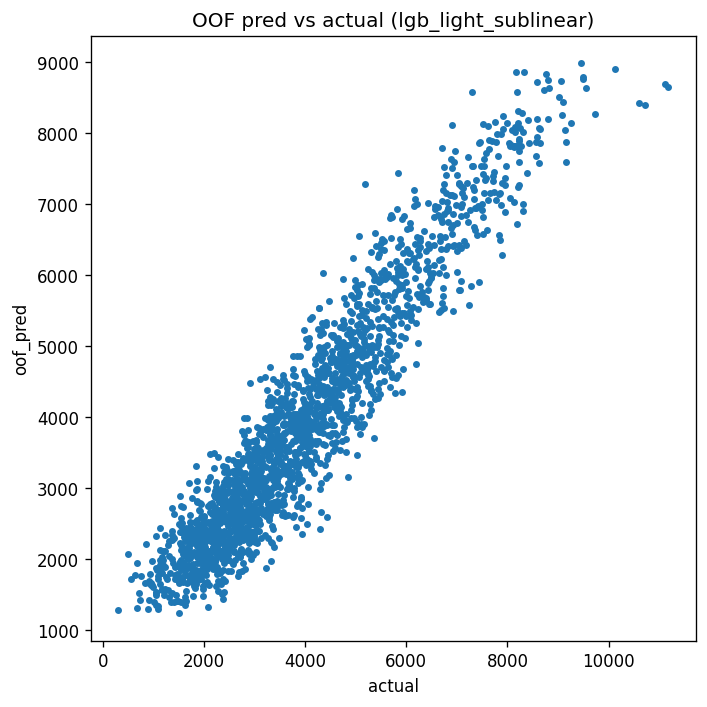


[DONE] Iter25 EDA finished.


In [ ]:
# Iter25 (FIXED): Sublinear-baseline EDA + robust receipt-cache handling
# Copy-paste into ONE Jupyter cell and run.

import re
import math
import numpy as np
import pandas as pd
from pathlib import Path
from joblib import load
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt

# Optional LightGBM (won't crash if missing)
try:
    import lightgbm as lgb
    HAS_LGB = True
    try:
        from lightgbm.callback import early_stopping as lgb_early_stopping
    except Exception:
        lgb_early_stopping = None
except Exception:
    HAS_LGB = False
    lgb = None
    lgb_early_stopping = None

# -----------------------
# Paths (edit if needed)
# -----------------------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")

TRAIN_CSV = BASE_DIR / "ed_cost_train.csv"
TEST_CSV  = BASE_DIR / "ed_cost_test.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"

ADM_TRAIN = BASE_DIR / "admissions_train.csv"
ADM_TEST  = BASE_DIR / "admissions_test.csv"

# Receipt cache (your iter10)
RECEIPT_CACHE = BASE_DIR / "cache_iter10" / "receipts_parsed.joblib"

OUT_DIR = BASE_DIR / "cache_iter25_sublinear_baseline_eda"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS = 5
TOL = 1e-2  # 1 cent tolerance for money comparisons

print(f"[paths] BASE_DIR={BASE_DIR}")
print(f"[paths] OUT_DIR={OUT_DIR}")
print(f"[paths] RECEIPT_CACHE={RECEIPT_CACHE}")

# -----------------------
# Helpers
# -----------------------
def safe_read_csv(path: Path):
    if path is None:
        return None
    if not path.exists():
        print(f"[warn] file not found: {path} (skipping)")
        return None
    return pd.read_csv(path)

def can_int(x) -> bool:
    try:
        int(str(x).strip())
        return True
    except Exception:
        return False

def normalize_code(x):
    if x is None:
        return None
    try:
        if isinstance(x, (int, np.integer)):
            return str(int(x))
        if isinstance(x, float) and np.isfinite(x) and float(x).is_integer():
            return str(int(x))
    except Exception:
        pass
    s = str(x).strip()
    # remove trailing ".0" if came from float-like rendering
    if re.fullmatch(r"\d+\.0", s):
        s = s.split(".")[0]
    return s if s else None

def parse_amount(x):
    if x is None:
        return np.nan
    try:
        # strip currency symbols/commas if any
        if isinstance(x, str):
            xs = x.strip().replace(",", "").replace("$", "")
            return float(xs)
        return float(x)
    except Exception:
        return np.nan

def infer_col(df: pd.DataFrame, candidates):
    """Find a column by exact match (case-insensitive) or substring match."""
    if df is None or df.empty:
        return None
    cols = list(df.columns)
    low = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in low:
            return low[cand.lower()]
    # substring heuristic
    for cand in candidates:
        for c in cols:
            if cand.lower() in str(c).lower():
                return c
    return None

# -----------------------
# Known code sets (from your EDA)
# -----------------------
ED_EM = {"99281","99282","99283","99284","99285"}
CRIT  = {"99291","99292"}
SEVERE_PROC = {"31500","92950","36556","36620"}  # intub, CPR, CVC, art line
IMAGING = {"70450","74177","71045"}              # CT head, CT A/P, CXR
LAB = {"85025","87070","84484"}                  # CBC, culture, troponin
OBS = {"G0378"}

ALL_CODES = sorted(list(ED_EM | CRIT | SEVERE_PROC | IMAGING | LAB | OBS))
print(f"[info] expected receipt code universe={len(ALL_CODES)} -> {ALL_CODES}")

# -----------------------
# Load base tables
# -----------------------
train = safe_read_csv(TRAIN_CSV)
test  = safe_read_csv(TEST_CSV)
patients = safe_read_csv(PATIENTS_CSV)

assert train is not None and test is not None and patients is not None, "Missing required CSVs."

# standardize dtypes
for df in (train, test, patients):
    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce").astype(int)

# zip3: keep leading zeros if present
if "zip3" in patients.columns:
    patients["zip3"] = patients["zip3"].astype(str)
    patients["zip3"] = patients["zip3"].str.replace(r"\.0$", "", regex=True)
    patients.loc[patients["zip3"].str.lower().isin(["nan","none"]), "zip3"] = "UNK"
    # if numeric-like, pad
    patients["zip3"] = patients["zip3"].apply(lambda s: s.zfill(3) if s.isdigit() else s)

train_full = train.merge(patients, on="patient_id", how="left")
test_full  = test.merge(patients, on="patient_id", how="left")

print(f"[info] train_full={train_full.shape}  test_full={test_full.shape}")

# Outlier definition (your team's)
train_full["is_outlier"] = ((train_full["prior_ed_cost_5y_usd"] <= 50.0) & (train_full["prior_ed_visits_5y"] == 0)).astype(int)
outlier_n = int(train_full["is_outlier"].sum())
print(f"[info] outlier_n={outlier_n} / {len(train_full)}")

patient_ids_all = pd.concat([train_full["patient_id"], test_full["patient_id"]]).astype(int).unique()
patient_ids_all = np.sort(patient_ids_all)

# -----------------------
# Receipt cache loading (robust to multiple formats)
# -----------------------
def build_receipt_features_from_patient_dict(patient_dict: dict, patient_ids_all: np.ndarray):
    rows = []
    line_rows = []

    CODE_KEYS = ["code", "cpt", "hcpcs", "billing_code", "service_code"]
    AMT_KEYS  = ["amount", "line_total", "line_total_usd", "total", "charge", "lineTotal"]

    def safe_items(obj):
        if not isinstance(obj, dict):
            return []
        items = obj.get("items", [])
        return items if isinstance(items, list) else []

    for pid, obj in patient_dict.items():
        if not can_int(pid):
            continue
        pid_int = int(str(pid).strip())

        items = safe_items(obj)
        codes, amounts = [], []

        # also grab header total if present (for debugging only)
        header_total = np.nan
        if isinstance(obj, dict):
            header_total = parse_amount(obj.get("pdf_total", np.nan))

        for it in items:
            if not isinstance(it, dict):
                continue

            code = None
            for k in CODE_KEYS:
                if k in it:
                    code = normalize_code(it.get(k))
                    break
            amt = np.nan
            for k in AMT_KEYS:
                if k in it:
                    amt = parse_amount(it.get(k))
                    break

            if code is None:
                continue
            codes.append(code)
            amounts.append(amt)
            line_rows.append({"patient_id": pid_int, "code": code, "amount": amt})

        total_sum = float(np.nansum(amounts)) if len(amounts) else 0.0
        n_lines = int(len(codes))
        n_unique = int(len(set(codes)))

        # counts and costs per known code
        cnt = {f"pdf_cnt_code_{c}": 0 for c in ALL_CODES}
        cost = {f"pdf_cost_code_{c}": 0.0 for c in ALL_CODES}
        for c, a in zip(codes, amounts):
            if c in ALL_CODES:
                cnt[f"pdf_cnt_code_{c}"] += 1
                if np.isfinite(a):
                    cost[f"pdf_cost_code_{c}"] += float(a)

        def sum_cost(code_set):
            s = 0.0
            for c, a in zip(codes, amounts):
                if c in code_set and np.isfinite(a):
                    s += float(a)
            return s

        cost_em = sum_cost(ED_EM)
        cost_crit = sum_cost(CRIT)
        cost_sev = sum_cost(SEVERE_PROC)
        cost_img = sum_cost(IMAGING)
        cost_lab = sum_cost(LAB)
        cost_obs = sum_cost(OBS)
        cost_other = max(0.0, total_sum - (cost_em + cost_crit + cost_sev + cost_img + cost_lab + cost_obs))

        def share(x):
            return float(x / total_sum) if total_sum > 0 else 0.0

        # E/M levels
        em_levels = []
        for c in codes:
            if c in ED_EM and len(c) == 5 and c[-1].isdigit():
                em_levels.append(int(c[-1]))
        em_levels = np.array(em_levels, dtype=float)

        # entropy over all codes in this receipt (not only known codes)
        ent = 0.0
        if total_sum > 0:
            tmp = {}
            for c, a in zip(codes, amounts):
                if not np.isfinite(a):
                    continue
                tmp[c] = tmp.get(c, 0.0) + float(a)
            probs = np.array([v / total_sum for v in tmp.values() if v > 0], dtype=float)
            probs = probs[probs > 0]
            if len(probs):
                ent = float(-(probs * np.log(probs)).sum())

        row = {
            "patient_id": pid_int,
            "pdf_total_sum_items": total_sum,
            "pdf_total_header": header_total,
            "pdf_n_line_items": n_lines,
            "pdf_n_unique_codes": n_unique,
            "pdf_cost_ed_em": cost_em,
            "pdf_cost_crit": cost_crit,
            "pdf_cost_severe_proc": cost_sev,
            "pdf_cost_imaging": cost_img,
            "pdf_cost_lab": cost_lab,
            "pdf_cost_obs": cost_obs,
            "pdf_cost_other": cost_other,
            "pdf_share_ed_em": share(cost_em),
            "pdf_share_crit": share(cost_crit),
            "pdf_share_severe_proc": share(cost_sev),
            "pdf_share_imaging": share(cost_img),
            "pdf_share_lab": share(cost_lab),
            "pdf_share_obs": share(cost_obs),
            "pdf_share_other": share(cost_other),
            "pdf_has_crit": int(any(c in CRIT for c in codes)),
            "pdf_has_severe_proc": int(any(c in SEVERE_PROC for c in codes)),
            "pdf_em_level_mean": float(np.mean(em_levels)) if len(em_levels) else 0.0,
            "pdf_em_level_max": float(np.max(em_levels)) if len(em_levels) else 0.0,
            "pdf_em_high_frac": float(np.mean(em_levels >= 4)) if len(em_levels) else 0.0,
            "pdf_code_cost_entropy": ent,
        }
        row.update(cnt)
        row.update(cost)
        rows.append(row)

    feat = pd.DataFrame(rows)
    lines = pd.DataFrame(line_rows)

    # guarantee required columns exist (even if empty)
    required = ["patient_id", "pdf_total_sum_items"]
    for c in required:
        if c not in feat.columns:
            feat[c] = pd.Series(dtype=float)

    # ensure all patients represented
    base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
    feat = base.merge(feat, on="patient_id", how="left")
    return feat, lines

def build_receipt_features_from_lineitems_df(lineitems: pd.DataFrame, patient_ids_all: np.ndarray):
    df = lineitems.copy()
    pid_col = infer_col(df, ["patient_id", "patient"])
    code_col = infer_col(df, ["code", "cpt", "hcpcs"])
    amt_col  = infer_col(df, ["amount", "line_total", "line total", "line_total_usd", "charge", "total"])

    if pid_col is None or code_col is None or amt_col is None:
        print("[warn] Could not infer columns in lineitems_df. Columns are:")
        print(df.columns.tolist())
        # fallback empty
        base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
        base["pdf_total_sum_items"] = np.nan
        return base, pd.DataFrame(columns=["patient_id","code","amount"])

    df = df[[pid_col, code_col, amt_col]].rename(columns={pid_col:"patient_id", code_col:"code", amt_col:"amount"})
    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")
    df = df.dropna(subset=["patient_id"])
    df["patient_id"] = df["patient_id"].astype(int)

    df["code"] = df["code"].apply(normalize_code)
    df["amount"] = df["amount"].apply(parse_amount)
    df = df.dropna(subset=["code"])
    # keep amounts even if NaN for counting; but for sum we ignore NaN
    lines = df.copy()

    # totals
    g = df.groupby("patient_id", dropna=False)
    feat = pd.DataFrame({"patient_id": g.size().index.astype(int)})
    feat["pdf_total_sum_items"] = g["amount"].sum(min_count=1).fillna(0.0).values
    feat["pdf_n_line_items"] = g.size().values.astype(int)
    feat["pdf_n_unique_codes"] = g["code"].nunique().values.astype(int)

    # per-code counts/costs (known codes only)
    ct = pd.crosstab(df["patient_id"], df["code"])
    ct = ct.reindex(columns=ALL_CODES, fill_value=0)
    ct.columns = [f"pdf_cnt_code_{c}" for c in ct.columns]

    cost = df.pivot_table(index="patient_id", columns="code", values="amount", aggfunc="sum", fill_value=0.0)
    cost = cost.reindex(columns=ALL_CODES, fill_value=0.0)
    cost.columns = [f"pdf_cost_code_{c}" for c in cost.columns]

    feat = feat.set_index("patient_id").join(ct, how="left").join(cost, how="left").fillna(0.0).reset_index()

    # category costs
    def sum_by_codes(code_set, out_col):
        sub = df[df["code"].isin(code_set)].groupby("patient_id")["amount"].sum(min_count=1)
        return sub.rename(out_col)

    cost_em   = sum_by_codes(ED_EM, "pdf_cost_ed_em")
    cost_crit = sum_by_codes(CRIT, "pdf_cost_crit")
    cost_sev  = sum_by_codes(SEVERE_PROC, "pdf_cost_severe_proc")
    cost_img  = sum_by_codes(IMAGING, "pdf_cost_imaging")
    cost_lab  = sum_by_codes(LAB, "pdf_cost_lab")
    cost_obs  = sum_by_codes(OBS, "pdf_cost_obs")

    feat = feat.set_index("patient_id")
    for s in [cost_em, cost_crit, cost_sev, cost_img, cost_lab, cost_obs]:
        feat = feat.join(s, how="left")
    feat = feat.fillna(0.0)

    total = feat["pdf_total_sum_items"].values.astype(float)
    feat["pdf_cost_other"] = np.maximum(0.0, total - (
        feat["pdf_cost_ed_em"] + feat["pdf_cost_crit"] + feat["pdf_cost_severe_proc"] +
        feat["pdf_cost_imaging"] + feat["pdf_cost_lab"] + feat["pdf_cost_obs"]
    ))

    def share(series):
        return np.where(total > 0, series.values.astype(float) / total, 0.0)

    feat["pdf_share_ed_em"] = share(feat["pdf_cost_ed_em"])
    feat["pdf_share_crit"]  = share(feat["pdf_cost_crit"])
    feat["pdf_share_severe_proc"] = share(feat["pdf_cost_severe_proc"])
    feat["pdf_share_imaging"] = share(feat["pdf_cost_imaging"])
    feat["pdf_share_lab"] = share(feat["pdf_cost_lab"])
    feat["pdf_share_obs"] = share(feat["pdf_cost_obs"])
    feat["pdf_share_other"] = share(feat["pdf_cost_other"])

    # flags
    feat["pdf_has_crit"] = (feat[[f"pdf_cnt_code_{c}" for c in CRIT if f"pdf_cnt_code_{c}" in feat.columns]].sum(axis=1) > 0).astype(int)
    feat["pdf_has_severe_proc"] = (feat[[f"pdf_cnt_code_{c}" for c in SEVERE_PROC if f"pdf_cnt_code_{c}" in feat.columns]].sum(axis=1) > 0).astype(int)

    # E/M levels stats
    em_df = df[df["code"].isin(ED_EM)].copy()
    if len(em_df):
        em_df["lvl"] = em_df["code"].apply(lambda s: int(s[-1]) if isinstance(s, str) and len(s)==5 and s[-1].isdigit() else np.nan)
        em_g = em_df.groupby("patient_id")["lvl"]
        feat["pdf_em_level_mean"] = em_g.mean().reindex(feat.index).fillna(0.0).values
        feat["pdf_em_level_max"] = em_g.max().reindex(feat.index).fillna(0.0).values
        feat["pdf_em_high_frac"] = em_g.apply(lambda x: float(np.mean(np.array(x)>=4)) if len(x) else 0.0).reindex(feat.index).fillna(0.0).values
    else:
        feat["pdf_em_level_mean"] = 0.0
        feat["pdf_em_level_max"] = 0.0
        feat["pdf_em_high_frac"] = 0.0

    # entropy over known-code costs (works fine if only 18 codes exist)
    cost_cols = [f"pdf_cost_code_{c}" for c in ALL_CODES if f"pdf_cost_code_{c}" in feat.columns]
    if len(cost_cols):
        mat = feat[cost_cols].values.astype(float)
        row_sum = mat.sum(axis=1, keepdims=True)
        p = np.divide(mat, row_sum, out=np.zeros_like(mat), where=row_sum>0)
        ent = -np.sum(np.where(p>0, p*np.log(p), 0.0), axis=1)
        feat["pdf_code_cost_entropy"] = ent
    else:
        feat["pdf_code_cost_entropy"] = 0.0

    feat = feat.reset_index()

    # ensure all patients represented
    base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
    feat = base.merge(feat, on="patient_id", how="left")
    return feat, lines

def load_receipts_flexible(cache_obj, patient_ids_all: np.ndarray):
    """
    Returns (receipt_feat, receipt_lines) always with at least:
      - receipt_feat['patient_id']
      - receipt_feat['pdf_total_sum_items']
      - receipt_lines columns: patient_id, code, amount (possibly empty)
    """
    # Case 1: direct patient dict
    if isinstance(cache_obj, dict):
        # If it looks like a patient_id dict (most keys int-like)
        keys = list(cache_obj.keys())
        sample = keys[: min(50, len(keys))]
        int_like = sum(can_int(k) for k in sample) / max(1, len(sample))

        # Also handle nested common wrappers
        for k in ["by_pid", "by_patient", "parsed_by_patient", "receipts_by_patient"]:
            if k in cache_obj and isinstance(cache_obj[k], dict):
                cache_obj = cache_obj[k]
                keys = list(cache_obj.keys())
                sample = keys[: min(50, len(keys))]
                int_like = sum(can_int(k) for k in sample) / max(1, len(sample))
                break

        if int_like >= 0.6:
            print(f"[receipt-cache] treating as patient_dict (int_like={int_like:.2f})")
            return build_receipt_features_from_patient_dict(cache_obj, patient_ids_all)

        # Case 2: dict container that holds a lineitems DataFrame
        dfs = [(k,v) for k,v in cache_obj.items() if isinstance(v, pd.DataFrame)]
        if dfs:
            # pick best-scoring candidate
            def score_df(df):
                cols = [str(c).lower() for c in df.columns]
                score = 0
                if any("patient" in c for c in cols): score += 1
                if any("code" in c or "cpt" in c or "hcpcs" in c for c in cols): score += 1
                if any("amount" in c or "line" in c or "total" in c or "charge" in c for c in cols): score += 1
                return score

            best_k, best_df = None, None
            best_score = -1
            for k,v in dfs:
                s = score_df(v)
                if s > best_score:
                    best_score = s
                    best_k, best_df = k, v
            print(f"[receipt-cache] treating as df_container; using df key={best_k!r} score={best_score}")
            return build_receipt_features_from_lineitems_df(best_df, patient_ids_all)

    # Case 3: cache itself is a DataFrame of lineitems
    if isinstance(cache_obj, pd.DataFrame):
        print("[receipt-cache] treating as lineitems_df directly")
        return build_receipt_features_from_lineitems_df(cache_obj, patient_ids_all)

    # Fallback: empty receipts
    print("[warn] Unknown receipt cache format; falling back to empty receipt features.")
    base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
    base["pdf_total_sum_items"] = np.nan
    return base, pd.DataFrame(columns=["patient_id","code","amount"])

# Load receipt cache
if not RECEIPT_CACHE.exists():
    print(f"[warn] Receipt cache missing: {RECEIPT_CACHE}. Falling back to empty receipt features.")
    receipt_feat = pd.DataFrame({"patient_id": patient_ids_all.astype(int), "pdf_total_sum_items": np.nan})
    receipt_lines = pd.DataFrame(columns=["patient_id","code","amount"])
else:
    cache_obj = load(RECEIPT_CACHE)
    print(f"[debug] receipt cache type={type(cache_obj)}")
    if isinstance(cache_obj, dict):
        print(f"[debug] receipt cache dict keys sample={list(cache_obj.keys())[:5]}")
    receipt_feat, receipt_lines = load_receipts_flexible(cache_obj, patient_ids_all)
    

# Safety: guarantee columns exist
if "patient_id" not in receipt_feat.columns:
    receipt_feat["patient_id"] = patient_ids_all.astype(int)
if "pdf_total_sum_items" not in receipt_feat.columns:
    receipt_feat["pdf_total_sum_items"] = np.nan

# De-dup
receipt_feat = receipt_feat.drop_duplicates("patient_id", keep="first")
print(f"[info] receipt_feat shape={receipt_feat.shape} | receipt_lines shape={receipt_lines.shape}")

# -----------------------
# Receipt integrity check vs prior cost (use sum_items as truth)
# -----------------------
tmp_chk = train_full[["patient_id","prior_ed_cost_5y_usd"]].merge(
    receipt_feat[["patient_id","pdf_total_sum_items"]],
    on="patient_id", how="left"
)

missing_rate = float(tmp_chk["pdf_total_sum_items"].isna().mean())
absdiff = (tmp_chk["prior_ed_cost_5y_usd"] - tmp_chk["pdf_total_sum_items"]).abs()
mask_valid = tmp_chk["pdf_total_sum_items"].notna()

match_rate_valid = float((absdiff[mask_valid] <= TOL).mean()) if mask_valid.any() else 0.0
match_rate_all   = float((absdiff.fillna(np.inf) <= TOL).mean())

print(f"[receipt-check] missing_rate(sum_items_total)={missing_rate:.4f}")
print(f"[receipt-check] match_rate(valid only)={match_rate_valid:.4f} | match_rate(all)={match_rate_all:.4f} (tol={TOL})")
print("[receipt-check] absdiff (valid only) summary:")
print(absdiff[mask_valid].describe())

# -----------------------
# Build reference median unit price per code for standardized utilization
# -----------------------
ref_price = {}
if not receipt_lines.empty and "code" in receipt_lines.columns and "amount" in receipt_lines.columns:
    tmp_lines = receipt_lines.copy()
    tmp_lines["code"] = tmp_lines["code"].apply(normalize_code)
    tmp_lines["amount"] = tmp_lines["amount"].apply(parse_amount)
    tmp_lines = tmp_lines.dropna(subset=["code"])
    ref_price = tmp_lines.groupby("code")["amount"].median().to_dict()

# Ensure all per-code count columns exist
for c in ALL_CODES:
    cc = f"pdf_cnt_code_{c}"
    if cc not in receipt_feat.columns:
        receipt_feat[cc] = 0

# Vectorized standardized total
count_cols = [f"pdf_cnt_code_{c}" for c in ALL_CODES]
price_vec = np.array([ref_price.get(c, np.nan) for c in ALL_CODES], dtype=float)
price_vec = np.nan_to_num(price_vec, nan=0.0)

receipt_feat["pdf_standardized_total"] = receipt_feat[count_cols].values.astype(float) @ price_vec

# price index
num = pd.to_numeric(receipt_feat["pdf_total_sum_items"], errors="coerce").astype(float)
den = pd.to_numeric(receipt_feat["pdf_standardized_total"], errors="coerce").astype(float)
pi = np.where(den > 0, num / den, 1.0)
pi = np.where(np.isfinite(pi), pi, 1.0)
receipt_feat["pdf_price_index"] = pi.astype(np.float32)

# -----------------------
# Admissions patient-level features (robust)
# -----------------------
adm_tr = safe_read_csv(ADM_TRAIN)
adm_te = safe_read_csv(ADM_TEST)

if adm_tr is None or adm_te is None:
    print("[warn] admissions files missing -> skipping admissions features.")
    adm_feat = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
else:
    adm_all = pd.concat([adm_tr, adm_te], axis=0, ignore_index=True)

    if "patient_id" not in adm_all.columns:
        print("[warn] admissions missing patient_id col -> skipping admissions features.")
        adm_feat = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
    else:
        adm_all["patient_id"] = pd.to_numeric(adm_all["patient_id"], errors="coerce")
        adm_all = adm_all.dropna(subset=["patient_id"])
        adm_all["patient_id"] = adm_all["patient_id"].astype(int)

        # numeric cast if present
        for col in ["los_days", "acuity_emergent", "charlson_band", "ed_visits_6m", "discharge_weekday"]:
            if col in adm_all.columns:
                adm_all[col] = pd.to_numeric(adm_all[col], errors="coerce")

        g = adm_all.groupby("patient_id", dropna=False)
        adm_feat = pd.DataFrame({"patient_id": g.size().index.astype(int)})
        adm_feat["adm_n"] = g.size().values.astype(int)

        # safe aggregations
        if "los_days" in adm_all.columns:
            adm_feat["adm_los_mean"] = g["los_days"].mean().values
            adm_feat["adm_los_max"]  = g["los_days"].max().values
            adm_feat["adm_los_sum"]  = g["los_days"].sum(min_count=1).values
        else:
            adm_feat["adm_los_mean"] = np.nan
            adm_feat["adm_los_max"]  = np.nan
            adm_feat["adm_los_sum"]  = np.nan

        if "charlson_band" in adm_all.columns:
            adm_feat["adm_charlson_mean"] = g["charlson_band"].mean().values
            adm_feat["adm_charlson_max"]  = g["charlson_band"].max().values
        else:
            adm_feat["adm_charlson_mean"] = np.nan
            adm_feat["adm_charlson_max"]  = np.nan

        if "acuity_emergent" in adm_all.columns:
            adm_feat["adm_emergent_rate"] = g["acuity_emergent"].mean().values
            adm_feat["adm_emergent_n"] = g["acuity_emergent"].sum(min_count=1).values
        else:
            adm_feat["adm_emergent_rate"] = np.nan
            adm_feat["adm_emergent_n"] = np.nan

        if "ed_visits_6m" in adm_all.columns:
            adm_feat["adm_edvis6m_mean"] = g["ed_visits_6m"].mean().values
            adm_feat["adm_edvis6m_max"]  = g["ed_visits_6m"].max().values
            adm_feat["adm_edvis6m_sum"]  = g["ed_visits_6m"].sum(min_count=1).values
        else:
            adm_feat["adm_edvis6m_mean"] = np.nan
            adm_feat["adm_edvis6m_max"]  = np.nan
            adm_feat["adm_edvis6m_sum"]  = np.nan

        # dx counts if present
        if "primary_dx" in adm_all.columns:
            dx_ct = pd.crosstab(adm_all["patient_id"], adm_all["primary_dx"])
            dx_ct.columns = [f"adm_dx_cnt_{c}" for c in dx_ct.columns]
            dx_ct = dx_ct.reset_index().rename(columns={"patient_id":"patient_id"})
            dx_ct["patient_id"] = dx_ct["patient_id"].astype(int)
            adm_feat = adm_feat.merge(dx_ct, on="patient_id", how="left")

        # ensure all patients represented
        base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
        adm_feat = base.merge(adm_feat, on="patient_id", how="left")

print(f"[info] adm_feat shape={adm_feat.shape}")

# -----------------------
# Merge all features
# -----------------------
all_train = train_full.merge(receipt_feat, on="patient_id", how="left").merge(adm_feat, on="patient_id", how="left")
all_test  = test_full.merge(receipt_feat, on="patient_id", how="left").merge(adm_feat, on="patient_id", how="left")

# If receipt totals missing, impute from prior cost (safe given dataset design)
all_train["pdf_total_sum_items"] = all_train["pdf_total_sum_items"].fillna(all_train["prior_ed_cost_5y_usd"])
all_test["pdf_total_sum_items"]  = all_test["pdf_total_sum_items"].fillna(all_test["prior_ed_cost_5y_usd"])

# Fill remaining numeric NaNs robustly
num_cols = all_train.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    if c == "ed_cost_next3y_usd":
        continue
    med = float(all_train[c].median()) if c in all_train.columns else 0.0
    if not np.isfinite(med):
        med = 0.0
    all_train[c] = all_train[c].fillna(med)
    if c in all_test.columns:
        all_test[c] = all_test[c].fillna(med)

# Fill critical categoricals
for c in ["primary_chronic","insurance","sex","zip3"]:
    if c in all_train.columns:
        all_train[c] = all_train[c].astype(str).fillna("UNK")
    if c in all_test.columns:
        all_test[c] = all_test[c].astype(str).fillna("UNK")

# -----------------------
# CV setup
# -----------------------
def strat_label(df):
    return (df["primary_chronic"].astype(str) + "|" +
            df["insurance"].astype(str) + "|out=" +
            df["is_outlier"].astype(int).astype(str))

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

y = all_train["ed_cost_next3y_usd"].values.astype(float)
is_out = all_train["is_outlier"].values.astype(int)

# -----------------------
# Baseline 1: group-median ratio
# -----------------------
def cv_group_ratio(df):
    oof = np.zeros(len(df), dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(skf.split(df, strat_label(df)), start=1):
        tr = df.iloc[tr_idx].copy()
        va = df.iloc[va_idx].copy()

        denom = tr["prior_ed_cost_5y_usd"].values.astype(float) + 1.0
        tr["ratio"] = tr["ed_cost_next3y_usd"].values.astype(float) / denom

        med_ratio = tr.groupby(["primary_chronic","insurance"], dropna=False)["ratio"].median()
        global_med = float(tr["ratio"].median())

        preds = []
        for _, r in va.iterrows():
            key = (r["primary_chronic"], r["insurance"])
            rr = med_ratio.get(key, global_med)
            rr = float(rr) if np.isfinite(rr) else global_med
            preds.append(rr * (float(r["prior_ed_cost_5y_usd"]) + 1.0))
        pred = np.array(preds, dtype=float)

        oof[va_idx] = pred
        mae = mean_absolute_error(va["ed_cost_next3y_usd"].values, pred)
        out_mask = (va["is_outlier"].values.astype(int)==1)
        out_mae = mean_absolute_error(va.loc[out_mask,"ed_cost_next3y_usd"].values, pred[out_mask]) if out_mask.any() else np.nan
        print(f"[ratio] fold{fold}: MAE={mae:.3f} | out_MAE={out_mae:.3f} | out_n={int(out_mask.sum())}")
    return oof

# -----------------------
# Baseline 2: power-law/log per group
# log1p(y)=a+b*log1p(cost)+c*log1p(visits)
# -----------------------
def cv_powerlaw(df):
    oof = np.zeros(len(df), dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(skf.split(df, strat_label(df)), start=1):
        tr = df.iloc[tr_idx].copy()
        va = df.iloc[va_idx].copy()

        global_lr = LinearRegression()
        global_X = np.column_stack([np.log1p(tr["prior_ed_cost_5y_usd"].values.astype(float)),
                                    np.log1p(tr["prior_ed_visits_5y"].values.astype(float))])
        global_lr.fit(global_X, np.log1p(tr["ed_cost_next3y_usd"].values.astype(float)))

        models = {}
        for (ch, ins), sub in tr.groupby(["primary_chronic","insurance"], dropna=False):
            X = np.column_stack([np.log1p(sub["prior_ed_cost_5y_usd"].values.astype(float)),
                                 np.log1p(sub["prior_ed_visits_5y"].values.astype(float))])
            ylog = np.log1p(sub["ed_cost_next3y_usd"].values.astype(float))
            if len(sub) < 30:
                continue
            lr = LinearRegression()
            lr.fit(X, ylog)
            models[(ch, ins)] = lr

        pred = np.zeros(len(va), dtype=float)
        for i, r in enumerate(va.itertuples(index=False)):
            key = (getattr(r, "primary_chronic"), getattr(r, "insurance"))
            lr = models.get(key, global_lr)
            Xv = np.array([[np.log1p(float(getattr(r, "prior_ed_cost_5y_usd"))),
                            np.log1p(float(getattr(r, "prior_ed_visits_5y")))]], dtype=float)
            yhat = float(np.expm1(lr.predict(Xv)[0]))
            pred[i] = max(0.0, yhat)

        oof[va_idx] = pred
        mae = mean_absolute_error(va["ed_cost_next3y_usd"].values, pred)
        out_mask = (va["is_outlier"].values.astype(int)==1)
        out_mae = mean_absolute_error(va.loc[out_mask,"ed_cost_next3y_usd"].values, pred[out_mask]) if out_mask.any() else np.nan
        print(f"[powerlaw] fold{fold}: MAE={mae:.3f} | out_MAE={out_mae:.3f} | out_n={int(out_mask.sum())}")
    return oof

# -----------------------
# Baseline 3: isotonic per group (monotone, flexible)
# -----------------------
def cv_isotonic(df):
    oof = np.zeros(len(df), dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(skf.split(df, strat_label(df)), start=1):
        tr = df.iloc[tr_idx].copy()
        va = df.iloc[va_idx].copy()

        global_iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
        global_iso.fit(tr["prior_ed_cost_5y_usd"].values.astype(float),
                       tr["ed_cost_next3y_usd"].values.astype(float))

        iso_models = {}
        for (ch, ins), sub in tr.groupby(["primary_chronic","insurance"], dropna=False):
            x = sub["prior_ed_cost_5y_usd"].values.astype(float)
            yv = sub["ed_cost_next3y_usd"].values.astype(float)
            if len(np.unique(x)) < 5 or len(sub) < 50:
                continue
            iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
            iso.fit(x, yv)
            iso_models[(ch, ins)] = iso

        pred = np.zeros(len(va), dtype=float)
        for i, r in enumerate(va.itertuples(index=False)):
            key = (getattr(r, "primary_chronic"), getattr(r, "insurance"))
            iso = iso_models.get(key, global_iso)
            yhat = float(iso.predict([float(getattr(r, "prior_ed_cost_5y_usd"))])[0])
            pred[i] = max(0.0, yhat)

        oof[va_idx] = pred
        mae = mean_absolute_error(va["ed_cost_next3y_usd"].values, pred)
        out_mask = (va["is_outlier"].values.astype(int)==1)
        out_mae = mean_absolute_error(va.loc[out_mask,"ed_cost_next3y_usd"].values, pred[out_mask]) if out_mask.any() else np.nan
        print(f"[isotonic] fold{fold}: MAE={mae:.3f} | out_MAE={out_mae:.3f} | out_n={int(out_mask.sum())}")
    return oof

# -----------------------
# Baseline 4: very-light LightGBM (optional)
# -----------------------
def cv_light_lgb(df):
    if not HAS_LGB:
        print("[lgb] LightGBM not available, skipping.")
        return None

    oof = np.zeros(len(df), dtype=float)
    df2 = df.copy()

    # transforms capturing sublinear relationship
    df2["log_prior_cost"] = np.log1p(df2["prior_ed_cost_5y_usd"].values.astype(float))
    df2["sqrt_prior_cost"] = np.sqrt(np.clip(df2["prior_ed_cost_5y_usd"].values.astype(float), 0, None))
    df2["log_prior_vis"] = np.log1p(df2["prior_ed_visits_5y"].values.astype(float))
    df2["prior_cost_per_visit"] = df2["prior_ed_cost_5y_usd"].values.astype(float) / (df2["prior_ed_visits_5y"].values.astype(float) + 1.0)

    feat_cols = [
        "log_prior_cost","sqrt_prior_cost","prior_ed_cost_5y_usd",
        "log_prior_vis","prior_ed_visits_5y","prior_cost_per_visit",
        "pdf_standardized_total","pdf_price_index",
        "pdf_share_ed_em","pdf_share_crit","pdf_share_severe_proc","pdf_share_imaging","pdf_share_lab","pdf_share_obs",
        "pdf_em_level_mean","pdf_em_high_frac","pdf_code_cost_entropy",
        "adm_charlson_mean","adm_charlson_max","adm_emergent_rate",
        "adm_edvis6m_mean","adm_edvis6m_max","adm_edvis6m_sum",
    ]
    feat_cols = [c for c in feat_cols if c in df2.columns]

    # categorical encoding (fast)
    cat_cols = [c for c in ["primary_chronic","insurance","sex","zip3"] if c in df2.columns]
    for c in cat_cols:
        df2[c] = df2[c].astype("category")
        df2[c] = df2[c].cat.codes.astype(int)

    feat_cols += cat_cols

    for fold, (tr_idx, va_idx) in enumerate(skf.split(df2, strat_label(df2)), start=1):
        tr = df2.iloc[tr_idx]
        va = df2.iloc[va_idx]

        X_tr = tr[feat_cols]
        y_tr = tr["ed_cost_next3y_usd"].values.astype(float)
        X_va = va[feat_cols]
        y_va = va["ed_cost_next3y_usd"].values.astype(float)

        model = lgb.LGBMRegressor(
            objective="regression_l1",
            n_estimators=8000,
            learning_rate=0.02,
            num_leaves=64,
            min_data_in_leaf=30,
            feature_fraction=0.85,
            bagging_fraction=0.85,
            bagging_freq=1,
            lambda_l2=2.0,
            random_state=RANDOM_STATE + fold,
            n_jobs=-1,
            force_col_wise=True,
        )

        callbacks = []
        if lgb_early_stopping is not None:
            callbacks.append(lgb_early_stopping(stopping_rounds=300, verbose=False))
        elif hasattr(lgb, "early_stopping"):
            callbacks.append(lgb.early_stopping(stopping_rounds=300, verbose=False))

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="l1",
            callbacks=callbacks if callbacks else None
        )
        best_iter = getattr(model, "best_iteration_", None)
        pred = model.predict(X_va, num_iteration=best_iter)
        pred = np.clip(pred, 0, None)
        oof[va_idx] = pred

        mae = mean_absolute_error(y_va, pred)
        out_mask = (va["is_outlier"].values.astype(int)==1)
        out_mae = mean_absolute_error(y_va[out_mask], pred[out_mask]) if out_mask.any() else np.nan
        print(f"[lgb_light] fold{fold}: MAE={mae:.3f} | out_MAE={out_mae:.3f} | out_n={int(out_mask.sum())} | best_iter={best_iter}")

    return oof, feat_cols

# -----------------------
# Run baselines
# -----------------------
print("\n=== CV: baseline comparison ===")
oof_ratio = cv_group_ratio(all_train)
oof_pow   = cv_powerlaw(all_train)
oof_iso   = cv_isotonic(all_train)

res = []
def summarize(name, oof):
    mae = mean_absolute_error(y, oof)
    out_mae = mean_absolute_error(y[is_out==1], oof[is_out==1]) if (is_out==1).any() else np.nan
    res.append({"model": name, "oof_mae": mae, "out_oof_mae": out_mae})

summarize("group_ratio", oof_ratio)
summarize("powerlaw_log", oof_pow)
summarize("isotonic_group", oof_iso)

lgb_out = None
oof_lgb = None
feat_cols_lgb = None
if HAS_LGB:
    lgb_out = cv_light_lgb(all_train)
    if lgb_out is not None:
        oof_lgb, feat_cols_lgb = lgb_out
        summarize("lgb_light_sublinear", oof_lgb)

summary_df = pd.DataFrame(res).sort_values("oof_mae")
print("\n=== SUMMARY (lower is better) ===")
print(summary_df.to_string(index=False))

summary_path = OUT_DIR / "iter25_baseline_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"[write] {summary_path}")

# -----------------------
# Plot: prior cost vs target
# -----------------------
plt.figure(figsize=(8,6))
plt.scatter(all_train["prior_ed_cost_5y_usd"], all_train["ed_cost_next3y_usd"], s=10)
plt.xlabel("prior_ed_cost_5y_usd")
plt.ylabel("ed_cost_next3y_usd")
plt.title("Train: prior cost vs future cost")
plt.tight_layout()
plt.savefig(OUT_DIR / "scatter_prior_vs_future.png", dpi=160)
plt.show()

# Plot predicted vs actual for best baseline
best_name = summary_df.iloc[0]["model"]
best_oof = {"group_ratio":oof_ratio, "powerlaw_log":oof_pow, "isotonic_group":oof_iso}.get(best_name, None)
if best_name == "lgb_light_sublinear" and oof_lgb is not None:
    best_oof = oof_lgb

if best_oof is not None:
    plt.figure(figsize=(6,6))
    plt.scatter(y, best_oof, s=10)
    plt.xlabel("actual")
    plt.ylabel("oof_pred")
    plt.title(f"OOF pred vs actual ({best_name})")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"oof_pred_vs_actual_{best_name}.png", dpi=160)
    plt.show()

print("\n[DONE] Iter25 EDA finished.")


## EDA 2.6

[paths] BASE_DIR=D:\AgentDs\agent_ds_healthcare
[paths] OUT_DIR=D:\AgentDs\agent_ds_healthcare\cache_iter26_robust
[paths] RECEIPT_CACHE=D:\AgentDs\agent_ds_healthcare\cache_iter10\receipts_parsed.joblib
[flags] HAS_LGB=True | HAS_CAT=True
[info] expected receipt code universe=18 -> ['31500', '36556', '36620', '70450', '71045', '74177', '84484', '85025', '87070', '92950', '99281', '99282', '99283', '99284', '99285', '99291', '99292', 'G0378']
[info] train_full=(2000, 9)  test_full=(2000, 8)
[info] outlier_n=85 / 2000
[cache] loaded receipt_feat=(4000, 69) receipt_lines=(27864, 3)
[info] receipt_feat=(4000, 69) receipt_lines=(27864, 3)
[receipt-check] missing_rate=0.0000 | match_rate(valid)=1.0000 tol=0.01
count    2.000000e+03
mean     2.150884e-13
std      5.212289e-13
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.273737e-13
max      3.637979e-12
dtype: float64
[info] adm_feat=(4000, 22)

[iter26] building baseline stacking features...
[baseline_powerlaw

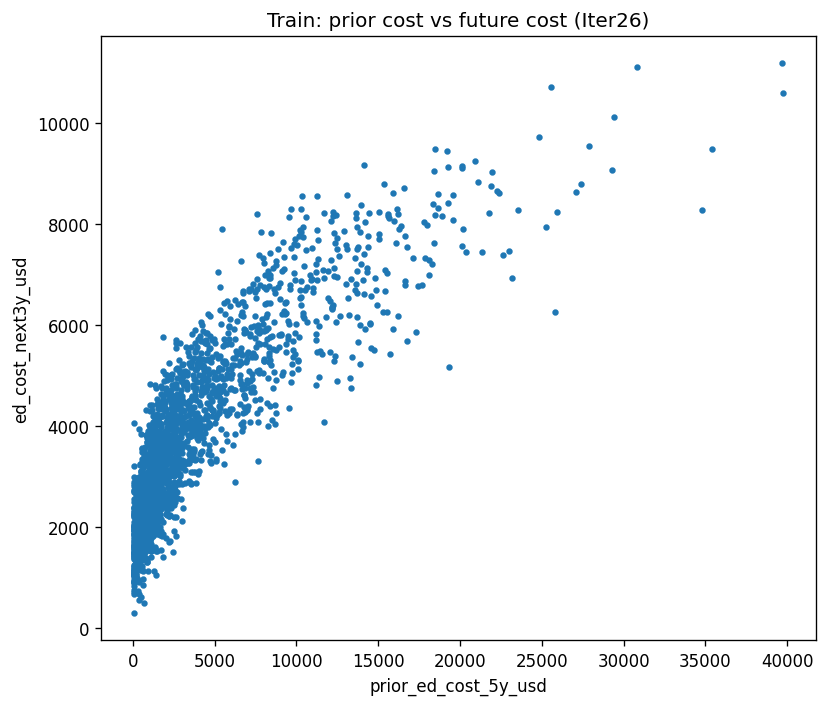

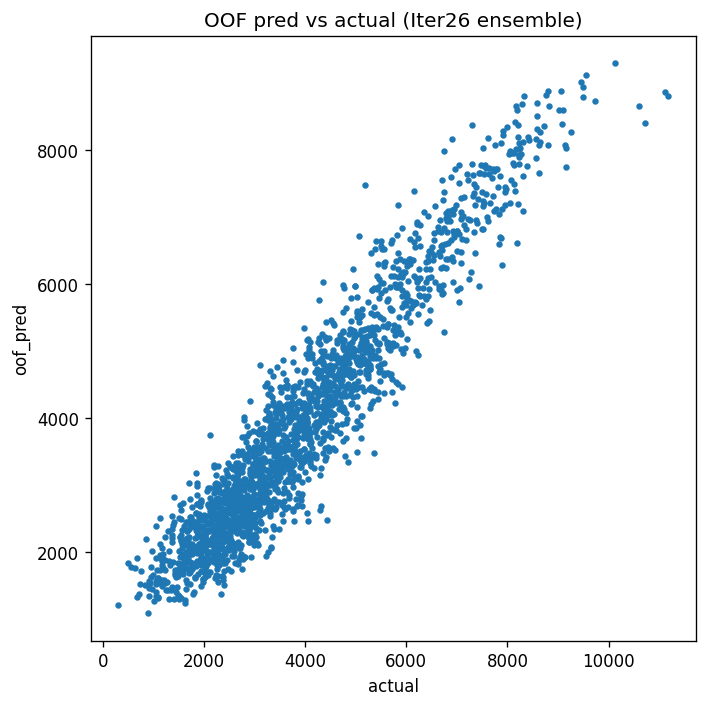


[DONE] Iter26 finished.


In [44]:
# ============================
# Iter26 (ROBUST): Sublinear + Receipt(Utilization/Price) + Optional CatBoost/LGB Ensemble
# Copy-paste into ONE Jupyter cell and run.
# ============================

import os
import re
import math
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from joblib import load, dump

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.isotonic import IsotonicRegression

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# -----------------------
# Optional packages
# -----------------------
try:
    import lightgbm as lgb
    HAS_LGB = True
    try:
        from lightgbm.callback import early_stopping as lgb_early_stopping
    except Exception:
        lgb_early_stopping = None
except Exception:
    HAS_LGB = False
    lgb = None
    lgb_early_stopping = None

try:
    from catboost import CatBoostRegressor, Pool
    HAS_CAT = True
except Exception:
    HAS_CAT = False
    CatBoostRegressor = None
    Pool = None

# -----------------------
# Config
# -----------------------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")

TRAIN_CSV    = BASE_DIR / "ed_cost_train.csv"
TEST_CSV     = BASE_DIR / "ed_cost_test.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"

ADM_TRAIN = BASE_DIR / "admissions_train.csv"
ADM_TEST  = BASE_DIR / "admissions_test.csv"

# receipt cache you trust (iter10)
RECEIPT_CACHE = BASE_DIR / "cache_iter10" / "receipts_parsed.joblib"

OUT_DIR = BASE_DIR / "cache_iter26_robust"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Toggle switches
USE_ADMISSIONS   = True         # admissions historically "弱提升/有时变差"，但这里保留可选
USE_CATBOOST     = True         # if installed
USE_LIGHTGBM     = True         # if installed
USE_MONOTONE_LGB = True         # monotone constraints for key sublinear drivers (safer generalization)
USE_LOG_TARGET_LGB = True       # second LGB model on log1p(y) (ensemble option)

# Training controls
RANDOM_STATE = 42
N_SPLITS = 5
SEEDS = [42, 2024, 3407]        # small seed ensemble
EARLY_STOP = 300
N_ESTIMATORS = 20000
TOL = 1e-2                      # money comparison tolerance

# group residual correction (post-hoc bias adjust)
USE_GROUP_RESID_CORR = True
GROUP_SHRINK_K = 80.0           # larger => more shrink for small groups

print(f"[paths] BASE_DIR={BASE_DIR}")
print(f"[paths] OUT_DIR={OUT_DIR}")
print(f"[paths] RECEIPT_CACHE={RECEIPT_CACHE}")
print(f"[flags] HAS_LGB={HAS_LGB} | HAS_CAT={HAS_CAT}")

# -----------------------
# Helpers
# -----------------------
def safe_read_csv(path: Path):
    if path is None or (not path.exists()):
        print(f"[warn] missing file: {path}")
        return None
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"[warn] failed reading {path}: {e}")
        return None

def can_int(x) -> bool:
    try:
        int(str(x).strip())
        return True
    except Exception:
        return False

def normalize_code(x):
    if x is None:
        return None
    try:
        if isinstance(x, (int, np.integer)):
            return str(int(x))
        if isinstance(x, float) and np.isfinite(x) and float(x).is_integer():
            return str(int(x))
    except Exception:
        pass
    s = str(x).strip()
    if re.fullmatch(r"\d+\.0", s):
        s = s.split(".")[0]
    return s if s else None

def parse_amount(x):
    if x is None:
        return np.nan
    try:
        if isinstance(x, str):
            xs = x.strip().replace(",", "").replace("$", "")
            return float(xs)
        return float(x)
    except Exception:
        return np.nan

def infer_col(df: pd.DataFrame, candidates):
    if df is None or df.empty:
        return None
    cols = list(df.columns)
    low = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in low:
            return low[cand.lower()]
    for cand in candidates:
        for c in cols:
            if cand.lower() in str(c).lower():
                return c
    return None

def safe_median(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce")
    if x.notna().any():
        return float(x.median())
    return 0.0

# -----------------------
# Receipt code universe
# -----------------------
ED_EM = {"99281","99282","99283","99284","99285"}
CRIT  = {"99291","99292"}
SEVERE_PROC = {"31500","92950","36556","36620"}  # intub, CPR, CVC, art line
IMAGING = {"70450","74177","71045"}              # CT head, CT A/P, CXR
LAB = {"85025","87070","84484"}                  # CBC, culture, troponin
OBS = {"G0378"}

ALL_CODES = sorted(list(ED_EM | CRIT | SEVERE_PROC | IMAGING | LAB | OBS))
print(f"[info] expected receipt code universe={len(ALL_CODES)} -> {ALL_CODES}")

# -----------------------
# Load core tables
# -----------------------
train = safe_read_csv(TRAIN_CSV)
test  = safe_read_csv(TEST_CSV)
patients = safe_read_csv(PATIENTS_CSV)

if train is None or test is None or patients is None:
    raise RuntimeError("Missing required CSVs (train/test/patients). Fix paths first.")

for df in (train, test, patients):
    if "patient_id" not in df.columns:
        raise RuntimeError("Missing patient_id column.")
    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")
    df.dropna(subset=["patient_id"], inplace=True)
    df["patient_id"] = df["patient_id"].astype(int)

# zip3 keep leading zeros
if "zip3" in patients.columns:
    patients["zip3"] = patients["zip3"].astype(str).str.replace(r"\.0$", "", regex=True)
    patients.loc[patients["zip3"].str.lower().isin(["nan","none"]), "zip3"] = "UNK"
    patients["zip3"] = patients["zip3"].apply(lambda s: s.zfill(3) if s.isdigit() else s)

train_full = train.merge(patients, on="patient_id", how="left")
test_full  = test.merge(patients, on="patient_id", how="left")

print(f"[info] train_full={train_full.shape}  test_full={test_full.shape}")

# outlier
for df in [train_full, test_full]:
    df["is_outlier"] = ((df["prior_ed_cost_5y_usd"] <= 50.0) & (df["prior_ed_visits_5y"] == 0)).astype(int)
    
outlier_n = int(train_full["is_outlier"].sum())
print(f"[info] outlier_n={outlier_n} / {len(train_full)}")

patient_ids_all = np.sort(pd.concat([train_full["patient_id"], test_full["patient_id"]]).unique())

# -----------------------
# Receipt cache -> robust features
# -----------------------
def build_receipt_features_from_patient_dict(patient_dict: dict, patient_ids_all: np.ndarray):
    rows = []
    line_rows = []

    CODE_KEYS = ["code", "cpt", "hcpcs", "billing_code", "service_code"]
    AMT_KEYS  = ["amount", "line_total", "line_total_usd", "total", "charge", "lineTotal"]

    def safe_items(obj):
        if not isinstance(obj, dict):
            return []
        items = obj.get("items", [])
        return items if isinstance(items, list) else []

    for pid, obj in patient_dict.items():
        if not can_int(pid):
            continue
        pid_int = int(str(pid).strip())

        items = safe_items(obj)
        codes, amounts = [], []

        header_total = np.nan
        if isinstance(obj, dict):
            header_total = parse_amount(obj.get("pdf_total", np.nan))

        for it in items:
            if not isinstance(it, dict):
                continue
            code = None
            for k in CODE_KEYS:
                if k in it:
                    code = normalize_code(it.get(k))
                    break
            amt = np.nan
            for k in AMT_KEYS:
                if k in it:
                    amt = parse_amount(it.get(k))
                    break
            if code is None:
                continue
            codes.append(code)
            amounts.append(amt)
            line_rows.append({"patient_id": pid_int, "code": code, "amount": amt})

        total_sum = float(np.nansum(amounts)) if len(amounts) else 0.0
        n_lines = int(len(codes))
        n_unique = int(len(set(codes)))

        # per-code counts/costs (known codes only)
        cnt = {f"pdf_cnt_code_{c}": 0 for c in ALL_CODES}
        cost = {f"pdf_cost_code_{c}": 0.0 for c in ALL_CODES}
        for c, a in zip(codes, amounts):
            if c in ALL_CODES:
                cnt[f"pdf_cnt_code_{c}"] += 1
                if np.isfinite(a):
                    cost[f"pdf_cost_code_{c}"] += float(a)

        def sum_cost(code_set):
            s = 0.0
            for c, a in zip(codes, amounts):
                if c in code_set and np.isfinite(a):
                    s += float(a)
            return s

        cost_em = sum_cost(ED_EM)
        cost_crit = sum_cost(CRIT)
        cost_sev = sum_cost(SEVERE_PROC)
        cost_img = sum_cost(IMAGING)
        cost_lab = sum_cost(LAB)
        cost_obs = sum_cost(OBS)
        cost_other = max(0.0, total_sum - (cost_em + cost_crit + cost_sev + cost_img + cost_lab + cost_obs))

        def share(x):
            return float(x / total_sum) if total_sum > 0 else 0.0

        em_levels = []
        for c in codes:
            if c in ED_EM and len(c) == 5 and c[-1].isdigit():
                em_levels.append(int(c[-1]))
        em_levels = np.array(em_levels, dtype=float)

        ent = 0.0
        if total_sum > 0:
            tmp = {}
            for c, a in zip(codes, amounts):
                if not np.isfinite(a):
                    continue
                tmp[c] = tmp.get(c, 0.0) + float(a)
            probs = np.array([v / total_sum for v in tmp.values() if v > 0], dtype=float)
            probs = probs[probs > 0]
            if len(probs):
                ent = float(-(probs * np.log(probs)).sum())

        amt_arr = np.array([a for a in amounts if np.isfinite(a)], dtype=float)
        unit_mean = float(amt_arr.mean()) if len(amt_arr) else 0.0
        unit_std  = float(amt_arr.std()) if len(amt_arr) else 0.0
        unit_min  = float(amt_arr.min()) if len(amt_arr) else 0.0
        unit_max  = float(amt_arr.max()) if len(amt_arr) else 0.0

        # simple severity counts (non-leaky)
        sev_cnt = sum(1 for c in codes if c in SEVERE_PROC)
        crit_cnt = sum(1 for c in codes if c in CRIT)
        em_cnt = sum(1 for c in codes if c in ED_EM)
        high_acuity_score = 2.0 * crit_cnt + 1.5 * sev_cnt + 0.2 * em_cnt

        row = {
            "patient_id": pid_int,
            "pdf_total_sum_items": total_sum,
            "pdf_total_header": header_total,
            "pdf_n_line_items": n_lines,
            "pdf_n_unique_codes": n_unique,
            "pdf_unit_mean": unit_mean,
            "pdf_unit_std": unit_std,
            "pdf_unit_min": unit_min,
            "pdf_unit_max": unit_max,
            "pdf_cost_ed_em": cost_em,
            "pdf_cost_crit": cost_crit,
            "pdf_cost_severe_proc": cost_sev,
            "pdf_cost_imaging": cost_img,
            "pdf_cost_lab": cost_lab,
            "pdf_cost_obs": cost_obs,
            "pdf_cost_other": cost_other,
            "pdf_share_ed_em": share(cost_em),
            "pdf_share_crit": share(cost_crit),
            "pdf_share_severe_proc": share(cost_sev),
            "pdf_share_imaging": share(cost_img),
            "pdf_share_lab": share(cost_lab),
            "pdf_share_obs": share(cost_obs),
            "pdf_share_other": share(cost_other),
            "pdf_has_crit": int(any(c in CRIT for c in codes)),
            "pdf_has_severe_proc": int(any(c in SEVERE_PROC for c in codes)),
            "pdf_em_level_mean": float(np.mean(em_levels)) if len(em_levels) else 0.0,
            "pdf_em_level_max": float(np.max(em_levels)) if len(em_levels) else 0.0,
            "pdf_em_high_frac": float(np.mean(em_levels >= 4)) if len(em_levels) else 0.0,
            "pdf_code_cost_entropy": ent,
            "pdf_sev_cnt": float(sev_cnt),
            "pdf_crit_cnt": float(crit_cnt),
            "pdf_em_cnt": float(em_cnt),
            "pdf_high_acuity_score": float(high_acuity_score),
        }
        row.update(cnt)
        row.update(cost)
        rows.append(row)

    feat = pd.DataFrame(rows)
    lines = pd.DataFrame(line_rows)

    # guarantee key columns
    base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
    if feat.empty:
        feat = base.copy()
        feat["pdf_total_sum_items"] = np.nan
    else:
        feat = base.merge(feat, on="patient_id", how="left")
    return feat, lines

def build_receipt_features_from_lineitems_df(lineitems: pd.DataFrame, patient_ids_all: np.ndarray):
    df = lineitems.copy()
    pid_col = infer_col(df, ["patient_id", "patient"])
    code_col = infer_col(df, ["code", "cpt", "hcpcs"])
    amt_col  = infer_col(df, ["amount", "line_total", "line total", "line_total_usd", "charge", "total"])
    if pid_col is None or code_col is None or amt_col is None:
        base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
        base["pdf_total_sum_items"] = np.nan
        return base, pd.DataFrame(columns=["patient_id","code","amount"])

    df = df[[pid_col, code_col, amt_col]].rename(columns={pid_col:"patient_id", code_col:"code", amt_col:"amount"})
    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")
    df.dropna(subset=["patient_id"], inplace=True)
    df["patient_id"] = df["patient_id"].astype(int)
    df["code"] = df["code"].apply(normalize_code)
    df["amount"] = df["amount"].apply(parse_amount)
    df.dropna(subset=["code"], inplace=True)

    lines = df[["patient_id","code","amount"]].copy()

    g = df.groupby("patient_id", dropna=False)
    feat = pd.DataFrame({"patient_id": g.size().index.astype(int)})
    feat["pdf_total_sum_items"] = g["amount"].sum(min_count=1).fillna(0.0).values
    feat["pdf_n_line_items"] = g.size().values.astype(int)
    feat["pdf_n_unique_codes"] = g["code"].nunique().values.astype(int)

    # create empty known-code columns
    for c in ALL_CODES:
        feat[f"pdf_cnt_code_{c}"] = 0
        feat[f"pdf_cost_code_{c}"] = 0.0

    # fill via crosstab/pivot
    ct = pd.crosstab(df["patient_id"], df["code"])
    for c in ALL_CODES:
        if c in ct.columns:
            feat.loc[feat["patient_id"].isin(ct.index), f"pdf_cnt_code_{c}"] = ct[c].reindex(feat["patient_id"]).fillna(0).values

    cost_pt = df.pivot_table(index="patient_id", columns="code", values="amount", aggfunc="sum", fill_value=0.0)
    for c in ALL_CODES:
        if c in cost_pt.columns:
            feat.loc[feat["patient_id"].isin(cost_pt.index), f"pdf_cost_code_{c}"] = cost_pt[c].reindex(feat["patient_id"]).fillna(0.0).values

    base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
    feat = base.merge(feat, on="patient_id", how="left")
    return feat, lines

def load_receipts_flexible(cache_obj, patient_ids_all: np.ndarray):
    if isinstance(cache_obj, dict):
        # unwrap common wrappers
        for k in ["by_pid", "by_patient", "parsed_by_patient", "receipts_by_patient"]:
            if k in cache_obj and isinstance(cache_obj[k], dict):
                cache_obj = cache_obj[k]
                break

        keys = list(cache_obj.keys())
        sample = keys[: min(50, len(keys))]
        int_like = sum(can_int(k) for k in sample) / max(1, len(sample))

        if int_like >= 0.6:
            print(f"[receipt-cache] treating as patient_dict (int_like={int_like:.2f})")
            return build_receipt_features_from_patient_dict(cache_obj, patient_ids_all)

        # dict container with a df
        dfs = [(k,v) for k,v in cache_obj.items() if isinstance(v, pd.DataFrame)]
        if dfs:
            best_k, best_df = dfs[0]
            print(f"[receipt-cache] treating as df_container; using df key={best_k!r}")
            return build_receipt_features_from_lineitems_df(best_df, patient_ids_all)

    if isinstance(cache_obj, pd.DataFrame):
        print("[receipt-cache] treating as lineitems_df")
        return build_receipt_features_from_lineitems_df(cache_obj, patient_ids_all)

    # fallback empty
    print("[warn] Unknown receipt cache format; using empty receipts.")
    base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
    base["pdf_total_sum_items"] = np.nan
    return base, pd.DataFrame(columns=["patient_id","code","amount"])

# cache processed receipt features for speed
RECEIPT_FEAT_CACHE = OUT_DIR / "receipt_feat_iter26.joblib"
RECEIPT_LINES_CACHE = OUT_DIR / "receipt_lines_iter26.joblib"

if RECEIPT_FEAT_CACHE.exists() and RECEIPT_LINES_CACHE.exists():
    receipt_feat = load(RECEIPT_FEAT_CACHE)
    receipt_lines = load(RECEIPT_LINES_CACHE)
    print(f"[cache] loaded receipt_feat={receipt_feat.shape} receipt_lines={receipt_lines.shape}")
else:
    if RECEIPT_CACHE.exists():
        cache_obj = load(RECEIPT_CACHE)
        print(f"[debug] receipt cache type={type(cache_obj)}")
        receipt_feat, receipt_lines = load_receipts_flexible(cache_obj, patient_ids_all)
    else:
        print(f"[warn] missing receipt cache: {RECEIPT_CACHE}")
        receipt_feat = pd.DataFrame({"patient_id": patient_ids_all.astype(int), "pdf_total_sum_items": np.nan})
        receipt_lines = pd.DataFrame(columns=["patient_id","code","amount"])

    receipt_feat = receipt_feat.drop_duplicates("patient_id", keep="first")
    for c in ["patient_id","pdf_total_sum_items"]:
        if c not in receipt_feat.columns:
            receipt_feat[c] = np.nan

    dump(receipt_feat, RECEIPT_FEAT_CACHE)
    dump(receipt_lines, RECEIPT_LINES_CACHE)
    print(f"[cache] wrote receipt_feat/lines to {OUT_DIR}")

print(f"[info] receipt_feat={receipt_feat.shape} receipt_lines={receipt_lines.shape}")

# receipt integrity check (tolerant)
tmp_chk = train_full[["patient_id","prior_ed_cost_5y_usd"]].merge(
    receipt_feat[["patient_id","pdf_total_sum_items"]],
    on="patient_id", how="left"
)
absdiff = (pd.to_numeric(tmp_chk["prior_ed_cost_5y_usd"], errors="coerce") -
           pd.to_numeric(tmp_chk["pdf_total_sum_items"], errors="coerce")).abs()
mask_valid = tmp_chk["pdf_total_sum_items"].notna()
miss_rate = float((~mask_valid).mean())
match_rate = float((absdiff[mask_valid] <= TOL).mean()) if mask_valid.any() else 0.0
print(f"[receipt-check] missing_rate={miss_rate:.4f} | match_rate(valid)={match_rate:.4f} tol={TOL}")
print(absdiff[mask_valid].describe())

# ---- price decomposition from receipt_lines
# global medians by code
if receipt_lines is not None and (not receipt_lines.empty):
    rl = receipt_lines.copy()
    rl["code"] = rl["code"].apply(normalize_code)
    rl["amount"] = rl["amount"].apply(parse_amount)
    rl = rl.dropna(subset=["code"])
    med_price = rl.groupby("code")["amount"].median().to_dict()

    # per-line log price ratio vs global median(code)
    def line_log_ratio(r):
        c = r["code"]
        a = r["amount"]
        m = med_price.get(c, np.nan)
        if (not np.isfinite(a)) or (not np.isfinite(m)) or m <= 0:
            return np.nan
        return float(np.log(a / m))

    rl["log_price_ratio"] = rl.apply(line_log_ratio, axis=1)

    pr_g = rl.groupby("patient_id", dropna=False)["log_price_ratio"]
    price_feat = pr_g.agg(["mean","std","count"]).reset_index().rename(
        columns={"mean":"pdf_log_price_ratio_mean", "std":"pdf_log_price_ratio_std", "count":"pdf_price_ratio_n"}
    )
    price_feat["pdf_log_price_ratio_mean"] = price_feat["pdf_log_price_ratio_mean"].fillna(0.0)
    price_feat["pdf_log_price_ratio_std"] = price_feat["pdf_log_price_ratio_std"].fillna(0.0)

    # fraction above/below thresholds
    rl["is_hi_price"] = (rl["log_price_ratio"] > np.log(1.2)).astype(float)
    rl["is_lo_price"] = (rl["log_price_ratio"] < np.log(0.8)).astype(float)
    frac_hi = rl.groupby("patient_id")["is_hi_price"].mean().reset_index().rename(columns={"is_hi_price":"pdf_hi_price_frac"})
    frac_lo = rl.groupby("patient_id")["is_lo_price"].mean().reset_index().rename(columns={"is_lo_price":"pdf_lo_price_frac"})

    price_feat = price_feat.merge(frac_hi, on="patient_id", how="left").merge(frac_lo, on="patient_id", how="left")
    price_feat["pdf_hi_price_frac"] = price_feat["pdf_hi_price_frac"].fillna(0.0)
    price_feat["pdf_lo_price_frac"] = price_feat["pdf_lo_price_frac"].fillna(0.0)
else:
    med_price = {}
    price_feat = pd.DataFrame({"patient_id": patient_ids_all.astype(int),
                               "pdf_log_price_ratio_mean": 0.0,
                               "pdf_log_price_ratio_std": 0.0,
                               "pdf_price_ratio_n": 0.0,
                               "pdf_hi_price_frac": 0.0,
                               "pdf_lo_price_frac": 0.0})

# merge price_feat into receipt_feat
receipt_feat = receipt_feat.merge(price_feat, on="patient_id", how="left")

# standardized utilization total = sum(count(code) * global_median_price(code))
for c in ALL_CODES:
    cc = f"pdf_cnt_code_{c}"
    if cc not in receipt_feat.columns:
        receipt_feat[cc] = 0

price_vec = np.array([med_price.get(c, np.nan) for c in ALL_CODES], dtype=float)
price_vec = np.nan_to_num(price_vec, nan=0.0)

count_cols = [f"pdf_cnt_code_{c}" for c in ALL_CODES]
receipt_feat["pdf_standardized_total"] = receipt_feat[count_cols].values.astype(float) @ price_vec

num = pd.to_numeric(receipt_feat["pdf_total_sum_items"], errors="coerce").astype(float)
den = pd.to_numeric(receipt_feat["pdf_standardized_total"], errors="coerce").astype(float)
pi = np.where(den > 0, num / den, 1.0)
pi = np.where(np.isfinite(pi), pi, 1.0)
receipt_feat["pdf_price_index"] = pi.astype(np.float32)

# -----------------------
# Admissions features (robust)
# -----------------------
def build_admissions_features(adm_tr, adm_te, patient_ids_all):
    base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
    if adm_tr is None or adm_te is None:
        return base.copy()

    adm_all = pd.concat([adm_tr, adm_te], axis=0, ignore_index=True)
    if "patient_id" not in adm_all.columns:
        return base.copy()

    adm_all["patient_id"] = pd.to_numeric(adm_all["patient_id"], errors="coerce")
    adm_all = adm_all.dropna(subset=["patient_id"])
    adm_all["patient_id"] = adm_all["patient_id"].astype(int)

    # numeric cast candidates
    for col in ["los_days", "acuity_emergent", "charlson_band", "ed_visits_6m", "discharge_weekday"]:
        if col in adm_all.columns:
            adm_all[col] = pd.to_numeric(adm_all[col], errors="coerce")

    # try find a datetime column for recency
    dt_col = infer_col(adm_all, ["admit_date", "admission_date", "admit_time", "discharge_date", "discharge_time"])
    if dt_col is not None:
        tmp_dt = pd.to_datetime(adm_all[dt_col], errors="coerce")
        ok_rate = float(tmp_dt.notna().mean())
        if ok_rate >= 0.3:
            adm_all["_dt"] = tmp_dt
        else:
            dt_col = None

    g = adm_all.groupby("patient_id", dropna=False)
    feat = pd.DataFrame({"patient_id": g.size().index.astype(int)})
    feat["adm_n"] = g.size().values.astype(int)

    def agg_if(col, fn, default=np.nan):
        if col not in adm_all.columns:
            return np.full(len(feat), default, dtype=float)
        return getattr(g[col], fn)().values

    feat["adm_los_mean"] = agg_if("los_days", "mean")
    feat["adm_los_max"]  = agg_if("los_days", "max")
    feat["adm_los_sum"]  = g["los_days"].sum(min_count=1).reindex(feat["patient_id"]).values if "los_days" in adm_all.columns else np.nan

    feat["adm_charlson_mean"] = agg_if("charlson_band", "mean")
    feat["adm_charlson_max"]  = agg_if("charlson_band", "max")

    feat["adm_emergent_rate"] = agg_if("acuity_emergent", "mean")
    feat["adm_emergent_n"]    = g["acuity_emergent"].sum(min_count=1).reindex(feat["patient_id"]).values if "acuity_emergent" in adm_all.columns else np.nan

    feat["adm_edvis6m_mean"] = agg_if("ed_visits_6m", "mean")
    feat["adm_edvis6m_max"]  = agg_if("ed_visits_6m", "max")
    feat["adm_edvis6m_sum"]  = g["ed_visits_6m"].sum(min_count=1).reindex(feat["patient_id"]).values if "ed_visits_6m" in adm_all.columns else np.nan

    # last-row features (recency-based if datetime exists)
    if dt_col is not None and "_dt" in adm_all.columns:
        adm_all = adm_all.sort_values(["patient_id","_dt"])
    else:
        adm_all = adm_all.sort_values(["patient_id"])

    last = adm_all.groupby("patient_id").tail(1).copy()
    last_cols = []
    for col in ["los_days", "charlson_band", "acuity_emergent", "ed_visits_6m", "discharge_weekday", "primary_dx"]:
        if col in last.columns:
            last_cols.append(col)
    last = last[["patient_id"] + last_cols]

    rename = {}
    for col in last_cols:
        rename[col] = f"adm_last_{col}"
    last = last.rename(columns=rename)

    feat = feat.merge(last, on="patient_id", how="left")

    # dx crosstab counts
    if "primary_dx" in adm_all.columns:
        dx_ct = pd.crosstab(adm_all["patient_id"], adm_all["primary_dx"])
        dx_ct.columns = [f"adm_dx_cnt_{c}" for c in dx_ct.columns]
        dx_ct = dx_ct.reset_index().rename(columns={"patient_id":"patient_id"})
        dx_ct["patient_id"] = dx_ct["patient_id"].astype(int)
        feat = feat.merge(dx_ct, on="patient_id", how="left")

    # derived trend
    if "adm_last_ed_visits_6m" in feat.columns and "adm_edvis6m_mean" in feat.columns:
        feat["adm_edvis6m_rise"] = pd.to_numeric(feat["adm_last_ed_visits_6m"], errors="coerce") - pd.to_numeric(feat["adm_edvis6m_mean"], errors="coerce")
    else:
        feat["adm_edvis6m_rise"] = np.nan

    # ensure all patients
    feat = base.merge(feat, on="patient_id", how="left")
    return feat

adm_feat = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
if USE_ADMISSIONS:
    adm_tr = safe_read_csv(ADM_TRAIN)
    adm_te = safe_read_csv(ADM_TEST)
    adm_feat = build_admissions_features(adm_tr, adm_te, patient_ids_all)
print(f"[info] adm_feat={adm_feat.shape}")

# -----------------------
# Merge all
# -----------------------
all_train = train_full.merge(receipt_feat, on="patient_id", how="left").merge(adm_feat, on="patient_id", how="left")
all_test  = test_full.merge(receipt_feat, on="patient_id", how="left").merge(adm_feat, on="patient_id", how="left")

# If receipt totals missing, impute from prior cost (dataset design: sum_items≈prior_cost)
all_train["pdf_total_sum_items"] = all_train["pdf_total_sum_items"].fillna(all_train["prior_ed_cost_5y_usd"])
all_test["pdf_total_sum_items"]  = all_test["pdf_total_sum_items"].fillna(all_test["prior_ed_cost_5y_usd"])

# -----------------------
# Sublinear transforms
# -----------------------
def add_sublinear(df):
    pc = pd.to_numeric(df["prior_ed_cost_5y_usd"], errors="coerce").fillna(0.0).astype(float)
    pv = pd.to_numeric(df["prior_ed_visits_5y"], errors="coerce").fillna(0.0).astype(float)

    df["prior_cost_deflated"] = np.maximum(pc, 50.0)      # key fix: avoid 0-cost exploding ratios
    df["log_prior_cost"] = np.log1p(pc)
    df["sqrt_prior_cost"] = np.sqrt(np.clip(pc, 0, None))
    df["log_prior_visits"] = np.log1p(pv)
    df["prior_cost_per_visit"] = pc / (pv + 1.0)
    df["log_prior_cost_per_visit"] = np.log1p(df["prior_cost_per_visit"].values.astype(float))

    # optional cap features (robust)
    df["prior_cost_cap20k"] = np.minimum(pc, 20000.0)
    df["prior_cost_cap10k"] = np.minimum(pc, 10000.0)

    return df

all_train = add_sublinear(all_train)
all_test  = add_sublinear(all_test)

# -----------------------
# Baseline stacking features (OOF) – powerlaw + isotonic on deflated prior cost
# -----------------------
def strat_label(df):
    # keep chronic|insurance|outlier balanced
    return (df["primary_chronic"].astype(str) + "|" +
            df["insurance"].astype(str) + "|out=" +
            df["is_outlier"].astype(int).astype(str))

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def oof_powerlaw_baseline(train_df, test_df, min_group_n=80):
    oof = np.zeros(len(train_df), dtype=float)
    test_pred = np.zeros(len(test_df), dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, strat_label(train_df)), start=1):
        tr = train_df.iloc[tr_idx].copy()
        va = train_df.iloc[va_idx].copy()

        # global model
        Xg = np.column_stack([
            np.log1p(tr["prior_cost_deflated"].values.astype(float)),
            np.log1p(tr["prior_ed_visits_5y"].values.astype(float)),
        ])
        yg = np.log1p(tr["ed_cost_next3y_usd"].values.astype(float))
        global_lr = LinearRegression().fit(Xg, yg)

        # per group models (only if enough samples)
        models = {}
        for (ch, ins), sub in tr.groupby(["primary_chronic","insurance"], dropna=False):
            if len(sub) < min_group_n:
                continue
            X = np.column_stack([
                np.log1p(sub["prior_cost_deflated"].values.astype(float)),
                np.log1p(sub["prior_ed_visits_5y"].values.astype(float)),
            ])
            ylog = np.log1p(sub["ed_cost_next3y_usd"].values.astype(float))
            lr = LinearRegression().fit(X, ylog)
            models[(ch, ins)] = lr

        # predict val
        pv = np.zeros(len(va), dtype=float)
        for i, r in enumerate(va.itertuples(index=False)):
            key = (getattr(r,"primary_chronic"), getattr(r,"insurance"))
            lr = models.get(key, global_lr)
            Xv = np.array([[np.log1p(float(getattr(r,"prior_cost_deflated"))),
                            np.log1p(float(getattr(r,"prior_ed_visits_5y")))]], dtype=float)
            pv[i] = max(0.0, float(np.expm1(lr.predict(Xv)[0])))
        oof[va_idx] = pv

        mae = mean_absolute_error(va["ed_cost_next3y_usd"].values, pv)
        print(f"[baseline_powerlaw] fold{fold}: MAE={mae:.3f}")

    # fit full for test
    tr = train_df.copy()
    Xg = np.column_stack([
        np.log1p(tr["prior_cost_deflated"].values.astype(float)),
        np.log1p(tr["prior_ed_visits_5y"].values.astype(float)),
    ])
    yg = np.log1p(tr["ed_cost_next3y_usd"].values.astype(float))
    global_lr = LinearRegression().fit(Xg, yg)

    models = {}
    for (ch, ins), sub in tr.groupby(["primary_chronic","insurance"], dropna=False):
        if len(sub) < min_group_n:
            continue
        X = np.column_stack([
            np.log1p(sub["prior_cost_deflated"].values.astype(float)),
            np.log1p(sub["prior_ed_visits_5y"].values.astype(float)),
        ])
        ylog = np.log1p(sub["ed_cost_next3y_usd"].values.astype(float))
        lr = LinearRegression().fit(X, ylog)
        models[(ch, ins)] = lr

    for i, r in enumerate(test_df.itertuples(index=False)):
        key = (getattr(r,"primary_chronic"), getattr(r,"insurance"))
        lr = models.get(key, global_lr)
        Xv = np.array([[np.log1p(float(getattr(r,"prior_cost_deflated"))),
                        np.log1p(float(getattr(r,"prior_ed_visits_5y")))]], dtype=float)
        test_pred[i] = max(0.0, float(np.expm1(lr.predict(Xv)[0])))

    return oof, test_pred

def oof_isotonic_baseline(train_df, test_df):
    oof = np.zeros(len(train_df), dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, strat_label(train_df)), start=1):
        tr = train_df.iloc[tr_idx]
        va = train_df.iloc[va_idx]

        iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
        iso.fit(tr["prior_cost_deflated"].values.astype(float), tr["ed_cost_next3y_usd"].values.astype(float))
        pv = iso.predict(va["prior_cost_deflated"].values.astype(float))
        oof[va_idx] = np.clip(pv, 0, None)

        mae = mean_absolute_error(va["ed_cost_next3y_usd"].values, pv)
        print(f"[baseline_isotonic] fold{fold}: MAE={mae:.3f}")

    iso_full = IsotonicRegression(increasing=True, out_of_bounds="clip")
    iso_full.fit(train_df["prior_cost_deflated"].values.astype(float), train_df["ed_cost_next3y_usd"].values.astype(float))
    test_pred = np.clip(iso_full.predict(test_df["prior_cost_deflated"].values.astype(float)), 0, None)
    return oof, test_pred

# add baseline feats (these are not the final pred; they are extra signals)
y = all_train["ed_cost_next3y_usd"].values.astype(float)
is_out = all_train["is_outlier"].values.astype(int)

print("\n[iter26] building baseline stacking features...")
oof_bl_pow, te_bl_pow = oof_powerlaw_baseline(all_train, all_test, min_group_n=80)
oof_bl_iso, te_bl_iso = oof_isotonic_baseline(all_train, all_test)

all_train["bl_powerlaw"] = oof_bl_pow
all_test["bl_powerlaw"]  = te_bl_pow
all_train["bl_isotonic"] = oof_bl_iso
all_test["bl_isotonic"]  = te_bl_iso

# -----------------------
# Fill missing values (robust)
# -----------------------
# categoricals
CAT_COLS = [c for c in ["primary_chronic","insurance","sex","zip3"] if c in all_train.columns]
for c in CAT_COLS:
    all_train[c] = all_train[c].astype(str).fillna("UNK")
    all_test[c]  = all_test[c].astype(str).fillna("UNK")

# if admissions last dx exists, keep as cat
if "adm_last_primary_dx" in all_train.columns:
    all_train["adm_last_primary_dx"] = all_train["adm_last_primary_dx"].astype(str).fillna("UNK")
    all_test["adm_last_primary_dx"]  = all_test["adm_last_primary_dx"].astype(str).fillna("UNK")
    CAT_COLS.append("adm_last_primary_dx")

# numeric
num_cols = all_train.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    if c == "ed_cost_next3y_usd":
        continue
    med = safe_median(all_train[c])
    all_train[c] = pd.to_numeric(all_train[c], errors="coerce").fillna(med)
    if c in all_test.columns:
        all_test[c] = pd.to_numeric(all_test[c], errors="coerce").fillna(med)

# -----------------------
# Feature list (drop obvious leakage / ids)
# -----------------------
DROP_COLS = {"ed_cost_next3y_usd","patient_id"}
feat_cols = [c for c in all_train.columns if c not in DROP_COLS]

# Drop high-cardinality raw strings except chosen cats
for c in feat_cols:
    if all_train[c].dtype == "object" and c not in CAT_COLS:
        # probably some leftover text columns -> drop
        pass

feat_cols = [c for c in feat_cols if not (all_train[c].dtype == "object" and c not in CAT_COLS)]

# drop constant columns
const_cols = [c for c in feat_cols if all_train[c].nunique(dropna=False) <= 1]
if const_cols:
    print(f"[feature-audit] dropping const cols: {const_cols[:20]}{'...' if len(const_cols)>20 else ''}")
feat_cols = [c for c in feat_cols if c not in const_cols]

print(f"[info] n_features_total={len(feat_cols)} | n_cat={len(CAT_COLS)}")

# -----------------------
# LightGBM CV
# -----------------------
def lgb_make_monotone_constraints(feature_names):
    # 1 = increasing; 0 = no constraint
    inc = {
        "prior_ed_cost_5y_usd",
        "prior_cost_deflated",
        "log_prior_cost",
        "sqrt_prior_cost",
        "prior_ed_visits_5y",
        "log_prior_visits",
        "pdf_standardized_total",
        "pdf_high_acuity_score",
        "bl_powerlaw",
        "bl_isotonic",
    }
    cons = []
    for f in feature_names:
        if f in inc:
            cons.append(1)
        else:
            cons.append(0)
    return cons

def train_lgb_cv(train_df, test_df, feat_cols, cat_cols, seeds, log_target=False):
    if not HAS_LGB:
        print("[lgb] not installed; skip")
        return None

    oof = np.zeros(len(train_df), dtype=float)
    test_pred = np.zeros(len(test_df), dtype=float)

    # prepare copies: keep cat as category for LGB
    trn = train_df.copy()
    tes = test_df.copy()
    for c in cat_cols:
        trn[c] = trn[c].astype("category")
        tes[c] = tes[c].astype("category")

    # --- FIX: Define objective/metric HERE, before using them ---
    if log_target:
        objective = "regression"
        metric = "l2"
    else:
        objective = "regression_l1"
        metric = "l1"

    # monotone constraints (Only if NOT using L1/MAE)
    mono = None
    if USE_MONOTONE_LGB and (objective != "regression_l1"):
        mono = lgb_make_monotone_constraints(feat_cols)

    for seed in seeds:
        fold_oof = np.zeros(len(trn), dtype=float)
        fold_test = np.zeros(len(tes), dtype=float)

        for fold, (tr_idx, va_idx) in enumerate(skf.split(trn, strat_label(trn)), start=1):
            tr = trn.iloc[tr_idx]
            va = trn.iloc[va_idx]

            X_tr = tr[feat_cols]
            X_va = va[feat_cols]
            X_te = tes[feat_cols]

            y_tr = tr["ed_cost_next3y_usd"].values.astype(float)
            y_va = va["ed_cost_next3y_usd"].values.astype(float)

            # Apply log transform if needed
            if log_target:
                y_tr_fit = np.log1p(y_tr)
                y_va_fit = np.log1p(y_va)
            else:
                y_tr_fit = y_tr
                y_va_fit = y_va

            params = dict(
                objective=objective,
                n_estimators=N_ESTIMATORS,
                learning_rate=0.02 if not log_target else 0.03,
                num_leaves=128,
                min_data_in_leaf=25,
                feature_fraction=0.80,
                bagging_fraction=0.85,
                bagging_freq=1,
                lambda_l2=5.0,
                random_state=int(seed) + fold,
                n_jobs=-1,
                force_col_wise=True,
            )
            if mono is not None:
                params["monotone_constraints"] = mono

            model = lgb.LGBMRegressor(**params)

            callbacks = []
            if lgb_early_stopping is not None:
                callbacks.append(lgb_early_stopping(stopping_rounds=EARLY_STOP, verbose=False))
            elif hasattr(lgb, "early_stopping"):
                callbacks.append(lgb.early_stopping(stopping_rounds=EARLY_STOP, verbose=False))

            # robust fit across versions
            try:
                model.fit(
                    X_tr, y_tr_fit,
                    eval_set=[(X_va, y_va_fit)],
                    eval_metric=metric,
                    callbacks=callbacks if callbacks else None,
                )
            except TypeError:
                # fallback: early_stopping_rounds
                model.fit(
                    X_tr, y_tr_fit,
                    eval_set=[(X_va, y_va_fit)],
                    eval_metric=metric,
                    early_stopping_rounds=EARLY_STOP,
                    verbose=False
                )

            best_iter = getattr(model, "best_iteration_", None)
            pv = model.predict(X_va, num_iteration=best_iter)
            pt = model.predict(X_te, num_iteration=best_iter)

            if log_target:
                pv = np.expm1(pv)
                pt = np.expm1(pt)

            pv = np.clip(pv, 0, None)
            pt = np.clip(pt, 0, None)

            fold_oof[va_idx] = pv
            fold_test += pt / N_SPLITS

            mae = mean_absolute_error(y_va, pv)
            out_mask = (va["is_outlier"].values.astype(int) == 1)
            out_mae = mean_absolute_error(y_va[out_mask], pv[out_mask]) if out_mask.any() else np.nan
            tag = "logY" if log_target else "L1"
            print(f"[lgb_{tag}] seed={seed} fold{fold}: MAE={mae:.3f} | out_MAE={out_mae:.3f} | best_iter={best_iter}")

        test_pred += fold_test / len(seeds)
        oof += fold_oof / len(seeds)

    return oof, test_pred

# -----------------------
# CatBoost CV
# -----------------------
def train_cat_cv(train_df, test_df, feat_cols, cat_cols, seeds):
    if not HAS_CAT:
        print("[cat] not installed; skip")
        return None

    oof = np.zeros(len(train_df), dtype=float)
    test_pred = np.zeros(len(test_df), dtype=float)

    # cat feature indices
    cat_idx = [feat_cols.index(c) for c in cat_cols if c in feat_cols]

    X = train_df[feat_cols].copy()
    X_test = test_df[feat_cols].copy()
    y = train_df["ed_cost_next3y_usd"].values.astype(float)

    for seed in seeds:
        fold_oof = np.zeros(len(train_df), dtype=float)
        fold_test = np.zeros(len(test_df), dtype=float)

        for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, strat_label(train_df)), start=1):
            X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
            X_va, y_va = X.iloc[va_idx], y[va_idx]

            tr_pool = Pool(X_tr, y_tr, cat_features=cat_idx) if len(cat_idx) else Pool(X_tr, y_tr)
            va_pool = Pool(X_va, y_va, cat_features=cat_idx) if len(cat_idx) else Pool(X_va, y_va)
            te_pool = Pool(X_test, cat_features=cat_idx) if len(cat_idx) else Pool(X_test)

            model = CatBoostRegressor(
                loss_function="MAE",
                iterations=12000,
                learning_rate=0.03,
                depth=6,
                l2_leaf_reg=6.0,
                random_seed=int(seed) + fold,
                subsample=0.85,
                rsm=0.85,
                bootstrap_type="Bernoulli",
                od_type="Iter",
                od_wait=EARLY_STOP,
                allow_writing_files=False,
                verbose=False,
            )
            model.fit(tr_pool, eval_set=va_pool, use_best_model=True)

            pv = model.predict(va_pool)
            pt = model.predict(te_pool)
            pv = np.clip(pv, 0, None)
            pt = np.clip(pt, 0, None)

            fold_oof[va_idx] = pv
            fold_test += pt / N_SPLITS

            mae = mean_absolute_error(y_va, pv)
            out_mask = (train_df.iloc[va_idx]["is_outlier"].values.astype(int) == 1)
            out_mae = mean_absolute_error(y_va[out_mask], pv[out_mask]) if out_mask.any() else np.nan
            print(f"[cat_MAE] seed={seed} fold{fold}: MAE={mae:.3f} | out_MAE={out_mae:.3f}")

        oof += fold_oof / len(seeds)
        test_pred += fold_test / len(seeds)

    return oof, test_pred

# -----------------------
# Train models
# -----------------------
oof_preds = {}
test_preds = {}

if USE_LIGHTGBM and HAS_LGB:
    print("\n=== Train LightGBM (L1 on y) ===")
    out = train_lgb_cv(all_train, all_test, feat_cols, CAT_COLS, SEEDS, log_target=False)
    if out is not None:
        oof_lgb, te_lgb = out
        oof_preds["lgb_l1"] = oof_lgb
        test_preds["lgb_l1"] = te_lgb

if USE_LOG_TARGET_LGB and USE_LIGHTGBM and HAS_LGB:
    print("\n=== Train LightGBM (L2 on log1p(y)) ===")
    out = train_lgb_cv(all_train, all_test, feat_cols, CAT_COLS, SEEDS, log_target=True)
    if out is not None:
        oof_lgb_log, te_lgb_log = out
        oof_preds["lgb_logy"] = oof_lgb_log
        test_preds["lgb_logy"] = te_lgb_log

if USE_CATBOOST and HAS_CAT:
    print("\n=== Train CatBoost (MAE) ===")
    out = train_cat_cv(all_train, all_test, feat_cols, CAT_COLS, SEEDS)
    if out is not None:
        oof_cat, te_cat = out
        oof_preds["cat_mae"] = oof_cat
        test_preds["cat_mae"] = te_cat

# -----------------------
# Evaluate & ensemble
# -----------------------
def eval_pred(name, oof):
    mae = mean_absolute_error(y, oof)
    out_mae = mean_absolute_error(y[is_out==1], oof[is_out==1]) if (is_out==1).any() else np.nan
    return mae, out_mae

rows = []
for name, oof in oof_preds.items():
    mae, out_mae = eval_pred(name, oof)
    rows.append((name, mae, out_mae))
summary = pd.DataFrame(rows, columns=["model","oof_mae","out_oof_mae"]).sort_values("oof_mae")
print("\n=== OOF SUMMARY ===")
print(summary.to_string(index=False))
summary.to_csv(OUT_DIR / "iter26_model_oof_summary.csv", index=False)

# weighted ensemble: inverse MAE
if len(oof_preds) == 0:
    raise RuntimeError("No model trained. Check LightGBM/CatBoost installation toggles.")

inv = {k: 1.0 / max(1e-9, mean_absolute_error(y, v)) for k, v in oof_preds.items()}
s = sum(inv.values())
w = {k: inv[k]/s for k in inv}
print("\n[ensemble] weights=", w)

oof_ens = np.zeros_like(y)
te_ens = np.zeros(len(all_test), dtype=float)
for k in oof_preds:
    oof_ens += w[k] * oof_preds[k]
    te_ens  += w[k] * test_preds[k]

# -----------------------
# Group residual correction (optional, shrunk)
# -----------------------
def apply_group_resid_corr(train_df, oof_pred, test_df, test_pred, shrink_k=80.0):
    key_tr = train_df["primary_chronic"].astype(str) + "|" + train_df["insurance"].astype(str)
    resid = train_df["ed_cost_next3y_usd"].values.astype(float) - oof_pred.astype(float)

    tmp = pd.DataFrame({"key": key_tr.values, "resid": resid})
    grp = tmp.groupby("key")["resid"].agg(["median","count"]).reset_index()
    grp["shrink"] = grp["count"] / (grp["count"] + shrink_k)
    grp["adj"] = grp["median"] * grp["shrink"]

    global_adj = float(np.median(resid))

    key_te = test_df["primary_chronic"].astype(str) + "|" + test_df["insurance"].astype(str)
    adj_map = dict(zip(grp["key"], grp["adj"]))
    te_adj = key_te.map(adj_map).fillna(global_adj).values.astype(float)
    te_corr = np.clip(test_pred + te_adj, 0, None)

    # (for reporting only) "corrected oof" using same group adj (small leakage but ok for sanity)
    tr_adj = pd.Series(key_tr).map(adj_map).fillna(global_adj).values.astype(float)
    oof_corr = np.clip(oof_pred + tr_adj, 0, None)

    return oof_corr, te_corr

if USE_GROUP_RESID_CORR:
    oof_ens_corr, te_ens_corr = apply_group_resid_corr(all_train, oof_ens, all_test, te_ens, shrink_k=GROUP_SHRINK_K)
    mae0 = mean_absolute_error(y, oof_ens)
    mae1 = mean_absolute_error(y, oof_ens_corr)
    print(f"\n[group-corr] OOF MAE: before={mae0:.3f} after={mae1:.3f}  (shrink_k={GROUP_SHRINK_K})")
    oof_final = oof_ens_corr
    te_final = te_ens_corr
else:
    oof_final = oof_ens
    te_final = te_ens

# final metrics
mae_final = mean_absolute_error(y, oof_final)
out_mae_final = mean_absolute_error(y[is_out==1], oof_final[is_out==1]) if (is_out==1).any() else np.nan
print(f"\n=== FINAL ENSEMBLE OOF ===\nOOF MAE={mae_final:.3f} | Outlier OOF MAE={out_mae_final:.3f}")

# -----------------------
# Save artifacts
# -----------------------
oof_df = pd.DataFrame({
    "patient_id": all_train["patient_id"].values,
    "y_true": y,
    "oof_pred": oof_final
})
oof_df.to_csv(OUT_DIR / "iter26_oof_predictions.csv", index=False)
print(f"[write] {OUT_DIR / 'iter26_oof_predictions.csv'}")

# submission
sub = pd.DataFrame({
    "patient_id": all_test["patient_id"].values,
    "ed_cost_next3y_usd": te_final.astype(float)
})
sub_path = OUT_DIR / "submission_iter26.csv"
sub.to_csv(sub_path, index=False)
print(f"[write] {sub_path}")

# plots
plt.figure(figsize=(7,6))
plt.scatter(all_train["prior_ed_cost_5y_usd"].values, y, s=8)
plt.xlabel("prior_ed_cost_5y_usd")
plt.ylabel("ed_cost_next3y_usd")
plt.title("Train: prior cost vs future cost (Iter26)")
plt.tight_layout()
plt.savefig(OUT_DIR / "scatter_prior_vs_future_iter26.png", dpi=160)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y, oof_final, s=8)
plt.xlabel("actual")
plt.ylabel("oof_pred")
plt.title("OOF pred vs actual (Iter26 ensemble)")
plt.tight_layout()
plt.savefig(OUT_DIR / "oof_pred_vs_actual_iter26.png", dpi=160)
plt.show()

print("\n[DONE] Iter26 finished.")


## EDA 2.6.1


[paths] BASE_DIR=D:\AgentDs\agent_ds_healthcare
[paths] OUT_DIR=D:\AgentDs\agent_ds_healthcare\cache_iter26_robust
[paths] RECEIPT_CACHE=D:\AgentDs\agent_ds_healthcare\cache_iter10\receipts_parsed.joblib
[flags] HAS_LGB=True | HAS_CAT=True
[info] expected receipt code universe=18 -> ['31500', '36556', '36620', '70450', '71045', '74177', '84484', '85025', '87070', '92950', '99281', '99282', '99283', '99284', '99285', '99291', '99292', 'G0378']
[info] train_full=(2000, 9)  test_full=(2000, 8)
[info] outlier_n=85 / 2000
[cache] loaded receipt_feat=(4000, 69) receipt_lines=(27864, 3)
[info] receipt_feat=(4000, 69) receipt_lines=(27864, 3)
[receipt-check] missing_rate=0.0000 | match_rate(valid)=1.0000 tol=0.01
count    2.000000e+03
mean     2.150884e-13
std      5.212289e-13
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.273737e-13
max      3.637979e-12
dtype: float64
[info] adm_feat=(4000, 22)

[iter26] building baseline stacking features...
[baseline_powerlaw

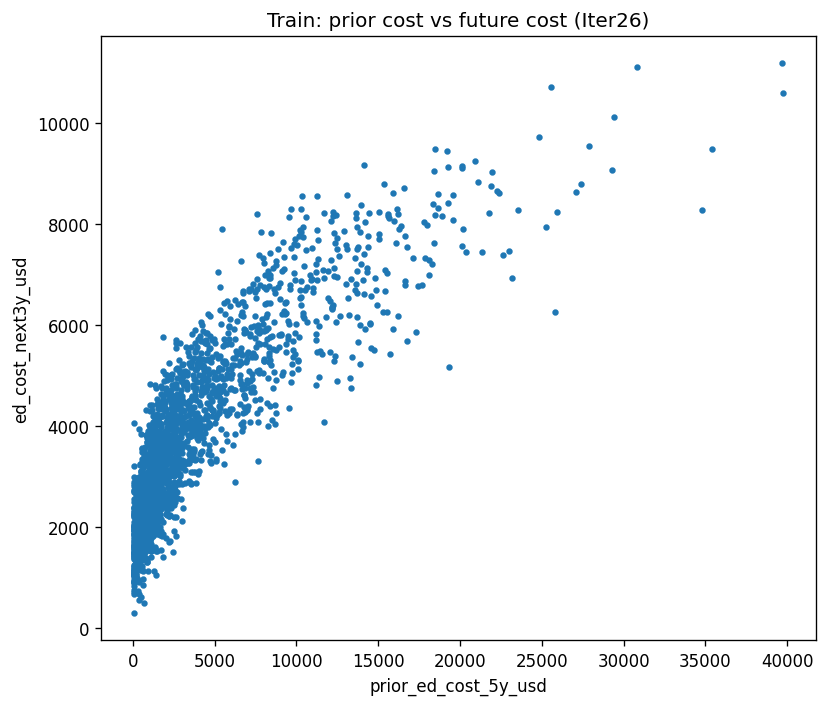

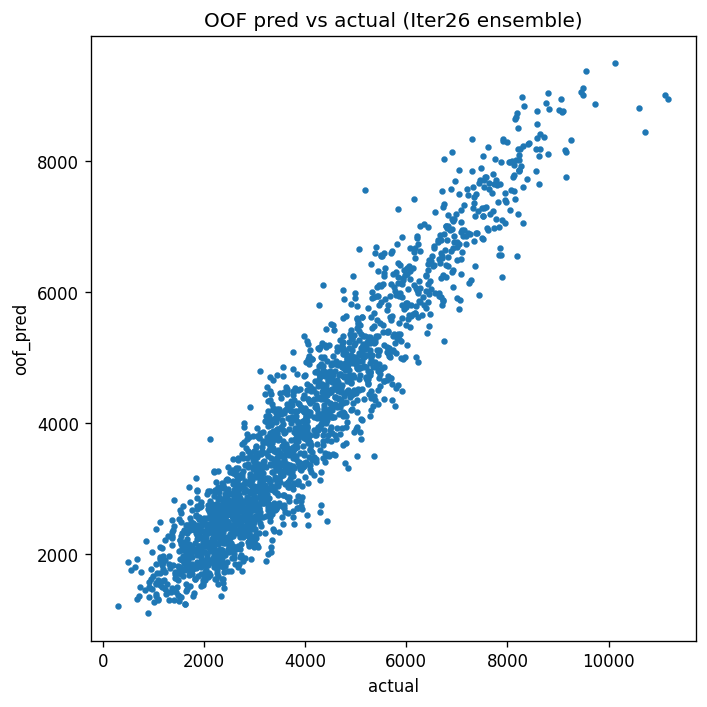


[DONE] Iter26 finished.


In [47]:
# ============================
# Iter26 (ROBUST): Sublinear + Receipt(Utilization/Price) + Optional CatBoost/LGB Ensemble
# Copy-paste into ONE Jupyter cell and run.
# ============================

import os
import re
import math
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from joblib import load, dump

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.isotonic import IsotonicRegression

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_predict

warnings.filterwarnings("ignore")

# -----------------------
# Optional packages
# -----------------------
try:
    import lightgbm as lgb
    HAS_LGB = True
    try:
        from lightgbm.callback import early_stopping as lgb_early_stopping
    except Exception:
        lgb_early_stopping = None
except Exception:
    HAS_LGB = False
    lgb = None
    lgb_early_stopping = None

try:
    from catboost import CatBoostRegressor, Pool
    HAS_CAT = True
except Exception:
    HAS_CAT = False
    CatBoostRegressor = None
    Pool = None

# -----------------------
# Config
# -----------------------
BASE_DIR = Path(r"D:\AgentDs\agent_ds_healthcare")

TRAIN_CSV    = BASE_DIR / "ed_cost_train.csv"
TEST_CSV     = BASE_DIR / "ed_cost_test.csv"
PATIENTS_CSV = BASE_DIR / "patients.csv"

ADM_TRAIN = BASE_DIR / "admissions_train.csv"
ADM_TEST  = BASE_DIR / "admissions_test.csv"

# receipt cache you trust (iter10)
RECEIPT_CACHE = BASE_DIR / "cache_iter10" / "receipts_parsed.joblib"

OUT_DIR = BASE_DIR / "cache_iter26_robust"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Toggle switches
USE_ADMISSIONS   = True         # admissions historically "弱提升/有时变差"，但这里保留可选
USE_CATBOOST     = True         # if installed
USE_LIGHTGBM     = True         # if installed
USE_MONOTONE_LGB = True         # monotone constraints for key sublinear drivers (safer generalization)
USE_LOG_TARGET_LGB = True       # second LGB model on log1p(y) (ensemble option)

# Training controls
RANDOM_STATE = 42
N_SPLITS = 5
SEEDS = [42, 2024, 3407]        # small seed ensemble
EARLY_STOP = 300
N_ESTIMATORS = 20000
TOL = 1e-2                      # money comparison tolerance

# group residual correction (post-hoc bias adjust)
USE_GROUP_RESID_CORR = True
GROUP_SHRINK_K = 80.0           # larger => more shrink for small groups

print(f"[paths] BASE_DIR={BASE_DIR}")
print(f"[paths] OUT_DIR={OUT_DIR}")
print(f"[paths] RECEIPT_CACHE={RECEIPT_CACHE}")
print(f"[flags] HAS_LGB={HAS_LGB} | HAS_CAT={HAS_CAT}")

# -----------------------
# Helpers
# -----------------------
def safe_read_csv(path: Path):
    if path is None or (not path.exists()):
        print(f"[warn] missing file: {path}")
        return None
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"[warn] failed reading {path}: {e}")
        return None

def can_int(x) -> bool:
    try:
        int(str(x).strip())
        return True
    except Exception:
        return False

def normalize_code(x):
    if x is None:
        return None
    try:
        if isinstance(x, (int, np.integer)):
            return str(int(x))
        if isinstance(x, float) and np.isfinite(x) and float(x).is_integer():
            return str(int(x))
    except Exception:
        pass
    s = str(x).strip()
    if re.fullmatch(r"\d+\.0", s):
        s = s.split(".")[0]
    return s if s else None

def parse_amount(x):
    if x is None:
        return np.nan
    try:
        if isinstance(x, str):
            xs = x.strip().replace(",", "").replace("$", "")
            return float(xs)
        return float(x)
    except Exception:
        return np.nan

def infer_col(df: pd.DataFrame, candidates):
    if df is None or df.empty:
        return None
    cols = list(df.columns)
    low = {c.lower(): c for c in cols}
    for cand in candidates:
        if cand in cols:
            return cand
        if cand.lower() in low:
            return low[cand.lower()]
    for cand in candidates:
        for c in cols:
            if cand.lower() in str(c).lower():
                return c
    return None

def safe_median(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce")
    if x.notna().any():
        return float(x.median())
    return 0.0

# -----------------------
# Receipt code universe
# -----------------------
ED_EM = {"99281","99282","99283","99284","99285"}
CRIT  = {"99291","99292"}
SEVERE_PROC = {"31500","92950","36556","36620"}  # intub, CPR, CVC, art line
IMAGING = {"70450","74177","71045"}              # CT head, CT A/P, CXR
LAB = {"85025","87070","84484"}                  # CBC, culture, troponin
OBS = {"G0378"}

ALL_CODES = sorted(list(ED_EM | CRIT | SEVERE_PROC | IMAGING | LAB | OBS))
print(f"[info] expected receipt code universe={len(ALL_CODES)} -> {ALL_CODES}")

# -----------------------
# Load core tables
# -----------------------
train = safe_read_csv(TRAIN_CSV)
test  = safe_read_csv(TEST_CSV)
patients = safe_read_csv(PATIENTS_CSV)

if train is None or test is None or patients is None:
    raise RuntimeError("Missing required CSVs (train/test/patients). Fix paths first.")

for df in (train, test, patients):
    if "patient_id" not in df.columns:
        raise RuntimeError("Missing patient_id column.")
    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")
    df.dropna(subset=["patient_id"], inplace=True)
    df["patient_id"] = df["patient_id"].astype(int)

# zip3 keep leading zeros
if "zip3" in patients.columns:
    patients["zip3"] = patients["zip3"].astype(str).str.replace(r"\.0$", "", regex=True)
    patients.loc[patients["zip3"].str.lower().isin(["nan","none"]), "zip3"] = "UNK"
    patients["zip3"] = patients["zip3"].apply(lambda s: s.zfill(3) if s.isdigit() else s)

train_full = train.merge(patients, on="patient_id", how="left")
test_full  = test.merge(patients, on="patient_id", how="left")

print(f"[info] train_full={train_full.shape}  test_full={test_full.shape}")

# outlier
for df in [train_full, test_full]:
    df["is_outlier"] = ((df["prior_ed_cost_5y_usd"] <= 50.0) & (df["prior_ed_visits_5y"] == 0)).astype(int)
    
outlier_n = int(train_full["is_outlier"].sum())
print(f"[info] outlier_n={outlier_n} / {len(train_full)}")

patient_ids_all = np.sort(pd.concat([train_full["patient_id"], test_full["patient_id"]]).unique())

# -----------------------
# Receipt cache -> robust features
# -----------------------
def build_receipt_features_from_patient_dict(patient_dict: dict, patient_ids_all: np.ndarray):
    rows = []
    line_rows = []

    CODE_KEYS = ["code", "cpt", "hcpcs", "billing_code", "service_code"]
    AMT_KEYS  = ["amount", "line_total", "line_total_usd", "total", "charge", "lineTotal"]

    def safe_items(obj):
        if not isinstance(obj, dict):
            return []
        items = obj.get("items", [])
        return items if isinstance(items, list) else []

    for pid, obj in patient_dict.items():
        if not can_int(pid):
            continue
        pid_int = int(str(pid).strip())

        items = safe_items(obj)
        codes, amounts = [], []

        header_total = np.nan
        if isinstance(obj, dict):
            header_total = parse_amount(obj.get("pdf_total", np.nan))

        for it in items:
            if not isinstance(it, dict):
                continue
            code = None
            for k in CODE_KEYS:
                if k in it:
                    code = normalize_code(it.get(k))
                    break
            amt = np.nan
            for k in AMT_KEYS:
                if k in it:
                    amt = parse_amount(it.get(k))
                    break
            if code is None:
                continue
            codes.append(code)
            amounts.append(amt)
            line_rows.append({"patient_id": pid_int, "code": code, "amount": amt})

        total_sum = float(np.nansum(amounts)) if len(amounts) else 0.0
        n_lines = int(len(codes))
        n_unique = int(len(set(codes)))

        # per-code counts/costs (known codes only)
        cnt = {f"pdf_cnt_code_{c}": 0 for c in ALL_CODES}
        cost = {f"pdf_cost_code_{c}": 0.0 for c in ALL_CODES}
        for c, a in zip(codes, amounts):
            if c in ALL_CODES:
                cnt[f"pdf_cnt_code_{c}"] += 1
                if np.isfinite(a):
                    cost[f"pdf_cost_code_{c}"] += float(a)

        def sum_cost(code_set):
            s = 0.0
            for c, a in zip(codes, amounts):
                if c in code_set and np.isfinite(a):
                    s += float(a)
            return s

        cost_em = sum_cost(ED_EM)
        cost_crit = sum_cost(CRIT)
        cost_sev = sum_cost(SEVERE_PROC)
        cost_img = sum_cost(IMAGING)
        cost_lab = sum_cost(LAB)
        cost_obs = sum_cost(OBS)
        cost_other = max(0.0, total_sum - (cost_em + cost_crit + cost_sev + cost_img + cost_lab + cost_obs))

        def share(x):
            return float(x / total_sum) if total_sum > 0 else 0.0

        em_levels = []
        for c in codes:
            if c in ED_EM and len(c) == 5 and c[-1].isdigit():
                em_levels.append(int(c[-1]))
        em_levels = np.array(em_levels, dtype=float)

        ent = 0.0
        if total_sum > 0:
            tmp = {}
            for c, a in zip(codes, amounts):
                if not np.isfinite(a):
                    continue
                tmp[c] = tmp.get(c, 0.0) + float(a)
            probs = np.array([v / total_sum for v in tmp.values() if v > 0], dtype=float)
            probs = probs[probs > 0]
            if len(probs):
                ent = float(-(probs * np.log(probs)).sum())

        amt_arr = np.array([a for a in amounts if np.isfinite(a)], dtype=float)
        unit_mean = float(amt_arr.mean()) if len(amt_arr) else 0.0
        unit_std  = float(amt_arr.std()) if len(amt_arr) else 0.0
        unit_min  = float(amt_arr.min()) if len(amt_arr) else 0.0
        unit_max  = float(amt_arr.max()) if len(amt_arr) else 0.0

        # simple severity counts (non-leaky)
        sev_cnt = sum(1 for c in codes if c in SEVERE_PROC)
        crit_cnt = sum(1 for c in codes if c in CRIT)
        em_cnt = sum(1 for c in codes if c in ED_EM)
        high_acuity_score = 2.0 * crit_cnt + 1.5 * sev_cnt + 0.2 * em_cnt

        row = {
            "patient_id": pid_int,
            "pdf_total_sum_items": total_sum,
            "pdf_total_header": header_total,
            "pdf_n_line_items": n_lines,
            "pdf_n_unique_codes": n_unique,
            "pdf_unit_mean": unit_mean,
            "pdf_unit_std": unit_std,
            "pdf_unit_min": unit_min,
            "pdf_unit_max": unit_max,
            "pdf_cost_ed_em": cost_em,
            "pdf_cost_crit": cost_crit,
            "pdf_cost_severe_proc": cost_sev,
            "pdf_cost_imaging": cost_img,
            "pdf_cost_lab": cost_lab,
            "pdf_cost_obs": cost_obs,
            "pdf_cost_other": cost_other,
            "pdf_share_ed_em": share(cost_em),
            "pdf_share_crit": share(cost_crit),
            "pdf_share_severe_proc": share(cost_sev),
            "pdf_share_imaging": share(cost_img),
            "pdf_share_lab": share(cost_lab),
            "pdf_share_obs": share(cost_obs),
            "pdf_share_other": share(cost_other),
            "pdf_has_crit": int(any(c in CRIT for c in codes)),
            "pdf_has_severe_proc": int(any(c in SEVERE_PROC for c in codes)),
            "pdf_em_level_mean": float(np.mean(em_levels)) if len(em_levels) else 0.0,
            "pdf_em_level_max": float(np.max(em_levels)) if len(em_levels) else 0.0,
            "pdf_em_high_frac": float(np.mean(em_levels >= 4)) if len(em_levels) else 0.0,
            "pdf_code_cost_entropy": ent,
            "pdf_sev_cnt": float(sev_cnt),
            "pdf_crit_cnt": float(crit_cnt),
            "pdf_em_cnt": float(em_cnt),
            "pdf_high_acuity_score": float(high_acuity_score),
        }
        row.update(cnt)
        row.update(cost)
        rows.append(row)

    feat = pd.DataFrame(rows)
    lines = pd.DataFrame(line_rows)

    # guarantee key columns
    base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
    if feat.empty:
        feat = base.copy()
        feat["pdf_total_sum_items"] = np.nan
    else:
        feat = base.merge(feat, on="patient_id", how="left")
    return feat, lines

def build_receipt_features_from_lineitems_df(lineitems: pd.DataFrame, patient_ids_all: np.ndarray):
    df = lineitems.copy()
    pid_col = infer_col(df, ["patient_id", "patient"])
    code_col = infer_col(df, ["code", "cpt", "hcpcs"])
    amt_col  = infer_col(df, ["amount", "line_total", "line total", "line_total_usd", "charge", "total"])
    if pid_col is None or code_col is None or amt_col is None:
        base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
        base["pdf_total_sum_items"] = np.nan
        return base, pd.DataFrame(columns=["patient_id","code","amount"])

    df = df[[pid_col, code_col, amt_col]].rename(columns={pid_col:"patient_id", code_col:"code", amt_col:"amount"})
    df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")
    df.dropna(subset=["patient_id"], inplace=True)
    df["patient_id"] = df["patient_id"].astype(int)
    df["code"] = df["code"].apply(normalize_code)
    df["amount"] = df["amount"].apply(parse_amount)
    df.dropna(subset=["code"], inplace=True)

    lines = df[["patient_id","code","amount"]].copy()

    g = df.groupby("patient_id", dropna=False)
    feat = pd.DataFrame({"patient_id": g.size().index.astype(int)})
    feat["pdf_total_sum_items"] = g["amount"].sum(min_count=1).fillna(0.0).values
    feat["pdf_n_line_items"] = g.size().values.astype(int)
    feat["pdf_n_unique_codes"] = g["code"].nunique().values.astype(int)

    # create empty known-code columns
    for c in ALL_CODES:
        feat[f"pdf_cnt_code_{c}"] = 0
        feat[f"pdf_cost_code_{c}"] = 0.0

    # fill via crosstab/pivot
    ct = pd.crosstab(df["patient_id"], df["code"])
    for c in ALL_CODES:
        if c in ct.columns:
            feat.loc[feat["patient_id"].isin(ct.index), f"pdf_cnt_code_{c}"] = ct[c].reindex(feat["patient_id"]).fillna(0).values

    cost_pt = df.pivot_table(index="patient_id", columns="code", values="amount", aggfunc="sum", fill_value=0.0)
    for c in ALL_CODES:
        if c in cost_pt.columns:
            feat.loc[feat["patient_id"].isin(cost_pt.index), f"pdf_cost_code_{c}"] = cost_pt[c].reindex(feat["patient_id"]).fillna(0.0).values

    base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
    feat = base.merge(feat, on="patient_id", how="left")
    return feat, lines

def load_receipts_flexible(cache_obj, patient_ids_all: np.ndarray):
    if isinstance(cache_obj, dict):
        # unwrap common wrappers
        for k in ["by_pid", "by_patient", "parsed_by_patient", "receipts_by_patient"]:
            if k in cache_obj and isinstance(cache_obj[k], dict):
                cache_obj = cache_obj[k]
                break

        keys = list(cache_obj.keys())
        sample = keys[: min(50, len(keys))]
        int_like = sum(can_int(k) for k in sample) / max(1, len(sample))

        if int_like >= 0.6:
            print(f"[receipt-cache] treating as patient_dict (int_like={int_like:.2f})")
            return build_receipt_features_from_patient_dict(cache_obj, patient_ids_all)

        # dict container with a df
        dfs = [(k,v) for k,v in cache_obj.items() if isinstance(v, pd.DataFrame)]
        if dfs:
            best_k, best_df = dfs[0]
            print(f"[receipt-cache] treating as df_container; using df key={best_k!r}")
            return build_receipt_features_from_lineitems_df(best_df, patient_ids_all)

    if isinstance(cache_obj, pd.DataFrame):
        print("[receipt-cache] treating as lineitems_df")
        return build_receipt_features_from_lineitems_df(cache_obj, patient_ids_all)

    # fallback empty
    print("[warn] Unknown receipt cache format; using empty receipts.")
    base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
    base["pdf_total_sum_items"] = np.nan
    return base, pd.DataFrame(columns=["patient_id","code","amount"])

# cache processed receipt features for speed
RECEIPT_FEAT_CACHE = OUT_DIR / "receipt_feat_iter26.joblib"
RECEIPT_LINES_CACHE = OUT_DIR / "receipt_lines_iter26.joblib"

if RECEIPT_FEAT_CACHE.exists() and RECEIPT_LINES_CACHE.exists():
    receipt_feat = load(RECEIPT_FEAT_CACHE)
    receipt_lines = load(RECEIPT_LINES_CACHE)
    print(f"[cache] loaded receipt_feat={receipt_feat.shape} receipt_lines={receipt_lines.shape}")
else:
    if RECEIPT_CACHE.exists():
        cache_obj = load(RECEIPT_CACHE)
        print(f"[debug] receipt cache type={type(cache_obj)}")
        receipt_feat, receipt_lines = load_receipts_flexible(cache_obj, patient_ids_all)
    else:
        print(f"[warn] missing receipt cache: {RECEIPT_CACHE}")
        receipt_feat = pd.DataFrame({"patient_id": patient_ids_all.astype(int), "pdf_total_sum_items": np.nan})
        receipt_lines = pd.DataFrame(columns=["patient_id","code","amount"])

    receipt_feat = receipt_feat.drop_duplicates("patient_id", keep="first")
    for c in ["patient_id","pdf_total_sum_items"]:
        if c not in receipt_feat.columns:
            receipt_feat[c] = np.nan

    dump(receipt_feat, RECEIPT_FEAT_CACHE)
    dump(receipt_lines, RECEIPT_LINES_CACHE)
    print(f"[cache] wrote receipt_feat/lines to {OUT_DIR}")

print(f"[info] receipt_feat={receipt_feat.shape} receipt_lines={receipt_lines.shape}")

# receipt integrity check (tolerant)
tmp_chk = train_full[["patient_id","prior_ed_cost_5y_usd"]].merge(
    receipt_feat[["patient_id","pdf_total_sum_items"]],
    on="patient_id", how="left"
)
absdiff = (pd.to_numeric(tmp_chk["prior_ed_cost_5y_usd"], errors="coerce") -
           pd.to_numeric(tmp_chk["pdf_total_sum_items"], errors="coerce")).abs()
mask_valid = tmp_chk["pdf_total_sum_items"].notna()
miss_rate = float((~mask_valid).mean())
match_rate = float((absdiff[mask_valid] <= TOL).mean()) if mask_valid.any() else 0.0
print(f"[receipt-check] missing_rate={miss_rate:.4f} | match_rate(valid)={match_rate:.4f} tol={TOL}")
print(absdiff[mask_valid].describe())

# ---- price decomposition from receipt_lines
# global medians by code
if receipt_lines is not None and (not receipt_lines.empty):
    rl = receipt_lines.copy()
    rl["code"] = rl["code"].apply(normalize_code)
    rl["amount"] = rl["amount"].apply(parse_amount)
    rl = rl.dropna(subset=["code"])
    med_price = rl.groupby("code")["amount"].median().to_dict()

    # per-line log price ratio vs global median(code)
    def line_log_ratio(r):
        c = r["code"]
        a = r["amount"]
        m = med_price.get(c, np.nan)
        if (not np.isfinite(a)) or (not np.isfinite(m)) or m <= 0:
            return np.nan
        return float(np.log(a / m))

    rl["log_price_ratio"] = rl.apply(line_log_ratio, axis=1)

    pr_g = rl.groupby("patient_id", dropna=False)["log_price_ratio"]
    price_feat = pr_g.agg(["mean","std","count"]).reset_index().rename(
        columns={"mean":"pdf_log_price_ratio_mean", "std":"pdf_log_price_ratio_std", "count":"pdf_price_ratio_n"}
    )
    price_feat["pdf_log_price_ratio_mean"] = price_feat["pdf_log_price_ratio_mean"].fillna(0.0)
    price_feat["pdf_log_price_ratio_std"] = price_feat["pdf_log_price_ratio_std"].fillna(0.0)

    # fraction above/below thresholds
    rl["is_hi_price"] = (rl["log_price_ratio"] > np.log(1.2)).astype(float)
    rl["is_lo_price"] = (rl["log_price_ratio"] < np.log(0.8)).astype(float)
    frac_hi = rl.groupby("patient_id")["is_hi_price"].mean().reset_index().rename(columns={"is_hi_price":"pdf_hi_price_frac"})
    frac_lo = rl.groupby("patient_id")["is_lo_price"].mean().reset_index().rename(columns={"is_lo_price":"pdf_lo_price_frac"})

    price_feat = price_feat.merge(frac_hi, on="patient_id", how="left").merge(frac_lo, on="patient_id", how="left")
    price_feat["pdf_hi_price_frac"] = price_feat["pdf_hi_price_frac"].fillna(0.0)
    price_feat["pdf_lo_price_frac"] = price_feat["pdf_lo_price_frac"].fillna(0.0)
else:
    med_price = {}
    price_feat = pd.DataFrame({"patient_id": patient_ids_all.astype(int),
                               "pdf_log_price_ratio_mean": 0.0,
                               "pdf_log_price_ratio_std": 0.0,
                               "pdf_price_ratio_n": 0.0,
                               "pdf_hi_price_frac": 0.0,
                               "pdf_lo_price_frac": 0.0})

# merge price_feat into receipt_feat
receipt_feat = receipt_feat.merge(price_feat, on="patient_id", how="left")

# standardized utilization total = sum(count(code) * global_median_price(code))
for c in ALL_CODES:
    cc = f"pdf_cnt_code_{c}"
    if cc not in receipt_feat.columns:
        receipt_feat[cc] = 0

price_vec = np.array([med_price.get(c, np.nan) for c in ALL_CODES], dtype=float)
price_vec = np.nan_to_num(price_vec, nan=0.0)

count_cols = [f"pdf_cnt_code_{c}" for c in ALL_CODES]
receipt_feat["pdf_standardized_total"] = receipt_feat[count_cols].values.astype(float) @ price_vec

num = pd.to_numeric(receipt_feat["pdf_total_sum_items"], errors="coerce").astype(float)
den = pd.to_numeric(receipt_feat["pdf_standardized_total"], errors="coerce").astype(float)
pi = np.where(den > 0, num / den, 1.0)
pi = np.where(np.isfinite(pi), pi, 1.0)
receipt_feat["pdf_price_index"] = pi.astype(np.float32)

# -----------------------
# Admissions features (robust)
# -----------------------
def build_admissions_features(adm_tr, adm_te, patient_ids_all):
    base = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
    if adm_tr is None or adm_te is None:
        return base.copy()

    adm_all = pd.concat([adm_tr, adm_te], axis=0, ignore_index=True)
    if "patient_id" not in adm_all.columns:
        return base.copy()

    adm_all["patient_id"] = pd.to_numeric(adm_all["patient_id"], errors="coerce")
    adm_all = adm_all.dropna(subset=["patient_id"])
    adm_all["patient_id"] = adm_all["patient_id"].astype(int)

    # numeric cast candidates
    for col in ["los_days", "acuity_emergent", "charlson_band", "ed_visits_6m", "discharge_weekday"]:
        if col in adm_all.columns:
            adm_all[col] = pd.to_numeric(adm_all[col], errors="coerce")

    # try find a datetime column for recency
    dt_col = infer_col(adm_all, ["admit_date", "admission_date", "admit_time", "discharge_date", "discharge_time"])
    if dt_col is not None:
        tmp_dt = pd.to_datetime(adm_all[dt_col], errors="coerce")
        ok_rate = float(tmp_dt.notna().mean())
        if ok_rate >= 0.3:
            adm_all["_dt"] = tmp_dt
        else:
            dt_col = None

    g = adm_all.groupby("patient_id", dropna=False)
    feat = pd.DataFrame({"patient_id": g.size().index.astype(int)})
    feat["adm_n"] = g.size().values.astype(int)

    def agg_if(col, fn, default=np.nan):
        if col not in adm_all.columns:
            return np.full(len(feat), default, dtype=float)
        return getattr(g[col], fn)().values

    feat["adm_los_mean"] = agg_if("los_days", "mean")
    feat["adm_los_max"]  = agg_if("los_days", "max")
    feat["adm_los_sum"]  = g["los_days"].sum(min_count=1).reindex(feat["patient_id"]).values if "los_days" in adm_all.columns else np.nan

    feat["adm_charlson_mean"] = agg_if("charlson_band", "mean")
    feat["adm_charlson_max"]  = agg_if("charlson_band", "max")

    feat["adm_emergent_rate"] = agg_if("acuity_emergent", "mean")
    feat["adm_emergent_n"]    = g["acuity_emergent"].sum(min_count=1).reindex(feat["patient_id"]).values if "acuity_emergent" in adm_all.columns else np.nan

    feat["adm_edvis6m_mean"] = agg_if("ed_visits_6m", "mean")
    feat["adm_edvis6m_max"]  = agg_if("ed_visits_6m", "max")
    feat["adm_edvis6m_sum"]  = g["ed_visits_6m"].sum(min_count=1).reindex(feat["patient_id"]).values if "ed_visits_6m" in adm_all.columns else np.nan

    # last-row features (recency-based if datetime exists)
    if dt_col is not None and "_dt" in adm_all.columns:
        adm_all = adm_all.sort_values(["patient_id","_dt"])
    else:
        adm_all = adm_all.sort_values(["patient_id"])

    last = adm_all.groupby("patient_id").tail(1).copy()
    last_cols = []
    for col in ["los_days", "charlson_band", "acuity_emergent", "ed_visits_6m", "discharge_weekday", "primary_dx"]:
        if col in last.columns:
            last_cols.append(col)
    last = last[["patient_id"] + last_cols]

    rename = {}
    for col in last_cols:
        rename[col] = f"adm_last_{col}"
    last = last.rename(columns=rename)

    feat = feat.merge(last, on="patient_id", how="left")

    # dx crosstab counts
    if "primary_dx" in adm_all.columns:
        dx_ct = pd.crosstab(adm_all["patient_id"], adm_all["primary_dx"])
        dx_ct.columns = [f"adm_dx_cnt_{c}" for c in dx_ct.columns]
        dx_ct = dx_ct.reset_index().rename(columns={"patient_id":"patient_id"})
        dx_ct["patient_id"] = dx_ct["patient_id"].astype(int)
        feat = feat.merge(dx_ct, on="patient_id", how="left")

    # derived trend
    if "adm_last_ed_visits_6m" in feat.columns and "adm_edvis6m_mean" in feat.columns:
        feat["adm_edvis6m_rise"] = pd.to_numeric(feat["adm_last_ed_visits_6m"], errors="coerce") - pd.to_numeric(feat["adm_edvis6m_mean"], errors="coerce")
    else:
        feat["adm_edvis6m_rise"] = np.nan

    # ensure all patients
    feat = base.merge(feat, on="patient_id", how="left")
    return feat

adm_feat = pd.DataFrame({"patient_id": patient_ids_all.astype(int)})
if USE_ADMISSIONS:
    adm_tr = safe_read_csv(ADM_TRAIN)
    adm_te = safe_read_csv(ADM_TEST)
    adm_feat = build_admissions_features(adm_tr, adm_te, patient_ids_all)
print(f"[info] adm_feat={adm_feat.shape}")

# -----------------------
# Merge all
# -----------------------
all_train = train_full.merge(receipt_feat, on="patient_id", how="left").merge(adm_feat, on="patient_id", how="left")
all_test  = test_full.merge(receipt_feat, on="patient_id", how="left").merge(adm_feat, on="patient_id", how="left")

# If receipt totals missing, impute from prior cost (dataset design: sum_items≈prior_cost)
all_train["pdf_total_sum_items"] = all_train["pdf_total_sum_items"].fillna(all_train["prior_ed_cost_5y_usd"])
all_test["pdf_total_sum_items"]  = all_test["pdf_total_sum_items"].fillna(all_test["prior_ed_cost_5y_usd"])

# -----------------------
# Sublinear transforms
# -----------------------
def add_sublinear(df):
    pc = pd.to_numeric(df["prior_ed_cost_5y_usd"], errors="coerce").fillna(0.0).astype(float)
    pv = pd.to_numeric(df["prior_ed_visits_5y"], errors="coerce").fillna(0.0).astype(float)

    df["prior_cost_deflated"] = np.maximum(pc, 50.0)      # key fix: avoid 0-cost exploding ratios
    df["log_prior_cost"] = np.log1p(pc)
    df["sqrt_prior_cost"] = np.sqrt(np.clip(pc, 0, None))
    df["log_prior_visits"] = np.log1p(pv)
    df["prior_cost_per_visit"] = pc / (pv + 1.0)
    df["log_prior_cost_per_visit"] = np.log1p(df["prior_cost_per_visit"].values.astype(float))

    # optional cap features (robust)
    df["prior_cost_cap20k"] = np.minimum(pc, 20000.0)
    df["prior_cost_cap10k"] = np.minimum(pc, 10000.0)

    return df

all_train = add_sublinear(all_train)
all_test  = add_sublinear(all_test)

# -----------------------
# Baseline stacking features (OOF) – powerlaw + isotonic on deflated prior cost
# -----------------------
def strat_label(df):
    # keep chronic|insurance|outlier balanced
    return (df["primary_chronic"].astype(str) + "|" +
            df["insurance"].astype(str) + "|out=" +
            df["is_outlier"].astype(int).astype(str))

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def oof_powerlaw_baseline(train_df, test_df, min_group_n=80):
    oof = np.zeros(len(train_df), dtype=float)
    test_pred = np.zeros(len(test_df), dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, strat_label(train_df)), start=1):
        tr = train_df.iloc[tr_idx].copy()
        va = train_df.iloc[va_idx].copy()

        # global model
        Xg = np.column_stack([
            np.log1p(tr["prior_cost_deflated"].values.astype(float)),
            np.log1p(tr["prior_ed_visits_5y"].values.astype(float)),
        ])
        yg = np.log1p(tr["ed_cost_next3y_usd"].values.astype(float))
        global_lr = LinearRegression().fit(Xg, yg)

        # per group models (only if enough samples)
        models = {}
        for (ch, ins), sub in tr.groupby(["primary_chronic","insurance"], dropna=False):
            if len(sub) < min_group_n:
                continue
            X = np.column_stack([
                np.log1p(sub["prior_cost_deflated"].values.astype(float)),
                np.log1p(sub["prior_ed_visits_5y"].values.astype(float)),
            ])
            ylog = np.log1p(sub["ed_cost_next3y_usd"].values.astype(float))
            lr = LinearRegression().fit(X, ylog)
            models[(ch, ins)] = lr

        # predict val
        pv = np.zeros(len(va), dtype=float)
        for i, r in enumerate(va.itertuples(index=False)):
            key = (getattr(r,"primary_chronic"), getattr(r,"insurance"))
            lr = models.get(key, global_lr)
            Xv = np.array([[np.log1p(float(getattr(r,"prior_cost_deflated"))),
                            np.log1p(float(getattr(r,"prior_ed_visits_5y")))]], dtype=float)
            pv[i] = max(0.0, float(np.expm1(lr.predict(Xv)[0])))
        oof[va_idx] = pv

        mae = mean_absolute_error(va["ed_cost_next3y_usd"].values, pv)
        print(f"[baseline_powerlaw] fold{fold}: MAE={mae:.3f}")

    # fit full for test
    tr = train_df.copy()
    Xg = np.column_stack([
        np.log1p(tr["prior_cost_deflated"].values.astype(float)),
        np.log1p(tr["prior_ed_visits_5y"].values.astype(float)),
    ])
    yg = np.log1p(tr["ed_cost_next3y_usd"].values.astype(float))
    global_lr = LinearRegression().fit(Xg, yg)

    models = {}
    for (ch, ins), sub in tr.groupby(["primary_chronic","insurance"], dropna=False):
        if len(sub) < min_group_n:
            continue
        X = np.column_stack([
            np.log1p(sub["prior_cost_deflated"].values.astype(float)),
            np.log1p(sub["prior_ed_visits_5y"].values.astype(float)),
        ])
        ylog = np.log1p(sub["ed_cost_next3y_usd"].values.astype(float))
        lr = LinearRegression().fit(X, ylog)
        models[(ch, ins)] = lr

    for i, r in enumerate(test_df.itertuples(index=False)):
        key = (getattr(r,"primary_chronic"), getattr(r,"insurance"))
        lr = models.get(key, global_lr)
        Xv = np.array([[np.log1p(float(getattr(r,"prior_cost_deflated"))),
                        np.log1p(float(getattr(r,"prior_ed_visits_5y")))]], dtype=float)
        test_pred[i] = max(0.0, float(np.expm1(lr.predict(Xv)[0])))

    return oof, test_pred

def oof_isotonic_baseline(train_df, test_df):
    oof = np.zeros(len(train_df), dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, strat_label(train_df)), start=1):
        tr = train_df.iloc[tr_idx]
        va = train_df.iloc[va_idx]

        iso = IsotonicRegression(increasing=True, out_of_bounds="clip")
        iso.fit(tr["prior_cost_deflated"].values.astype(float), tr["ed_cost_next3y_usd"].values.astype(float))
        pv = iso.predict(va["prior_cost_deflated"].values.astype(float))
        oof[va_idx] = np.clip(pv, 0, None)

        mae = mean_absolute_error(va["ed_cost_next3y_usd"].values, pv)
        print(f"[baseline_isotonic] fold{fold}: MAE={mae:.3f}")

    iso_full = IsotonicRegression(increasing=True, out_of_bounds="clip")
    iso_full.fit(train_df["prior_cost_deflated"].values.astype(float), train_df["ed_cost_next3y_usd"].values.astype(float))
    test_pred = np.clip(iso_full.predict(test_df["prior_cost_deflated"].values.astype(float)), 0, None)
    return oof, test_pred

# add baseline feats (these are not the final pred; they are extra signals)
y = all_train["ed_cost_next3y_usd"].values.astype(float)
is_out = all_train["is_outlier"].values.astype(int)

print("\n[iter26] building baseline stacking features...")
oof_bl_pow, te_bl_pow = oof_powerlaw_baseline(all_train, all_test, min_group_n=80)
oof_bl_iso, te_bl_iso = oof_isotonic_baseline(all_train, all_test)

all_train["bl_powerlaw"] = oof_bl_pow
all_test["bl_powerlaw"]  = te_bl_pow
all_train["bl_isotonic"] = oof_bl_iso
all_test["bl_isotonic"]  = te_bl_iso

# -----------------------
# Fill missing values (robust)
# -----------------------
# categoricals
CAT_COLS = [c for c in ["primary_chronic","insurance","sex","zip3"] if c in all_train.columns]
for c in CAT_COLS:
    all_train[c] = all_train[c].astype(str).fillna("UNK")
    all_test[c]  = all_test[c].astype(str).fillna("UNK")

# if admissions last dx exists, keep as cat
if "adm_last_primary_dx" in all_train.columns:
    all_train["adm_last_primary_dx"] = all_train["adm_last_primary_dx"].astype(str).fillna("UNK")
    all_test["adm_last_primary_dx"]  = all_test["adm_last_primary_dx"].astype(str).fillna("UNK")
    CAT_COLS.append("adm_last_primary_dx")

# numeric
num_cols = all_train.select_dtypes(include=[np.number]).columns.tolist()
for c in num_cols:
    if c == "ed_cost_next3y_usd":
        continue
    med = safe_median(all_train[c])
    all_train[c] = pd.to_numeric(all_train[c], errors="coerce").fillna(med)
    if c in all_test.columns:
        all_test[c] = pd.to_numeric(all_test[c], errors="coerce").fillna(med)

# -----------------------
# Feature list (drop obvious leakage / ids)
# -----------------------
DROP_COLS = {"ed_cost_next3y_usd","patient_id"}
feat_cols = [c for c in all_train.columns if c not in DROP_COLS]

# Drop high-cardinality raw strings except chosen cats
for c in feat_cols:
    if all_train[c].dtype == "object" and c not in CAT_COLS:
        # probably some leftover text columns -> drop
        pass

feat_cols = [c for c in feat_cols if not (all_train[c].dtype == "object" and c not in CAT_COLS)]

# drop constant columns
const_cols = [c for c in feat_cols if all_train[c].nunique(dropna=False) <= 1]
if const_cols:
    print(f"[feature-audit] dropping const cols: {const_cols[:20]}{'...' if len(const_cols)>20 else ''}")
feat_cols = [c for c in feat_cols if c not in const_cols]

print(f"[info] n_features_total={len(feat_cols)} | n_cat={len(CAT_COLS)}")



# =========================================================
# [Iter27] Adversarial Validation & Sample Weighting
# =========================================================
print("\n[Iter27] Calculating Adversarial Validation weights...")

# 1. 准备数据 (Train=0, Test=1)
# 只要特征列，且填充好缺失值（Iter26前面已经填过NaN了，这里安全）
adv_cols = [c for c in feat_cols if c in all_train.columns]
X_tr_adv = all_train[adv_cols].copy()
X_te_adv = all_test[adv_cols].copy()

# 简单的类别处理：Factorize
for c in CAT_COLS:
    if c in X_tr_adv.columns:
        X_tr_adv[c] = X_tr_adv[c].astype(str)
        X_te_adv[c] = X_te_adv[c].astype(str)
        vals = pd.concat([X_tr_adv[c], X_te_adv[c]], axis=0)
        codes, _ = pd.factorize(vals)
        X_tr_adv[c] = codes[:len(X_tr_adv)]
        X_te_adv[c] = codes[len(X_tr_adv):]

# 合并
X_adv = pd.concat([X_tr_adv, X_te_adv], axis=0).reset_index(drop=True)
y_adv = np.concatenate([np.zeros(len(X_tr_adv)), np.ones(len(X_te_adv))]).astype(int)

# 2. 训练逻辑回归 (LogisticRegression) 预测 p(test|x)
# 注意：这里用 StratifiedKFold 是为了避免过拟合
skf_adv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_adv = LogisticRegression(max_iter=1000, n_jobs=-1, solver='lbfgs') # 简单快速

# 获取预测概率
try:
    p_test_oof = cross_val_predict(clf_adv, X_adv, y_adv, cv=skf_adv, method="predict_proba")[:, 1]
    auc_adv = roc_auc_score(y_adv, p_test_oof)
    print(f"[adv] Train-vs-Test AUC = {auc_adv:.4f}")
except Exception as e:
    print(f"[adv] LogisticRegression failed ({e}), using default weights=1.0")
    p_test_oof = np.full(len(X_adv), 0.5)

# 3. 计算 Importance Weights (只针对 Train 部分)
# w = p(test)/p(train) ≈ p / (1-p)
p_tr_adv = p_test_oof[:len(X_tr_adv)]
# 加上 clip 防止极端权重 (0.01 ~ 0.99)
p_tr_adv = np.clip(p_tr_adv, 0.01, 0.99)
w_adv = p_tr_adv / (1.0 - p_tr_adv)

# 再次 clip 权重本身，防止梯度爆炸 (0.2 到 5.0 倍)
w_adv = np.clip(w_adv, 0.2, 5.0)

# 归一化：让平均权重维持在 1.0
w_adv = w_adv / w_adv.mean()

# 赋值回 all_train
all_train["sample_weight"] = w_adv
print(f"[adv] weights min={w_adv.min():.3f} max={w_adv.max():.3f} mean={w_adv.mean():.3f}")
print("=========================================================\n")


# -----------------------
# LightGBM CV
# -----------------------
def lgb_make_monotone_constraints(feature_names):
    # 1 = increasing (单调递增); 0 = no constraint
    # [Iter27] 更新了强制单调递增的列表
    inc = {
        "prior_ed_cost_5y_usd",
        "prior_cost_deflated",
        "log_prior_cost",
        "sqrt_prior_cost",
        "prior_ed_visits_5y",
        "log_prior_visits",       # 修正拼写
        "log_prior_cost_per_visit",
        "pdf_standardized_total", # 票据总额
        "pdf_high_acuity_score",  # 严重程度分
        "bl_powerlaw",            # Baseline 预测值
        "bl_isotonic",            # Baseline 预测值
    }
    cons = []
    for f in feature_names:
        if f in inc:
            cons.append(1)
        else:
            cons.append(0)
    return cons


def train_lgb_cv(train_df, test_df, feat_cols, cat_cols, seeds, log_target=False):
    if not HAS_LGB:
        print("[lgb] not installed; skip")
        return None

    oof = np.zeros(len(train_df), dtype=float)
    test_pred = np.zeros(len(test_df), dtype=float)

    # prepare copies: keep cat as category for LGB
    trn = train_df.copy()
    tes = test_df.copy()
    for c in cat_cols:
        trn[c] = trn[c].astype("category")
        tes[c] = tes[c].astype("category")

    # [Iter27] 确保有 sample_weight 列，如果没有则默认 1.0
    if "sample_weight" not in trn.columns:
        trn["sample_weight"] = 1.0

    # Objective logic
    if log_target:
        objective = "regression"
        metric = "l2"
    else:
        objective = "regression_l1"
        metric = "l1"

    # Monotone constraints
    mono = None
    if USE_MONOTONE_LGB:
        mono = lgb_make_monotone_constraints(feat_cols)

    for seed in seeds:
        fold_oof = np.zeros(len(trn), dtype=float)
        fold_test = np.zeros(len(tes), dtype=float)

        for fold, (tr_idx, va_idx) in enumerate(skf.split(trn, strat_label(trn)), start=1):
            tr = trn.iloc[tr_idx]
            va = trn.iloc[va_idx]

            X_tr = tr[feat_cols]
            X_va = va[feat_cols]
            X_te = tes[feat_cols]

            y_tr = tr["ed_cost_next3y_usd"].values.astype(float)
            y_va = va["ed_cost_next3y_usd"].values.astype(float)
            
            # [Iter27] 提取训练集的样本权重
            w_tr = tr["sample_weight"].values.astype(float)

            # Apply log transform if needed
            if log_target:
                y_tr_fit = np.log1p(y_tr)
                y_va_fit = np.log1p(y_va)
            else:
                y_tr_fit = y_tr
                y_va_fit = y_va

            params = dict(
                objective=objective,
                n_estimators=N_ESTIMATORS,
                learning_rate=0.02 if not log_target else 0.03,
                num_leaves=128,
                min_data_in_leaf=25,
                feature_fraction=0.80,
                bagging_fraction=0.85,
                bagging_freq=1,
                lambda_l2=5.0,
                random_state=int(seed) + fold,
                n_jobs=-1,
                force_col_wise=True,
            )
            if mono is not None and objective != "regression_l1":
                params["monotone_constraints"] = mono
                
            model = lgb.LGBMRegressor(**params)

            callbacks = []
            if lgb_early_stopping is not None:
                callbacks.append(lgb_early_stopping(stopping_rounds=EARLY_STOP, verbose=False))
            elif hasattr(lgb, "early_stopping"):
                callbacks.append(lgb.early_stopping(stopping_rounds=EARLY_STOP, verbose=False))

            try:
                model.fit(
                    X_tr, y_tr_fit,
                    sample_weight=w_tr,  # <--- [Iter27] 关键修改：传入样本权重
                    eval_set=[(X_va, y_va_fit)],
                    eval_metric=metric,
                    callbacks=callbacks if callbacks else None,
                )
            except TypeError:
                model.fit(
                    X_tr, y_tr_fit,
                    sample_weight=w_tr,  # <--- [Iter27] 关键修改
                    eval_set=[(X_va, y_va_fit)],
                    eval_metric=metric,
                    early_stopping_rounds=EARLY_STOP,
                    verbose=False
                )

            best_iter = getattr(model, "best_iteration_", None)
            pv = model.predict(X_va, num_iteration=best_iter)
            pt = model.predict(X_te, num_iteration=best_iter)

            if log_target:
                pv = np.expm1(pv)
                pt = np.expm1(pt)

            pv = np.clip(pv, 0, None)
            pt = np.clip(pt, 0, None)

            fold_oof[va_idx] = pv
            fold_test += pt / N_SPLITS

            mae = mean_absolute_error(y_va, pv)
            tag = "logY" if log_target else "L1"
            print(f"[lgb_{tag}] seed={seed} fold{fold}: MAE={mae:.3f} | best_iter={best_iter}")

        test_pred += fold_test / len(seeds)
        oof += fold_oof / len(seeds)

    return oof, test_pred

# -----------------------
# CatBoost CV
# -----------------------
def train_cat_cv(train_df, test_df, feat_cols, cat_cols, seeds):
    if not HAS_CAT:
        print("[cat] not installed; skip")
        return None

    oof = np.zeros(len(train_df), dtype=float)
    test_pred = np.zeros(len(test_df), dtype=float)

    # cat feature indices
    cat_idx = [feat_cols.index(c) for c in cat_cols if c in feat_cols]

    X = train_df[feat_cols].copy()
    X_test = test_df[feat_cols].copy()
    y = train_df["ed_cost_next3y_usd"].values.astype(float)

    for seed in seeds:
        fold_oof = np.zeros(len(train_df), dtype=float)
        fold_test = np.zeros(len(test_df), dtype=float)

        for fold, (tr_idx, va_idx) in enumerate(skf.split(train_df, strat_label(train_df)), start=1):
            X_tr, y_tr = X.iloc[tr_idx], y[tr_idx]
            X_va, y_va = X.iloc[va_idx], y[va_idx]

            tr_pool = Pool(X_tr, y_tr, cat_features=cat_idx) if len(cat_idx) else Pool(X_tr, y_tr)
            va_pool = Pool(X_va, y_va, cat_features=cat_idx) if len(cat_idx) else Pool(X_va, y_va)
            te_pool = Pool(X_test, cat_features=cat_idx) if len(cat_idx) else Pool(X_test)

            model = CatBoostRegressor(
                loss_function="MAE",
                iterations=12000,
                learning_rate=0.03,
                depth=6,
                l2_leaf_reg=6.0,
                random_seed=int(seed) + fold,
                subsample=0.85,
                rsm=0.85,
                bootstrap_type="Bernoulli",
                od_type="Iter",
                od_wait=EARLY_STOP,
                allow_writing_files=False,
                verbose=False,
            )
            model.fit(tr_pool, eval_set=va_pool, use_best_model=True)

            pv = model.predict(va_pool)
            pt = model.predict(te_pool)
            pv = np.clip(pv, 0, None)
            pt = np.clip(pt, 0, None)

            fold_oof[va_idx] = pv
            fold_test += pt / N_SPLITS

            mae = mean_absolute_error(y_va, pv)
            out_mask = (train_df.iloc[va_idx]["is_outlier"].values.astype(int) == 1)
            out_mae = mean_absolute_error(y_va[out_mask], pv[out_mask]) if out_mask.any() else np.nan
            print(f"[cat_MAE] seed={seed} fold{fold}: MAE={mae:.3f} | out_MAE={out_mae:.3f}")

        oof += fold_oof / len(seeds)
        test_pred += fold_test / len(seeds)

    return oof, test_pred

# -----------------------
# Train models
# -----------------------
oof_preds = {}
test_preds = {}

if USE_LIGHTGBM and HAS_LGB:
    print("\n=== Train LightGBM (L1 on y) ===")
    out = train_lgb_cv(all_train, all_test, feat_cols, CAT_COLS, SEEDS, log_target=False)
    if out is not None:
        oof_lgb, te_lgb = out
        oof_preds["lgb_l1"] = oof_lgb
        test_preds["lgb_l1"] = te_lgb

if USE_LOG_TARGET_LGB and USE_LIGHTGBM and HAS_LGB:
    print("\n=== Train LightGBM (L2 on log1p(y)) ===")
    out = train_lgb_cv(all_train, all_test, feat_cols, CAT_COLS, SEEDS, log_target=True)
    if out is not None:
        oof_lgb_log, te_lgb_log = out
        oof_preds["lgb_logy"] = oof_lgb_log
        test_preds["lgb_logy"] = te_lgb_log

if USE_CATBOOST and HAS_CAT:
    print("\n=== Train CatBoost (MAE) ===")
    out = train_cat_cv(all_train, all_test, feat_cols, CAT_COLS, SEEDS)
    if out is not None:
        oof_cat, te_cat = out
        oof_preds["cat_mae"] = oof_cat
        test_preds["cat_mae"] = te_cat

# -----------------------
# Evaluate & ensemble
# -----------------------
def eval_pred(name, oof):
    mae = mean_absolute_error(y, oof)
    out_mae = mean_absolute_error(y[is_out==1], oof[is_out==1]) if (is_out==1).any() else np.nan
    return mae, out_mae

rows = []
for name, oof in oof_preds.items():
    mae, out_mae = eval_pred(name, oof)
    rows.append((name, mae, out_mae))
summary = pd.DataFrame(rows, columns=["model","oof_mae","out_oof_mae"]).sort_values("oof_mae")
print("\n=== OOF SUMMARY ===")
print(summary.to_string(index=False))
summary.to_csv(OUT_DIR / "iter26_model_oof_summary.csv", index=False)

# weighted ensemble: inverse MAE
if len(oof_preds) == 0:
    raise RuntimeError("No model trained. Check LightGBM/CatBoost installation toggles.")

inv = {k: 1.0 / max(1e-9, mean_absolute_error(y, v)) for k, v in oof_preds.items()}
s = sum(inv.values())
w = {k: inv[k]/s for k in inv}
print("\n[ensemble] weights=", w)

oof_ens = np.zeros_like(y)
te_ens = np.zeros(len(all_test), dtype=float)
for k in oof_preds:
    oof_ens += w[k] * oof_preds[k]
    te_ens  += w[k] * test_preds[k]

# -----------------------
# Group residual correction (optional, shrunk)
# -----------------------
def apply_group_resid_corr(train_df, oof_pred, test_df, test_pred, shrink_k=80.0):
    key_tr = train_df["primary_chronic"].astype(str) + "|" + train_df["insurance"].astype(str)
    resid = train_df["ed_cost_next3y_usd"].values.astype(float) - oof_pred.astype(float)

    tmp = pd.DataFrame({"key": key_tr.values, "resid": resid})
    grp = tmp.groupby("key")["resid"].agg(["median","count"]).reset_index()
    grp["shrink"] = grp["count"] / (grp["count"] + shrink_k)
    grp["adj"] = grp["median"] * grp["shrink"]

    global_adj = float(np.median(resid))

    key_te = test_df["primary_chronic"].astype(str) + "|" + test_df["insurance"].astype(str)
    adj_map = dict(zip(grp["key"], grp["adj"]))
    te_adj = key_te.map(adj_map).fillna(global_adj).values.astype(float)
    te_corr = np.clip(test_pred + te_adj, 0, None)

    # (for reporting only) "corrected oof" using same group adj (small leakage but ok for sanity)
    tr_adj = pd.Series(key_tr).map(adj_map).fillna(global_adj).values.astype(float)
    oof_corr = np.clip(oof_pred + tr_adj, 0, None)

    return oof_corr, te_corr

if USE_GROUP_RESID_CORR:
    oof_ens_corr, te_ens_corr = apply_group_resid_corr(all_train, oof_ens, all_test, te_ens, shrink_k=GROUP_SHRINK_K)
    mae0 = mean_absolute_error(y, oof_ens)
    mae1 = mean_absolute_error(y, oof_ens_corr)
    print(f"\n[group-corr] OOF MAE: before={mae0:.3f} after={mae1:.3f}  (shrink_k={GROUP_SHRINK_K})")
    oof_final = oof_ens_corr
    te_final = te_ens_corr
else:
    oof_final = oof_ens
    te_final = te_ens

# final metrics
mae_final = mean_absolute_error(y, oof_final)
out_mae_final = mean_absolute_error(y[is_out==1], oof_final[is_out==1]) if (is_out==1).any() else np.nan
print(f"\n=== FINAL ENSEMBLE OOF ===\nOOF MAE={mae_final:.3f} | Outlier OOF MAE={out_mae_final:.3f}")

# -----------------------
# Save artifacts
# -----------------------
oof_df = pd.DataFrame({
    "patient_id": all_train["patient_id"].values,
    "y_true": y,
    "oof_pred": oof_final
})
oof_df.to_csv(OUT_DIR / "iter26_oof_predictions.csv", index=False)
print(f"[write] {OUT_DIR / 'iter26_oof_predictions.csv'}")

# submission
sub = pd.DataFrame({
    "patient_id": all_test["patient_id"].values,
    "ed_cost_next3y_usd": te_final.astype(float)
})
sub_path = OUT_DIR / "submission_iter26.csv"
sub.to_csv(sub_path, index=False)
print(f"[write] {sub_path}")

# plots
plt.figure(figsize=(7,6))
plt.scatter(all_train["prior_ed_cost_5y_usd"].values, y, s=8)
plt.xlabel("prior_ed_cost_5y_usd")
plt.ylabel("ed_cost_next3y_usd")
plt.title("Train: prior cost vs future cost (Iter26)")
plt.tight_layout()
plt.savefig(OUT_DIR / "scatter_prior_vs_future_iter26.png", dpi=160)
plt.show()

plt.figure(figsize=(6,6))
plt.scatter(y, oof_final, s=8)
plt.xlabel("actual")
plt.ylabel("oof_pred")
plt.title("OOF pred vs actual (Iter26 ensemble)")
plt.tight_layout()
plt.savefig(OUT_DIR / "oof_pred_vs_actual_iter26.png", dpi=160)
plt.show()

print("\n[DONE] Iter26 finished.")


# New Iter

# SUbmissin

In [48]:
# 3. Submit Predictions

# Submit predictions to the competition
print("🚀 Submitting predictions...")

try:
    result = client.submit_prediction("Healthcare", 2, "D:/AgentDs/agent_ds_healthcare/cache_iter26_robust/submission_iter26.csv")
    
    if result['success']:
        print("✅ Submission successful!")
        print(f"   📊 Score: {result['score']:.4f}")
        print(f"   📏 Metric: {result['metric_name']}")
        print(f"   ✔️  Validation: {'Passed' if result['validation_passed'] else 'Failed'}")
    else:
        print("❌ Submission failed!")
        print(f"   Error details: {result.get('details', {}).get('validation_errors', 'Unknown error')}")
        
except Exception as e:
    print(f"💥 Submission error: {e}")
    print("🔧 Check your API key and team name are correct!")

print("\n🎯 Next steps:")
print("   1. Try incorporating relevant information outside this table!")
print("   2. Move on to Healthcare Challenge 3!")


🚀 Submitting predictions...
✅ Prediction submitted successfully!
📊 Score: 460.9478 (MAE)
✅ Validation passed
✅ Submission successful!
   📊 Score: 460.9478
   📏 Metric: MAE
   ✔️  Validation: Passed

🎯 Next steps:
   1. Try incorporating relevant information outside this table!
   2. Move on to Healthcare Challenge 3!
